# Supervised Binary Classification: 30-Model Comparison

## Executive Summary

This notebook presents a supervised binary classification project using the `diamonds` dataset. The main objective is to compare approximately 30 classification models under a consistent preprocessing, training, tuning, and evaluation framework.

The original `clarity` feature is transformed into a binary target variable called `is_high_clarity`. Lower clarity grades are assigned to class 0, while higher clarity grades are assigned to class 1. The original `clarity` column is removed from the input features to avoid data leakage.

The project compares a wide range of classification model families, including baseline classifiers, logistic and regularized linear models, margin-based models, distance-based models, probabilistic models, discriminant analysis models, tree-based models, ensemble models, boosting models, neural network models, and meta-estimators such as Voting and Stacking classifiers.

The models are evaluated using multiple classification metrics, including accuracy, precision, recall, F1-score, and ROC-AUC. Training time, prediction time, saved fitted model size, and practical usability are also considered in order to compare the models from both statistical and practical perspectives.

The project also includes hyperparameter tuning, class prediction comparison tables, prediction agreement analysis, price range analysis, high-price classification performance, confusion matrix analysis, feature importance or coefficient inspection where applicable, a decision threshold mini experiment, and saved model/prediction files for faster reloading.

The purpose of this notebook is not only to identify the best-performing classifier, but also to understand how different supervised classification model families behave on structured tabular data when tested under a common experimental framework.

In the final version of the project, ensemble-based, boosting-based, and meta-estimator models achieved the strongest overall performance. The tuned Stacking Classifier achieved the best overall test performance based on the primary F1-score metric, while the tuned Voting Classifier produced a very competitive result with much lower measured model time.

The final results should be interpreted in the context of this single dataset and could be further strengthened by testing the same framework on additional datasets.

### Final Key Results on the Test Set

- **Best classification model:** Tuned Stacking Classifier
- **Test accuracy:** 0.9122
- **Test precision:** 0.8815
- **Test recall:** 0.8624
- **Test F1-score:** 0.8719
- **Test ROC-AUC:** 0.9682
- **Full notebook runtime:** 6:17:19

The tuned Voting Classifier was the strongest fast ensemble alternative, achieving a test F1-score of 0.8688, an accuracy score of 0.9118, and a ROC-AUC score of 0.9673 with a much shorter measured model time.

The decision threshold mini experiment showed that the Stacking Classifier's F1-score could be slightly improved from 0.8719 to 0.8742 by lowering the decision threshold from 0.50 to 0.35. This increased recall, but reduced precision, showing the practical trade-off between false positives and false negatives.

## Research Question

How do different supervised binary classification model families compare on structured tabular data when they are trained, tuned, and evaluated under a consistent experimental framework?

More specifically, this project investigates how baseline, logistic, regularized linear, margin-based, distance-based, probabilistic, discriminant analysis, tree-based, ensemble, boosting, neural network, and meta-estimator classification models perform when predicting whether a diamond belongs to a high-clarity class.

The comparison focuses not only on classification performance, but also on overfitting behaviour, training time, prediction time, tuning sensitivity, probability estimation, threshold behaviour, and practical usability.

The main questions explored in this notebook are:

1. Which classification model or model family achieves the best overall performance on the test set?
2. Do ensemble and boosting models provide a clear improvement over simpler linear, probabilistic, and tree-based models?
3. How much does hyperparameter tuning improve classification performance compared with the base models?
4. Which models offer the best balance between F1-score, ROC-AUC, computational cost, and interpretability?
5. How do different models behave when classifying high-clarity diamonds, especially in higher price ranges?
6. How does changing the decision threshold affect precision, recall, and F1-score?

## Project Scope

This project focuses on supervised binary classification using structured tabular data. The dataset used in this notebook is the `diamonds` dataset, and the target variable is a binary clarity-based label called `is_high_clarity`.

The original `clarity` feature is transformed into a binary target variable and then removed from the input features to avoid data leakage. The classification task is therefore based on predicting whether a diamond belongs to a higher-clarity group using the remaining numerical and categorical features.

The main purpose of the project is to compare a broad selection of binary classification model families under a consistent machine learning workflow. The comparison includes preprocessing, model training, prediction, probability or decision score generation, evaluation, hyperparameter tuning, runtime measurement, and practical model comparison.

The project is intentionally broad rather than narrowly optimized for a single model. Instead of focusing only on achieving the highest possible score, the notebook explores how different types of classifiers behave under similar conditions.

The scope of this notebook includes:

- creating a binary classification target from the original clarity feature;
- preventing data leakage by removing the original clarity column from the input features;
- preprocessing numerical and categorical features;
- training and evaluating multiple classification model families;
- comparing base models and tuned models;
- measuring performance using accuracy, precision, recall, F1-score, and ROC-AUC;
- comparing training time and prediction time;
- analysing confusion matrices and prediction agreement;
- evaluating model behaviour across different price ranges;
- testing the effect of different decision thresholds;
- inspecting feature importance or coefficients where appropriate;
- saving fitted models, tuned objects, predictions, probability scores, decision scores, and result tables for later reuse.

This project does not claim that the best-performing model in this notebook is universally the best classification model for all tabular datasets. The results are specific to the selected dataset, target definition, feature set, preprocessing choices, evaluation strategy, and hyperparameter search spaces used in this project.

Further work could strengthen the analysis by applying the same framework to additional datasets, using statistical significance testing between models, analysing class imbalance in more depth, and adding more detailed interpretability methods such as SHAP analysis.

## Dataset and Target Definition

This project uses the `diamonds` dataset, which contains information about diamonds and their physical, categorical, and price-related characteristics.

The original dataset does not contain a ready-made binary classification target. Therefore, a new binary target variable is created from the original `clarity` feature.

The original clarity grades are grouped as follows:

- Low clarity group, class `0`: `I1`, `SI2`, `SI1`, `VS2`
- High clarity group, class `1`: `VS1`, `VVS2`, `VVS1`, `IF`

The new binary target variable is:

- `is_high_clarity`: whether the diamond belongs to the high-clarity group.

After creating the binary target variable, the original `clarity` column is removed from the input features. This is necessary to avoid data leakage, because keeping the original clarity grade would give the models direct access to the information used to create the target.

The input features therefore include the remaining numerical and categorical variables, such as:

- `carat`: the weight of the diamond;
- `cut`: the quality of the diamond cut;
- `color`: the diamond colour grade;
- `depth`: the total depth percentage;
- `table`: the width of the top of the diamond relative to the widest point;
- `x`, `y`, `z`: the physical dimensions of the diamond in millimetres;
- `price`: the price of the diamond in US dollars.

The aim of the binary classification task is to predict whether a diamond belongs to the high-clarity group using the remaining available features.

This is a supervised binary classification problem because the target variable has two possible classes: class `0` for lower clarity diamonds and class `1` for higher clarity diamonds.

## Experimental Design

This notebook follows a consistent supervised machine learning workflow in order to compare multiple binary classification models as fairly as possible.

The dataset is first loaded, inspected, and prepared for modelling. The original `clarity` feature is transformed into a binary target variable called `is_high_clarity`. After the target variable is created, the original `clarity` column is removed from the input features to avoid data leakage.

The data is split into training and test sets using a fixed random state. Stratified splitting is used so that the class distribution remains consistent between the training and test sets.

A preprocessing pipeline is applied to handle numerical and categorical features appropriately. Numerical features are scaled where required, while categorical features are encoded so that they can be used by machine learning models. Tree-based models are also evaluated using a suitable preprocessing strategy that avoids unnecessary scaling where it is not required.

Each model is first trained as a base model using a consistent evaluation function. The base models are compared using classification metrics such as accuracy, precision, recall, F1-score, and ROC-AUC. Training time and prediction time are also measured.

After the base model comparison, selected models are tuned using cross-validation and predefined hyperparameter search spaces. In several cases, the search spaces are iteratively refined based on earlier tuning results in order to obtain a strong practical configuration for each model family. The aim is not to prove that the globally optimal hyperparameters have been found, but to compare the classifiers after a reasonable and consistent tuning effort. The tuned models are then evaluated on the same test set and compared against their base versions.

Some baseline or reference models are not tuned. In this binary classification project, the Dummy Classifier is used mainly as a baseline/reference model. It provides a simple lower-bound benchmark that helps show whether the more complex classifiers add meaningful predictive value.

Because this baseline model does not require the same type of hyperparameter tuning as more flexible model families, its base model result is carried forward into the final tuned comparison tables. This allows the tuned classifiers to be compared against a clear baseline reference under the same final reporting structure.

Where available, probability scores or decision scores are generated for classification models. These scores are used for ROC-AUC evaluation and for additional analysis such as decision threshold testing.

For Voting and Stacking, the notebook uses a two-stage ensemble strategy. The initial Voting and Stacking classifiers are built from selected untuned classifier pipelines. The tuned Voting and Stacking classifiers are then built from the best estimators found by the earlier hyperparameter searches. No additional Voting weight search or Stacking final-estimator grid search is applied in the final version, because these extra searches were computationally expensive and produced only small improvements in previous runs.

The final comparison focuses on several aspects:

- predictive performance on the test set;
- difference between base and tuned model performance;
- training time and prediction time;
- signs of overfitting or underfitting;
- probability or decision score quality;
- confusion matrix behaviour;
- prediction agreement between models;
- performance across different price ranges;
- practical usefulness of each model family.

The purpose of this experimental design is to create a consistent and reusable framework for comparing binary classification models on structured tabular data.

## Evaluation Metrics

The binary classification models in this notebook are evaluated using several complementary metrics. Using multiple metrics is important because a single classification score may not fully describe model behaviour.

The main evaluation metrics are:

- **Accuracy**  
  Measures the proportion of correct predictions among all predictions. It is easy to understand, but it can be misleading if the classes are imbalanced.

- **Precision**  
  Measures how many of the predicted high-clarity diamonds are actually high-clarity diamonds. High precision means the model makes fewer false positive predictions.

- **Recall**  
  Measures how many of the actual high-clarity diamonds are correctly identified by the model. High recall means the model misses fewer positive cases.

- **F1-score**  
  Combines precision and recall into a single metric using their harmonic mean. It is useful when both false positives and false negatives matter. F1-score is used as one of the main comparison metrics in this project.

- **ROC-AUC**  
  Measures how well the model separates the two classes across different decision thresholds. It is especially useful when probability scores or decision scores are available.

In this project, **F1-score** and **ROC-AUC** are treated as the most important summary metrics. F1-score gives a balanced view of precision and recall, while ROC-AUC evaluates the model's ability to distinguish between the two classes across thresholds.

Training time and prediction time are also recorded. These are not classification performance metrics, but they are important for comparing the practical usefulness of different model families. A model with slightly better predictive performance may not always be the best practical choice if it requires substantially more training time or computational resources.

## Model Families Compared

This project compares a broad range of supervised binary classification model families. The aim is not only to identify the best individual classifier, but also to understand how different types of classification approaches behave on the same structured tabular dataset.

The models are grouped into the following broad families:

| Model family | Purpose in the comparison |
|---|---|
| Baseline models | Provide a simple reference point for evaluating whether more complex classifiers add meaningful value. |
| Logistic and regularized linear models | Test how well linear decision boundaries separate the two classes. |
| Margin-based models | Evaluate support vector and related approaches that focus on separating classes with a decision boundary. |
| Distance-based models | Test whether local similarity between observations is useful for classification. |
| Probabilistic models | Evaluate models that use probability-based assumptions to classify observations. |
| Discriminant analysis models | Test statistical classification methods based on class separation and distribution assumptions. |
| Tree-based models | Evaluate non-linear classifiers that can capture feature interactions without requiring linear assumptions. |
| Ensemble models | Test whether combining multiple estimators improves classification performance and stability. |
| Boosting models | Evaluate sequential ensemble methods that often perform strongly on structured tabular data. |
| Neural network models | Test whether a feed-forward neural network can learn useful non-linear decision patterns. |
| Meta-estimators | Evaluate whether combining several strong classifiers through Voting or Stacking can improve final performance. |

This broad comparison helps show the strengths and weaknesses of different classification approaches, including F1-score, ROC-AUC, training cost, prediction speed, interpretability, probability estimation, and sensitivity to hyperparameter tuning.

In this project, special attention is given to whether more complex models such as boosting, voting, and stacking provide a meaningful improvement over simpler and more interpretable classifiers.

## Reproducibility Note

This notebook is designed to support both full execution and faster reloading of previously saved results.

When `QUICK_LOAD = False`, the notebook trains, tunes, evaluates, and saves the binary classification models from scratch. This provides the most complete runtime information, but the full execution can take several hours because the project compares many model families and includes hyperparameter tuning.

When `QUICK_LOAD = True`, the notebook attempts to reload previously saved fitted models, tuned search objects, predictions, probability scores, decision scores, and result files from the `_exports` folder. This makes it possible to review the project and regenerate many of the comparison outputs much faster, without retraining every model.

The saved notebook outputs represent completed model runs. The final reported results are based on the visible saved outputs in this notebook, including the final tuned comparison table, model timing summary, saved fitted model sizes, ROC and Precision-Recall analysis, permutation importance, and threshold experiment.

The full notebook runtime for the final completed run was **6:17:19**. Runtime may vary depending on hardware, package versions, parallel processing configuration, and whether saved model artifacts are reloaded.

To fully reproduce the fast-loading version of the notebook, the accompanying `_exports` folder should be provided together with the notebook. Without this folder, the notebook should either be run from scratch with `QUICK_LOAD = False`, or reviewed using the saved outputs already visible in the notebook.

In [1]:
from datetime import timedelta
import time
notebook_start_time = time.time()

In [2]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Python ≥3.8 is required
import time
import sys
assert sys.version_info >= (3, 8)

# Scikit-Learn ≥ 1.0 is required
import sklearn
assert sklearn.__version__ >= "1.8.0"

# Common imports
import numpy as np
import pandas as pd

# To plot pretty figures
import seaborn as sns
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Precision options
np.set_printoptions(precision=2)
pd.options.display.float_format = '{:.2f}'.format

### GitHub portfolio export paths

In [3]:
from pathlib import Path

# ============================================================
# Portfolio export paths
# ============================================================

PORTFOLIO_EXPORT_DIR = Path("_exports") / "binary_classification_models"

BINARY_CLASSIFICATION_IMAGES_DIR = PORTFOLIO_EXPORT_DIR / "images"
BINARY_CLASSIFICATION_RESULTS_DIR = PORTFOLIO_EXPORT_DIR / "results"

BINARY_CLASSIFICATION_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
BINARY_CLASSIFICATION_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FIG_DPI = 300

print("Binary classification export folder:", PORTFOLIO_EXPORT_DIR.resolve())
print("Binary classification images:", BINARY_CLASSIFICATION_IMAGES_DIR.resolve())
print("Binary classification results:", BINARY_CLASSIFICATION_RESULTS_DIR.resolve())

Binary classification export folder: D:\WorkShop\Python\GitHub\Notes - ML\_exports\binary_classification_models
Binary classification images: D:\WorkShop\Python\GitHub\Notes - ML\_exports\binary_classification_models\images
Binary classification results: D:\WorkShop\Python\GitHub\Notes - ML\_exports\binary_classification_models\results


<h2>Switches</h2>

<p>These switches control whether the notebook loads saved artifacts, trains models again, or exports portfolio-ready outputs.</p>

<ul>
  <li><code>QUICK_LOAD = True</code><br>
  Load saved models, search objects, and predictions instead of fitting again.</li>

  <li><code>QUICK_LOAD = False</code><br>
  Fit the models again from scratch.</li>

  <li><code>SAVE_MODEL_ARTIFACTS = True</code><br>
  Save newly fitted models, search objects, and prediction files. This only matters when <code>QUICK_LOAD = False</code>.</li>

  <li><code>SAVE_PORTFOLIO_OUTPUTS = True</code><br>
  Save portfolio outputs such as images and CSV result tables. This can be used independently from model training.</li>
</ul>

<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: left;">Mode</th>
      <th style="text-align: left;">QUICK_LOAD</th>
      <th style="text-align: left;">SAVE_MODEL_ARTIFACTS</th>
      <th style="text-align: left;">SAVE_PORTFOLIO_OUTPUTS</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Fast run from saved files and export portfolio outputs</td>
      <td><code>True</code></td>
      <td><code>False</code></td>
      <td><code>True</code></td>
    </tr>
    <tr>
      <td>Train and save new model artifacts</td>
      <td><code>False</code></td>
      <td><code>True</code></td>
      <td>any</td>
    </tr>
    <tr>
      <td>Train without saving model artifacts</td>
      <td><code>False</code></td>
      <td><code>False</code></td>
      <td>any</td>
    </tr>
  </tbody>
</table>

#### Important:

`SAVE_MODEL_ARTIFACTS` only has an effect when `QUICK_LOAD = False`.

`SAVE_PORTFOLIO_OUTPUTS` controls the export of portfolio images and result CSV files. It can be used with either `QUICK_LOAD = True` or `QUICK_LOAD = False`.

In [4]:
QUICK_LOAD = False                 # True --> Load saved files instead of fitting the models again
SAVE_MODEL_ARTIFACTS = True        # Only saves files when QUICK_LOAD = False
SAVE_PORTFOLIO_OUTPUTS = True      # Save GitHub portfolio images and result CSV files

### Shared configuration for model evaluation and tuning

In [5]:
from sklearn.model_selection import StratifiedKFold   # Stratified K-Fold cross-validator for classification; keeps class proportions similar in each fold

RANDOM_STATE = 42                         # Fixed random seed for reproducible results
SCORING = "f1"                            # Evaluation metric used during model tuning
SORT_BY = "Tun_F1"                        # Column used to sort the final results table
SORT_ASCENDING = False                    # False means higher scores appear first
N_JOBS = -1                               # Number of CPU cores to use; -1 means use all available cores
VERBOSE = 1                               # Controls how much progress information is printed during fitting
ERROR_SCORE = np.nan                      # Failed CV fits receive NaN; use "raise" to stop immediately and show the error

# Cross-validation strategies
SKFOLD_3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)    # 3-fold stratified cross-validation
SKFOLD_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)    # 5-fold stratified cross-validation
SKFOLD_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)  # 10-fold stratified cross-validation

## Load the Dataset

In [6]:
full_diamonds = sns.load_dataset("diamonds")
full_diamonds.shape

(53940, 10)

### Dataset Size Selection

The dataset size can be adjusted during development and testing to reduce runtime.  
For the final experiment, the full diamonds dataset is used.

In [7]:
# Set the number of rows used in the project
# Use a small value for testing and the full dataset size for the final run
DATASET_SIZE = 53940

diamonds = (
    full_diamonds
    .sample(n=DATASET_SIZE, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

diamonds.shape

(53940, 10)

## Check the Dataset

### Description of the features

- **carat**: weight of the diamond.
- **cut**: quality of the cut. Categories: Fair, Good, Very Good, Premium, Ideal.
- **color**: diamond colour grade, from D (best) to J (worst).
- **clarity**: measure of how clear the diamond is. Categories range from I1 (worst) to IF (best).
- **depth**: total depth percentage, calculated as `2 * z / (x + y)`.
- **table**: width of the top of the diamond relative to its widest point.
- **price**: price in US dollars. In this binary classification project, price is used as an input feature, not as the target variable.
- **x**: length of the diamond in mm.
- **y**: width of the diamond in mm.
- **z**: depth of the diamond in mm.

In [8]:
diamonds.sample(5).sort_index()

,carat,cut,color,clarity,depth,table,price,x,y,z
8920,0.41,Ideal,E,SI2,61.90,57.00,683,4.76,4.80,2.96
23115,0.23,Very Good,E,VVS2,61.40,60.00,505,3.93,3.98,2.43
34007,1.18,Fair,I,VS2,62.00,66.00,4553,6.75,6.63,4.16
49636,0.42,Very Good,D,VS1,60.60,58.00,1009,4.87,4.90,2.96
52178,0.63,Ideal,I,VS2,62.10,54.00,1423,5.51,5.54,3.43


In [9]:
diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
mean,0.80,61.75,57.46,3932.80,5.73,5.73,3.54
std,0.47,1.43,2.23,3989.44,1.12,1.14,0.71
min,0.20,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,61.00,56.00,950.00,4.71,4.72,2.91
50%,0.70,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,62.50,59.00,5324.25,6.54,6.54,4.04
max,5.01,79.00,95.00,18823.00,10.74,58.90,31.80


In [10]:
diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [11]:
diamonds.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [12]:
diamonds["clarity"].value_counts()

clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64

In [13]:
# Define clarity groups for binary classification
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

low_clarity = ["I1", "SI2", "SI1", "VS2"]
high_clarity = ["VS1", "VVS2", "VVS1", "IF"]

# Create binary target: 1 = high clarity, 0 = low clarity
diamonds["is_high_clarity"] = diamonds["clarity"].isin(high_clarity).astype(int)

# Split features and target
X = diamonds.drop(columns=["clarity", "is_high_clarity"])
y = diamonds["is_high_clarity"]

In [14]:
diamonds.shape

(53940, 11)

In [15]:
y.value_counts()

is_high_clarity
0    35258
1    18682
Name: count, dtype: int64

In [16]:
y.value_counts(normalize=True)

is_high_clarity
0   0.65
1   0.35
Name: proportion, dtype: float64

In [17]:
X.sample(10, random_state=RANDOM_STATE)

,carat,cut,color,depth,table,price,x,y,z
1388,1.11,Ideal,G,61.90,57.00,5408,6.63,6.66,4.11
50052,1.21,Premium,G,62.80,59.00,8402,6.84,6.76,4.27
41645,0.84,Premium,E,59.20,59.00,3086,6.19,6.14,3.65
42377,0.72,Very Good,E,62.10,57.00,2578,5.69,5.75,3.55
17244,2.26,Ideal,J,61.10,57.00,17010,8.44,8.47,5.17
1608,0.53,Premium,G,61.30,58.00,1363,5.21,5.16,3.18
46398,1.01,Premium,F,62.30,58.00,6271,6.34,6.30,3.94
45493,1.28,Ideal,F,62.20,56.00,12958,6.95,6.91,4.32
49385,1.50,Good,H,64.00,61.00,5208,7.18,7.14,4.58
10460,1.58,Ideal,I,62.40,54.00,10920,7.43,7.46,4.64


In [18]:
y.sample(10, random_state=RANDOM_STATE)

1388     0
50052    0
41645    0
42377    0
17244    0
1608     0
46398    0
45493    1
49385    0
10460    1
Name: is_high_clarity, dtype: int32

### Train-test with split stratification

In [19]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    diamonds,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=diamonds["is_high_clarity"]
)

train_set = train_set.reset_index(drop=True)
test_set = test_set.reset_index(drop=True)

train_set.shape, test_set.shape

((43152, 11), (10788, 11))

### Compare target class ratios in the full / train / test datasets

In [20]:
comparison_df = pd.DataFrame({
    "full_ratio": diamonds["is_high_clarity"].value_counts(normalize=True).sort_index(),
    "train_ratio": train_set["is_high_clarity"].value_counts(normalize=True).sort_index(),
    "test_ratio": test_set["is_high_clarity"].value_counts(normalize=True).sort_index(),
})

comparison_df

,full_ratio,train_ratio,test_ratio
is_high_clarity,,,
0,0.65,0.65,0.65
1,0.35,0.35,0.35


### Creating x and y

In [21]:
X_train = train_set.drop(columns=["clarity", "is_high_clarity"])
y_train = train_set["is_high_clarity"]

X_test = test_set.drop(columns=["clarity", "is_high_clarity"])
y_test = test_set["is_high_clarity"]

In [22]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((43152, 9), (10788, 9), (43152,), (10788,))

In [23]:
X_train.head()

,carat,cut,color,depth,table,price,x,y,z
0,1.59,Ideal,E,62.30,55.00,11251,7.52,7.48,4.67
1,0.58,Premium,G,61.50,58.00,1884,5.35,5.41,3.31
2,0.54,Ideal,G,62.60,57.00,1389,5.21,5.18,3.25
3,1.02,Ideal,G,62.70,57.00,8401,6.41,6.45,4.03
4,0.33,Ideal,E,62.60,57.00,928,4.42,4.37,2.75


In [24]:
y_train.value_counts(normalize=True)

is_high_clarity
0   0.65
1   0.35
Name: proportion, dtype: float64

### Check missing values

In [25]:
## Look for rows with incomplete values
incomplete_rows = X_train[X_train.isna().any(axis=1)]
incomplete_rows

,carat,cut,color,depth,table,price,x,y,z


In [26]:
X_train.isnull().sum()

carat    0
cut      0
color    0
depth    0
table    0
price    0
x        0
y        0
z        0
dtype: int64

### Check numerical and categorical columns

In [27]:
# Separate numerical and categorical columns
num_attribs = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_attribs = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"numerical columns:\n{num_attribs}\n")
print(f"categorical columns:\n{cat_attribs}")

numerical columns:
['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

categorical columns:
['cut', 'color']


## Preprocessing

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Select test set rows for prediction comparison

In [29]:
# Select test set rows for prediction comparison
sample_idx = X_test.index

### Preprocessing for scaled models

In [30]:
num_attribs = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_attribs = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

num_attribs, cat_attribs

(['carat', 'depth', 'table', 'price', 'x', 'y', 'z'], ['cut', 'color'])

In [31]:
scaled_preprocessing = ColumnTransformer([
    ("num", StandardScaler(), num_attribs),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_attribs)
])

### Preprocessing for tree-based models

In [32]:
tree_preprocessing = ColumnTransformer([
    ("num", "passthrough", num_attribs),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_attribs)
])

## Create Functions

### Classification Evaluation Function with ROC-AUC and Train-Test Gap Check

In [33]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_classification(
    y_true,
    y_pred,
    model_name="Model",
    y_score=None,
    y_train_true=None,
    y_train_pred=None,
    y_train_score=None
):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"--- {model_name} ---")
    print("TEST")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 score:  {f1:.4f}")

    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

    if y_score is not None:
        roc_auc = roc_auc_score(y_true, y_score)
        print(f"ROC-AUC:   {roc_auc:.4f}")
        results["ROC_AUC"] = roc_auc

    cm = confusion_matrix(y_true, y_pred)

    print()
    print("Confusion matrix:")
    print(cm)

    # Optional train vs test fit check
    if y_train_true is not None and y_train_pred is not None:
        train_accuracy = accuracy_score(y_train_true, y_train_pred)
        train_precision = precision_score(y_train_true, y_train_pred, zero_division=0)
        train_recall = recall_score(y_train_true, y_train_pred, zero_division=0)
        train_f1 = f1_score(y_train_true, y_train_pred, zero_division=0)

        accuracy_gap = train_accuracy - accuracy
        f1_gap = train_f1 - f1

        print()
        print("TRAIN")
        print(f"Accuracy:  {train_accuracy:.4f}")
        print(f"Precision: {train_precision:.4f}")
        print(f"Recall:    {train_recall:.4f}")
        print(f"F1 score:  {train_f1:.4f}")

        if y_train_score is not None:
            train_roc_auc = roc_auc_score(y_train_true, y_train_score)
            roc_auc_gap = train_roc_auc - results.get("ROC_AUC", np.nan)

            print(f"ROC-AUC:   {train_roc_auc:.4f}")
        else:
            train_roc_auc = None
            roc_auc_gap = None

        print()
        print("GAP")
        print(f"Accuracy gap: {accuracy_gap:.4f}")
        print(f"F1 gap:       {f1_gap:.4f}")

        results.update({
            "Train_Accuracy": train_accuracy,
            "Train_Precision": train_precision,
            "Train_Recall": train_recall,
            "Train_F1": train_f1,
            "Accuracy_gap": accuracy_gap,
            "F1_gap": f1_gap
        })

        if train_roc_auc is not None:
            results.update({
                "Train_ROC_AUC": train_roc_auc,
                "ROC_AUC_gap": roc_auc_gap
            })

    return results

### Reusable Function for Prediction Check Table

In [34]:
# ---------------------------------------------------------
# Select common balanced sample columns for comparison tables
# ---------------------------------------------------------

sample_label_values = y_test.loc[X_test.index]

# Select a balanced random sample from both classes
class_0_cols = sample_label_values[sample_label_values == 0].sample(
    n=min(14, (sample_label_values == 0).sum()),
    random_state=RANDOM_STATE
).index

class_1_cols = sample_label_values[sample_label_values == 1].sample(
    n=min(14, (sample_label_values == 1).sum()),
    random_state=RANDOM_STATE
).index

selected_cols = list(class_0_cols) + list(class_1_cols)

# Sort selected columns by original price in ascending order
selected_cols = X_test.loc[selected_cols, "price"].sort_values().index.tolist()

In [35]:
def create_prediction_check_table(
    pred_test,
    model_name,
    selected_cols,
    X_test,
    y_test,
    score_test=None,
    price_col="price"
):
    # Create prediction Series with the same index as X_test
    pred_series = pd.Series(pred_test, index=X_test.index)

    # Save selected predictions for this model
    sample_pred = pred_series.loc[selected_cols]

    # Create comparison table
    results_comparison = pd.DataFrame({
        "Original Label": y_test.loc[selected_cols],
        model_name: sample_pred
    })

    # Add prediction probability if available
    if score_test is not None:
        score_series = pd.Series(score_test, index=X_test.index)
        results_comparison["Prediction Probability"] = score_series.loc[selected_cols]

    results_comparison["Correct"] = (
        results_comparison[model_name] == results_comparison["Original Label"]
    )

    # Sort by original price
    results_comparison = results_comparison.copy()
    results_comparison["_price"] = X_test.loc[results_comparison.index, price_col]

    results_comparison = (
        results_comparison
        .sort_values("_price")
        .drop(columns=["_price"])
    )

    results_display = results_comparison.T

    # Display column names as prices
    def display_price_column(col):
        return f"${X_test.loc[col, price_col]:,.0f}"

    # Highlight Correct row
    def highlight_correct_cells(value):
        if value == True:
            return "background-color: #e5fddb"   # light green
        elif value == False:
            return "background-color: #f4cccc"   # light red
        return ""

    # Base styler
    styled_table = (
        results_display.style
        .format_index(display_price_column, axis=1)
        .format(
            "{:.0f}",
            subset=pd.IndexSlice[["Original Label", model_name], :]
        )
        .format(
            lambda value: "True" if value == True else "False",
            subset=pd.IndexSlice[["Correct"], :]
        )
        .set_properties(
            subset=pd.IndexSlice[["Original Label"], :],
            **{"background-color": "#ffd966"}
        )
        .map(
            highlight_correct_cells,
            subset=pd.IndexSlice[["Correct"], :]
        )
        .map_index(
            lambda v: "background-color: #ffd966" if v == "Original Label"
            else "background-color: #e5fddb" if v == "Correct"
            else "",
            axis=0
        )
        .set_table_styles(
            [
                {
                    "selector": "th.row_heading",
                    "props": [
                        ("text-align", "left"),
                        ("white-space", "nowrap")
                    ]
                }
            ],
            overwrite=False
        )
    )

    # Add probability formatting only if the row exists
    if "Prediction Probability" in results_display.index:
        styled_table = styled_table.format(
            "{:.4f}",
            subset=pd.IndexSlice[["Prediction Probability"], :]
        )

    return sample_pred, styled_table

# Load the saved files

### Load all the Base Models

In [36]:
if QUICK_LOAD:
    import os
    import joblib
    import pandas as pd
    
    models_dir = os.path.join("_exports", "binary_classification_models", "fitted_base_models")
    
    if not os.path.exists(models_dir):
        raise FileNotFoundError(f"Model directory not found: {models_dir}")
    
    loaded_fitted_base_models = {}
    
    for filename in sorted(os.listdir(models_dir)):
        if filename.endswith(".pkl"):
            model_key = filename.replace("fitted_base_model_", "").replace(".pkl", "")
            full_path = os.path.join(models_dir, filename)
            loaded_fitted_base_models[model_key] = joblib.load(full_path)
    
    if not loaded_fitted_base_models:
        raise FileNotFoundError(
            f"No fitted base model .pkl files were found in: {models_dir}"
        )
    
    loaded_fitted_base_models_df = pd.DataFrame({
        "Model_Key": list(loaded_fitted_base_models.keys())
    }).reset_index(drop=True)

### Load all the Search Objects

In [37]:
if QUICK_LOAD:
    import os
    import joblib
    import pandas as pd
    
    searches_dir = os.path.join("_exports", "binary_classification_models", "search_objects")
    
    if not os.path.exists(searches_dir):
        raise FileNotFoundError(f"Search directory not found: {searches_dir}")
    
    loaded_searches = {}
    
    for filename in sorted(os.listdir(searches_dir)):
        if filename.endswith(".pkl"):
            search_key = filename.replace("binary_classification_search_", "").replace(".pkl", "")
            full_path = os.path.join(searches_dir, filename)
            loaded_searches[search_key] = joblib.load(full_path)
    
    if not loaded_searches:
        raise FileNotFoundError(
            f"No search object .pkl files were found in: {searches_dir}"
        )
    
    loaded_searches_df = pd.DataFrame({
        "Search_Key": list(loaded_searches.keys())
    }).reset_index(drop=True)

### Load all the Predictions

In [38]:
if QUICK_LOAD:
    import os
    import joblib
    import pandas as pd
    
    predictions_dir = os.path.join("_exports", "binary_classification_models", "predictions")
    
    if not os.path.exists(predictions_dir):
        raise FileNotFoundError(f"Prediction directory not found: {predictions_dir}")
    
    loaded_predictions = {}
    
    for filename in sorted(os.listdir(predictions_dir)):
        if filename.endswith(".pkl"):
            prediction_key = filename.replace(".pkl", "")  # remove extension only
            full_path = os.path.join(predictions_dir, filename)
            loaded_predictions[prediction_key] = joblib.load(full_path)
    
    if not loaded_predictions:
        raise FileNotFoundError(
            f"No prediction/score .pkl files were found in: {predictions_dir}"
        )
    
    loaded_predictions_df = pd.DataFrame({
        "Prediction_Key": list(loaded_predictions.keys()),
        "Object_Type": [type(obj).__name__ for obj in loaded_predictions.values()],
        "Length": [
            len(obj) if hasattr(obj, "__len__") else None
            for obj in loaded_predictions.values()
        ]
    }).reset_index(drop=True)
    
    display(loaded_predictions_df)

<hr style="border:10px dashed gray">

# **Baseline models**

## <span style="color:#927500">Dummy Classifier</span>
The DummyClassifier is a simple baseline model that makes predictions without learning real relationships from the data.

In [39]:
start_fit = time.perf_counter()

In [40]:
if not QUICK_LOAD:
    from sklearn.dummy import DummyClassifier
    
    dummy_param = {
        "strategy": "prior",          # Default: "prior" -> Predicts classes based on the training set class distribution
        "random_state": RANDOM_STATE  # Default: None -> Used only by random strategies such as "stratified" or "uniform"
        # "constant": 1               # Default: None -> Used only when strategy="constant"
    }
    
    dummy_clf = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", DummyClassifier(**dummy_param))
    ])

    print("Dummy Classifier: fitting model...")
    dummy_clf.fit(X_train, y_train)
    print("Dummy Classifier: fitted successfully.")
    
else:
    print("Dummy Classifier: loading fitted model...")
    dummy_clf = loaded_fitted_base_models["dummy"]
    print("Dummy Classifier: loaded successfully.")

Dummy Classifier: fitting model...
Dummy Classifier: fitted successfully.


In [41]:
dummy_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(dummy_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features used by Dummy Classifier Model

In [42]:
# Number of input features used by the model after preprocessing
print("Number of input features:", dummy_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [43]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", dummy_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [44]:
start_pred = time.perf_counter()

In [45]:
if not QUICK_LOAD:
    dummy_pred_train = dummy_clf.predict(X_train)
    dummy_pred_test = dummy_clf.predict(X_test)
    
    dummy_score_train = dummy_clf.predict_proba(X_train)[:, 1]
    dummy_score_test = dummy_clf.predict_proba(X_test)[:, 1]

else:
    print("Dummy Classifier: loading prediction...")
    dummy_pred_train = loaded_predictions["dummy_pred_train_file"]
    dummy_pred_test = loaded_predictions["dummy_pred_test_file"]
    
    dummy_score_train = loaded_predictions["dummy_score_train_file"]
    dummy_score_test = loaded_predictions["dummy_score_test_file"]


dummy_results = evaluate_classification(
    y_test,
    dummy_pred_test,
    model_name="Dummy Classifier",
    y_score=dummy_score_test,
    y_train_true=y_train,
    y_train_pred=dummy_pred_train,
    y_train_score=dummy_score_train
)

--- Dummy Classifier ---
TEST
Accuracy:  0.6537
Precision: 0.0000
Recall:    0.0000
F1 score:  0.0000
ROC-AUC:   0.5000

Confusion matrix:
[[7052    0]
 [3736    0]]

TRAIN
Accuracy:  0.6536
Precision: 0.0000
Recall:    0.0000
F1 score:  0.0000
ROC-AUC:   0.5000

GAP
Accuracy gap: -0.0000
F1 gap:       0.0000


In [46]:
dummy_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(dummy_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Comparison of sampled classification results

In [47]:
dummy_sample_pred, dummy_results_table = create_prediction_check_table(
    pred_test=dummy_pred_test,
    model_name="Dummy",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

dummy_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Dummy,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Correct,False,True,False,False,False,False,False,True,True,True,True,False,False,True,False,True,True,True,True,True,True,False,False,False,False,False,True,True


### Add formatted timing and model type to the results

In [48]:
dummy_results["Model_type"] = "Baseline"

dummy_results["Fit_time"] = str(timedelta(seconds=int(dummy_fit_time)))
dummy_results["Pred_time"] = str(timedelta(seconds=int(dummy_predict_time)))
dummy_results["Tun_fit_time"] = np.nan
dummy_results["Tun_pred_time"] = np.nan
dummy_results["Full_model_time"] = str(timedelta(seconds=int(dummy_fit_time + dummy_predict_time)))

dummy_results["Tun_Accuracy"] = dummy_results["Accuracy"]
dummy_results["Tun_Precision"] = dummy_results["Precision"]
dummy_results["Tun_Recall"] = dummy_results["Recall"]
dummy_results["Tun_F1"] = dummy_results["F1"]
dummy_results["Tun_ROC_AUC"] = dummy_results["ROC_AUC"]

<hr style="border:10px dashed gray">

# **Logistic / regularized linear models**

## <span style="color:#927500">Logistic Regression L2</span>
Logistic Regression L2 is a regularized linear classification model that predicts class probabilities and uses L2 regularization to help reduce overfitting.

In [49]:
start_time = time.perf_counter()

In [50]:
if not QUICK_LOAD:
    from sklearn.linear_model import LogisticRegression
    
    log_reg_l2_param = {
        "C": 1.0,                     # Default: 1.0 -> Smaller values = stronger regularization
        "l1_ratio": 0.0,              # 0.0 = pure L2 regularization in scikit-learn 1.8+
        "solver": "lbfgs",            # Good choice for L2
        "max_iter": 1000,             # Default: 100 -> Increased to help convergence
        "random_state": RANDOM_STATE  # Default: None -> Used by some solvers
    }
    
    log_reg_l2_clf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", LogisticRegression(**log_reg_l2_param))
    ])

    print("Logistic Regression L2: fitting model...")
    log_reg_l2_clf.fit(X_train, y_train)
    print("Logistic Regression L2: fitted successfully.")
    
else:
    print("Logistic Regression L2: loading fitted model...")
    log_reg_l2_clf = loaded_fitted_base_models["logistic_regression_l2"]
    print("Logistic Regression L2: loaded successfully.")

Logistic Regression L2: fitting model...
Logistic Regression L2: fitted successfully.


In [51]:
log_reg_l2_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(log_reg_l2_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Logistic Regression L2 Model

In [52]:
# Intercept of the logistic regression model
print("Starting value of the model:", log_reg_l2_clf.named_steps["model"].intercept_)

Starting value of the model: [-0.69]


In [53]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", log_reg_l2_clf.named_steps["model"].coef_)

Weights for each feature:
 [[-8.80e+00 -4.41e-01  3.82e-02  4.85e+00 -1.01e+00 -2.83e-01  4.25e+00
   2.84e-01 -2.39e-01 -1.70e-02 -4.30e-01 -6.44e-02 -1.58e+00 -9.77e-01
  -6.59e-01  2.04e-04  1.36e-01  8.83e-01  1.73e+00]]


In [54]:
# Number of input features used by the model
print("Number of input features:", log_reg_l2_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [55]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", log_reg_l2_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [56]:
start_time = time.perf_counter()

In [57]:
if not QUICK_LOAD:
    log_reg_l2_pred_train = log_reg_l2_clf.predict(X_train)
    log_reg_l2_pred_test = log_reg_l2_clf.predict(X_test)
    
    log_reg_l2_score_train = log_reg_l2_clf.predict_proba(X_train)[:, 1]
    log_reg_l2_score_test = log_reg_l2_clf.predict_proba(X_test)[:, 1]

else:
    print("Logistic Regression L2: loading prediction...")
    log_reg_l2_pred_train = loaded_predictions["log_reg_l2_pred_train_file"]
    log_reg_l2_pred_test = loaded_predictions["log_reg_l2_pred_test_file"]
    
    log_reg_l2_score_train = loaded_predictions["log_reg_l2_score_train_file"]
    log_reg_l2_score_test = loaded_predictions["log_reg_l2_score_test_file"]


log_reg_l2_results = evaluate_classification(
    y_test,
    log_reg_l2_pred_test,
    model_name="Logistic Regression L2",
    y_score=log_reg_l2_score_test,
    y_train_true=y_train,
    y_train_pred=log_reg_l2_pred_train,
    y_train_score=log_reg_l2_score_train
)

--- Logistic Regression L2 ---
TEST
Accuracy:  0.7765
Precision: 0.7016
Recall:    0.6172
F1 score:  0.6567
ROC-AUC:   0.8451

Confusion matrix:
[[6071  981]
 [1430 2306]]

TRAIN
Accuracy:  0.7773
Precision: 0.7040
Recall:    0.6158
F1 score:  0.6570
ROC-AUC:   0.8439

GAP
Accuracy gap: 0.0007
F1 gap:       0.0003


In [58]:
log_reg_l2_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(log_reg_l2_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [59]:
start_time = time.perf_counter()

In [60]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    log_reg_l2_param_grid = {
        "model__C": [2.0, 5.0, 7.5, 10.0, 15.0, 20.0, 30.0, 50.0, 75.0, 100.0],  # Default: 1.0 -> Inverse regularization strength; higher values mean weaker regularization
        "model__l1_ratio": [0.0],      # Default: None -> 0.0 = pure L2 regularization when using elasticnet-compatible setup
        "model__solver": ["lbfgs"],    # Default: "lbfgs" -> Optimization algorithm suitable for L2 logistic regression
        "model__max_iter": [1000]      # Default: 100 -> Maximum number of iterations allowed for convergence
    }
    
    log_reg_l2_search = GridSearchCV(
        log_reg_l2_clf,
        param_grid=log_reg_l2_param_grid,
        scoring=SCORING,
        cv=SKFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )
    
    print("Logistic Regression L2: fitting model...")
    log_reg_l2_search.fit(X_train, y_train)
    print("Logistic Regression L2: fitted successfully.")
    
else:
    print("Logistic Regression L2: loading fitted model...")
    log_reg_l2_search = loaded_searches["logistic_regression_l2"]
    print("Logistic Regression L2: loaded successfully.")

Logistic Regression L2: fitting model...
Fitting 10 folds for each of 10 candidates, totalling 100 fits
Logistic Regression L2: fitted successfully.


In [61]:
log_reg_l2_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(log_reg_l2_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:00:28


In [62]:
# Best parameter
log_reg_l2_search.best_params_

{'model__C': 30.0,
 'model__l1_ratio': 0.0,
 'model__max_iter': 1000,
 'model__solver': 'lbfgs'}

In [63]:
# Best model
log_reg_l2_best_tuning = log_reg_l2_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [64]:
start_time = time.perf_counter()

In [65]:
if not QUICK_LOAD:
    log_reg_l2_best_pred_train = log_reg_l2_best_tuning.predict(X_train)
    log_reg_l2_best_pred_test = log_reg_l2_best_tuning.predict(X_test)
    
    log_reg_l2_best_score_train = log_reg_l2_best_tuning.predict_proba(X_train)[:, 1]
    log_reg_l2_best_score_test = log_reg_l2_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Logistic Regression L2: loading best prediction...")
    log_reg_l2_best_pred_train = loaded_predictions["log_reg_l2_best_pred_train_file"]
    log_reg_l2_best_pred_test = loaded_predictions["log_reg_l2_best_pred_test_file"]
    
    log_reg_l2_best_score_train = loaded_predictions["log_reg_l2_best_score_train_file"]
    log_reg_l2_best_score_test = loaded_predictions["log_reg_l2_best_score_test_file"]


log_reg_l2_best_results = evaluate_classification(
    y_test,
    log_reg_l2_best_pred_test,
    model_name="Best Logistic Regression L2",
    y_score=log_reg_l2_best_score_test,
    y_train_true=y_train,
    y_train_pred=log_reg_l2_best_pred_train,
    y_train_score=log_reg_l2_best_score_train
)

--- Best Logistic Regression L2 ---
TEST
Accuracy:  0.7789
Precision: 0.7048
Recall:    0.6223
F1 score:  0.6610
ROC-AUC:   0.8460

Confusion matrix:
[[6078  974]
 [1411 2325]]

TRAIN
Accuracy:  0.7786
Precision: 0.7053
Recall:    0.6194
F1 score:  0.6596
ROC-AUC:   0.8448

GAP
Accuracy gap: -0.0004
F1 gap:       -0.0014


In [66]:
log_reg_l2_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(log_reg_l2_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [67]:
log_reg_l2_sample_pred, log_reg_l2_results_table = create_prediction_check_table(
    pred_test=log_reg_l2_best_pred_test,
    score_test=log_reg_l2_best_score_test,
    model_name="Best Logistic Regression L2",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

log_reg_l2_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Logistic Regression L2,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0
Prediction Probability,0.6339,0.6461,0.7311,0.5940,0.6671,0.6327,0.6965,0.2043,0.1539,0.0206,0.4769,0.3557,0.1387,0.0318,0.2414,0.0609,0.0745,0.3650,0.0056,0.4108,0.0189,0.6759,0.8594,0.6298,0.8863,0.9994,0.9136,0.1715
Correct,True,False,True,True,True,True,True,True,True,True,True,False,False,True,False,True,True,True,True,True,True,True,True,True,True,True,False,True


### Add formatted timing and model type to the results

In [68]:
log_reg_l2_results["Model_type"] = "Logistic / regularized linear"

log_reg_l2_results["Fit_time"] = str(timedelta(seconds=int(log_reg_l2_fit_time)))
log_reg_l2_results["Pred_time"] = str(timedelta(seconds=int(log_reg_l2_predict_time)))
log_reg_l2_results["Tun_fit_time"] = str(timedelta(seconds=int(log_reg_l2_tuning_fit_time)))
log_reg_l2_results["Tun_pred_time"] = str(timedelta(seconds=int(log_reg_l2_tuning_predict_time)))
log_reg_l2_results["Full_model_time"] = str(timedelta(seconds=int(
    log_reg_l2_fit_time +
    log_reg_l2_predict_time +
    log_reg_l2_tuning_fit_time +
    log_reg_l2_tuning_predict_time
)))

log_reg_l2_results["Tun_Accuracy"] = log_reg_l2_best_results["Accuracy"]
log_reg_l2_results["Tun_Precision"] = log_reg_l2_best_results["Precision"]
log_reg_l2_results["Tun_Recall"] = log_reg_l2_best_results["Recall"]
log_reg_l2_results["Tun_F1"] = log_reg_l2_best_results["F1"]
log_reg_l2_results["Tun_ROC_AUC"] = log_reg_l2_best_results["ROC_AUC"]

log_reg_l2_results["Tun_Train_Accuracy"] = log_reg_l2_best_results["Train_Accuracy"]
log_reg_l2_results["Tun_Train_Precision"] = log_reg_l2_best_results["Train_Precision"]
log_reg_l2_results["Tun_Train_Recall"] = log_reg_l2_best_results["Train_Recall"]
log_reg_l2_results["Tun_Train_F1"] = log_reg_l2_best_results["Train_F1"]
log_reg_l2_results["Tun_Train_ROC_AUC"] = log_reg_l2_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">Logistic Regression L1</span>
Logistic Regression L1 is a regularized linear classification model that can reduce overfitting and perform feature selection by shrinking some coefficients to exactly zero.

In [69]:
start_time = time.perf_counter()

In [70]:
if not QUICK_LOAD:
    from sklearn.linear_model import LogisticRegression
    
    log_reg_l1_param = {
        "C": 1.0,                     # Default: 1.0 -> Smaller values = stronger regularization
        "l1_ratio": 1.0,              # 1.0 = pure L1 regularization in sklearn 1.8+
        "solver": "liblinear",        # Supports L1 for binary classification
        "max_iter": 1000,             # Default: 100 -> Increased to help convergence
        "random_state": RANDOM_STATE  # Default: None -> Used by some solvers
    }
    
    log_reg_l1_clf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", LogisticRegression(**log_reg_l1_param))
    ])

    print("Logistic Regression L1: fitting model...")
    log_reg_l1_clf.fit(X_train, y_train)
    print("Logistic Regression L1: fitted successfully.")
    
else:
    print("Logistic Regression L1: loading fitted model...")
    log_reg_l1_clf = loaded_fitted_base_models["logistic_regression_l1"]
    print("Logistic Regression L1: loaded successfully.")

Logistic Regression L1: fitting model...
Logistic Regression L1: fitted successfully.


In [71]:
log_reg_l1_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(log_reg_l1_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:07


### Features created by Logistic Regression L1 Model

In [72]:
# Intercept of the logistic regression model
print("Starting value of the model:", log_reg_l1_clf.named_steps["model"].intercept_)

Starting value of the model: [-0.59]


In [73]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", log_reg_l1_clf.named_steps["model"].coef_)

Weights for each feature:
 [[-9.13e+00 -4.99e-01  4.32e-02  4.97e+00 -1.39e+00 -3.49e-01  4.89e+00
   2.93e-01 -2.15e-01  0.00e+00 -4.06e-01 -4.63e-02 -1.73e+00 -1.13e+00
  -8.10e-01 -1.48e-01  1.75e-03  7.63e-01  1.62e+00]]


In [74]:
# Number of input features used by the model
print("Number of input features:", log_reg_l1_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [75]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", log_reg_l1_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [76]:
start_time = time.perf_counter()

In [77]:
if not QUICK_LOAD:
    log_reg_l1_pred_train = log_reg_l1_clf.predict(X_train)
    log_reg_l1_pred_test = log_reg_l1_clf.predict(X_test)
    
    log_reg_l1_score_train = log_reg_l1_clf.predict_proba(X_train)[:, 1]
    log_reg_l1_score_test = log_reg_l1_clf.predict_proba(X_test)[:, 1]

else:
    print("Logistic Regression L1: loading prediction...")
    log_reg_l1_pred_train = loaded_predictions["log_reg_l1_pred_train_file"]
    log_reg_l1_pred_test = loaded_predictions["log_reg_l1_pred_test_file"]
    
    log_reg_l1_score_train = loaded_predictions["log_reg_l1_score_train_file"]
    log_reg_l1_score_test = loaded_predictions["log_reg_l1_score_test_file"]


log_reg_l1_results = evaluate_classification(
    y_test,
    log_reg_l1_pred_test,
    model_name="Logistic Regression L1",
    y_score=log_reg_l1_score_test,
    y_train_true=y_train,
    y_train_pred=log_reg_l1_pred_train,
    y_train_score=log_reg_l1_score_train
)

--- Logistic Regression L1 ---
TEST
Accuracy:  0.7788
Precision: 0.7045
Recall:    0.6223
F1 score:  0.6609
ROC-AUC:   0.8458

Confusion matrix:
[[6077  975]
 [1411 2325]]

TRAIN
Accuracy:  0.7782
Precision: 0.7049
Recall:    0.6185
F1 score:  0.6589
ROC-AUC:   0.8446

GAP
Accuracy gap: -0.0006
F1 gap:       -0.0020


In [78]:
log_reg_l1_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(log_reg_l1_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [79]:
start_time = time.perf_counter()

In [80]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    log_reg_l1_param_grid = {
        "model__C": [10.0, 20.0, 30.0, 40.0, 50.0, 60.0],  # Default: 1.0 -> Inverse regularization strength; higher values mean weaker regularization
        "model__l1_ratio": [1.0],                          # Default: None -> 1.0 = pure L1 regularization when using elasticnet-compatible setup
        "model__solver": ["liblinear"],                    # Default: "lbfgs" -> liblinear supports L1 regularization for binary classification
        "model__max_iter": [1000]                          # Default: 100 -> Maximum number of iterations allowed for convergence
    }
    
    log_reg_l1_search = GridSearchCV(
        log_reg_l1_clf,
        param_grid=log_reg_l1_param_grid,
        scoring=SCORING,
        cv=SKFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("Logistic Regression L1: running grid search...")
    log_reg_l1_search.fit(X_train, y_train)
    print("Logistic Regression L1: grid search completed successfully.")
    
else:
    print("Logistic Regression L1: loading search object...")
    log_reg_l1_search = loaded_searches["logistic_regression_l1"]
    print("Logistic Regression L1: search object loaded successfully.")

Logistic Regression L1: running grid search...
Fitting 10 folds for each of 6 candidates, totalling 60 fits
Logistic Regression L1: grid search completed successfully.


In [81]:
log_reg_l1_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(log_reg_l1_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:04:15


In [82]:
# Best parameter
log_reg_l1_search.best_params_

{'model__C': 60.0,
 'model__l1_ratio': 1.0,
 'model__max_iter': 1000,
 'model__solver': 'liblinear'}

In [83]:
# Best model
log_reg_l1_best_tuning = log_reg_l1_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [84]:
start_time = time.perf_counter()

In [85]:
if not QUICK_LOAD:
    log_reg_l1_best_pred_train = log_reg_l1_best_tuning.predict(X_train)
    log_reg_l1_best_pred_test = log_reg_l1_best_tuning.predict(X_test)
    
    log_reg_l1_best_score_train = log_reg_l1_best_tuning.predict_proba(X_train)[:, 1]
    log_reg_l1_best_score_test = log_reg_l1_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Logistic Regression L1: loading best prediction...")
    log_reg_l1_best_pred_train = loaded_predictions["log_reg_l1_best_pred_train_file"]
    log_reg_l1_best_pred_test = loaded_predictions["log_reg_l1_best_pred_test_file"]
    
    log_reg_l1_best_score_train = loaded_predictions["log_reg_l1_best_score_train_file"]
    log_reg_l1_best_score_test = loaded_predictions["log_reg_l1_best_score_test_file"]


log_reg_l1_best_results = evaluate_classification(
    y_test,
    log_reg_l1_best_pred_test,
    model_name="Best Logistic Regression L1",
    y_score=log_reg_l1_best_score_test,
    y_train_true=y_train,
    y_train_pred=log_reg_l1_best_pred_train,
    y_train_score=log_reg_l1_best_score_train
)

--- Best Logistic Regression L1 ---
TEST
Accuracy:  0.7793
Precision: 0.7055
Recall:    0.6226
F1 score:  0.6615
ROC-AUC:   0.8460

Confusion matrix:
[[6081  971]
 [1410 2326]]

TRAIN
Accuracy:  0.7786
Precision: 0.7053
Recall:    0.6196
F1 score:  0.6597
ROC-AUC:   0.8448

GAP
Accuracy gap: -0.0007
F1 gap:       -0.0017


In [86]:
log_reg_l1_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(log_reg_l1_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [87]:
log_reg_l1_sample_pred, log_reg_l1_results_table = create_prediction_check_table(
    pred_test=log_reg_l1_best_pred_test,
    score_test=log_reg_l1_best_score_test,
    model_name="Best Logistic Regression L1",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

log_reg_l1_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Logistic Regression L1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0
Prediction Probability,0.6345,0.6463,0.7307,0.5943,0.6674,0.6325,0.6964,0.2044,0.1543,0.0203,0.4766,0.3515,0.1405,0.0316,0.2424,0.0606,0.0749,0.3596,0.0055,0.4118,0.0190,0.6766,0.8611,0.6305,0.8879,0.9994,0.9148,0.1706
Correct,True,False,True,True,True,True,True,True,True,True,True,False,False,True,False,True,True,True,True,True,True,True,True,True,True,True,False,True


### Add formatted timing and model type to the results

In [88]:
log_reg_l1_results["Model_type"] = "Logistic / regularized linear"

log_reg_l1_results["Fit_time"] = str(timedelta(seconds=int(log_reg_l1_fit_time)))
log_reg_l1_results["Pred_time"] = str(timedelta(seconds=int(log_reg_l1_predict_time)))
log_reg_l1_results["Tun_fit_time"] = str(timedelta(seconds=int(log_reg_l1_tuning_fit_time)))
log_reg_l1_results["Tun_pred_time"] = str(timedelta(seconds=int(log_reg_l1_tuning_predict_time)))
log_reg_l1_results["Full_model_time"] = str(timedelta(seconds=int(
    log_reg_l1_fit_time +
    log_reg_l1_predict_time +
    log_reg_l1_tuning_fit_time +
    log_reg_l1_tuning_predict_time
)))

log_reg_l1_results["Tun_Accuracy"] = log_reg_l1_best_results["Accuracy"]
log_reg_l1_results["Tun_Precision"] = log_reg_l1_best_results["Precision"]
log_reg_l1_results["Tun_Recall"] = log_reg_l1_best_results["Recall"]
log_reg_l1_results["Tun_F1"] = log_reg_l1_best_results["F1"]
log_reg_l1_results["Tun_ROC_AUC"] = log_reg_l1_best_results["ROC_AUC"]

log_reg_l1_results["Tun_Train_Accuracy"] = log_reg_l1_best_results["Train_Accuracy"]
log_reg_l1_results["Tun_Train_Precision"] = log_reg_l1_best_results["Train_Precision"]
log_reg_l1_results["Tun_Train_Recall"] = log_reg_l1_best_results["Train_Recall"]
log_reg_l1_results["Tun_Train_F1"] = log_reg_l1_best_results["Train_F1"]
log_reg_l1_results["Tun_Train_ROC_AUC"] = log_reg_l1_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">Logistic Regression ElasticNet</span>
Logistic Regression ElasticNet is a regularized linear classification model that combines L1 and L2 regularization to reduce overfitting and perform partial feature selection.

In [89]:
start_time = time.perf_counter()

In [90]:
if not QUICK_LOAD:
    from sklearn.linear_model import LogisticRegression
    
    log_reg_elastic_param = {
        "C": 1.0,                      # Default: 1.0 -> Inverse regularization strength; smaller values mean stronger regularization
        "l1_ratio": 0.5,               # Default: None -> 0 = pure L2, 1 = pure L1, between 0 and 1 = ElasticNet
        "solver": "saga",              # Default: "lbfgs" -> saga supports ElasticNet regularization
        "max_iter": 3000,              # Default: 100 -> Maximum number of iterations allowed for convergence
        "random_state": RANDOM_STATE   # Default: None -> Controls randomness used by the solver
    }
    
    log_reg_elastic_clf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", LogisticRegression(**log_reg_elastic_param))
    ])

    print("Logistic Regression ElasticNet: fitting model...")
    log_reg_elastic_clf.fit(X_train, y_train)
    print("Logistic Regression ElasticNet: fitted successfully.")
    
else:
    print("Logistic Regression ElasticNet: loading fitted model...")
    log_reg_elastic_clf = loaded_fitted_base_models["logistic_regression_elasticnet"]
    print("Logistic Regression ElasticNet: loaded successfully.")

Logistic Regression ElasticNet: fitting model...
Logistic Regression ElasticNet: fitted successfully.


In [91]:
log_reg_elastic_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(log_reg_elastic_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:25


### Features created by Logistic Regression ElasticNet Model

In [92]:
# Intercept of the logistic regression model
print("Starting value of the model:", log_reg_elastic_clf.named_steps["model"].intercept_)

Starting value of the model: [-0.76]


In [93]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", log_reg_elastic_clf.named_steps["model"].coef_)

Weights for each feature:
 [[-8.96e+00 -4.41e-01  4.17e-02  4.91e+00 -9.80e-01 -2.89e-01  4.31e+00
   3.22e-01 -1.77e-01  4.34e-02 -3.71e-01 -3.65e-03 -1.58e+00 -9.78e-01
  -6.59e-01  0.00e+00  1.43e-01  8.98e-01  1.75e+00]]


In [94]:
# Number of input features used by the model
print("Number of input features:", log_reg_elastic_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [95]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", log_reg_elastic_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [96]:
start_time = time.perf_counter()

In [97]:
if not QUICK_LOAD:
    log_reg_elastic_pred_train = log_reg_elastic_clf.predict(X_train)
    log_reg_elastic_pred_test = log_reg_elastic_clf.predict(X_test)
    
    log_reg_elastic_score_train = log_reg_elastic_clf.predict_proba(X_train)[:, 1]
    log_reg_elastic_score_test = log_reg_elastic_clf.predict_proba(X_test)[:, 1]

else:
    print("Logistic Regression ElasticNet: loading prediction...")
    log_reg_elastic_pred_train = loaded_predictions["log_reg_elastic_pred_train_file"]
    log_reg_elastic_pred_test = loaded_predictions["log_reg_elastic_pred_test_file"]
    
    log_reg_elastic_score_train = loaded_predictions["log_reg_elastic_score_train_file"]
    log_reg_elastic_score_test = loaded_predictions["log_reg_elastic_score_test_file"]


log_reg_elastic_results = evaluate_classification(
    y_test,
    log_reg_elastic_pred_test,
    model_name="Logistic Regression ElasticNet",
    y_score=log_reg_elastic_score_test,
    y_train_true=y_train,
    y_train_pred=log_reg_elastic_pred_train,
    y_train_score=log_reg_elastic_score_train
)

--- Logistic Regression ElasticNet ---
TEST
Accuracy:  0.7777
Precision: 0.7029
Recall:    0.6204
F1 score:  0.6591
ROC-AUC:   0.8454

Confusion matrix:
[[6072  980]
 [1418 2318]]

TRAIN
Accuracy:  0.7778
Precision: 0.7047
Recall:    0.6173
F1 score:  0.6581
ROC-AUC:   0.8442

GAP
Accuracy gap: 0.0001
F1 gap:       -0.0010


In [98]:
log_reg_elastic_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(log_reg_elastic_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [99]:
start_time = time.perf_counter()

In [100]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    log_reg_elastic_param_grid = {
        "model__C": [1.0, 10.0, 100.0],     # Default: 1.0 -> Inverse regularization strength; higher values mean weaker regularization
        "model__l1_ratio": [0.5, 0.7, 0.9], # Default: None -> Balance between L1 and L2 regularization; 0 = L2, 1 = L1
        "model__solver": ["saga"],          # Default: "lbfgs" -> saga supports ElasticNet regularization
        "model__max_iter": [1000]           # Default: 100 -> Maximum number of iterations allowed for convergence
    }
    
    log_reg_elastic_search = GridSearchCV(
        log_reg_elastic_clf,
        param_grid=log_reg_elastic_param_grid,
        scoring=SCORING,
        cv=SKFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("Logistic Regression ElasticNet: running grid search...")
    log_reg_elastic_search.fit(X_train, y_train)
    print("Logistic Regression ElasticNet: grid search completed successfully.")
    
else:
    print("Logistic Regression ElasticNet: loading search object...")
    log_reg_elastic_search = loaded_searches["logistic_regression_elasticnet"]
    print("Logistic Regression ElasticNet: search object loaded successfully.")

Logistic Regression ElasticNet: running grid search...
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Logistic Regression ElasticNet: grid search completed successfully.


In [101]:
log_reg_elastic_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(log_reg_elastic_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:08:28


In [102]:
# Best parameter
log_reg_elastic_search.best_params_

{'model__C': 100.0,
 'model__l1_ratio': 0.9,
 'model__max_iter': 1000,
 'model__solver': 'saga'}

In [103]:
# Best model
log_reg_elastic_best_tuning = log_reg_elastic_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [104]:
start_time = time.perf_counter()

In [105]:
if not QUICK_LOAD:
    log_reg_elastic_best_pred_train = log_reg_elastic_best_tuning.predict(X_train)
    log_reg_elastic_best_pred_test = log_reg_elastic_best_tuning.predict(X_test)
    
    log_reg_elastic_best_score_train = log_reg_elastic_best_tuning.predict_proba(X_train)[:, 1]
    log_reg_elastic_best_score_test = log_reg_elastic_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Logistic Regression ElasticNet: loading best prediction...")
    log_reg_elastic_best_pred_train = loaded_predictions["log_reg_elastic_best_pred_train_file"]
    log_reg_elastic_best_pred_test = loaded_predictions["log_reg_elastic_best_pred_test_file"]
    
    log_reg_elastic_best_score_train = loaded_predictions["log_reg_elastic_best_score_train_file"]
    log_reg_elastic_best_score_test = loaded_predictions["log_reg_elastic_best_score_test_file"]


log_reg_elastic_best_results = evaluate_classification(
    y_test,
    log_reg_elastic_best_pred_test,
    model_name="Best Logistic Regression ElasticNet",
    y_score=log_reg_elastic_best_score_test,
    y_train_true=y_train,
    y_train_pred=log_reg_elastic_best_pred_train,
    y_train_score=log_reg_elastic_best_score_train
)

--- Best Logistic Regression ElasticNet ---
TEST
Accuracy:  0.7791
Precision: 0.7051
Recall:    0.6226
F1 score:  0.6613
ROC-AUC:   0.8459

Confusion matrix:
[[6079  973]
 [1410 2326]]

TRAIN
Accuracy:  0.7785
Precision: 0.7055
Recall:    0.6190
F1 score:  0.6594
ROC-AUC:   0.8448

GAP
Accuracy gap: -0.0006
F1 gap:       -0.0018


In [106]:
log_reg_elastic_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(log_reg_elastic_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [107]:
log_reg_elastic_sample_pred, log_reg_elastic_results_table = create_prediction_check_table(
    pred_test=log_reg_elastic_best_pred_test,
    score_test=log_reg_elastic_best_score_test,
    model_name="Best Logistic Regression ElasticNet",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

log_reg_elastic_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Logistic Regression ElasticNet,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0
Prediction Probability,0.6356,0.6478,0.7305,0.5941,0.6699,0.6324,0.6958,0.2052,0.1553,0.0202,0.4766,0.3511,0.1434,0.0317,0.2428,0.0608,0.0749,0.3573,0.0056,0.4125,0.0192,0.6764,0.8619,0.6289,0.8884,0.9994,0.9144,0.1712
Correct,True,False,True,True,True,True,True,True,True,True,True,False,False,True,False,True,True,True,True,True,True,True,True,True,True,True,False,True


### Add formatted timing and model type to the results

In [108]:
log_reg_elastic_results["Model_type"] = "Logistic / regularized linear"

log_reg_elastic_results["Fit_time"] = str(timedelta(seconds=int(log_reg_elastic_fit_time)))
log_reg_elastic_results["Pred_time"] = str(timedelta(seconds=int(log_reg_elastic_predict_time)))
log_reg_elastic_results["Tun_fit_time"] = str(timedelta(seconds=int(log_reg_elastic_tuning_fit_time)))
log_reg_elastic_results["Tun_pred_time"] = str(timedelta(seconds=int(log_reg_elastic_tuning_predict_time)))
log_reg_elastic_results["Full_model_time"] = str(timedelta(seconds=int(
    log_reg_elastic_fit_time +
    log_reg_elastic_predict_time +
    log_reg_elastic_tuning_fit_time +
    log_reg_elastic_tuning_predict_time
)))

log_reg_elastic_results["Tun_Accuracy"] = log_reg_elastic_best_results["Accuracy"]
log_reg_elastic_results["Tun_Precision"] = log_reg_elastic_best_results["Precision"]
log_reg_elastic_results["Tun_Recall"] = log_reg_elastic_best_results["Recall"]
log_reg_elastic_results["Tun_F1"] = log_reg_elastic_best_results["F1"]
log_reg_elastic_results["Tun_ROC_AUC"] = log_reg_elastic_best_results["ROC_AUC"]

log_reg_elastic_results["Tun_Train_Accuracy"] = log_reg_elastic_best_results["Train_Accuracy"]
log_reg_elastic_results["Tun_Train_Precision"] = log_reg_elastic_best_results["Train_Precision"]
log_reg_elastic_results["Tun_Train_Recall"] = log_reg_elastic_best_results["Train_Recall"]
log_reg_elastic_results["Tun_Train_F1"] = log_reg_elastic_best_results["Train_F1"]
log_reg_elastic_results["Tun_Train_ROC_AUC"] = log_reg_elastic_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">Ridge Classifier</span>
Ridge Classifier is a regularized linear classification model that uses L2 regularization to reduce overfitting.

In [109]:
start_time = time.perf_counter()

In [110]:
if not QUICK_LOAD:
    from sklearn.linear_model import RidgeClassifier
    
    ridge_param = {
        "alpha": 10.0,                  # Default: 1.0 -> Regularization strength; higher values mean stronger regularization
        "solver": "auto",               # Default: "auto" -> Automatically chooses the solver based on the data
        "random_state": RANDOM_STATE    # Default: None -> Used by some solvers for reproducible results
    }
    
    ridge_clf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", RidgeClassifier(**ridge_param))
    ])

    print("Ridge Classifier: fitting model...")
    ridge_clf.fit(X_train, y_train)
    print("Ridge Classifier: fitted successfully.")
    
else:
    print("Ridge Classifier: loading fitted model...")
    ridge_clf = loaded_fitted_base_models["ridge"]
    print("Ridge Classifier: loaded successfully.")

Ridge Classifier: fitting model...
Ridge Classifier: fitted successfully.


In [111]:
ridge_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ridge_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Ridge Classifier Model

In [112]:
# Intercept of the ridge classifier model
print("Starting value of the model:", ridge_clf.named_steps["model"].intercept_)

Starting value of the model: [-0.24]


In [113]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", ridge_clf.named_steps["model"].coef_)

Weights for each feature:
 [-0.97 -0.05 -0.01  0.92 -0.25  0.02  0.05  0.17 -0.08  0.04 -0.11 -0.02
 -0.44 -0.24 -0.11  0.12  0.06  0.21  0.4 ]


In [114]:
# Number of input features used by the model
print("Number of input features:", ridge_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [115]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", ridge_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [116]:
start_time = time.perf_counter()

In [117]:
if not QUICK_LOAD:
    ridge_pred_train = ridge_clf.predict(X_train)
    ridge_pred_test = ridge_clf.predict(X_test)
    
    ridge_score_train = ridge_clf.decision_function(X_train)
    ridge_score_test = ridge_clf.decision_function(X_test)

else:
    print("Ridge Classifier: loading prediction...")
    ridge_pred_train = loaded_predictions["ridge_pred_train_file"]
    ridge_pred_test = loaded_predictions["ridge_pred_test_file"]
    
    ridge_score_train = loaded_predictions["ridge_score_train_file"]
    ridge_score_test = loaded_predictions["ridge_score_test_file"]


ridge_results = evaluate_classification(
    y_test,
    ridge_pred_test,
    model_name="Ridge Classifier",
    y_score=ridge_score_test,
    y_train_true=y_train,
    y_train_pred=ridge_pred_train,
    y_train_score=ridge_score_train
)

--- Ridge Classifier ---
TEST
Accuracy:  0.7474
Precision: 0.6680
Recall:    0.5380
F1 score:  0.5960
ROC-AUC:   0.8209

Confusion matrix:
[[6053  999]
 [1726 2010]]

TRAIN
Accuracy:  0.7494
Precision: 0.6725
Recall:    0.5386
F1 score:  0.5982
ROC-AUC:   0.8202

GAP
Accuracy gap: 0.0019
F1 gap:       0.0022


In [118]:
ridge_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ridge_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [119]:
start_time = time.perf_counter()

In [120]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    ridge_param_grid = {
        "model__alpha": [
            0.01, 0.05, 0.1, 0.2, 0.5,
            1.0, 2.0, 3.0, 5.0, 7.5,
            10.0, 15.0, 20.0, 30.0, 50.0
        ],                                         # Default: 1.0 -> Regularization strength; higher values mean stronger regularization
        "model__solver": ["auto"],                 # Default: "auto" -> Automatically chooses the solver based on the data
        "model__class_weight": [None, "balanced"]  # Default: None -> "balanced" adjusts class weights based on class frequencies
    }
    
    ridge_search = GridSearchCV(
        ridge_clf,
        param_grid=ridge_param_grid,
        scoring=SCORING,
        cv=SKFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("Ridge Classifier: running grid search...")
    ridge_search.fit(X_train, y_train)
    print("Ridge Classifier: grid search completed successfully.")
    
else:
    print("Ridge Classifier: loading search object...")
    ridge_search = loaded_searches["ridge"]
    print("Ridge Classifier: search object loaded successfully.")

Ridge Classifier: running grid search...
Fitting 10 folds for each of 30 candidates, totalling 300 fits
Ridge Classifier: grid search completed successfully.


In [121]:
ridge_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ridge_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:00:14


In [122]:
# Best parameter
ridge_search.best_params_

{'model__alpha': 0.05,
 'model__class_weight': 'balanced',
 'model__solver': 'auto'}

In [123]:
# Best model
ridge_best_tuning = ridge_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [124]:
start_time = time.perf_counter()

In [125]:
if not QUICK_LOAD:
    ridge_best_pred_train = ridge_best_tuning.predict(X_train)
    ridge_best_pred_test = ridge_best_tuning.predict(X_test)
    
    ridge_best_score_train = ridge_best_tuning.decision_function(X_train)
    ridge_best_score_test = ridge_best_tuning.decision_function(X_test)

else:
    print("Ridge Classifier: loading best prediction...")
    ridge_best_pred_train = loaded_predictions["ridge_best_pred_train_file"]
    ridge_best_pred_test = loaded_predictions["ridge_best_pred_test_file"]
    
    ridge_best_score_train = loaded_predictions["ridge_best_score_train_file"]
    ridge_best_score_test = loaded_predictions["ridge_best_score_test_file"]


ridge_best_results = evaluate_classification(
    y_test,
    ridge_best_pred_test,
    model_name="Best Ridge Classifier",
    y_score=ridge_best_score_test,
    y_train_true=y_train,
    y_train_pred=ridge_best_pred_train,
    y_train_score=ridge_best_score_train
)

--- Best Ridge Classifier ---
TEST
Accuracy:  0.7405
Precision: 0.5946
Recall:    0.7875
F1 score:  0.6776
ROC-AUC:   0.8243

Confusion matrix:
[[5046 2006]
 [ 794 2942]]

TRAIN
Accuracy:  0.7400
Precision: 0.5947
Recall:    0.7831
F1 score:  0.6760
ROC-AUC:   0.8233

GAP
Accuracy gap: -0.0004
F1 gap:       -0.0016


In [126]:
ridge_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ridge_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [127]:
ridge_sample_pred, ridge_results_table = create_prediction_check_table(
    pred_test=ridge_best_pred_test,
    score_test=ridge_best_score_test,
    model_name="Best Ridge Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

ridge_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Ridge Classifier,1,1,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,1,1,1,1,1,1
Prediction Probability,0.4752,0.6078,0.7402,0.4059,0.5741,0.5143,0.5747,-0.1775,-0.3500,-1.0545,0.1045,0.0449,-0.2731,-0.8548,-0.2769,-0.6327,-0.3551,0.1043,-1.0491,-0.0617,-0.6850,0.3108,0.4083,0.1644,0.4004,1.4775,0.4575,0.0378
Correct,True,False,True,True,True,True,True,True,True,True,False,True,False,True,False,True,True,False,True,True,True,True,True,True,True,True,False,False


### Add formatted timing and model type to the results

In [128]:
ridge_results["Model_type"] = "Logistic / regularized linear"

ridge_results["Fit_time"] = str(timedelta(seconds=int(ridge_fit_time)))
ridge_results["Pred_time"] = str(timedelta(seconds=int(ridge_predict_time)))
ridge_results["Tun_fit_time"] = str(timedelta(seconds=int(ridge_tuning_fit_time)))
ridge_results["Tun_pred_time"] = str(timedelta(seconds=int(ridge_tuning_predict_time)))
ridge_results["Full_model_time"] = str(timedelta(seconds=int(
    ridge_fit_time +
    ridge_predict_time +
    ridge_tuning_fit_time +
    ridge_tuning_predict_time
)))

ridge_results["Tun_Accuracy"] = ridge_best_results["Accuracy"]
ridge_results["Tun_Precision"] = ridge_best_results["Precision"]
ridge_results["Tun_Recall"] = ridge_best_results["Recall"]
ridge_results["Tun_F1"] = ridge_best_results["F1"]
ridge_results["Tun_ROC_AUC"] = ridge_best_results["ROC_AUC"]

ridge_results["Tun_Train_Accuracy"] = ridge_best_results["Train_Accuracy"]
ridge_results["Tun_Train_Precision"] = ridge_best_results["Train_Precision"]
ridge_results["Tun_Train_Recall"] = ridge_best_results["Train_Recall"]
ridge_results["Tun_Train_F1"] = ridge_best_results["Train_F1"]
ridge_results["Tun_Train_ROC_AUC"] = ridge_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">SGD Classifier</span>
SGD Classifier is a linear classification model trained with stochastic gradient descent. It is efficient for larger datasets and supports different loss functions and regularization methods.

In [129]:
start_time = time.perf_counter()

In [130]:
if not QUICK_LOAD:
    from sklearn.linear_model import SGDClassifier
    
    sgd_param = {
        "loss": "log_loss",           # Default: "hinge" -> log_loss makes SGD behave like logistic regression
        "penalty": "l2",              # Default: "l2" -> Regularization type; common alternatives are "l1" and "elasticnet"
        "alpha": 0.0001,              # Default: 0.0001 -> Regularization strength; higher values mean stronger regularization
        "max_iter": 3000,             # Default: 1000 -> Maximum number of training iterations
        "tol": 1e-3,                  # Default: 1e-3 -> Stopping tolerance for convergence
        "random_state": RANDOM_STATE  # Default: None -> Controls randomness for reproducible results
    }
    
    sgd_clf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", SGDClassifier(**sgd_param))
    ])

    print("SGD Classifier: fitting model...")
    sgd_clf.fit(X_train, y_train)
    print("SGD Classifier: fitted successfully.")
    
else:
    print("SGD Classifier: loading fitted model...")
    sgd_clf = loaded_fitted_base_models["sgd"]
    print("SGD Classifier: loaded successfully.")

SGD Classifier: fitting model...
SGD Classifier: fitted successfully.


In [131]:
sgd_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(sgd_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by SGD Classifier Model

In [132]:
# Intercept of the SGD classifier model
print("Starting value of the model:", sgd_clf.named_steps["model"].intercept_)

Starting value of the model: [-0.92]


In [133]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", sgd_clf.named_steps["model"].coef_)

Weights for each feature:
 [[-7.95e+00 -2.62e-01  8.43e-02  4.56e+00 -2.42e-02 -4.66e-01  2.78e+00
   4.26e-01 -4.39e-03  5.62e-02 -3.63e-01  1.99e-01 -1.51e+00 -7.61e-01
  -5.47e-01  1.10e-01  2.87e-01  1.05e+00  1.69e+00]]


In [134]:
# Number of input features used by the model
print("Number of input features:", sgd_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [135]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", sgd_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [136]:
start_time = time.perf_counter()

In [137]:
if not QUICK_LOAD:
    sgd_pred_train = sgd_clf.predict(X_train)
    sgd_pred_test = sgd_clf.predict(X_test)
    
    sgd_score_train = sgd_clf.decision_function(X_train)
    sgd_score_test = sgd_clf.decision_function(X_test)

else:
    print("SGD Classifier: loading prediction...")
    sgd_pred_train = loaded_predictions["sgd_pred_train_file"]
    sgd_pred_test = loaded_predictions["sgd_pred_test_file"]
    
    sgd_score_train = loaded_predictions["sgd_score_train_file"]
    sgd_score_test = loaded_predictions["sgd_score_test_file"]


sgd_results = evaluate_classification(
    y_test,
    sgd_pred_test,
    model_name="SGD Classifier",
    y_score=sgd_score_test,
    y_train_true=y_train,
    y_train_pred=sgd_pred_train,
    y_train_score=sgd_score_train
)

--- SGD Classifier ---
TEST
Accuracy:  0.7732
Precision: 0.6889
Recall:    0.6290
F1 score:  0.6576
ROC-AUC:   0.8401

Confusion matrix:
[[5991 1061]
 [1386 2350]]

TRAIN
Accuracy:  0.7725
Precision: 0.6881
Recall:    0.6274
F1 score:  0.6564
ROC-AUC:   0.8388

GAP
Accuracy gap: -0.0007
F1 gap:       -0.0013


In [138]:
sgd_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(sgd_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [139]:
start_time = time.perf_counter()

In [140]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    sgd_param_grid = {
        "model__loss": ["log_loss"],                       # Default: "hinge" -> log_loss makes SGD behave like logistic regression
        "model__penalty": ["l2", "elasticnet"],            # Default: "l2" -> Regularization type; elasticnet combines L1 and L2
        "model__alpha": [0.00001, 0.00003, 0.00005, 0.0001, 0.0003, 0.0005, 0.001],  # Default: 0.0001 -> Regularization strength; higher values mean stronger regularization
        "model__l1_ratio": [0.0, 0.05, 0.15, 0.3],         # Default: 0.15 -> ElasticNet mixing parameter; only relevant when penalty="elasticnet"
        "model__learning_rate": ["optimal"],               # Default: "optimal" -> Learning rate schedule used during training
        "model__max_iter": [3000],                         # Default: 1000 -> Maximum number of training iterations
        "model__tol": [1e-3],                              # Default: 1e-3 -> Stopping tolerance for convergence
        "model__average": [False, True],                   # Default: False -> If True, uses averaged SGD weights for potentially smoother results
        "model__class_weight": [None, "balanced"]          # Default: None -> "balanced" adjusts class weights based on class frequencies
    }
    
    sgd_search = GridSearchCV(
        sgd_clf,
        param_grid=sgd_param_grid,
        scoring=SCORING,
        cv=SKFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("SGD Classifier: running grid search...")
    sgd_search.fit(X_train, y_train)
    print("SGD Classifier: grid search completed successfully.")
    
else:
    print("SGD Classifier: loading search object...")
    sgd_search = loaded_searches["sgd"]
    print("SGD Classifier: search object loaded successfully.")

SGD Classifier: running grid search...
Fitting 10 folds for each of 224 candidates, totalling 2240 fits
SGD Classifier: grid search completed successfully.


In [141]:
sgd_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(sgd_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:03:46


In [142]:
# Best parameter
sgd_search.best_params_

{'model__alpha': 1e-05,
 'model__average': True,
 'model__class_weight': 'balanced',
 'model__l1_ratio': 0.0,
 'model__learning_rate': 'optimal',
 'model__loss': 'log_loss',
 'model__max_iter': 3000,
 'model__penalty': 'l2',
 'model__tol': 0.001}

In [143]:
# Best model
sgd_best_tuning = sgd_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [144]:
start_time = time.perf_counter()

In [145]:
if not QUICK_LOAD:
    sgd_best_pred_train = sgd_best_tuning.predict(X_train)
    sgd_best_pred_test = sgd_best_tuning.predict(X_test)
    
    sgd_best_score_train = sgd_best_tuning.decision_function(X_train)
    sgd_best_score_test = sgd_best_tuning.decision_function(X_test)

else:
    print("SGD Classifier: loading best prediction...")
    sgd_best_pred_train = loaded_predictions["sgd_best_pred_train_file"]
    sgd_best_pred_test = loaded_predictions["sgd_best_pred_test_file"]
    
    sgd_best_score_train = loaded_predictions["sgd_best_score_train_file"]
    sgd_best_score_test = loaded_predictions["sgd_best_score_test_file"]


sgd_best_results = evaluate_classification(
    y_test,
    sgd_best_pred_test,
    model_name="Best SGD Classifier",
    y_score=sgd_best_score_test,
    y_train_true=y_train,
    y_train_pred=sgd_best_pred_train,
    y_train_score=sgd_best_score_train
)

--- Best SGD Classifier ---
TEST
Accuracy:  0.7663
Precision: 0.6224
Recall:    0.8271
F1 score:  0.7103
ROC-AUC:   0.8462

Confusion matrix:
[[5177 1875]
 [ 646 3090]]

TRAIN
Accuracy:  0.7642
Precision: 0.6209
Recall:    0.8198
F1 score:  0.7066
ROC-AUC:   0.8447

GAP
Accuracy gap: -0.0021
F1 gap:       -0.0037


In [146]:
sgd_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(sgd_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [147]:
sgd_sample_pred, sgd_results_table = create_prediction_check_table(
    pred_test=sgd_best_pred_test,
    score_test=sgd_best_score_test,
    model_name="Best SGD Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

sgd_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best SGD Classifier,1,1,1,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,1,1,1,1,0
Prediction Probability,1.9478,1.8461,2.4409,1.5858,2.1123,1.7065,2.2208,-1.2278,-1.6880,-5.0187,0.8272,-0.1475,-1.3628,-4.3383,-0.7730,-3.3327,-2.5218,-0.0478,-6.9324,0.3494,-4.5481,2.0055,3.8716,1.7598,4.1428,12.5780,4.8202,-1.0758
Correct,True,False,True,True,True,True,True,True,True,True,False,False,False,True,False,True,True,True,True,False,True,True,True,True,True,True,False,True


### Add formatted timing and model type to the results

In [148]:
sgd_results["Model_type"] = "Logistic / regularized linear"

sgd_results["Fit_time"] = str(timedelta(seconds=int(sgd_fit_time)))
sgd_results["Pred_time"] = str(timedelta(seconds=int(sgd_predict_time)))
sgd_results["Tun_fit_time"] = str(timedelta(seconds=int(sgd_tuning_fit_time)))
sgd_results["Tun_pred_time"] = str(timedelta(seconds=int(sgd_tuning_predict_time)))
sgd_results["Full_model_time"] = str(timedelta(seconds=int(
    sgd_fit_time +
    sgd_predict_time +
    sgd_tuning_fit_time +
    sgd_tuning_predict_time
)))

sgd_results["Tun_Accuracy"] = sgd_best_results["Accuracy"]
sgd_results["Tun_Precision"] = sgd_best_results["Precision"]
sgd_results["Tun_Recall"] = sgd_best_results["Recall"]
sgd_results["Tun_F1"] = sgd_best_results["F1"]
sgd_results["Tun_ROC_AUC"] = sgd_best_results["ROC_AUC"]

sgd_results["Tun_Train_Accuracy"] = sgd_best_results["Train_Accuracy"]
sgd_results["Tun_Train_Precision"] = sgd_best_results["Train_Precision"]
sgd_results["Tun_Train_Recall"] = sgd_best_results["Train_Recall"]
sgd_results["Tun_Train_F1"] = sgd_best_results["Train_F1"]
sgd_results["Tun_Train_ROC_AUC"] = sgd_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">Passive Aggressive Classifier</span>
Passive Aggressive Classifier is a linear classification model mainly designed for large-scale or online learning. It updates aggressively when it makes mistakes, but stays passive when predictions are correct.

In [149]:
start_time = time.perf_counter()

In [150]:
if not QUICK_LOAD:
    from sklearn.linear_model import SGDClassifier
    
    pa_param = {
        "loss": "hinge",                 # Default: "hinge" -> Hinge loss gives linear SVM-style classification
        "penalty": None,                 # Default: "l2" -> No regularization for more Passive-Aggressive-like behaviour
        "learning_rate": "pa1",          # Default: "optimal" -> Passive-Aggressive I update rule
        "eta0": 1.0,                     # Default: 0.0 -> Aggressiveness parameter used by Passive-Aggressive learning rates
        "max_iter": 3000,                # Default: 1000 -> Maximum number of passes over the training data
        "tol": 1e-3,                     # Default: 1e-3 -> Stopping tolerance for convergence
        "random_state": RANDOM_STATE     # Default: None -> Controls randomness for reproducible results
    }
    
    pa_clf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", SGDClassifier(**pa_param))
    ])

    print("Passive Aggressive Classifier: fitting model...")
    pa_clf.fit(X_train, y_train)
    print("Passive Aggressive Classifier: fitted successfully.")
    
else:
    print("Passive Aggressive Classifier: loading fitted model...")
    pa_clf = loaded_fitted_base_models["passive_aggressive"]
    print("Passive Aggressive Classifier: loaded successfully.")

Passive Aggressive Classifier: fitting model...
Passive Aggressive Classifier: fitted successfully.


In [151]:
pa_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(pa_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Passive Aggressive Classifier Model

In [152]:
# Intercept of the passive aggressive classifier model
print("Starting value of the model:", pa_clf.named_steps["model"].intercept_)

Starting value of the model: [-0.73]


In [153]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", pa_clf.named_steps["model"].coef_)

Weights for each feature:
 [[-10.26  -0.4   -0.46   5.15   0.23   0.07   5.25  -0.09  -0.13  -0.45
   -0.14   0.09  -1.42  -0.27  -0.43  -0.77  -0.66   1.45   1.37]]


In [154]:
# Number of input features used by the model
print("Number of input features:", pa_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [155]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", pa_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [156]:
start_time = time.perf_counter()

In [157]:
if not QUICK_LOAD:
    pa_pred_train = pa_clf.predict(X_train)
    pa_pred_test = pa_clf.predict(X_test)
    
    pa_score_train = pa_clf.decision_function(X_train)
    pa_score_test = pa_clf.decision_function(X_test)

else:
    print("Passive Aggressive Classifier: loading prediction...")
    pa_pred_train = loaded_predictions["pa_pred_train_file"]
    pa_pred_test = loaded_predictions["pa_pred_test_file"]
    
    pa_score_train = loaded_predictions["pa_score_train_file"]
    pa_score_test = loaded_predictions["pa_score_test_file"]


pa_results = evaluate_classification(
    y_test,
    pa_pred_test,
    model_name="Passive Aggressive Classifier",
    y_score=pa_score_test,
    y_train_true=y_train,
    y_train_pred=pa_pred_train,
    y_train_score=pa_score_train
)

--- Passive Aggressive Classifier ---
TEST
Accuracy:  0.6822
Precision: 0.5829
Recall:    0.2899
F1 score:  0.3872
ROC-AUC:   0.6983

Confusion matrix:
[[6277  775]
 [2653 1083]]

TRAIN
Accuracy:  0.6792
Precision: 0.5759
Recall:    0.2794
F1 score:  0.3763
ROC-AUC:   0.7022

GAP
Accuracy gap: -0.0031
F1 gap:       -0.0109


In [158]:
pa_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(pa_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [159]:
start_time = time.perf_counter()

In [160]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    pa_param_grid = {
        "model__loss": ["hinge"],                         # Default: "hinge" -> Hinge loss gives linear SVM-style classification
        "model__penalty": [None],                         # Default: "l2" -> No regularization for more Passive-Aggressive-like behaviour
        "model__learning_rate": ["pa1", "pa2"],           # Default: "optimal" -> Passive-Aggressive I or II update rule
        "model__eta0": [0.001, 0.003, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.05],  # Default: 0.0 -> Aggressiveness parameter for PA learning rates
        "model__max_iter": [3000],                        # Default: 1000 -> Maximum number of passes over the training data
        "model__tol": [1e-3, 1e-4],                       # Default: 1e-3 -> Stopping tolerance for convergence
        "model__average": [False, True],                  # Default: False -> If True, uses averaged SGD weights for potentially smoother results
        "model__class_weight": [None, "balanced"]         # Default: None -> "balanced" adjusts class weights based on class frequencies
    }
    
    pa_search = GridSearchCV(
        pa_clf,
        param_grid=pa_param_grid,
        scoring=SCORING,
        cv=SKFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("Passive Aggressive Classifier: running grid search...")
    pa_search.fit(X_train, y_train)
    print("Passive Aggressive Classifier: grid search completed successfully.")
    
else:
    print("Passive Aggressive Classifier: loading search object...")
    pa_search = loaded_searches["passive_aggressive"]
    print("Passive Aggressive Classifier: search object loaded successfully.")

Passive Aggressive Classifier: running grid search...
Fitting 10 folds for each of 144 candidates, totalling 1440 fits
Passive Aggressive Classifier: grid search completed successfully.


In [161]:
pa_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(pa_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:01:28


In [162]:
# Best parameter
pa_search.best_params_

{'model__average': True,
 'model__class_weight': 'balanced',
 'model__eta0': 0.05,
 'model__learning_rate': 'pa2',
 'model__loss': 'hinge',
 'model__max_iter': 3000,
 'model__penalty': None,
 'model__tol': 0.001}

In [163]:
# Best model
pa_best_tuning = pa_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [164]:
start_time = time.perf_counter()

In [165]:
if not QUICK_LOAD:
    pa_best_pred_train = pa_best_tuning.predict(X_train)
    pa_best_pred_test = pa_best_tuning.predict(X_test)
    
    pa_best_score_train = pa_best_tuning.decision_function(X_train)
    pa_best_score_test = pa_best_tuning.decision_function(X_test)

else:
    print("Passive Aggressive Classifier: loading best prediction...")
    pa_best_pred_train = loaded_predictions["pa_best_pred_train_file"]
    pa_best_pred_test = loaded_predictions["pa_best_pred_test_file"]
    
    pa_best_score_train = loaded_predictions["pa_best_score_train_file"]
    pa_best_score_test = loaded_predictions["pa_best_score_test_file"]


pa_best_results = evaluate_classification(
    y_test,
    pa_best_pred_test,
    model_name="Best Passive Aggressive Classifier",
    y_score=pa_best_score_test,
    y_train_true=y_train,
    y_train_pred=pa_best_pred_train,
    y_train_score=pa_best_score_train
)

--- Best Passive Aggressive Classifier ---
TEST
Accuracy:  0.7624
Precision: 0.6172
Recall:    0.8268
F1 score:  0.7068
ROC-AUC:   0.8471

Confusion matrix:
[[5136 1916]
 [ 647 3089]]

TRAIN
Accuracy:  0.7630
Precision: 0.6188
Recall:    0.8222
F1 score:  0.7062
ROC-AUC:   0.8454

GAP
Accuracy gap: 0.0006
F1 gap:       -0.0006


In [166]:
pa_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(pa_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [167]:
pa_sample_pred, pa_results_table = create_prediction_check_table(
    pred_test=pa_best_pred_test,
    score_test=pa_best_score_test,
    model_name="Best Passive Aggressive Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

pa_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Passive Aggressive Classifier,1,1,1,1,1,1,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,1,1,1,1,1,1,0
Prediction Probability,0.6728,0.5981,0.7910,0.5055,0.7163,0.5582,0.7372,-0.4198,-0.5776,-1.6875,0.2483,-0.0344,-0.5934,-1.4502,-0.1979,-1.0994,-0.9535,0.0390,-2.2571,0.1842,-1.5929,0.7539,1.4487,0.7050,1.4941,4.4625,1.8374,-0.1371
Correct,True,False,True,True,True,True,True,True,True,True,False,False,False,True,False,True,True,False,True,False,True,True,True,True,True,True,False,True


### Add formatted timing and model type to the results

In [168]:
pa_results["Model_type"] = "Logistic / regularized linear"

pa_results["Fit_time"] = str(timedelta(seconds=int(pa_fit_time)))
pa_results["Pred_time"] = str(timedelta(seconds=int(pa_predict_time)))
pa_results["Tun_fit_time"] = str(timedelta(seconds=int(pa_tuning_fit_time)))
pa_results["Tun_pred_time"] = str(timedelta(seconds=int(pa_tuning_predict_time)))
pa_results["Full_model_time"] = str(timedelta(seconds=int(
    pa_fit_time +
    pa_predict_time +
    pa_tuning_fit_time +
    pa_tuning_predict_time
)))

pa_results["Tun_Accuracy"] = pa_best_results["Accuracy"]
pa_results["Tun_Precision"] = pa_best_results["Precision"]
pa_results["Tun_Recall"] = pa_best_results["Recall"]
pa_results["Tun_F1"] = pa_best_results["F1"]
pa_results["Tun_ROC_AUC"] = pa_best_results["ROC_AUC"]

pa_results["Tun_Train_Accuracy"] = pa_best_results["Train_Accuracy"]
pa_results["Tun_Train_Precision"] = pa_best_results["Train_Precision"]
pa_results["Tun_Train_Recall"] = pa_best_results["Train_Recall"]
pa_results["Tun_Train_F1"] = pa_best_results["Train_F1"]
pa_results["Tun_Train_ROC_AUC"] = pa_best_results["Train_ROC_AUC"]

<hr style="border:10px dashed gray">

# **SVM / margin-based models**

## <span style="color:#927500">Linear SVC</span>
Linear SVC is a linear support vector classification model that finds a separating hyperplane between classes. It is efficient for larger datasets and works well with scaled numerical features.

In [169]:
start_time = time.perf_counter()

In [170]:
if not QUICK_LOAD:
    from sklearn.svm import LinearSVC
    
    linear_svc_param = {
        "C": 1.0,                     # Default: 1.0 -> Inverse regularization strength; smaller values mean stronger regularization
        "penalty": "l2",              # Default: "l2" -> Regularization type; "l1" is an alternative with compatible loss/dual settings
        "loss": "squared_hinge",      # Default: "squared_hinge" -> Loss function used by the linear SVM
        "dual": False,                # Default: "auto" -> False is usually suitable when n_samples > n_features
        "max_iter": 5000,             # Default: 1000 -> Maximum number of iterations allowed for convergence
        "random_state": RANDOM_STATE  # Default: None -> Controls randomness for reproducible results
    }
    
    linear_svc_clf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", LinearSVC(**linear_svc_param))
    ])

    print("Linear SVC: fitting model...")
    linear_svc_clf.fit(X_train, y_train)
    print("Linear SVC: fitted successfully.")
    
else:
    print("Linear SVC: loading fitted model...")
    linear_svc_clf = loaded_fitted_base_models["linear_svc"]
    print("Linear SVC: loaded successfully.")

Linear SVC: fitting model...
Linear SVC: fitted successfully.


In [171]:
linear_svc_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(linear_svc_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Linear SVC Model

In [172]:
# Intercept of the Linear SVC model
print("Starting value of the model:", linear_svc_clf.named_steps["model"].intercept_)

Starting value of the model: [-0.22]


In [173]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", linear_svc_clf.named_steps["model"].coef_)

Weights for each feature:
 [[-2.77 -0.16  0.01  1.64 -0.47 -0.1   1.36  0.1  -0.1  -0.01 -0.17 -0.04
  -0.62 -0.39 -0.25  0.02  0.05  0.32  0.64]]


In [174]:
# Number of input features used by the model
print("Number of input features:", linear_svc_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [175]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", linear_svc_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [176]:
start_time = time.perf_counter()

In [177]:
if not QUICK_LOAD:
    linear_svc_pred_train = linear_svc_clf.predict(X_train)
    linear_svc_pred_test = linear_svc_clf.predict(X_test)
    
    linear_svc_score_train = linear_svc_clf.decision_function(X_train)
    linear_svc_score_test = linear_svc_clf.decision_function(X_test)

else:
    print("Linear SVC: loading prediction...")
    linear_svc_pred_train = loaded_predictions["linear_svc_pred_train_file"]
    linear_svc_pred_test = loaded_predictions["linear_svc_pred_test_file"]
    
    linear_svc_score_train = loaded_predictions["linear_svc_score_train_file"]
    linear_svc_score_test = loaded_predictions["linear_svc_score_test_file"]


linear_svc_results = evaluate_classification(
    y_test,
    linear_svc_pred_test,
    model_name="Linear SVC",
    y_score=linear_svc_score_test,
    y_train_true=y_train,
    y_train_pred=linear_svc_pred_train,
    y_train_score=linear_svc_score_train
)

--- Linear SVC ---
TEST
Accuracy:  0.7697
Precision: 0.6918
Recall:    0.6039
F1 score:  0.6448
ROC-AUC:   0.8410

Confusion matrix:
[[6047 1005]
 [1480 2256]]

TRAIN
Accuracy:  0.7697
Precision: 0.6924
Recall:    0.6027
F1 score:  0.6445
ROC-AUC:   0.8398

GAP
Accuracy gap: 0.0000
F1 gap:       -0.0004


In [178]:
linear_svc_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(linear_svc_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [179]:
start_time = time.perf_counter()

In [180]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    linear_svc_param_grid = {
        "model__C": [7.5, 10.0, 12.5, 15.0],  # Default: 1.0 -> Inverse regularization strength; smaller values mean stronger regularization
        "model__penalty": ["l2"],             # Default: "l2" -> Regularization type
        "model__loss": ["hinge"],             # Default: "squared_hinge" -> Loss function used by the linear SVM
        "model__dual": [True],                # Default: "auto" -> True is required for loss="hinge"
        "model__max_iter": [50000],           # Default: 1000 -> Maximum number of iterations allowed for convergence
        "model__tol": [1e-2, 5e-3, 1e-3],     # Default: 1e-4 -> Stopping tolerance for convergence
        "model__class_weight": [None]         # Default: None -> "balanced" adjusts class weights based on class frequencies
    }
    
    linear_svc_search = GridSearchCV(
        linear_svc_clf,
        param_grid=linear_svc_param_grid,
        scoring=SCORING,
        cv=SKFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("Linear SVC: running grid search...")
    linear_svc_search.fit(X_train, y_train)
    print("Linear SVC: grid search completed successfully.")
    
else:
    print("Linear SVC: loading search object...")
    linear_svc_search = loaded_searches["linear_svc"]
    print("Linear SVC: search object loaded successfully.")

Linear SVC: running grid search...
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Linear SVC: grid search completed successfully.


In [181]:
linear_svc_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(linear_svc_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:03:54


In [182]:
# Best parameter
linear_svc_search.best_params_

{'model__C': 12.5,
 'model__class_weight': None,
 'model__dual': True,
 'model__loss': 'hinge',
 'model__max_iter': 50000,
 'model__penalty': 'l2',
 'model__tol': 0.01}

In [183]:
# Best model
linear_svc_best_tuning = linear_svc_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [184]:
start_time = time.perf_counter()

In [185]:
if not QUICK_LOAD:
    linear_svc_best_pred_train = linear_svc_best_tuning.predict(X_train)
    linear_svc_best_pred_test = linear_svc_best_tuning.predict(X_test)
    
    linear_svc_best_score_train = linear_svc_best_tuning.decision_function(X_train)
    linear_svc_best_score_test = linear_svc_best_tuning.decision_function(X_test)

else:
    print("Linear SVC: loading best prediction...")
    linear_svc_best_pred_train = loaded_predictions["linear_svc_best_pred_train_file"]
    linear_svc_best_pred_test = loaded_predictions["linear_svc_best_pred_test_file"]
    
    linear_svc_best_score_train = loaded_predictions["linear_svc_best_score_train_file"]
    linear_svc_best_score_test = loaded_predictions["linear_svc_best_score_test_file"]


linear_svc_best_results = evaluate_classification(
    y_test,
    linear_svc_best_pred_test,
    model_name="Best Linear SVC",
    y_score=linear_svc_best_score_test,
    y_train_true=y_train,
    y_train_pred=linear_svc_best_pred_train,
    y_train_score=linear_svc_best_score_train
)

--- Best Linear SVC ---
TEST
Accuracy:  0.7733
Precision: 0.6853
Recall:    0.6384
F1 score:  0.6610
ROC-AUC:   0.8442

Confusion matrix:
[[5957 1095]
 [1351 2385]]

TRAIN
Accuracy:  0.7758
Precision: 0.6908
Recall:    0.6385
F1 score:  0.6636
ROC-AUC:   0.8429

GAP
Accuracy gap: 0.0025
F1 gap:       0.0026


In [186]:
linear_svc_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(linear_svc_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [187]:
linear_svc_sample_pred, linear_svc_results_table = create_prediction_check_table(
    pred_test=linear_svc_best_pred_test,
    score_test=linear_svc_best_score_test,
    model_name="Best Linear SVC",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

linear_svc_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Linear SVC,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0
Prediction Probability,0.7566,0.6879,1.0575,0.4465,0.8587,0.6821,0.8264,-1.0103,-1.4039,-3.3480,-0.1002,-0.2284,-2.0497,-3.1500,-0.7864,-2.5606,-2.6581,-0.2019,-4.5755,-0.2205,-4.0372,0.8651,1.7171,0.6057,1.7824,6.7994,2.0387,-1.4443
Correct,True,False,True,True,True,True,True,True,True,True,True,False,False,True,False,True,True,True,True,True,True,True,True,True,True,True,False,True


### Add formatted timing and model type to the results

In [188]:
linear_svc_results["Model_type"] = "SVM / margin-based"

linear_svc_results["Fit_time"] = str(timedelta(seconds=int(linear_svc_fit_time)))
linear_svc_results["Pred_time"] = str(timedelta(seconds=int(linear_svc_predict_time)))
linear_svc_results["Tun_fit_time"] = str(timedelta(seconds=int(linear_svc_tuning_fit_time)))
linear_svc_results["Tun_pred_time"] = str(timedelta(seconds=int(linear_svc_tuning_predict_time)))
linear_svc_results["Full_model_time"] = str(timedelta(seconds=int(
    linear_svc_fit_time +
    linear_svc_predict_time +
    linear_svc_tuning_fit_time +
    linear_svc_tuning_predict_time
)))

linear_svc_results["Tun_Accuracy"] = linear_svc_best_results["Accuracy"]
linear_svc_results["Tun_Precision"] = linear_svc_best_results["Precision"]
linear_svc_results["Tun_Recall"] = linear_svc_best_results["Recall"]
linear_svc_results["Tun_F1"] = linear_svc_best_results["F1"]
linear_svc_results["Tun_ROC_AUC"] = linear_svc_best_results["ROC_AUC"]

linear_svc_results["Tun_Train_Accuracy"] = linear_svc_best_results["Train_Accuracy"]
linear_svc_results["Tun_Train_Precision"] = linear_svc_best_results["Train_Precision"]
linear_svc_results["Tun_Train_Recall"] = linear_svc_best_results["Train_Recall"]
linear_svc_results["Tun_Train_F1"] = linear_svc_best_results["Train_F1"]
linear_svc_results["Tun_Train_ROC_AUC"] = linear_svc_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">SVC - Support Vector Classification (linear)</span>
SVC with a linear kernel is a support vector classification model that finds a linear decision boundary between classes.

In [189]:
start_time = time.perf_counter()

In [190]:
if not QUICK_LOAD:
    from sklearn.svm import SVC
    
    svc_linear_param = {
        "kernel": "linear",           # Default: "rbf" -> Linear kernel creates a linear decision boundary
        "C": 1.0,                     # Default: 1.0 -> Inverse regularization strength; smaller values mean stronger regularization
        "tol": 1e-3,                  # Default: 1e-3 -> Stopping tolerance for convergence
        "cache_size": 1000,           # Default: 200 -> Kernel cache size in MB
        "max_iter": -1,               # Default: -1 -> No hard iteration limit
        "random_state": RANDOM_STATE  # Default: None -> Used when probability=True
    }
    
    svc_linear_clf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", SVC(**svc_linear_param))
    ])

    print("SVC (linear): fitting model...")
    svc_linear_clf.fit(X_train, y_train)
    print("SVC (linear): fitted successfully.")
    
else:
    print("SVC (linear): loading fitted model...")
    svc_linear_clf = loaded_fitted_base_models["svc_linear"]
    print("SVC (linear): loaded successfully.")

SVC (linear): fitting model...
SVC (linear): fitted successfully.


In [191]:
svc_linear_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(svc_linear_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:02:06


### Features created by SVC (linear) Model

In [192]:
# Intercept of the SVC linear model
print("Starting value of the model:", svc_linear_clf.named_steps["model"].intercept_)

Starting value of the model: [-0.75]


In [193]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", svc_linear_clf.named_steps["model"].coef_)

Weights for each feature:
 [[-8.33e+00 -5.18e-01  3.55e-02  4.42e+00 -1.74e+00 -4.02e-01  5.14e+00
   3.61e-01 -7.30e-02  2.06e-02 -3.15e-01  5.89e-03 -1.38e+00 -9.18e-01
  -4.43e-01  2.48e-01  3.93e-01  8.40e-01  1.26e+00]]


In [194]:
# Number of input features used by the model
print("Number of input features:", svc_linear_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [195]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", svc_linear_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [196]:
start_time = time.perf_counter()

In [197]:
if not QUICK_LOAD:
    svc_linear_pred_train = svc_linear_clf.predict(X_train)
    svc_linear_pred_test = svc_linear_clf.predict(X_test)
    
    svc_linear_score_train = svc_linear_clf.decision_function(X_train)
    svc_linear_score_test = svc_linear_clf.decision_function(X_test)
    
else:
    print("SVC (linear): loading prediction...")
    svc_linear_pred_train = loaded_predictions["svc_linear_pred_train_file"]
    svc_linear_pred_test = loaded_predictions["svc_linear_pred_test_file"]
    
    svc_linear_score_train = loaded_predictions["svc_linear_score_train_file"]
    svc_linear_score_test = loaded_predictions["svc_linear_score_test_file"]


svc_linear_results = evaluate_classification(
    y_test,
    svc_linear_pred_test,
    model_name="SVC (linear)",
    y_score=svc_linear_score_test,
    y_train_true=y_train,
    y_train_pred=svc_linear_pred_train,
    y_train_score=svc_linear_score_train
)

--- SVC (linear) ---
TEST
Accuracy:  0.7732
Precision: 0.6856
Recall:    0.6373
F1 score:  0.6606
ROC-AUC:   0.8434

Confusion matrix:
[[5960 1092]
 [1355 2381]]

TRAIN
Accuracy:  0.7747
Precision: 0.6898
Recall:    0.6350
F1 score:  0.6613
ROC-AUC:   0.8422

GAP
Accuracy gap: 0.0015
F1 gap:       0.0007


In [198]:
svc_linear_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(svc_linear_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:02:15


### Hyperparameter Tuning

In [199]:
start_time = time.perf_counter()

In [200]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    svc_linear_param_grid = {
        "model__C": [0.5, 1.0, 2.0],      # Default: 1.0 -> Inverse regularization strength; smaller values mean stronger regularization
        "model__kernel": ["linear"],      # Default: "rbf" -> Linear kernel creates a linear decision boundary
        "model__tol": [1e-3],             # Default: 1e-3 -> Stopping tolerance for convergence
        "model__cache_size": [1000],      # Default: 200 -> Kernel cache size in MB
        "model__max_iter": [-1],          # Default: -1 -> No hard iteration limit
        "model__class_weight": [None]     # Default: None -> "balanced" adjusts class weights based on class frequencies
    }
    
    svc_linear_search = GridSearchCV(
        svc_linear_clf,
        param_grid=svc_linear_param_grid,
        scoring=SCORING,
        cv=SKFOLD_3,                      # Reduced because SVC with linear kernel can be slow
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("SVC (linear): running grid search...")
    svc_linear_search.fit(X_train, y_train)
    print("SVC (linear): grid search completed successfully.")
    
else:
    print("SVC (linear): loading search object...")
    svc_linear_search = loaded_searches["svc_linear"]
    print("SVC (linear): search object loaded successfully.")

SVC (linear): running grid search...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
SVC (linear): grid search completed successfully.


In [201]:
svc_linear_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(svc_linear_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:07:58


In [202]:
# Best parameter
svc_linear_search.best_params_

{'model__C': 2.0,
 'model__cache_size': 1000,
 'model__class_weight': None,
 'model__kernel': 'linear',
 'model__max_iter': -1,
 'model__tol': 0.001}

In [203]:
# Best model
svc_linear_best_tuning = svc_linear_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [204]:
start_time = time.perf_counter()

In [205]:
if not QUICK_LOAD:
    svc_linear_best_pred_train = svc_linear_best_tuning.predict(X_train)
    svc_linear_best_pred_test = svc_linear_best_tuning.predict(X_test)
    
    svc_linear_best_score_train = svc_linear_best_tuning.decision_function(X_train)
    svc_linear_best_score_test = svc_linear_best_tuning.decision_function(X_test)

else:
    print("SVC (linear): loading best prediction...")
    svc_linear_best_pred_train = loaded_predictions["svc_linear_best_pred_train_file"]
    svc_linear_best_pred_test = loaded_predictions["svc_linear_best_pred_test_file"]
    
    svc_linear_best_score_train = loaded_predictions["svc_linear_best_score_train_file"]
    svc_linear_best_score_test = loaded_predictions["svc_linear_best_score_test_file"]


svc_linear_best_results = evaluate_classification(
    y_test,
    svc_linear_best_pred_test,
    model_name="Best SVC (linear)",
    y_score=svc_linear_best_score_test,
    y_train_true=y_train,
    y_train_pred=svc_linear_best_pred_train,
    y_train_score=svc_linear_best_score_train
)

--- Best SVC (linear) ---
TEST
Accuracy:  0.7733
Precision: 0.6853
Recall:    0.6384
F1 score:  0.6610
ROC-AUC:   0.8438

Confusion matrix:
[[5957 1095]
 [1351 2385]]

TRAIN
Accuracy:  0.7750
Precision: 0.6897
Recall:    0.6369
F1 score:  0.6623
ROC-AUC:   0.8425

GAP
Accuracy gap: 0.0017
F1 gap:       0.0012


In [206]:
svc_linear_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(svc_linear_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:02:21


### Comparison of random results

In [207]:
svc_linear_sample_pred, svc_linear_results_table = create_prediction_check_table(
    pred_test=svc_linear_best_pred_test,
    score_test=svc_linear_best_score_test,
    model_name="Best SVC (linear)",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

svc_linear_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best SVC (linear),1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0
Prediction Probability,0.7639,0.6998,1.0573,0.4480,0.8740,0.6783,0.8223,-0.9955,-1.3850,-3.3453,-0.0964,-0.2568,-1.9703,-3.1287,-0.7820,-2.5480,-2.6300,-0.2427,-4.4993,-0.2228,-3.9676,0.8494,1.7111,0.5779,1.7448,6.6731,1.9869,-1.4028
Correct,True,False,True,True,True,True,True,True,True,True,True,False,False,True,False,True,True,True,True,True,True,True,True,True,True,True,False,True


### Add formatted timing and model type to the results

In [208]:
svc_linear_results["Model_type"] = "SVM / margin-based"

svc_linear_results["Fit_time"] = str(timedelta(seconds=int(svc_linear_fit_time)))
svc_linear_results["Pred_time"] = str(timedelta(seconds=int(svc_linear_predict_time)))
svc_linear_results["Tun_fit_time"] = str(timedelta(seconds=int(svc_linear_tuning_fit_time)))
svc_linear_results["Tun_pred_time"] = str(timedelta(seconds=int(svc_linear_tuning_predict_time)))
svc_linear_results["Full_model_time"] = str(timedelta(seconds=int(
    svc_linear_fit_time +
    svc_linear_predict_time +
    svc_linear_tuning_fit_time +
    svc_linear_tuning_predict_time
)))

svc_linear_results["Tun_Accuracy"] = svc_linear_best_results["Accuracy"]
svc_linear_results["Tun_Precision"] = svc_linear_best_results["Precision"]
svc_linear_results["Tun_Recall"] = svc_linear_best_results["Recall"]
svc_linear_results["Tun_F1"] = svc_linear_best_results["F1"]
svc_linear_results["Tun_ROC_AUC"] = svc_linear_best_results["ROC_AUC"]

svc_linear_results["Tun_Train_Accuracy"] = svc_linear_best_results["Train_Accuracy"]
svc_linear_results["Tun_Train_Precision"] = svc_linear_best_results["Train_Precision"]
svc_linear_results["Tun_Train_Recall"] = svc_linear_best_results["Train_Recall"]
svc_linear_results["Tun_Train_F1"] = svc_linear_best_results["Train_F1"]
svc_linear_results["Tun_Train_ROC_AUC"] = svc_linear_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">SVC - Support Vector Classification (RBF)</span>
SVC with an RBF kernel is a non-linear support vector classification model that can learn more complex decision boundaries than a linear SVC.

In [209]:
start_time = time.perf_counter()

In [210]:
if not QUICK_LOAD:
    from sklearn.svm import SVC
    
    svc_rbf_param = {
        "kernel": "rbf",              # Default: "rbf" -> Non-linear radial basis function kernel
        "C": 1.0,                     # Default: 1.0 -> Inverse regularization strength; smaller values mean stronger regularization
        "gamma": "scale",             # Default: "scale" -> Kernel coefficient; "auto" is a common alternative
        "tol": 1e-3,                  # Default: 1e-3 -> Stopping tolerance for convergence
        "cache_size": 1000,           # Default: 200 -> Kernel cache size in MB
        "max_iter": -1,               # Default: -1 -> No hard iteration limit
        "random_state": RANDOM_STATE  # Default: None -> Used when probability=True
    }
    
    svc_rbf_clf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", SVC(**svc_rbf_param))
    ])

    print("SVC (RBF): fitting model...")
    svc_rbf_clf.fit(X_train, y_train)
    print("SVC (RBF): fitted successfully.")
    
else:
    print("SVC (RBF): loading fitted model...")
    svc_rbf_clf = loaded_fitted_base_models["svc_rbf"]
    print("SVC (RBF): loaded successfully.")

SVC (RBF): fitting model...
SVC (RBF): fitted successfully.


In [211]:
svc_rbf_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(svc_rbf_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:01:47


### Features created by SVC (RBF) Model

In [212]:
# Number of support vectors for each class
print("Number of support vectors for each class:", svc_rbf_clf.named_steps["model"].n_support_)

Number of support vectors for each class: [9701 9585]


In [213]:
# Total number of support vectors used by the model
print("Total number of support vectors:", len(svc_rbf_clf.named_steps["model"].support_))

Total number of support vectors: 19286


In [214]:
# Number of input features used by the model
print("Number of input features:", svc_rbf_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [215]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", svc_rbf_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [216]:
start_time = time.perf_counter()

In [217]:
if not QUICK_LOAD:
    svc_rbf_pred_train = svc_rbf_clf.predict(X_train)
    svc_rbf_pred_test = svc_rbf_clf.predict(X_test)
   
    svc_rbf_score_train = svc_rbf_clf.decision_function(X_train)
    svc_rbf_score_test = svc_rbf_clf.decision_function(X_test)

else:
    print("SVC (RBF): loading prediction...")
    svc_rbf_pred_train = loaded_predictions["svc_rbf_pred_train_file"]
    svc_rbf_pred_test = loaded_predictions["svc_rbf_pred_test_file"]

    svc_rbf_score_train = loaded_predictions["svc_rbf_score_train_file"]
    svc_rbf_score_test = loaded_predictions["svc_rbf_score_test_file"]


svc_rbf_results = evaluate_classification(
    y_test,
    svc_rbf_pred_test,
    model_name="SVC (RBF)",
    y_score=svc_rbf_score_test,
    y_train_true=y_train,
    y_train_pred=svc_rbf_pred_train,
    y_train_score=svc_rbf_score_train
)

--- SVC (RBF) ---
TEST
Accuracy:  0.8532
Precision: 0.8154
Recall:    0.7446
F1 score:  0.7784
ROC-AUC:   0.9271

Confusion matrix:
[[6422  630]
 [ 954 2782]]

TRAIN
Accuracy:  0.8524
Precision: 0.8150
Recall:    0.7423
F1 score:  0.7769
ROC-AUC:   0.9285

GAP
Accuracy gap: -0.0008
F1 gap:       -0.0015


In [218]:
svc_rbf_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(svc_rbf_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:08:02


### Hyperparameter Tuning

In [219]:
start_time = time.perf_counter()

In [220]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    svc_rbf_param_grid = {
        "model__C": [0.5, 1.0, 2.0, 3.0],                              # Default: 1.0 -> Inverse regularization strength; smaller values mean stronger regularization
        "model__gamma": ["scale", "auto", 0.001, 0.003, 0.005, 0.01],  # Default: "scale" -> Kernel coefficient for the RBF kernel
        "model__kernel": ["rbf"],                                      # Default: "rbf" -> Non-linear radial basis function kernel
        "model__tol": [1e-3],                                          # Default: 1e-3 -> Stopping tolerance for convergence
        "model__cache_size": [1000],                                   # Default: 200 -> Kernel cache size in MB
        "model__max_iter": [-1],                                       # Default: -1 -> No hard iteration limit
        "model__class_weight": [None]                                  # Default: None -> "balanced" adjusts class weights based on class frequencies
    }
        
    svc_rbf_search = GridSearchCV(
        svc_rbf_clf,
        param_grid=svc_rbf_param_grid,
        scoring=SCORING,
        cv=SKFOLD_3,                                                   # Reduced because RBF SVC is slow
        n_jobs=1,                                                      # Safer for memory-heavy kernel SVC
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("SVC (RBF): running grid search...")
    svc_rbf_search.fit(X_train, y_train)
    print("SVC (RBF): grid search completed successfully.")
    
else:
    print("SVC (RBF): loading search object...")
    svc_rbf_search = loaded_searches["svc_rbf"]
    print("SVC (RBF): search object loaded successfully.")

SVC (RBF): running grid search...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
SVC (RBF): grid search completed successfully.


In [221]:
svc_rbf_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(svc_rbf_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 2:17:18


In [222]:
# Best parameter
svc_rbf_search.best_params_

{'model__C': 3.0,
 'model__cache_size': 1000,
 'model__class_weight': None,
 'model__gamma': 'scale',
 'model__kernel': 'rbf',
 'model__max_iter': -1,
 'model__tol': 0.001}

In [223]:
# Best model
svc_rbf_best_tuning = svc_rbf_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [224]:
start_time = time.perf_counter()

In [225]:
if not QUICK_LOAD:
    svc_rbf_best_pred_train = svc_rbf_best_tuning.predict(X_train)
    svc_rbf_best_pred_test = svc_rbf_best_tuning.predict(X_test)
    
    svc_rbf_best_score_train = svc_rbf_best_tuning.decision_function(X_train)
    svc_rbf_best_score_test = svc_rbf_best_tuning.decision_function(X_test)
    
else:
    print("SVC (RBF): loading best prediction...")
    svc_rbf_best_pred_train = loaded_predictions["svc_rbf_best_pred_train_file"]
    svc_rbf_best_pred_test = loaded_predictions["svc_rbf_best_pred_test_file"]
    
    svc_rbf_best_score_train = loaded_predictions["svc_rbf_best_score_train_file"]
    svc_rbf_best_score_test = loaded_predictions["svc_rbf_best_score_test_file"]


svc_rbf_best_results = evaluate_classification(
    y_test,
    svc_rbf_best_pred_test,
    model_name="Best SVC (RBF)",
    y_score=svc_rbf_best_score_test,
    y_train_true=y_train,
    y_train_pred=svc_rbf_best_pred_train,
    y_train_score=svc_rbf_best_score_train
)

--- Best SVC (RBF) ---
TEST
Accuracy:  0.8665
Precision: 0.8361
Recall:    0.7645
F1 score:  0.7987
ROC-AUC:   0.9356

Confusion matrix:
[[6492  560]
 [ 880 2856]]

TRAIN
Accuracy:  0.8691
Precision: 0.8410
Recall:    0.7672
F1 score:  0.8024
ROC-AUC:   0.9384

GAP
Accuracy gap: 0.0026
F1 gap:       0.0038


In [226]:
svc_rbf_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(svc_rbf_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:07:11


### Comparison of random results

In [227]:
svc_rbf_sample_pred, svc_rbf_results_table = create_prediction_check_table(
    pred_test=svc_rbf_best_pred_test,
    score_test=svc_rbf_best_score_test,
    model_name="Best SVC (RBF)",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

svc_rbf_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best SVC (RBF),1,1,1,1,1,1,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,1,1,0,1,1,0,0
Prediction Probability,0.2220,0.2079,1.6367,1.5456,1.4932,0.9614,2.8467,-2.9185,-1.5708,-3.7441,-0.0856,0.3426,-1.3989,-6.0311,0.3160,-4.7934,-1.5802,0.7333,-3.6333,-1.2273,0.0848,0.5053,3.0102,-0.2229,1.5181,4.2384,-0.9071,-1.7895
Correct,True,False,True,True,True,True,True,True,True,True,True,True,False,True,True,True,True,False,True,True,False,True,True,False,True,True,True,True


### Add formatted timing and model type to the results

In [228]:
svc_rbf_results["Model_type"] = "SVM / margin-based"

svc_rbf_results["Fit_time"] = str(timedelta(seconds=int(svc_rbf_fit_time)))
svc_rbf_results["Pred_time"] = str(timedelta(seconds=int(svc_rbf_predict_time)))
svc_rbf_results["Tun_fit_time"] = str(timedelta(seconds=int(svc_rbf_tuning_fit_time)))
svc_rbf_results["Tun_pred_time"] = str(timedelta(seconds=int(svc_rbf_tuning_predict_time)))
svc_rbf_results["Full_model_time"] = str(timedelta(seconds=int(
    svc_rbf_fit_time +
    svc_rbf_predict_time +
    svc_rbf_tuning_fit_time +
    svc_rbf_tuning_predict_time
)))

svc_rbf_results["Tun_Accuracy"] = svc_rbf_best_results["Accuracy"]
svc_rbf_results["Tun_Precision"] = svc_rbf_best_results["Precision"]
svc_rbf_results["Tun_Recall"] = svc_rbf_best_results["Recall"]
svc_rbf_results["Tun_F1"] = svc_rbf_best_results["F1"]
svc_rbf_results["Tun_ROC_AUC"] = svc_rbf_best_results["ROC_AUC"]

svc_rbf_results["Tun_Train_Accuracy"] = svc_rbf_best_results["Train_Accuracy"]
svc_rbf_results["Tun_Train_Precision"] = svc_rbf_best_results["Train_Precision"]
svc_rbf_results["Tun_Train_Recall"] = svc_rbf_best_results["Train_Recall"]
svc_rbf_results["Tun_Train_F1"] = svc_rbf_best_results["Train_F1"]
svc_rbf_results["Tun_Train_ROC_AUC"] = svc_rbf_best_results["Train_ROC_AUC"]

<hr style="border:10px dashed gray">

# **Distance-based models**

## <span style="color:#927500">KNeighbors Classifier</span>
KNeighbors Classifier is a distance-based classification model that predicts a class based on the majority class of the nearest training samples.

In [229]:
start_time = time.perf_counter()

In [230]:
if not QUICK_LOAD:
    from sklearn.neighbors import KNeighborsClassifier
    
    knn_param = {
        "n_neighbors": 5,        # Default: 5 -> Number of nearest neighbors used for prediction
        "weights": "uniform",    # Default: "uniform" -> All neighbors have equal weight; "distance" gives closer neighbors more weight
        "metric": "minkowski",   # Default: "minkowski" -> General distance metric controlled by the p parameter
        "p": 2,                  # Default: 2 -> 1 = Manhattan distance, 2 = Euclidean distance
        "n_jobs": N_JOBS         # Default: None -> Number of parallel jobs used for neighbor search
    }
    
    knn_clf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", KNeighborsClassifier(**knn_param))
    ])

    print("KNeighbors Classifier: fitting model...")
    knn_clf.fit(X_train, y_train)
    print("KNeighbors Classifier: fitted successfully.")
    
else:
    print("KNeighbors Classifier: loading fitted model...")
    knn_clf = loaded_fitted_base_models["kneighbors"]
    print("KNeighbors Classifier: loaded successfully.")

KNeighbors Classifier: fitting model...
KNeighbors Classifier: fitted successfully.


In [231]:
knn_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(knn_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by KNeighbors Classifier Model

In [232]:
# Number of neighbors used by the model
print("Number of neighbors:", knn_clf.named_steps["model"].n_neighbors)

Number of neighbors: 5


In [233]:
# Effective distance metric used by the model
print("Distance metric:", knn_clf.named_steps["model"].effective_metric_)

Distance metric: euclidean


In [234]:
# Number of input features used by the model
print("Number of input features:", knn_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [235]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", knn_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [236]:
start_time = time.perf_counter()

In [237]:
if not QUICK_LOAD:
    knn_pred_train = knn_clf.predict(X_train)
    knn_pred_test = knn_clf.predict(X_test)
    
    knn_score_train = knn_clf.predict_proba(X_train)[:, 1]
    knn_score_test = knn_clf.predict_proba(X_test)[:, 1]

else:
    print("KNeighbors Classifier: loading prediction...")
    knn_pred_train = loaded_predictions["knn_pred_train_file"]
    knn_pred_test = loaded_predictions["knn_pred_test_file"]
    
    knn_score_train = loaded_predictions["knn_score_train_file"]
    knn_score_test = loaded_predictions["knn_score_test_file"]


knn_results = evaluate_classification(
    y_test,
    knn_pred_test,
    model_name="KNeighbors Classifier",
    y_score=knn_score_test,
    y_train_true=y_train,
    y_train_pred=knn_pred_train,
    y_train_score=knn_score_train
)

--- KNeighbors Classifier ---
TEST
Accuracy:  0.7767
Precision: 0.7051
Recall:    0.6105
F1 score:  0.6544
ROC-AUC:   0.8278

Confusion matrix:
[[6098  954]
 [1455 2281]]

TRAIN
Accuracy:  0.8537
Precision: 0.8217
Recall:    0.7379
F1 score:  0.7775
ROC-AUC:   0.9284

GAP
Accuracy gap: 0.0771
F1 gap:       0.1231


In [238]:
knn_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(knn_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:15


### Hyperparameter Tuning

In [239]:
start_time = time.perf_counter()

In [240]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    knn_param_grid = {
        "model__n_neighbors": [5, 7, 9, 11, 13, 15, 17, 21, 25, 31],  # Default: 5 -> Number of nearest neighbors used for prediction
        "model__weights": ["uniform", "distance"],                    # Default: "uniform" -> "distance" gives closer neighbors more weight
        "model__metric": ["minkowski"],                               # Default: "minkowski" -> General distance metric controlled by the p parameter
        "model__p": [1],                                              # Default: 2 -> 1 = Manhattan distance, 2 = Euclidean distance
        "model__n_jobs": [N_JOBS]                                     # Default: None -> Number of parallel jobs used for neighbor search
    }
    
    knn_search = GridSearchCV(
        knn_clf,
        param_grid=knn_param_grid,
        scoring=SCORING,
        cv=SKFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("KNeighbors Classifier: running grid search...")
    knn_search.fit(X_train, y_train)
    print("KNeighbors Classifier: grid search completed successfully.")
    
else:
    print("KNeighbors Classifier: loading search object...")
    knn_search = loaded_searches["kneighbors"]
    print("KNeighbors Classifier: search object loaded successfully.")

KNeighbors Classifier: running grid search...
Fitting 10 folds for each of 20 candidates, totalling 200 fits
KNeighbors Classifier: grid search completed successfully.


In [241]:
knn_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(knn_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:03:04


In [242]:
# Best parameter
knn_search.best_params_

{'model__metric': 'minkowski',
 'model__n_jobs': -1,
 'model__n_neighbors': 5,
 'model__p': 1,
 'model__weights': 'distance'}

In [243]:
# Best model
knn_best_tuning = knn_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [244]:
start_time = time.perf_counter()

In [245]:
if not QUICK_LOAD:
    knn_best_pred_train = knn_best_tuning.predict(X_train)
    knn_best_pred_test = knn_best_tuning.predict(X_test)
    
    knn_best_score_train = knn_best_tuning.predict_proba(X_train)[:, 1]
    knn_best_score_test = knn_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("KNeighbors Classifier: loading best prediction...")
    knn_best_pred_train = loaded_predictions["knn_best_pred_train_file"]
    knn_best_pred_test = loaded_predictions["knn_best_pred_test_file"]
    
    knn_best_score_train = loaded_predictions["knn_best_score_train_file"]
    knn_best_score_test = loaded_predictions["knn_best_score_test_file"]


knn_best_results = evaluate_classification(
    y_test,
    knn_best_pred_test,
    model_name="Best KNeighbors Classifier",
    y_score=knn_best_score_test,
    y_train_true=y_train,
    y_train_pred=knn_best_pred_train,
    y_train_score=knn_best_score_train
)

--- Best KNeighbors Classifier ---
TEST
Accuracy:  0.8002
Precision: 0.7358
Recall:    0.6603
F1 score:  0.6960
ROC-AUC:   0.8541

Confusion matrix:
[[6166  886]
 [1269 2467]]

TRAIN
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 score:  1.0000
ROC-AUC:   1.0000

GAP
Accuracy gap: 0.1998
F1 gap:       0.3040


In [246]:
knn_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(knn_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:41


### Comparison of random results

In [247]:
knn_sample_pred, knn_results_table = create_prediction_check_table(
    pred_test=knn_best_pred_test,
    score_test=knn_best_score_test,
    model_name="Best KNeighbors Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

knn_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best KNeighbors Classifier,1,0,1,1,1,1,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Prediction Probability,1.0000,0.3826,1.0000,0.9197,0.6579,1.0000,1.0000,0.1562,0.1527,0.0000,0.6451,0.2020,0.1200,0.0000,0.6728,0.0000,0.1768,0.4571,0.4681,0.0000,0.3627,0.7698,1.0000,0.7627,0.7491,1.0000,0.0000,0.0000
Correct,True,True,True,True,True,True,True,True,True,True,False,False,False,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


### Add formatted timing and model type to the results

In [248]:
knn_results["Model_type"] = "Distance-based"

knn_results["Fit_time"] = str(timedelta(seconds=int(knn_fit_time)))
knn_results["Pred_time"] = str(timedelta(seconds=int(knn_predict_time)))
knn_results["Tun_fit_time"] = str(timedelta(seconds=int(knn_tuning_fit_time)))
knn_results["Tun_pred_time"] = str(timedelta(seconds=int(knn_tuning_predict_time)))
knn_results["Full_model_time"] = str(timedelta(seconds=int(
    knn_fit_time +
    knn_predict_time +
    knn_tuning_fit_time +
    knn_tuning_predict_time
)))

knn_results["Tun_Accuracy"] = knn_best_results["Accuracy"]
knn_results["Tun_Precision"] = knn_best_results["Precision"]
knn_results["Tun_Recall"] = knn_best_results["Recall"]
knn_results["Tun_F1"] = knn_best_results["F1"]
knn_results["Tun_ROC_AUC"] = knn_best_results["ROC_AUC"]

knn_results["Tun_Train_Accuracy"] = knn_best_results["Train_Accuracy"]
knn_results["Tun_Train_Precision"] = knn_best_results["Train_Precision"]
knn_results["Tun_Train_Recall"] = knn_best_results["Train_Recall"]
knn_results["Tun_Train_F1"] = knn_best_results["Train_F1"]
knn_results["Tun_Train_ROC_AUC"] = knn_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">Nearest Centroid Classifier</span>
Nearest Centroid Classifier is a simple distance-based classification model that represents each class by its centroid and assigns new samples to the nearest class centroid.

In [249]:
start_time = time.perf_counter()

In [250]:
if not QUICK_LOAD:
    from sklearn.neighbors import NearestCentroid
    
    nearest_centroid_param = {
        "metric": "euclidean",        # Default: "euclidean" -> Distance metric used to calculate the class centroids
        "shrink_threshold": None      # Default: None -> Optional regularization that shrinks centroids toward the overall centroid
    }
    
    nearest_centroid_clf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", NearestCentroid(**nearest_centroid_param))
    ])

    print("Nearest Centroid Classifier: fitting model...")
    nearest_centroid_clf.fit(X_train, y_train)
    print("Nearest Centroid Classifier: fitted successfully.")
    
else:
    print("Nearest Centroid Classifier: loading fitted model...")
    nearest_centroid_clf = loaded_fitted_base_models["nearest_centroid"]
    print("Nearest Centroid Classifier: loaded successfully.")

Nearest Centroid Classifier: fitting model...
Nearest Centroid Classifier: fitted successfully.


In [251]:
nearest_centroid_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(nearest_centroid_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Nearest Centroid Classifier Model

In [252]:
# Class labels learned by the model
print("Classes:", nearest_centroid_clf.named_steps["model"].classes_)

Classes: [0 1]


In [253]:
# Centroid of each class after preprocessing
print("Class centroids:\n", nearest_centroid_clf.named_steps["model"].centroids_)

Class centroids:
 [[ 0.19  0.04  0.09  0.08  0.2   0.2   0.2   0.04  0.11  0.34  0.29  0.23
   0.15  0.19  0.17  0.17  0.16  0.1   0.06]
 [-0.36 -0.08 -0.17 -0.15 -0.39 -0.37 -0.38  0.01  0.06  0.5   0.2   0.22
   0.08  0.17  0.18  0.28  0.14  0.1   0.04]]


In [254]:
# Number of input features used by the model
print("Number of input features:", nearest_centroid_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [255]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", nearest_centroid_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [256]:
start_time = time.perf_counter()

In [257]:
from sklearn.metrics import pairwise_distances

def nearest_centroid_score(model, X):
    # Transform the input data with the preprocessing step
    X_transformed = model.named_steps["preprocessing"].transform(X)

    # Get the fitted NearestCentroid model
    clf = model.named_steps["model"]

    # Calculate distances from each sample to each class centroid
    distances = pairwise_distances(
        X_transformed,
        clf.centroids_,
        metric=clf.metric
    )

    # Find the column index of class 0 and class 1
    class_0_index = list(clf.classes_).index(0)
    class_1_index = list(clf.classes_).index(1)

    # Higher score means closer to class 1 than class 0
    score = distances[:, class_0_index] - distances[:, class_1_index]

    return score


if not QUICK_LOAD:
    nearest_centroid_pred_train = nearest_centroid_clf.predict(X_train)
    nearest_centroid_pred_test = nearest_centroid_clf.predict(X_test)
    
    nearest_centroid_score_train = nearest_centroid_score(nearest_centroid_clf, X_train)
    nearest_centroid_score_test = nearest_centroid_score(nearest_centroid_clf, X_test)

else:
    print("Nearest Centroid Classifier: loading prediction...")
    nearest_centroid_pred_train = loaded_predictions["nearest_centroid_pred_train_file"]
    nearest_centroid_pred_test = loaded_predictions["nearest_centroid_pred_test_file"]
    
    nearest_centroid_score_train = loaded_predictions["nearest_centroid_score_train_file"]
    nearest_centroid_score_test = loaded_predictions["nearest_centroid_score_test_file"]


nearest_centroid_results = evaluate_classification(
    y_test,
    nearest_centroid_pred_test,
    model_name="Nearest Centroid Classifier",
    y_score=nearest_centroid_score_test,
    y_train_true=y_train,
    y_train_pred=nearest_centroid_pred_train,
    y_train_score=nearest_centroid_score_train
)

--- Nearest Centroid Classifier ---
TEST
Accuracy:  0.6308
Precision: 0.4772
Recall:    0.6914
F1 score:  0.5647
ROC-AUC:   0.6847

Confusion matrix:
[[4222 2830]
 [1153 2583]]

TRAIN
Accuracy:  0.6225
Precision: 0.4693
Recall:    0.6874
F1 score:  0.5578
ROC-AUC:   0.6871

GAP
Accuracy gap: -0.0082
F1 gap:       -0.0068


In [258]:
nearest_centroid_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(nearest_centroid_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [259]:
start_time = time.perf_counter()

In [260]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    nearest_centroid_param_grid = {
        "model__metric": ["euclidean", "manhattan"],                                                     # Default: "euclidean" -> Distance metric used to calculate the class centroids
        "model__shrink_threshold": [None, 0.001, 0.005, 0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5],           # Default: None -> Optional regularization that shrinks centroids toward the overall centroid
        "model__priors": ["uniform", "empirical", [0.5, 0.5], [0.55, 0.45], [0.6, 0.4], [0.65, 0.35]]    # Default: "uniform" -> Class prior probabilities used by the classifier
    }
    
    nearest_centroid_search = GridSearchCV(
        nearest_centroid_clf,
        param_grid=nearest_centroid_param_grid,
        scoring=SCORING,
        cv=SKFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("Nearest Centroid Classifier: running grid search...")
    nearest_centroid_search.fit(X_train, y_train)
    print("Nearest Centroid Classifier: grid search completed successfully.")
    
else:
    print("Nearest Centroid Classifier: loading search object...")
    nearest_centroid_search = loaded_searches["nearest_centroid"]
    print("Nearest Centroid Classifier: search object loaded successfully.")

Nearest Centroid Classifier: running grid search...
Fitting 10 folds for each of 120 candidates, totalling 1200 fits
Nearest Centroid Classifier: grid search completed successfully.


In [261]:
nearest_centroid_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(nearest_centroid_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:00:59


In [262]:
# Best parameter
nearest_centroid_search.best_params_

{'model__metric': 'euclidean',
 'model__priors': [0.55, 0.45],
 'model__shrink_threshold': 0.03}

In [263]:
# Best model
nearest_centroid_best_tuning = nearest_centroid_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [264]:
start_time = time.perf_counter()

In [265]:
if not QUICK_LOAD:
    nearest_centroid_best_pred_train = nearest_centroid_best_tuning.predict(X_train)
    nearest_centroid_best_pred_test = nearest_centroid_best_tuning.predict(X_test)
    
    nearest_centroid_best_score_train = nearest_centroid_score(nearest_centroid_best_tuning, X_train)
    nearest_centroid_best_score_test = nearest_centroid_score(nearest_centroid_best_tuning, X_test)

else:
    print("Nearest Centroid Classifier: loading best prediction...")
    nearest_centroid_best_pred_train = loaded_predictions["nearest_centroid_best_pred_train_file"]
    nearest_centroid_best_pred_test = loaded_predictions["nearest_centroid_best_pred_test_file"]
    
    nearest_centroid_best_score_train = loaded_predictions["nearest_centroid_best_score_train_file"]
    nearest_centroid_best_score_test = loaded_predictions["nearest_centroid_best_score_test_file"]


nearest_centroid_best_results = evaluate_classification(
    y_test,
    nearest_centroid_best_pred_test,
    model_name="Best Nearest Centroid Classifier",
    y_score=nearest_centroid_best_score_test,
    y_train_true=y_train,
    y_train_pred=nearest_centroid_best_pred_train,
    y_train_score=nearest_centroid_best_score_train
)

--- Best Nearest Centroid Classifier ---
TEST
Accuracy:  0.6390
Precision: 0.4848
Recall:    0.6726
F1 score:  0.5635
ROC-AUC:   0.6847

Confusion matrix:
[[4381 2671]
 [1223 2513]]

TRAIN
Accuracy:  0.6367
Precision: 0.4825
Recall:    0.6761
F1 score:  0.5632
ROC-AUC:   0.6871

GAP
Accuracy gap: -0.0023
F1 gap:       -0.0003


In [266]:
nearest_centroid_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(nearest_centroid_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [267]:
nearest_centroid_sample_pred, nearest_centroid_results_table = create_prediction_check_table(
    pred_test=nearest_centroid_best_pred_test,
    score_test=nearest_centroid_best_score_test,
    model_name="Best Nearest Centroid Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

nearest_centroid_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Nearest Centroid Classifier,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Prediction Probability,0.8297,1.0768,1.1514,0.8650,0.8530,1.0881,1.1197,0.2144,-0.0910,-0.2257,-0.1241,-0.1552,-0.5082,-0.8882,-0.8028,-0.7047,-0.6856,-0.4742,-1.0920,-0.8279,-1.1012,-0.6907,-0.6598,-0.7338,-0.7360,-0.6286,-1.0322,-1.0817
Correct,True,False,True,True,True,True,True,False,True,True,True,False,False,True,False,True,True,True,True,True,True,False,False,False,False,False,True,True


### Add formatted timing and model type to the results

In [268]:
nearest_centroid_results["Model_type"] = "Distance-based"

nearest_centroid_results["Fit_time"] = str(timedelta(seconds=int(nearest_centroid_fit_time)))
nearest_centroid_results["Pred_time"] = str(timedelta(seconds=int(nearest_centroid_predict_time)))
nearest_centroid_results["Tun_fit_time"] = str(timedelta(seconds=int(nearest_centroid_tuning_fit_time)))
nearest_centroid_results["Tun_pred_time"] = str(timedelta(seconds=int(nearest_centroid_tuning_predict_time)))
nearest_centroid_results["Full_model_time"] = str(timedelta(seconds=int(
    nearest_centroid_fit_time +
    nearest_centroid_predict_time +
    nearest_centroid_tuning_fit_time +
    nearest_centroid_tuning_predict_time
)))

nearest_centroid_results["Tun_Accuracy"] = nearest_centroid_best_results["Accuracy"]
nearest_centroid_results["Tun_Precision"] = nearest_centroid_best_results["Precision"]
nearest_centroid_results["Tun_Recall"] = nearest_centroid_best_results["Recall"]
nearest_centroid_results["Tun_F1"] = nearest_centroid_best_results["F1"]
nearest_centroid_results["Tun_ROC_AUC"] = nearest_centroid_best_results["ROC_AUC"]

nearest_centroid_results["Tun_Train_Accuracy"] = nearest_centroid_best_results["Train_Accuracy"]
nearest_centroid_results["Tun_Train_Precision"] = nearest_centroid_best_results["Train_Precision"]
nearest_centroid_results["Tun_Train_Recall"] = nearest_centroid_best_results["Train_Recall"]
nearest_centroid_results["Tun_Train_F1"] = nearest_centroid_best_results["Train_F1"]
nearest_centroid_results["Tun_Train_ROC_AUC"] = nearest_centroid_best_results["Train_ROC_AUC"]

<hr style="border:10px dashed gray">

# **Naive Bayes models**

## <span style="color:#927500">Gaussian NB</span>
Gaussian NB is a probabilistic classification model based on Bayes' theorem. It assumes that numerical features follow a Gaussian distribution within each class.

In [269]:
start_time = time.perf_counter()

In [270]:
if not QUICK_LOAD:
    from sklearn.naive_bayes import GaussianNB
    
    gaussian_nb_param = {
        "var_smoothing": 1e-9    # Default: 1e-9 -> Adds a small value to variances for numerical stability
    }
    
    gaussian_nb_clf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", GaussianNB(**gaussian_nb_param))
    ])

    print("Gaussian NB: fitting model...")
    gaussian_nb_clf.fit(X_train, y_train)
    print("Gaussian NB: fitted successfully.")
    
else:
    print("Gaussian NB: loading fitted model...")
    gaussian_nb_clf = loaded_fitted_base_models["gaussian_nb"]
    print("Gaussian NB: loaded successfully.")

Gaussian NB: fitting model...
Gaussian NB: fitted successfully.


In [271]:
gaussian_nb_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(gaussian_nb_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Gaussian NB Model

In [272]:
# Class labels learned by the model
print("Classes:", gaussian_nb_clf.named_steps["model"].classes_)

Classes: [0 1]


In [273]:
# Prior probability of each class
print("Class prior probabilities:", gaussian_nb_clf.named_steps["model"].class_prior_)

Class prior probabilities: [0.65 0.35]


In [274]:
# Number of input features used by the model
print("Number of input features:", gaussian_nb_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [275]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", gaussian_nb_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [276]:
start_time = time.perf_counter()

In [277]:
if not QUICK_LOAD:
    gaussian_nb_pred_train = gaussian_nb_clf.predict(X_train)
    gaussian_nb_pred_test = gaussian_nb_clf.predict(X_test)
    
    gaussian_nb_score_train = gaussian_nb_clf.predict_proba(X_train)[:, 1]
    gaussian_nb_score_test = gaussian_nb_clf.predict_proba(X_test)[:, 1]

else:
    print("Gaussian NB: loading prediction...")
    gaussian_nb_pred_train = loaded_predictions["gaussian_nb_pred_train_file"]
    gaussian_nb_pred_test = loaded_predictions["gaussian_nb_pred_test_file"]
    
    gaussian_nb_score_train = loaded_predictions["gaussian_nb_score_train_file"]
    gaussian_nb_score_test = loaded_predictions["gaussian_nb_score_test_file"]


gaussian_nb_results = evaluate_classification(
    y_test,
    gaussian_nb_pred_test,
    model_name="Gaussian NB",
    y_score=gaussian_nb_score_test,
    y_train_true=y_train,
    y_train_pred=gaussian_nb_pred_train,
    y_train_score=gaussian_nb_score_train
)

--- Gaussian NB ---
TEST
Accuracy:  0.6261
Precision: 0.4720
Recall:    0.6718
F1 score:  0.5545
ROC-AUC:   0.6934

Confusion matrix:
[[4244 2808]
 [1226 2510]]

TRAIN
Accuracy:  0.6281
Precision: 0.4742
Recall:    0.6768
F1 score:  0.5577
ROC-AUC:   0.6964

GAP
Accuracy gap: 0.0021
F1 gap:       0.0032


In [278]:
gaussian_nb_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(gaussian_nb_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [279]:
start_time = time.perf_counter()

In [280]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    gaussian_nb_param_grid = {
        "model__var_smoothing": [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]  # Default: 1e-9 -> Adds a small value to variances for numerical stability
    }
    
    gaussian_nb_search = GridSearchCV(
        gaussian_nb_clf,
        param_grid=gaussian_nb_param_grid,
        scoring=SCORING,
        cv=SKFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("Gaussian NB: running grid search...")
    gaussian_nb_search.fit(X_train, y_train)
    print("Gaussian NB: grid search completed successfully.")
    
else:
    print("Gaussian NB: loading search object...")
    gaussian_nb_search = loaded_searches["gaussian_nb"]
    print("Gaussian NB: search object loaded successfully.")

Gaussian NB: running grid search...
Fitting 10 folds for each of 7 candidates, totalling 70 fits
Gaussian NB: grid search completed successfully.


In [281]:
gaussian_nb_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(gaussian_nb_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:00:03


In [282]:
# Best parameter
gaussian_nb_search.best_params_

{'model__var_smoothing': 1e-12}

In [283]:
# Best model
gaussian_nb_best_tuning = gaussian_nb_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [284]:
start_time = time.perf_counter()

In [285]:
if not QUICK_LOAD:
    gaussian_nb_best_pred_train = gaussian_nb_best_tuning.predict(X_train)
    gaussian_nb_best_pred_test = gaussian_nb_best_tuning.predict(X_test)
    
    gaussian_nb_best_score_train = gaussian_nb_best_tuning.predict_proba(X_train)[:, 1]
    gaussian_nb_best_score_test = gaussian_nb_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Gaussian NB: loading best prediction...")
    gaussian_nb_best_pred_train = loaded_predictions["gaussian_nb_best_pred_train_file"]
    gaussian_nb_best_pred_test = loaded_predictions["gaussian_nb_best_pred_test_file"]
    
    gaussian_nb_best_score_train = loaded_predictions["gaussian_nb_best_score_train_file"]
    gaussian_nb_best_score_test = loaded_predictions["gaussian_nb_best_score_test_file"]


gaussian_nb_best_results = evaluate_classification(
    y_test,
    gaussian_nb_best_pred_test,
    model_name="Best Gaussian NB",
    y_score=gaussian_nb_best_score_test,
    y_train_true=y_train,
    y_train_pred=gaussian_nb_best_pred_train,
    y_train_score=gaussian_nb_best_score_train
)

--- Best Gaussian NB ---
TEST
Accuracy:  0.6261
Precision: 0.4720
Recall:    0.6718
F1 score:  0.5545
ROC-AUC:   0.6934

Confusion matrix:
[[4244 2808]
 [1226 2510]]

TRAIN
Accuracy:  0.6281
Precision: 0.4742
Recall:    0.6768
F1 score:  0.5577
ROC-AUC:   0.6964

GAP
Accuracy gap: 0.0021
F1 gap:       0.0032


In [286]:
gaussian_nb_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(gaussian_nb_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [287]:
gaussian_nb_sample_pred, gaussian_nb_results_table = create_prediction_check_table(
    pred_test=gaussian_nb_best_pred_test,
    score_test=gaussian_nb_best_score_test,
    model_name="Best Gaussian NB",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

gaussian_nb_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Gaussian NB,0,1,1,1,1,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
Prediction Probability,0.3447,0.9947,0.9962,0.9648,0.7035,0.9939,0.9896,0.8327,0.6533,0.0028,0.6905,0.0000,0.0000,0.1212,0.1426,0.3686,0.0145,0.0000,0.0069,0.4053,0.0002,0.6203,0.0580,0.2624,0.2489,0.0160,0.0011,0.0000
Correct,False,False,True,True,True,True,True,False,False,True,False,False,False,True,False,True,True,True,True,True,True,True,False,False,False,False,True,True


### Add formatted timing and model type to the results

In [288]:
gaussian_nb_results["Model_type"] = "Naive Bayes"

gaussian_nb_results["Fit_time"] = str(timedelta(seconds=int(gaussian_nb_fit_time)))
gaussian_nb_results["Pred_time"] = str(timedelta(seconds=int(gaussian_nb_predict_time)))
gaussian_nb_results["Tun_fit_time"] = str(timedelta(seconds=int(gaussian_nb_tuning_fit_time)))
gaussian_nb_results["Tun_pred_time"] = str(timedelta(seconds=int(gaussian_nb_tuning_predict_time)))
gaussian_nb_results["Full_model_time"] = str(timedelta(seconds=int(
    gaussian_nb_fit_time +
    gaussian_nb_predict_time +
    gaussian_nb_tuning_fit_time +
    gaussian_nb_tuning_predict_time
)))

gaussian_nb_results["Tun_Accuracy"] = gaussian_nb_best_results["Accuracy"]
gaussian_nb_results["Tun_Precision"] = gaussian_nb_best_results["Precision"]
gaussian_nb_results["Tun_Recall"] = gaussian_nb_best_results["Recall"]
gaussian_nb_results["Tun_F1"] = gaussian_nb_best_results["F1"]
gaussian_nb_results["Tun_ROC_AUC"] = gaussian_nb_best_results["ROC_AUC"]

gaussian_nb_results["Tun_Train_Accuracy"] = gaussian_nb_best_results["Train_Accuracy"]
gaussian_nb_results["Tun_Train_Precision"] = gaussian_nb_best_results["Train_Precision"]
gaussian_nb_results["Tun_Train_Recall"] = gaussian_nb_best_results["Train_Recall"]
gaussian_nb_results["Tun_Train_F1"] = gaussian_nb_best_results["Train_F1"]
gaussian_nb_results["Tun_Train_ROC_AUC"] = gaussian_nb_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">Bernoulli NB</span>
Bernoulli NB is a probabilistic classification model based on Bayes' theorem. It is mainly designed for binary features and models whether each feature is present or absent.

In [289]:
start_time = time.perf_counter()

In [290]:
if not QUICK_LOAD:
    from sklearn.naive_bayes import BernoulliNB
    from sklearn.preprocessing import Binarizer
    
    bernoulli_preprocessing = ColumnTransformer([
        ("num", Pipeline([
            ("scaler", StandardScaler()),
            ("binarizer", Binarizer(threshold=0.0))  # Converts scaled numeric features into binary 0/1 values
        ]), num_attribs),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_attribs)
    ])
    
    bernoulli_nb_param = {
        "alpha": 1.0,          # Default: 1.0 -> Additive smoothing parameter
        "force_alpha": True,   # Default: True -> Keeps alpha exactly as specified
        "binarize": None,      # Default: 0.0 -> None because preprocessing already binarizes numeric features
        "fit_prior": True      # Default: True -> Learns class prior probabilities from the training data
    }
    
    bernoulli_nb_clf = Pipeline([
        ("preprocessing", bernoulli_preprocessing),
        ("model", BernoulliNB(**bernoulli_nb_param))
    ])

    print("Bernoulli NB: fitting model...")
    bernoulli_nb_clf.fit(X_train, y_train)
    print("Bernoulli NB: fitted successfully.")
    
else:
    print("Bernoulli NB: loading fitted model...")
    bernoulli_nb_clf = loaded_fitted_base_models["bernoulli_nb"]
    print("Bernoulli NB: loaded successfully.")

Bernoulli NB: fitting model...
Bernoulli NB: fitted successfully.


In [291]:
bernoulli_nb_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(bernoulli_nb_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Bernoulli NB Model

In [292]:
# Class labels learned by the model
print("Classes:", bernoulli_nb_clf.named_steps["model"].classes_)

Classes: [0 1]


In [293]:
# Prior probability of each class
print("Class log prior probabilities:", bernoulli_nb_clf.named_steps["model"].class_log_prior_)

Class log prior probabilities: [-0.43 -1.06]


In [294]:
# Number of input features used by the model
print("Number of input features:", bernoulli_nb_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [295]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", bernoulli_nb_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [296]:
start_time = time.perf_counter()

In [297]:
if not QUICK_LOAD:
    bernoulli_nb_pred_train = bernoulli_nb_clf.predict(X_train)
    bernoulli_nb_pred_test = bernoulli_nb_clf.predict(X_test)
    
    bernoulli_nb_score_train = bernoulli_nb_clf.predict_proba(X_train)[:, 1]
    bernoulli_nb_score_test = bernoulli_nb_clf.predict_proba(X_test)[:, 1]

else:
    print("Bernoulli NB: loading prediction...")
    bernoulli_nb_pred_train = loaded_predictions["bernoulli_nb_pred_train_file"]
    bernoulli_nb_pred_test = loaded_predictions["bernoulli_nb_pred_test_file"]
    
    bernoulli_nb_score_train = loaded_predictions["bernoulli_nb_score_train_file"]
    bernoulli_nb_score_test = loaded_predictions["bernoulli_nb_score_test_file"]


bernoulli_nb_results = evaluate_classification(
    y_test,
    bernoulli_nb_pred_test,
    model_name="Bernoulli NB",
    y_score=bernoulli_nb_score_test,
    y_train_true=y_train,
    y_train_pred=bernoulli_nb_pred_train,
    y_train_score=bernoulli_nb_score_train
)

--- Bernoulli NB ---
TEST
Accuracy:  0.6316
Precision: 0.4774
Recall:    0.6743
F1 score:  0.5590
ROC-AUC:   0.6879

Confusion matrix:
[[4295 2757]
 [1217 2519]]

TRAIN
Accuracy:  0.6294
Precision: 0.4754
Recall:    0.6774
F1 score:  0.5587
ROC-AUC:   0.6887

GAP
Accuracy gap: -0.0022
F1 gap:       -0.0003


In [298]:
bernoulli_nb_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(bernoulli_nb_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [299]:
start_time = time.perf_counter()

In [300]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    bernoulli_nb_param_grid = {
        "model__alpha": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],  # Default: 1.0 -> Additive smoothing parameter
        "model__fit_prior": [True, False],                      # Default: True -> Whether to learn class prior probabilities from the training data
        "model__binarize": [None]                               # Default: 0.0 -> None because preprocessing already binarizes numeric features
    }
    
    bernoulli_nb_search = GridSearchCV(
        bernoulli_nb_clf,
        param_grid=bernoulli_nb_param_grid,
        scoring=SCORING,
        cv=SKFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("Bernoulli NB: running grid search...")
    bernoulli_nb_search.fit(X_train, y_train)
    print("Bernoulli NB: grid search completed successfully.")
    
else:
    print("Bernoulli NB: loading search object...")
    bernoulli_nb_search = loaded_searches["bernoulli_nb"]
    print("Bernoulli NB: search object loaded successfully.")

Bernoulli NB: running grid search...
Fitting 10 folds for each of 14 candidates, totalling 140 fits
Bernoulli NB: grid search completed successfully.


In [301]:
bernoulli_nb_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(bernoulli_nb_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:00:05


In [302]:
# Best parameter
bernoulli_nb_search.best_params_

{'model__alpha': 10.0, 'model__binarize': None, 'model__fit_prior': True}

In [303]:
# Best model
bernoulli_nb_best_tuning = bernoulli_nb_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [304]:
start_time = time.perf_counter()

In [305]:
if not QUICK_LOAD:
    bernoulli_nb_best_pred_train = bernoulli_nb_best_tuning.predict(X_train)
    bernoulli_nb_best_pred_test = bernoulli_nb_best_tuning.predict(X_test)
    
    bernoulli_nb_best_score_train = bernoulli_nb_best_tuning.predict_proba(X_train)[:, 1]
    bernoulli_nb_best_score_test = bernoulli_nb_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Bernoulli NB: loading best prediction...")
    bernoulli_nb_best_pred_train = loaded_predictions["bernoulli_nb_best_pred_train_file"]
    bernoulli_nb_best_pred_test = loaded_predictions["bernoulli_nb_best_pred_test_file"]
    
    bernoulli_nb_best_score_train = loaded_predictions["bernoulli_nb_best_score_train_file"]
    bernoulli_nb_best_score_test = loaded_predictions["bernoulli_nb_best_score_test_file"]


bernoulli_nb_best_results = evaluate_classification(
    y_test,
    bernoulli_nb_best_pred_test,
    model_name="Best Bernoulli NB",
    y_score=bernoulli_nb_best_score_test,
    y_train_true=y_train,
    y_train_pred=bernoulli_nb_best_pred_train,
    y_train_score=bernoulli_nb_best_score_train
)

--- Best Bernoulli NB ---
TEST
Accuracy:  0.6316
Precision: 0.4774
Recall:    0.6743
F1 score:  0.5590
ROC-AUC:   0.6879

Confusion matrix:
[[4295 2757]
 [1217 2519]]

TRAIN
Accuracy:  0.6294
Precision: 0.4754
Recall:    0.6774
F1 score:  0.5587
ROC-AUC:   0.6886

GAP
Accuracy gap: -0.0022
F1 gap:       -0.0003


In [306]:
bernoulli_nb_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(bernoulli_nb_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [307]:
bernoulli_nb_sample_pred, bernoulli_nb_results_table = create_prediction_check_table(
    pred_test=bernoulli_nb_best_pred_test,
    score_test=bernoulli_nb_best_score_test,
    model_name="Best Bernoulli NB",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

bernoulli_nb_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Bernoulli NB,1,1,1,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Prediction Probability,0.7007,0.9466,0.9564,0.7411,0.8369,0.9466,0.9256,0.4620,0.7411,0.0163,0.1810,0.3940,0.0169,0.0146,0.0080,0.0404,0.0443,0.0175,0.0099,0.0507,0.0086,0.1044,0.0123,0.0507,0.0404,0.0256,0.0079,0.0080
Correct,True,False,True,True,True,True,True,True,False,True,True,False,False,True,False,True,True,True,True,True,True,False,False,False,False,False,True,True


### Add formatted timing and model type to the results

In [308]:
bernoulli_nb_results["Model_type"] = "Naive Bayes"

bernoulli_nb_results["Fit_time"] = str(timedelta(seconds=int(bernoulli_nb_fit_time)))
bernoulli_nb_results["Pred_time"] = str(timedelta(seconds=int(bernoulli_nb_predict_time)))
bernoulli_nb_results["Tun_fit_time"] = str(timedelta(seconds=int(bernoulli_nb_tuning_fit_time)))
bernoulli_nb_results["Tun_pred_time"] = str(timedelta(seconds=int(bernoulli_nb_tuning_predict_time)))
bernoulli_nb_results["Full_model_time"] = str(timedelta(seconds=int(
    bernoulli_nb_fit_time +
    bernoulli_nb_predict_time +
    bernoulli_nb_tuning_fit_time +
    bernoulli_nb_tuning_predict_time
)))

bernoulli_nb_results["Tun_Accuracy"] = bernoulli_nb_best_results["Accuracy"]
bernoulli_nb_results["Tun_Precision"] = bernoulli_nb_best_results["Precision"]
bernoulli_nb_results["Tun_Recall"] = bernoulli_nb_best_results["Recall"]
bernoulli_nb_results["Tun_F1"] = bernoulli_nb_best_results["F1"]
bernoulli_nb_results["Tun_ROC_AUC"] = bernoulli_nb_best_results["ROC_AUC"]

bernoulli_nb_results["Tun_Train_Accuracy"] = bernoulli_nb_best_results["Train_Accuracy"]
bernoulli_nb_results["Tun_Train_Precision"] = bernoulli_nb_best_results["Train_Precision"]
bernoulli_nb_results["Tun_Train_Recall"] = bernoulli_nb_best_results["Train_Recall"]
bernoulli_nb_results["Tun_Train_F1"] = bernoulli_nb_best_results["Train_F1"]
bernoulli_nb_results["Tun_Train_ROC_AUC"] = bernoulli_nb_best_results["Train_ROC_AUC"]

<hr style="border:10px dashed gray">

# **Discriminant analysis models**

## <span style="color:#927500">Linear Discriminant Analysis</span>
Linear Discriminant Analysis is a statistical classification model that finds a linear combination of features that best separates the classes.

In [309]:
start_time = time.perf_counter()

In [310]:
if not QUICK_LOAD:
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    
    lda_param = {
        "solver": "svd",      # Default: "svd" -> Solver used for LDA; common alternatives are "lsqr" and "eigen"
        "shrinkage": None     # Default: None -> Regularization option; can use "auto" with solver="lsqr" or solver="eigen"
    }
    
    lda_clf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", LinearDiscriminantAnalysis(**lda_param))
    ])

    print("Linear Discriminant Analysis: fitting model...")
    lda_clf.fit(X_train, y_train)
    print("Linear Discriminant Analysis: fitted successfully.")
    
else:
    print("Linear Discriminant Analysis: loading fitted model...")
    lda_clf = loaded_fitted_base_models["linear_discriminant_analysis"]
    print("Linear Discriminant Analysis: loaded successfully.")

Linear Discriminant Analysis: fitting model...
Linear Discriminant Analysis: fitted successfully.


In [311]:
lda_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(lda_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Linear Discriminant Analysis Model

In [312]:
# Intercept of the LDA model
print("Starting value of the model:", lda_clf.named_steps["model"].intercept_)

Starting value of the model: [-0.87]


In [313]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", lda_clf.named_steps["model"].coef_)

Weights for each feature:
 [[-2.89 -0.15 -0.03  2.72 -0.72  0.05  0.16  0.59 -0.15  0.19 -0.26  0.01
  -1.16 -0.6  -0.21  0.47  0.3   0.75  1.32]]


In [314]:
# Number of input features used by the model
print("Number of input features:", lda_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [315]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", lda_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [316]:
start_time = time.perf_counter()

In [317]:
if not QUICK_LOAD:
    lda_pred_train = lda_clf.predict(X_train)
    lda_pred_test = lda_clf.predict(X_test)
    
    lda_score_train = lda_clf.predict_proba(X_train)[:, 1]
    lda_score_test = lda_clf.predict_proba(X_test)[:, 1]

else:
    print("Linear Discriminant Analysis: loading prediction...")
    lda_pred_train = loaded_predictions["lda_pred_train_file"]
    lda_pred_test = loaded_predictions["lda_pred_test_file"]
    
    lda_score_train = loaded_predictions["lda_score_train_file"]
    lda_score_test = loaded_predictions["lda_score_test_file"]


lda_results = evaluate_classification(
    y_test,
    lda_pred_test,
    model_name="Linear Discriminant Analysis",
    y_score=lda_score_test,
    y_train_true=y_train,
    y_train_pred=lda_pred_train,
    y_train_score=lda_score_train
)

--- Linear Discriminant Analysis ---
TEST
Accuracy:  0.7479
Precision: 0.6621
Recall:    0.5554
F1 score:  0.6041
ROC-AUC:   0.8211

Confusion matrix:
[[5993 1059]
 [1661 2075]]

TRAIN
Accuracy:  0.7505
Precision: 0.6685
Recall:    0.5546
F1 score:  0.6062
ROC-AUC:   0.8204

GAP
Accuracy gap: 0.0026
F1 gap:       0.0022


In [318]:
lda_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(lda_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [319]:
start_time = time.perf_counter()

In [320]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    lda_param_grid = [
        {
            "model__solver": ["svd"],        # Default: "svd" -> Fast solver; does not support shrinkage
            "model__shrinkage": [None],      # Default: None -> Must be None when solver="svd"
            "model__priors": [None, [0.5, 0.5], [0.55, 0.45], [0.6, 0.4], [0.65, 0.35]]  # Default: None -> Class priors estimated from training data
        },
        {
            "model__solver": ["lsqr"],       # Default: "svd" -> Supports shrinkage regularization
            "model__shrinkage": [None, "auto", 0.01, 0.05, 0.1, 0.2, 0.5, 0.8],  # Default: None -> Regularization for covariance estimation
            "model__priors": [None, [0.5, 0.5], [0.55, 0.45], [0.6, 0.4], [0.65, 0.35]]  # Default: None -> Class priors estimated from training data
        },
        {
            "model__solver": ["eigen"],      # Default: "svd" -> Supports shrinkage regularization
            "model__shrinkage": ["auto", 0.01, 0.05, 0.1, 0.2, 0.5, 0.8],  # Default: None -> Regularization for covariance estimation
            "model__priors": [None, [0.5, 0.5], [0.55, 0.45], [0.6, 0.4], [0.65, 0.35]]  # Default: None -> Class priors estimated from training data
        }
    ]
    
    lda_search = GridSearchCV(
        lda_clf,
        param_grid=lda_param_grid,
        scoring=SCORING,
        cv=SKFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("Linear Discriminant Analysis: running grid search...")
    lda_search.fit(X_train, y_train)
    print("Linear Discriminant Analysis: grid search completed successfully.")
    
else:
    print("Linear Discriminant Analysis: loading search object...")
    lda_search = loaded_searches["linear_discriminant_analysis"]
    print("Linear Discriminant Analysis: search object loaded successfully.")

Linear Discriminant Analysis: running grid search...
Fitting 10 folds for each of 80 candidates, totalling 800 fits
Linear Discriminant Analysis: grid search completed successfully.


In [321]:
lda_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(lda_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:00:42


In [322]:
# Best parameter
lda_search.best_params_

{'model__priors': [0.5, 0.5],
 'model__shrinkage': None,
 'model__solver': 'lsqr'}

In [323]:
# Best model
lda_best_tuning = lda_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [324]:
start_time = time.perf_counter()

In [325]:
if not QUICK_LOAD:
    lda_best_pred_train = lda_best_tuning.predict(X_train)
    lda_best_pred_test = lda_best_tuning.predict(X_test)
    
    lda_best_score_train = lda_best_tuning.predict_proba(X_train)[:, 1]
    lda_best_score_test = lda_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Linear Discriminant Analysis: loading best prediction...")
    lda_best_pred_train = loaded_predictions["lda_best_pred_train_file"]
    lda_best_pred_test = loaded_predictions["lda_best_pred_test_file"]
    
    lda_best_score_train = loaded_predictions["lda_best_score_train_file"]
    lda_best_score_test = loaded_predictions["lda_best_score_test_file"]


lda_best_results = evaluate_classification(
    y_test,
    lda_best_pred_test,
    model_name="Best Linear Discriminant Analysis",
    y_score=lda_best_score_test,
    y_train_true=y_train,
    y_train_pred=lda_best_pred_train,
    y_train_score=lda_best_score_train
)

--- Best Linear Discriminant Analysis ---
TEST
Accuracy:  0.7410
Precision: 0.5952
Recall:    0.7885
F1 score:  0.6783
ROC-AUC:   0.8243

Confusion matrix:
[[5048 2004]
 [ 790 2946]]

TRAIN
Accuracy:  0.7400
Precision: 0.5946
Recall:    0.7832
F1 score:  0.6760
ROC-AUC:   0.8233

GAP
Accuracy gap: -0.0010
F1 gap:       -0.0023


In [326]:
lda_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(lda_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [327]:
lda_sample_pred, lda_results_table = create_prediction_check_table(
    pred_test=lda_best_pred_test,
    score_test=lda_best_score_test,
    model_name="Best Linear Discriminant Analysis",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

lda_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Linear Discriminant Analysis,1,1,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,1,1,1,1,1,1
Prediction Probability,0.7888,0.8459,0.8883,0.7572,0.8308,0.8083,0.8337,0.3784,0.2735,0.0491,0.5756,0.5315,0.3186,0.0837,0.3139,0.1458,0.2710,0.5715,0.0500,0.4579,0.1285,0.7043,0.7573,0.6131,0.7549,0.9843,0.7818,0.5253
Correct,True,False,True,True,True,True,True,True,True,True,False,True,False,True,False,True,True,False,True,True,True,True,True,True,True,True,False,False


### Add formatted timing and model type to the results

In [328]:
lda_results["Model_type"] = "Discriminant analysis"

lda_results["Fit_time"] = str(timedelta(seconds=int(lda_fit_time)))
lda_results["Pred_time"] = str(timedelta(seconds=int(lda_predict_time)))
lda_results["Tun_fit_time"] = str(timedelta(seconds=int(lda_tuning_fit_time)))
lda_results["Tun_pred_time"] = str(timedelta(seconds=int(lda_tuning_predict_time)))
lda_results["Full_model_time"] = str(timedelta(seconds=int(
    lda_fit_time +
    lda_predict_time +
    lda_tuning_fit_time +
    lda_tuning_predict_time
)))

lda_results["Tun_Accuracy"] = lda_best_results["Accuracy"]
lda_results["Tun_Precision"] = lda_best_results["Precision"]
lda_results["Tun_Recall"] = lda_best_results["Recall"]
lda_results["Tun_F1"] = lda_best_results["F1"]
lda_results["Tun_ROC_AUC"] = lda_best_results["ROC_AUC"]

lda_results["Tun_Train_Accuracy"] = lda_best_results["Train_Accuracy"]
lda_results["Tun_Train_Precision"] = lda_best_results["Train_Precision"]
lda_results["Tun_Train_Recall"] = lda_best_results["Train_Recall"]
lda_results["Tun_Train_F1"] = lda_best_results["Train_F1"]
lda_results["Tun_Train_ROC_AUC"] = lda_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">Quadratic Discriminant Analysis</span>
Quadratic Discriminant Analysis is a statistical classification model that can learn quadratic decision boundaries by estimating a separate covariance matrix for each class.

In [329]:
start_time = time.perf_counter()

In [330]:
if not QUICK_LOAD:
    from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
    
    qda_param = {
        "reg_param": 0.1,          # Default: 0.0 -> Regularization strength for covariance estimates; higher values can improve stability
        "store_covariance": False  # Default: False -> Set True only if covariance matrices need to be inspected later
    }
    
    qda_clf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", QuadraticDiscriminantAnalysis(**qda_param))
    ])

    print("Quadratic Discriminant Analysis: fitting model...")
    qda_clf.fit(X_train, y_train)
    print("Quadratic Discriminant Analysis: fitted successfully.")
    
else:
    print("Quadratic Discriminant Analysis: loading fitted model...")
    qda_clf = loaded_fitted_base_models["quadratic_discriminant_analysis"]
    print("Quadratic Discriminant Analysis: loaded successfully.")

Quadratic Discriminant Analysis: fitting model...
Quadratic Discriminant Analysis: fitted successfully.


In [331]:
qda_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(qda_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Quadratic Discriminant Analysis Model

In [332]:
# Class labels learned by the QDA model
print("Classes:", qda_clf.named_steps["model"].classes_)

Classes: [0 1]


In [333]:
# Prior probability of each class
print("Class prior probabilities:", qda_clf.named_steps["model"].priors_)

Class prior probabilities: [0.65 0.35]


In [334]:
# Number of input features used by the model
print("Number of input features:", qda_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [335]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", qda_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [336]:
start_time = time.perf_counter()

In [337]:
if not QUICK_LOAD:
    qda_pred_train = qda_clf.predict(X_train)
    qda_pred_test = qda_clf.predict(X_test)
    
    qda_score_train = qda_clf.predict_proba(X_train)[:, 1]
    qda_score_test = qda_clf.predict_proba(X_test)[:, 1]

else:
    print("Quadratic Discriminant Analysis: loading prediction...")
    qda_pred_train = loaded_predictions["qda_pred_train_file"]
    qda_pred_test = loaded_predictions["qda_pred_test_file"]
    
    qda_score_train = loaded_predictions["qda_score_train_file"]
    qda_score_test = loaded_predictions["qda_score_test_file"]


qda_results = evaluate_classification(
    y_test,
    qda_pred_test,
    model_name="Quadratic Discriminant Analysis",
    y_score=qda_score_test,
    y_train_true=y_train,
    y_train_pred=qda_pred_train,
    y_train_score=qda_score_train
)

--- Quadratic Discriminant Analysis ---
TEST
Accuracy:  0.7251
Precision: 0.6013
Recall:    0.6119
F1 score:  0.6065
ROC-AUC:   0.7723

Confusion matrix:
[[5536 1516]
 [1450 2286]]

TRAIN
Accuracy:  0.7327
Precision: 0.6129
Recall:    0.6194
F1 score:  0.6161
ROC-AUC:   0.7768

GAP
Accuracy gap: 0.0076
F1 gap:       0.0096


In [338]:
qda_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(qda_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [339]:
start_time = time.perf_counter()

In [340]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    qda_param_grid = {
        "model__reg_param": [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.04, 0.05, 0.07, 0.09, 0.1],  # Default: 0.0 -> Regularization strength for covariance estimates; higher values can improve stability
        "model__priors": [
            [0.48, 0.52], [0.50, 0.50], [0.52, 0.48], [0.54, 0.46],
            [0.55, 0.45], [0.56, 0.44], [0.58, 0.42], [0.60, 0.40]
        ],  # Default: None -> Class priors estimated from training data
        "model__store_covariance": [False]  # Default: False -> Set True only if covariance matrices need to be inspected later
    }
    
    qda_search = GridSearchCV(
        qda_clf,
        param_grid=qda_param_grid,
        scoring=SCORING,
        cv=SKFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("Quadratic Discriminant Analysis: running grid search...")
    qda_search.fit(X_train, y_train)
    print("Quadratic Discriminant Analysis: grid search completed successfully.")
    
else:
    print("Quadratic Discriminant Analysis: loading search object...")
    qda_search = loaded_searches["quadratic_discriminant_analysis"]
    print("Quadratic Discriminant Analysis: search object loaded successfully.")

Quadratic Discriminant Analysis: running grid search...
Fitting 10 folds for each of 88 candidates, totalling 880 fits
Quadratic Discriminant Analysis: grid search completed successfully.


In [341]:
qda_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(qda_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:00:51


In [342]:
# Best parameter
qda_search.best_params_

{'model__priors': [0.5, 0.5],
 'model__reg_param': 0.07,
 'model__store_covariance': False}

In [343]:
# Best model
qda_best_tuning = qda_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [344]:
start_time = time.perf_counter()

In [345]:
if not QUICK_LOAD:
    qda_best_pred_train = qda_best_tuning.predict(X_train)
    qda_best_pred_test = qda_best_tuning.predict(X_test)
    
    qda_best_score_train = qda_best_tuning.predict_proba(X_train)[:, 1]
    qda_best_score_test = qda_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Quadratic Discriminant Analysis: loading best prediction...")
    qda_best_pred_train = loaded_predictions["qda_best_pred_train_file"]
    qda_best_pred_test = loaded_predictions["qda_best_pred_test_file"]
    
    qda_best_score_train = loaded_predictions["qda_best_score_train_file"]
    qda_best_score_test = loaded_predictions["qda_best_score_test_file"]


qda_best_results = evaluate_classification(
    y_test,
    qda_best_pred_test,
    model_name="Best Quadratic Discriminant Analysis",
    y_score=qda_best_score_test,
    y_train_true=y_train,
    y_train_pred=qda_best_pred_train,
    y_train_score=qda_best_score_train
)

--- Best Quadratic Discriminant Analysis ---
TEST
Accuracy:  0.6839
Precision: 0.5297
Recall:    0.7770
F1 score:  0.6300
ROC-AUC:   0.7750

Confusion matrix:
[[4475 2577]
 [ 833 2903]]

TRAIN
Accuracy:  0.6896
Precision: 0.5356
Recall:    0.7805
F1 score:  0.6353
ROC-AUC:   0.7793

GAP
Accuracy gap: 0.0057
F1 gap:       0.0053


In [346]:
qda_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(qda_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [347]:
qda_sample_pred, qda_results_table = create_prediction_check_table(
    pred_test=qda_best_pred_test,
    score_test=qda_best_score_test,
    model_name="Best Quadratic Discriminant Analysis",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

qda_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Quadratic Discriminant Analysis,1,1,1,1,1,1,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,1,1,1,1,0
Prediction Probability,0.5278,0.9150,0.9389,0.8369,0.6168,0.9112,0.8932,0.5881,0.3011,0.0295,0.5406,0.0251,0.0210,0.1861,0.3521,0.3447,0.1970,0.0479,0.0620,0.6505,0.0653,0.8287,0.5901,0.7478,0.7637,0.9132,0.7040,0.1057
Correct,True,False,True,True,True,True,True,False,True,True,False,False,False,True,False,True,True,True,True,False,True,True,True,True,True,True,False,True


### Add formatted timing and model type to the results

In [348]:
qda_results["Model_type"] = "Discriminant analysis"

qda_results["Fit_time"] = str(timedelta(seconds=int(qda_fit_time)))
qda_results["Pred_time"] = str(timedelta(seconds=int(qda_predict_time)))
qda_results["Tun_fit_time"] = str(timedelta(seconds=int(qda_tuning_fit_time)))
qda_results["Tun_pred_time"] = str(timedelta(seconds=int(qda_tuning_predict_time)))
qda_results["Full_model_time"] = str(timedelta(seconds=int(
    qda_fit_time +
    qda_predict_time +
    qda_tuning_fit_time +
    qda_tuning_predict_time
)))

qda_results["Tun_Accuracy"] = qda_best_results["Accuracy"]
qda_results["Tun_Precision"] = qda_best_results["Precision"]
qda_results["Tun_Recall"] = qda_best_results["Recall"]
qda_results["Tun_F1"] = qda_best_results["F1"]
qda_results["Tun_ROC_AUC"] = qda_best_results["ROC_AUC"]

qda_results["Tun_Train_Accuracy"] = qda_best_results["Train_Accuracy"]
qda_results["Tun_Train_Precision"] = qda_best_results["Train_Precision"]
qda_results["Tun_Train_Recall"] = qda_best_results["Train_Recall"]
qda_results["Tun_Train_F1"] = qda_best_results["Train_F1"]
qda_results["Tun_Train_ROC_AUC"] = qda_best_results["Train_ROC_AUC"]

<hr style="border:10px dashed gray">

# **Tree-based models**

## <span style="color:#927500">Decision Tree Classifier</span>
Decision Tree Classifier is a tree-based classification model that learns decision rules by splitting the data into smaller groups based on feature values.

In [349]:
start_time = time.perf_counter()

In [350]:
if not QUICK_LOAD:
    from sklearn.tree import DecisionTreeClassifier
    
    dt_param = {
        "criterion": "gini",           # Default: "gini" -> Function used to measure split quality; alternatives are "entropy" and "log_loss"
        "max_depth": None,             # Default: None -> Maximum depth of the tree; None grows until stopping conditions are met
        "min_samples_split": 2,        # Default: 2 -> Minimum number of samples required to split an internal node
        "min_samples_leaf": 1,         # Default: 1 -> Minimum number of samples required at a leaf node
        "random_state": RANDOM_STATE   # Default: None -> Controls randomness for reproducible results
    }
    
    dt_clf = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", DecisionTreeClassifier(**dt_param))
    ])

    print("Decision Tree Classifier: fitting model...")
    dt_clf.fit(X_train, y_train)
    print("Decision Tree Classifier: fitted successfully.")
    
else:
    print("Decision Tree Classifier: loading fitted model...")
    dt_clf = loaded_fitted_base_models["decision_tree"]
    print("Decision Tree Classifier: loaded successfully.")

Decision Tree Classifier: fitting model...
Decision Tree Classifier: fitted successfully.


In [351]:
dt_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(dt_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Decision Tree Classifier Model

In [352]:
# Depth of the decision tree
print("Tree depth:", dt_clf.named_steps["model"].get_depth())

Tree depth: 26


In [353]:
# Number of leaves in the decision tree
print("Number of leaves:", dt_clf.named_steps["model"].get_n_leaves())

Number of leaves: 4307


In [354]:
# Number of input features used by the model
print("Number of input features:", dt_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [355]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", dt_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [356]:
start_time = time.perf_counter()

In [357]:
if not QUICK_LOAD:
    dt_pred_train = dt_clf.predict(X_train)
    dt_pred_test = dt_clf.predict(X_test)
    
    dt_score_train = dt_clf.predict_proba(X_train)[:, 1]
    dt_score_test = dt_clf.predict_proba(X_test)[:, 1]

else:
    print("Decision Tree Classifier: loading prediction...")
    dt_pred_train = loaded_predictions["dt_pred_train_file"]
    dt_pred_test = loaded_predictions["dt_pred_test_file"]
    
    dt_score_train = loaded_predictions["dt_score_train_file"]
    dt_score_test = loaded_predictions["dt_score_test_file"]


dt_results = evaluate_classification(
    y_test,
    dt_pred_test,
    model_name="Decision Tree Classifier",
    y_score=dt_score_test,
    y_train_true=y_train,
    y_train_pred=dt_pred_train,
    y_train_score=dt_score_train
)

--- Decision Tree Classifier ---
TEST
Accuracy:  0.8714
Precision: 0.8145
Recall:    0.8142
F1 score:  0.8143
ROC-AUC:   0.8580

Confusion matrix:
[[6359  693]
 [ 694 3042]]

TRAIN
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 score:  1.0000
ROC-AUC:   1.0000

GAP
Accuracy gap: 0.1286
F1 gap:       0.1857


In [358]:
dt_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(dt_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [359]:
start_time = time.perf_counter()

In [360]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    dt_param_grid = {
        "model__criterion": ["gini"],                         # Default: "gini" -> Function used to measure split quality; alternatives are "entropy" and "log_loss"
        "model__max_depth": [None, 20, 30],                   # Default: None -> Maximum depth of the tree; None grows until stopping conditions are met
        "model__min_samples_split": [2, 4, 6],                # Default: 2 -> Minimum number of samples required to split an internal node
        "model__min_samples_leaf": [6, 7, 8, 9, 10],          # Default: 1 -> Minimum number of samples required at a leaf node
        "model__max_features": [None],                        # Default: None -> Number of features considered when looking for the best split
        "model__ccp_alpha": [0.0, 0.00001, 0.00005, 0.0001],  # Default: 0.0 -> Complexity parameter used for cost-complexity pruning
        "model__class_weight": [None]                         # Default: None -> "balanced" adjusts class weights based on class frequencies
    }
    
    dt_search = GridSearchCV(
        dt_clf,
        param_grid=dt_param_grid,
        scoring=SCORING,
        cv=SKFOLD_5,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("Decision Tree Classifier: running grid search...")
    dt_search.fit(X_train, y_train)
    print("Decision Tree Classifier: grid search completed successfully.")
    
else:
    print("Decision Tree Classifier: loading search object...")
    dt_search = loaded_searches["decision_tree"]
    print("Decision Tree Classifier: search object loaded successfully.")

Decision Tree Classifier: running grid search...
Fitting 5 folds for each of 180 candidates, totalling 900 fits
Decision Tree Classifier: grid search completed successfully.


In [361]:
dt_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(dt_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:00:57


In [362]:
# Best parameter
dt_search.best_params_

{'model__ccp_alpha': 0.0001,
 'model__class_weight': None,
 'model__criterion': 'gini',
 'model__max_depth': None,
 'model__max_features': None,
 'model__min_samples_leaf': 6,
 'model__min_samples_split': 2}

In [363]:
# Best model
dt_best_tuning = dt_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [364]:
start_time = time.perf_counter()

In [365]:
if not QUICK_LOAD:
    dt_best_pred_train = dt_best_tuning.predict(X_train)
    dt_best_pred_test = dt_best_tuning.predict(X_test)
    
    dt_best_score_train = dt_best_tuning.predict_proba(X_train)[:, 1]
    dt_best_score_test = dt_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Decision Tree Classifier: loading best prediction...")
    dt_best_pred_train = loaded_predictions["dt_best_pred_train_file"]
    dt_best_pred_test = loaded_predictions["dt_best_pred_test_file"]
    
    dt_best_score_train = loaded_predictions["dt_best_score_train_file"]
    dt_best_score_test = loaded_predictions["dt_best_score_test_file"]


dt_best_results = evaluate_classification(
    y_test,
    dt_best_pred_test,
    model_name="Best Decision Tree Classifier",
    y_score=dt_best_score_test,
    y_train_true=y_train,
    y_train_pred=dt_best_pred_train,
    y_train_score=dt_best_score_train
)

--- Best Decision Tree Classifier ---
TEST
Accuracy:  0.8856
Precision: 0.8574
Recall:    0.8033
F1 score:  0.8295
ROC-AUC:   0.9375

Confusion matrix:
[[6553  499]
 [ 735 3001]]

TRAIN
Accuracy:  0.9104
Precision: 0.8970
Recall:    0.8374
F1 score:  0.8662
ROC-AUC:   0.9556

GAP
Accuracy gap: 0.0248
F1 gap:       0.0367


In [366]:
dt_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(dt_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [367]:
dt_sample_pred, dt_results_table = create_prediction_check_table(
    pred_test=dt_best_pred_test,
    score_test=dt_best_score_test,
    model_name="Best Decision Tree Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

dt_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Decision Tree Classifier,1,0,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,1,1,1,1,0,0
Prediction Probability,0.9585,0.2308,0.9585,0.9717,1.0000,0.9281,0.9907,0.0827,0.1795,0.0450,0.5942,0.8966,0.0573,0.0075,0.2857,0.0075,0.1000,0.5778,0.0364,0.1342,0.0709,0.8095,0.9736,0.9258,0.9736,0.9258,0.1771,0.0068
Correct,True,True,True,True,True,True,True,True,True,True,False,True,False,True,False,True,True,False,True,True,True,True,True,True,True,True,True,True


### Add formatted timing and model type to the results

In [368]:
dt_results["Model_type"] = "Tree-based"

dt_results["Fit_time"] = str(timedelta(seconds=int(dt_fit_time)))
dt_results["Pred_time"] = str(timedelta(seconds=int(dt_predict_time)))
dt_results["Tun_fit_time"] = str(timedelta(seconds=int(dt_tuning_fit_time)))
dt_results["Tun_pred_time"] = str(timedelta(seconds=int(dt_tuning_predict_time)))
dt_results["Full_model_time"] = str(timedelta(seconds=int(
    dt_fit_time +
    dt_predict_time +
    dt_tuning_fit_time +
    dt_tuning_predict_time
)))

dt_results["Tun_Accuracy"] = dt_best_results["Accuracy"]
dt_results["Tun_Precision"] = dt_best_results["Precision"]
dt_results["Tun_Recall"] = dt_best_results["Recall"]
dt_results["Tun_F1"] = dt_best_results["F1"]
dt_results["Tun_ROC_AUC"] = dt_best_results["ROC_AUC"]

dt_results["Tun_Train_Accuracy"] = dt_best_results["Train_Accuracy"]
dt_results["Tun_Train_Precision"] = dt_best_results["Train_Precision"]
dt_results["Tun_Train_Recall"] = dt_best_results["Train_Recall"]
dt_results["Tun_Train_F1"] = dt_best_results["Train_F1"]
dt_results["Tun_Train_ROC_AUC"] = dt_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">Extra Tree Classifier</span>
Extra Tree Classifier is a highly randomized tree-based classification model. It is similar to a decision tree, but it uses more random splits, which can reduce variance but may increase bias.

In [369]:
start_time = time.perf_counter()

In [370]:
if not QUICK_LOAD:
    from sklearn.tree import ExtraTreeClassifier
    
    extra_tree_param = {
        "criterion": "gini",           # Default: "gini" -> Common alternatives: "entropy", "log_loss"
        "splitter": "random",         # Default: "random" -> ExtraTree uses random splits
        "max_depth": None,             # Default: None -> Maximum depth of the tree
        "min_samples_split": 2,        # Default: 2 -> Minimum samples required to split an internal node
        "min_samples_leaf": 1,         # Default: 1 -> Minimum samples required at a leaf node
        "random_state": RANDOM_STATE   # Default: None -> Controls randomness
    }
    
    extra_tree_clf = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", ExtraTreeClassifier(**extra_tree_param))
    ])

    print("Extra Tree Classifier: fitting model...")
    extra_tree_clf.fit(X_train, y_train)
    print("Extra Tree Classifier: fitted successfully.")
    
else:
    print("Extra Tree Classifier: loading fitted model...")
    extra_tree_clf = loaded_fitted_base_models["extra_tree"]
    print("Extra Tree Classifier: loaded successfully.")

Extra Tree Classifier: fitting model...
Extra Tree Classifier: fitted successfully.


In [371]:
extra_tree_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(extra_tree_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Extra Tree Classifier Model

In [372]:
# Depth of the extra tree
print("Tree depth:", extra_tree_clf.named_steps["model"].get_depth())

Tree depth: 46


In [373]:
# Number of leaves in the extra tree
print("Number of leaves:", extra_tree_clf.named_steps["model"].get_n_leaves())

Number of leaves: 17305


In [374]:
# Number of input features used by the model
print("Number of input features:", extra_tree_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [375]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", extra_tree_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [376]:
start_time = time.perf_counter()

In [377]:
if not QUICK_LOAD:
    extra_tree_pred_train = extra_tree_clf.predict(X_train)
    extra_tree_pred_test = extra_tree_clf.predict(X_test)
    
    extra_tree_score_train = extra_tree_clf.predict_proba(X_train)[:, 1]
    extra_tree_score_test = extra_tree_clf.predict_proba(X_test)[:, 1]

else:
    print("Extra Tree Classifier: loading prediction...")
    extra_tree_pred_train = loaded_predictions["extra_tree_pred_train_file"]
    extra_tree_pred_test = loaded_predictions["extra_tree_pred_test_file"]
    
    extra_tree_score_train = loaded_predictions["extra_tree_score_train_file"]
    extra_tree_score_test = loaded_predictions["extra_tree_score_test_file"]


extra_tree_results = evaluate_classification(
    y_test,
    extra_tree_pred_test,
    model_name="Extra Tree Classifier",
    y_score=extra_tree_score_test,
    y_train_true=y_train,
    y_train_pred=extra_tree_pred_train,
    y_train_score=extra_tree_score_train
)

--- Extra Tree Classifier ---
TEST
Accuracy:  0.7882
Precision: 0.6961
Recall:    0.6892
F1 score:  0.6927
ROC-AUC:   0.7649

Confusion matrix:
[[5928 1124]
 [1161 2575]]

TRAIN
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 score:  1.0000
ROC-AUC:   1.0000

GAP
Accuracy gap: 0.2118
F1 gap:       0.3073


In [378]:
extra_tree_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(extra_tree_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [379]:
start_time = time.perf_counter()

In [380]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    extra_tree_param_grid = {
        "model__criterion": ["gini"],                                    # Default: "gini" -> Function used to measure split quality; alternatives are "entropy" and "log_loss"
        "model__max_depth": [16, 18, 20, 22, 25],                        # Default: None -> Maximum depth of the tree; lower values can reduce overfitting
        "model__min_samples_split": [2, 3, 4],                           # Default: 2 -> Minimum number of samples required to split an internal node
        "model__min_samples_leaf": [8, 10, 12, 14],                      # Default: 1 -> Minimum number of samples required at a leaf node
        "model__max_features": [None],                                   # Default: "sqrt" -> Number of features considered when looking for the best split
        "model__ccp_alpha": [0.0, 0.000005, 0.00001, 0.00002, 0.00005],  # Default: 0.0 -> Complexity parameter used for cost-complexity pruning
        "model__class_weight": [None]                                    # Default: None -> "balanced" adjusts class weights based on class frequencies
    }
    
    extra_tree_search = GridSearchCV(
        extra_tree_clf,
        param_grid=extra_tree_param_grid,
        scoring=SCORING,
        cv=SKFOLD_5,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("Extra Tree Classifier: running grid search...")
    extra_tree_search.fit(X_train, y_train)
    print("Extra Tree Classifier: grid search completed successfully.")
    
else:
    print("Extra Tree Classifier: loading search object...")
    extra_tree_search = loaded_searches["extra_tree"]
    print("Extra Tree Classifier: search object loaded successfully.")

Extra Tree Classifier: running grid search...
Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Extra Tree Classifier: grid search completed successfully.


In [381]:
extra_tree_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(extra_tree_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:00:58


In [382]:
# Best parameter
extra_tree_search.best_params_

{'model__ccp_alpha': 2e-05,
 'model__class_weight': None,
 'model__criterion': 'gini',
 'model__max_depth': 22,
 'model__max_features': None,
 'model__min_samples_leaf': 8,
 'model__min_samples_split': 2}

In [383]:
# Best model
extra_tree_best_tuning = extra_tree_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [384]:
start_time = time.perf_counter()

In [385]:
if not QUICK_LOAD:
    extra_tree_best_pred_train = extra_tree_best_tuning.predict(X_train)
    extra_tree_best_pred_test = extra_tree_best_tuning.predict(X_test)
    
    extra_tree_best_score_train = extra_tree_best_tuning.predict_proba(X_train)[:, 1]
    extra_tree_best_score_test = extra_tree_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Extra Tree Classifier: loading best prediction...")
    extra_tree_best_pred_train = loaded_predictions["extra_tree_best_pred_train_file"]
    extra_tree_best_pred_test = loaded_predictions["extra_tree_best_pred_test_file"]
    
    extra_tree_best_score_train = loaded_predictions["extra_tree_best_score_train_file"]
    extra_tree_best_score_test = loaded_predictions["extra_tree_best_score_test_file"]


extra_tree_best_results = evaluate_classification(
    y_test,
    extra_tree_best_pred_test,
    model_name="Best Extra Tree Classifier",
    y_score=extra_tree_best_score_test,
    y_train_true=y_train,
    y_train_pred=extra_tree_best_pred_train,
    y_train_score=extra_tree_best_score_train
)

--- Best Extra Tree Classifier ---
TEST
Accuracy:  0.8589
Precision: 0.8205
Recall:    0.7586
F1 score:  0.7883
ROC-AUC:   0.9206

Confusion matrix:
[[6432  620]
 [ 902 2834]]

TRAIN
Accuracy:  0.8857
Precision: 0.8600
Recall:    0.8003
F1 score:  0.8291
ROC-AUC:   0.9508

GAP
Accuracy gap: 0.0268
F1 gap:       0.0408


In [386]:
extra_tree_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(extra_tree_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [387]:
extra_tree_sample_pred, extra_tree_results_table = create_prediction_check_table(
    pred_test=extra_tree_best_pred_test,
    score_test=extra_tree_best_score_test,
    model_name="Best Extra Tree Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

extra_tree_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Extra Tree Classifier,1,0,1,1,1,1,1,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Prediction Probability,1.0000,0.4500,0.5333,0.9770,1.0000,0.9107,1.0000,0.0000,0.0091,0.0239,0.6471,0.6364,0.0152,0.0010,0.5455,0.0000,0.0000,0.3636,0.0722,0.0339,0.0988,0.5833,1.0000,0.8889,0.9591,1.0000,0.0000,0.0227
Correct,True,True,True,True,True,True,True,True,True,True,False,True,False,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


### Add formatted timing and model type to the results

In [388]:
extra_tree_results["Model_type"] = "Tree-based"

extra_tree_results["Fit_time"] = str(timedelta(seconds=int(extra_tree_fit_time)))
extra_tree_results["Pred_time"] = str(timedelta(seconds=int(extra_tree_predict_time)))
extra_tree_results["Tun_fit_time"] = str(timedelta(seconds=int(extra_tree_tuning_fit_time)))
extra_tree_results["Tun_pred_time"] = str(timedelta(seconds=int(extra_tree_tuning_predict_time)))
extra_tree_results["Full_model_time"] = str(timedelta(seconds=int(
    extra_tree_fit_time +
    extra_tree_predict_time +
    extra_tree_tuning_fit_time +
    extra_tree_tuning_predict_time
)))

extra_tree_results["Tun_Accuracy"] = extra_tree_best_results["Accuracy"]
extra_tree_results["Tun_Precision"] = extra_tree_best_results["Precision"]
extra_tree_results["Tun_Recall"] = extra_tree_best_results["Recall"]
extra_tree_results["Tun_F1"] = extra_tree_best_results["F1"]
extra_tree_results["Tun_ROC_AUC"] = extra_tree_best_results["ROC_AUC"]

extra_tree_results["Tun_Train_Accuracy"] = extra_tree_best_results["Train_Accuracy"]
extra_tree_results["Tun_Train_Precision"] = extra_tree_best_results["Train_Precision"]
extra_tree_results["Tun_Train_Recall"] = extra_tree_best_results["Train_Recall"]
extra_tree_results["Tun_Train_F1"] = extra_tree_best_results["Train_F1"]
extra_tree_results["Tun_Train_ROC_AUC"] = extra_tree_best_results["Train_ROC_AUC"]

<hr style="border:10px dashed gray">

# **Tree-based ensemble models**

## <span style="color:#927500">Random Forest Classifier</span>
Random Forest Classifier is a tree-based ensemble classification model that combines many decision trees to improve stability and reduce overfitting.

In [389]:
start_time = time.perf_counter()

In [390]:
if not QUICK_LOAD:
    from sklearn.ensemble import RandomForestClassifier
    
    rf_param = {
        "n_estimators": 200,            # Default: 100 -> Number of trees in the forest
        "criterion": "gini",            # Default: "gini" -> Function used to measure split quality; alternatives are "entropy" and "log_loss"
        "max_depth": 15,                # Default: None -> Maximum depth of each tree; lower values can reduce overfitting
        "min_samples_split": 5,         # Default: 2 -> Minimum number of samples required to split an internal node
        "min_samples_leaf": 2,          # Default: 1 -> Minimum number of samples required at a leaf node
        "max_features": "sqrt",         # Default: "sqrt" -> Number of features considered when looking for the best split
        "bootstrap": True,              # Default: True -> Whether bootstrap samples are used when building trees
        "class_weight": "balanced",     # Default: None -> Adjusts class weights based on class frequencies
        "n_jobs": N_JOBS,               # Default: None -> Number of parallel jobs used during fitting and prediction
        "random_state": RANDOM_STATE    # Default: None -> Controls randomness for reproducible results
    }
    
    rf_clf = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", RandomForestClassifier(**rf_param))
    ])

    print("Random Forest Classifier: fitting model...")
    rf_clf.fit(X_train, y_train)
    print("Random Forest Classifier: fitted successfully.")
    
else:
    print("Random Forest Classifier: loading fitted model...")
    rf_clf = loaded_fitted_base_models["random_forest"]
    print("Random Forest Classifier: loaded successfully.")

Random Forest Classifier: fitting model...
Random Forest Classifier: fitted successfully.


In [391]:
rf_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(rf_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:02


### Features created by Random Forest Classifier Model

In [392]:
# Number of trees in the random forest
print("Number of trees:", len(rf_clf.named_steps["model"].estimators_))

Number of trees: 200


In [393]:
# Feature importance values learned by the model
print("Feature importances:\n", rf_clf.named_steps["model"].feature_importances_)

Feature importances:
 [0.11 0.05 0.03 0.36 0.11 0.09 0.1  0.   0.   0.01 0.01 0.   0.03 0.02
 0.01 0.02 0.01 0.02 0.01]


In [394]:
# Number of input features used by the model
print("Number of input features:", rf_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [395]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", rf_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [396]:
start_time = time.perf_counter()

In [397]:
if not QUICK_LOAD:
    rf_pred_train = rf_clf.predict(X_train)
    rf_pred_test = rf_clf.predict(X_test)
    
    rf_score_train = rf_clf.predict_proba(X_train)[:, 1]
    rf_score_test = rf_clf.predict_proba(X_test)[:, 1]

else:
    print("Random Forest Classifier: loading prediction...")
    rf_pred_train = loaded_predictions["rf_pred_train_file"]
    rf_pred_test = loaded_predictions["rf_pred_test_file"]
    
    rf_score_train = loaded_predictions["rf_score_train_file"]
    rf_score_test = loaded_predictions["rf_score_test_file"]


rf_results = evaluate_classification(
    y_test,
    rf_pred_test,
    model_name="Random Forest Classifier",
    y_score=rf_score_test,
    y_train_true=y_train,
    y_train_pred=rf_pred_train,
    y_train_score=rf_score_train
)

--- Random Forest Classifier ---
TEST
Accuracy:  0.8807
Precision: 0.8259
Recall:    0.8306
F1 score:  0.8282
ROC-AUC:   0.9470

Confusion matrix:
[[6398  654]
 [ 633 3103]]

TRAIN
Accuracy:  0.9416
Precision: 0.9034
Recall:    0.9309
F1 score:  0.9169
ROC-AUC:   0.9872

GAP
Accuracy gap: 0.0609
F1 gap:       0.0887


In [398]:
rf_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(rf_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:01


### Hyperparameter Tuning

In [399]:
start_time = time.perf_counter()

In [400]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    from scipy.stats import randint, uniform
    
    rf_param_distributions = {
        "model__n_estimators": randint(120, 301),              # Default: 100 -> Number of trees in the forest; samples values from 120 to 300
        "model__criterion": ["entropy"],                       # Default: "gini" -> Function used to measure split quality; alternatives are "entropy" and "log_loss"
        "model__max_depth": [15, 18, 20, 22, 25, 30],          # Default: None -> Maximum depth of each tree; lower values can reduce overfitting
        "model__min_samples_leaf": randint(6, 15),             # Default: 1 -> Minimum number of samples required at a leaf node; samples values from 6 to 14
        "model__min_samples_split": randint(4, 13),            # Default: 2 -> Minimum number of samples required to split an internal node; samples values from 4 to 12
        "model__max_features": [0.6, 0.7, 0.75, 0.8, "sqrt"],  # Default: "sqrt" -> Number of features considered when looking for the best split
        "model__bootstrap": [True],                            # Default: True -> Whether bootstrap samples are used when building trees
        "model__class_weight": [None],                         # Default: None -> "balanced" adjusts class weights based on class frequencies
        "model__n_jobs": [N_JOBS]                              # Default: None -> Number of parallel jobs used inside the Random Forest model
    }
    
    rf_search = RandomizedSearchCV(
        rf_clf,
        param_distributions=rf_param_distributions,
        n_iter=40,
        scoring=SCORING,
        cv=SKFOLD_5,
        n_jobs=1,                 # Avoid nested parallelism because Random Forest already uses n_jobs internally
        verbose=VERBOSE,
        random_state=RANDOM_STATE,
        error_score=ERROR_SCORE
    )

    print("Random Forest Classifier: running randomized search...")
    rf_search.fit(X_train, y_train)
    print("Random Forest Classifier: randomized search completed successfully.")
    
else:
    print("Random Forest Classifier: loading search object...")
    rf_search = loaded_searches["random_forest"]
    print("Random Forest Classifier: search object loaded successfully.")

Random Forest Classifier: running randomized search...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Random Forest Classifier: randomized search completed successfully.


In [401]:
rf_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(rf_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:16:10


In [402]:
# Best parameter
rf_search.best_params_

{'model__bootstrap': True,
 'model__class_weight': None,
 'model__criterion': 'entropy',
 'model__max_depth': 25,
 'model__max_features': 0.75,
 'model__min_samples_leaf': 6,
 'model__min_samples_split': 7,
 'model__n_estimators': 169,
 'model__n_jobs': -1}

In [403]:
# Best model
rf_best_tuning = rf_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [404]:
start_time = time.perf_counter()

In [405]:
if not QUICK_LOAD:
    rf_best_pred_train = rf_best_tuning.predict(X_train)
    rf_best_pred_test = rf_best_tuning.predict(X_test)
    
    rf_best_score_train = rf_best_tuning.predict_proba(X_train)[:, 1]
    rf_best_score_test = rf_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Random Forest Classifier: loading best prediction...")
    rf_best_pred_train = loaded_predictions["rf_best_pred_train_file"]
    rf_best_pred_test = loaded_predictions["rf_best_pred_test_file"]
    
    rf_best_score_train = loaded_predictions["rf_best_score_train_file"]
    rf_best_score_test = loaded_predictions["rf_best_score_test_file"]


rf_best_results = evaluate_classification(
    y_test,
    rf_best_pred_test,
    model_name="Best Random Forest Classifier",
    y_score=rf_best_score_test,
    y_train_true=y_train,
    y_train_pred=rf_best_pred_train,
    y_train_score=rf_best_score_train
)

--- Best Random Forest Classifier ---
TEST
Accuracy:  0.9064
Precision: 0.8877
Recall:    0.8354
F1 score:  0.8607
ROC-AUC:   0.9643

Confusion matrix:
[[6657  395]
 [ 615 3121]]

TRAIN
Accuracy:  0.9499
Precision: 0.9470
Recall:    0.9061
F1 score:  0.9261
ROC-AUC:   0.9920

GAP
Accuracy gap: 0.0435
F1 gap:       0.0654


In [406]:
rf_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(rf_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [407]:
rf_sample_pred, rf_results_table = create_prediction_check_table(
    pred_test=rf_best_pred_test,
    score_test=rf_best_score_test,
    model_name="Best Random Forest Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

rf_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Random Forest Classifier,1,0,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,1,1,1,1,0,0
Prediction Probability,0.9604,0.3057,0.9857,0.9597,0.9990,0.9627,1.0000,0.0063,0.2736,0.0060,0.7807,0.8085,0.0254,0.0023,0.4156,0.0000,0.0391,0.5233,0.0027,0.0358,0.1181,0.7087,0.9923,0.7427,0.9104,0.9876,0.0221,0.0286
Correct,True,True,True,True,True,True,True,True,True,True,False,True,False,True,False,True,True,False,True,True,True,True,True,True,True,True,True,True


### Add formatted timing and model type to the results

In [408]:
rf_results["Model_type"] = "Tree-based ensemble"

rf_results["Fit_time"] = str(timedelta(seconds=int(rf_fit_time)))
rf_results["Pred_time"] = str(timedelta(seconds=int(rf_predict_time)))
rf_results["Tun_fit_time"] = str(timedelta(seconds=int(rf_tuning_fit_time)))
rf_results["Tun_pred_time"] = str(timedelta(seconds=int(rf_tuning_predict_time)))
rf_results["Full_model_time"] = str(timedelta(seconds=int(
    rf_fit_time +
    rf_predict_time +
    rf_tuning_fit_time +
    rf_tuning_predict_time
)))

rf_results["Tun_Accuracy"] = rf_best_results["Accuracy"]
rf_results["Tun_Precision"] = rf_best_results["Precision"]
rf_results["Tun_Recall"] = rf_best_results["Recall"]
rf_results["Tun_F1"] = rf_best_results["F1"]
rf_results["Tun_ROC_AUC"] = rf_best_results["ROC_AUC"]

rf_results["Tun_Train_Accuracy"] = rf_best_results["Train_Accuracy"]
rf_results["Tun_Train_Precision"] = rf_best_results["Train_Precision"]
rf_results["Tun_Train_Recall"] = rf_best_results["Train_Recall"]
rf_results["Tun_Train_F1"] = rf_best_results["Train_F1"]
rf_results["Tun_Train_ROC_AUC"] = rf_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">Extra Trees Classifier</span>
Extra Trees Classifier is a tree-based ensemble classification model that builds many highly randomized decision trees to improve stability and reduce variance.

In [409]:
start_time = time.perf_counter()

In [410]:
if not QUICK_LOAD:
    from sklearn.ensemble import ExtraTreesClassifier
    
    extra_trees_param = {
        "n_estimators": 100,            # Default: 100 -> Number of trees in the ensemble
        "criterion": "gini",            # Default: "gini" -> Function used to measure split quality; alternatives are "entropy" and "log_loss"
        "max_depth": None,              # Default: None -> Maximum depth of each tree; None grows until stopping conditions are met
        "min_samples_split": 2,         # Default: 2 -> Minimum number of samples required to split an internal node
        "min_samples_leaf": 1,          # Default: 1 -> Minimum number of samples required at a leaf node
        "max_features": "sqrt",         # Default: "sqrt" -> Number of features considered when looking for the best split
        "bootstrap": False,             # Default: False -> Whether bootstrap samples are used when building trees
        "n_jobs": N_JOBS,               # Default: None -> Number of parallel jobs used during fitting and prediction
        "random_state": RANDOM_STATE    # Default: None -> Controls randomness for reproducible results
    }
    
    extra_trees_clf = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", ExtraTreesClassifier(**extra_trees_param))
    ])

    print("Extra Trees Classifier: fitting model...")
    extra_trees_clf.fit(X_train, y_train)
    print("Extra Trees Classifier: fitted successfully.")
    
else:
    print("Extra Trees Classifier: loading fitted model...")
    extra_trees_clf = loaded_fitted_base_models["extra_trees"]
    print("Extra Trees Classifier: loaded successfully.")

Extra Trees Classifier: fitting model...
Extra Trees Classifier: fitted successfully.


In [411]:
extra_trees_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(extra_trees_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:01


### Features created by Extra Trees Classifier Model

In [412]:
# Number of trees in the Extra Trees ensemble
print("Number of trees:", len(extra_trees_clf.named_steps["model"].estimators_))

Number of trees: 100


In [413]:
# Feature importance values learned by the model
print("Feature importances:\n", extra_trees_clf.named_steps["model"].feature_importances_)

Feature importances:
 [0.11 0.09 0.06 0.3  0.12 0.11 0.11 0.   0.   0.02 0.01 0.   0.01 0.01
 0.01 0.01 0.01 0.01 0.  ]


In [414]:
# Number of input features used by the model
print("Number of input features:", extra_trees_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [415]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", extra_trees_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [416]:
start_time = time.perf_counter()

In [417]:
if not QUICK_LOAD:
    extra_trees_pred_train = extra_trees_clf.predict(X_train)
    extra_trees_pred_test = extra_trees_clf.predict(X_test)
    
    extra_trees_score_train = extra_trees_clf.predict_proba(X_train)[:, 1]
    extra_trees_score_test = extra_trees_clf.predict_proba(X_test)[:, 1]

else:
    print("Extra Trees Classifier: loading prediction...")
    extra_trees_pred_train = loaded_predictions["extra_trees_pred_train_file"]
    extra_trees_pred_test = loaded_predictions["extra_trees_pred_test_file"]
    
    extra_trees_score_train = loaded_predictions["extra_trees_score_train_file"]
    extra_trees_score_test = loaded_predictions["extra_trees_score_test_file"]


extra_trees_results = evaluate_classification(
    y_test,
    extra_trees_pred_test,
    model_name="Extra Trees Classifier",
    y_score=extra_trees_score_test,
    y_train_true=y_train,
    y_train_pred=extra_trees_pred_train,
    y_train_score=extra_trees_score_train
)

--- Extra Trees Classifier ---
TEST
Accuracy:  0.8761
Precision: 0.8654
Recall:    0.7604
F1 score:  0.8095
ROC-AUC:   0.9401

Confusion matrix:
[[6610  442]
 [ 895 2841]]

TRAIN
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 score:  1.0000
ROC-AUC:   1.0000

GAP
Accuracy gap: 0.1239
F1 gap:       0.1905


In [418]:
extra_trees_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(extra_trees_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:01


### Hyperparameter Tuning

In [419]:
start_time = time.perf_counter()

In [420]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    from scipy.stats import randint
    
    extra_trees_param_distributions = {
        "model__n_estimators": randint(300, 601),          # Default: 100 -> Number of trees in the ensemble; samples values from 300 to 600
        "model__criterion": ["gini"],                      # Default: "gini" -> Function used to measure split quality; alternatives are "entropy" and "log_loss"
        "model__max_depth": [30, 35, 40, 45, 50, None],    # Default: None -> Maximum depth of each tree; None grows until stopping conditions are met
        "model__min_samples_split": randint(5, 21),        # Default: 2 -> Minimum number of samples required to split an internal node; samples values from 5 to 20
        "model__min_samples_leaf": randint(1, 6),          # Default: 1 -> Minimum number of samples required at a leaf node; samples values from 1 to 5
        "model__max_features": [0.5, 0.6, 0.75, "sqrt"],   # Default: "sqrt" -> Number of features considered when looking for the best split
        "model__bootstrap": [False],                       # Default: False -> Whether bootstrap samples are used when building trees
        "model__class_weight": [None],                     # Default: None -> "balanced" adjusts class weights based on class frequencies
        "model__ccp_alpha": [0.0, 1e-6, 5e-6, 1e-5, 5e-5], # Default: 0.0 -> Complexity parameter used for cost-complexity pruning
        "model__n_jobs": [N_JOBS]                          # Default: None -> Number of parallel jobs used inside the Extra Trees model
    }
    
    extra_trees_search = RandomizedSearchCV(
        extra_trees_clf,
        param_distributions=extra_trees_param_distributions,
        n_iter=60,
        scoring=SCORING,
        cv=SKFOLD_5,
        n_jobs=1,                 # Avoid nested parallelism because Extra Trees already uses n_jobs internally
        verbose=VERBOSE,
        random_state=RANDOM_STATE,
        error_score=ERROR_SCORE
    )

    print("Extra Trees Classifier: running randomized search...")
    extra_trees_search.fit(X_train, y_train)
    print("Extra Trees Classifier: randomized search completed successfully.")
    
else:
    print("Extra Trees Classifier: loading search object...")
    extra_trees_search = loaded_searches["extra_trees"]
    print("Extra Trees Classifier: search object loaded successfully.")

Extra Trees Classifier: running randomized search...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Extra Trees Classifier: randomized search completed successfully.


In [421]:
extra_trees_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(extra_trees_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:34:54


In [422]:
# Best parameter
extra_trees_search.best_params_

{'model__bootstrap': False,
 'model__ccp_alpha': 1e-05,
 'model__class_weight': None,
 'model__criterion': 'gini',
 'model__max_depth': None,
 'model__max_features': 0.75,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 7,
 'model__n_estimators': 452,
 'model__n_jobs': -1}

In [423]:
# Best model
extra_trees_best_tuning = extra_trees_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [424]:
start_time = time.perf_counter()

In [425]:
if not QUICK_LOAD:
    extra_trees_best_pred_train = extra_trees_best_tuning.predict(X_train)
    extra_trees_best_pred_test = extra_trees_best_tuning.predict(X_test)
    
    extra_trees_best_score_train = extra_trees_best_tuning.predict_proba(X_train)[:, 1]
    extra_trees_best_score_test = extra_trees_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Extra Trees Classifier: loading best prediction...")
    extra_trees_best_pred_train = loaded_predictions["extra_trees_best_pred_train_file"]
    extra_trees_best_pred_test = loaded_predictions["extra_trees_best_pred_test_file"]
    
    extra_trees_best_score_train = loaded_predictions["extra_trees_best_score_train_file"]
    extra_trees_best_score_test = loaded_predictions["extra_trees_best_score_test_file"]


extra_trees_best_results = evaluate_classification(
    y_test,
    extra_trees_best_pred_test,
    model_name="Best Extra Trees Classifier",
    y_score=extra_trees_best_score_test,
    y_train_true=y_train,
    y_train_pred=extra_trees_best_pred_train,
    y_train_score=extra_trees_best_score_train
)

--- Best Extra Trees Classifier ---
TEST
Accuracy:  0.9080
Precision: 0.8863
Recall:    0.8426
F1 score:  0.8639
ROC-AUC:   0.9636

Confusion matrix:
[[6648  404]
 [ 588 3148]]

TRAIN
Accuracy:  0.9851
Precision: 0.9856
Recall:    0.9710
F1 score:  0.9783
ROC-AUC:   0.9990

GAP
Accuracy gap: 0.0770
F1 gap:       0.1144


In [426]:
extra_trees_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(extra_trees_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:02


### Comparison of random results

In [427]:
extra_trees_sample_pred, extra_trees_results_table = create_prediction_check_table(
    pred_test=extra_trees_best_pred_test,
    score_test=extra_trees_best_score_test,
    model_name="Best Extra Trees Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

extra_trees_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Extra Trees Classifier,1,0,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,1,1,1,1,0,0
Prediction Probability,0.8791,0.1674,0.9916,0.9390,0.9771,0.9368,0.9981,0.0256,0.1114,0.0120,0.8907,0.5886,0.1232,0.0025,0.3872,0.0026,0.0837,0.5640,0.0425,0.0755,0.2344,0.7559,0.9865,0.8577,0.8044,0.9816,0.0296,0.0152
Correct,True,True,True,True,True,True,True,True,True,True,False,True,False,True,False,True,True,False,True,True,True,True,True,True,True,True,True,True


### Add formatted timing and model type to the results

In [428]:
extra_trees_results["Model_type"] = "Tree-based ensemble"

extra_trees_results["Fit_time"] = str(timedelta(seconds=int(extra_trees_fit_time)))
extra_trees_results["Pred_time"] = str(timedelta(seconds=int(extra_trees_predict_time)))
extra_trees_results["Tun_fit_time"] = str(timedelta(seconds=int(extra_trees_tuning_fit_time)))
extra_trees_results["Tun_pred_time"] = str(timedelta(seconds=int(extra_trees_tuning_predict_time)))
extra_trees_results["Full_model_time"] = str(timedelta(seconds=int(
    extra_trees_fit_time +
    extra_trees_predict_time +
    extra_trees_tuning_fit_time +
    extra_trees_tuning_predict_time
)))

extra_trees_results["Tun_Accuracy"] = extra_trees_best_results["Accuracy"]
extra_trees_results["Tun_Precision"] = extra_trees_best_results["Precision"]
extra_trees_results["Tun_Recall"] = extra_trees_best_results["Recall"]
extra_trees_results["Tun_F1"] = extra_trees_best_results["F1"]
extra_trees_results["Tun_ROC_AUC"] = extra_trees_best_results["ROC_AUC"]

extra_trees_results["Tun_Train_Accuracy"] = extra_trees_best_results["Train_Accuracy"]
extra_trees_results["Tun_Train_Precision"] = extra_trees_best_results["Train_Precision"]
extra_trees_results["Tun_Train_Recall"] = extra_trees_best_results["Train_Recall"]
extra_trees_results["Tun_Train_F1"] = extra_trees_best_results["Train_F1"]
extra_trees_results["Tun_Train_ROC_AUC"] = extra_trees_best_results["Train_ROC_AUC"]

<hr style="border:10px dashed gray">

# **Boosting ensemble models**

## <span style="color:#927500">AdaBoost Classifier</span>
AdaBoost Classifier is a boosting ensemble classification model that combines many weak learners sequentially, giving more attention to samples that previous learners classified incorrectly.

In [429]:
start_time = time.perf_counter()

In [430]:
if not QUICK_LOAD:
    from sklearn.ensemble import AdaBoostClassifier
    from sklearn.tree import DecisionTreeClassifier
    
    ada_param = {
        "estimator": DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),  # Default: None -> Base estimator used by AdaBoost; None uses a decision stump
        "n_estimators": 100,                # Default: 50 -> Number of weak learners in the ensemble
        "learning_rate": 1.0,               # Default: 1.0 -> Shrinks each estimator's contribution; lower values usually need more estimators
        "random_state": RANDOM_STATE        # Default: None -> Controls randomness for reproducible results
    }
    
    ada_clf = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", AdaBoostClassifier(**ada_param))
    ])

    print("AdaBoost Classifier: fitting model...")
    ada_clf.fit(X_train, y_train)
    print("AdaBoost Classifier: fitted successfully.")
    
else:
    print("AdaBoost Classifier: loading fitted model...")
    ada_clf = loaded_fitted_base_models["adaboost"]
    print("AdaBoost Classifier: loaded successfully.")

AdaBoost Classifier: fitting model...
AdaBoost Classifier: fitted successfully.


In [431]:
ada_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ada_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:05


### Features created by AdaBoost Classifier Model

In [432]:
# Number of weak learners in the AdaBoost ensemble
print("Number of estimators:", len(ada_clf.named_steps["model"].estimators_))

Number of estimators: 100


In [433]:
# Feature importance values learned by the model
print("Feature importances:\n", ada_clf.named_steps["model"].feature_importances_)

Feature importances:
 [0.29 0.01 0.   0.37 0.11 0.03 0.03 0.   0.   0.02 0.   0.01 0.03 0.01
 0.   0.02 0.   0.03 0.03]


In [434]:
# Number of input features used by the model
print("Number of input features:", ada_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [435]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", ada_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [436]:
start_time = time.perf_counter()

In [437]:
if not QUICK_LOAD:
    ada_pred_train = ada_clf.predict(X_train)
    ada_pred_test = ada_clf.predict(X_test)
    
    ada_score_train = ada_clf.predict_proba(X_train)[:, 1]
    ada_score_test = ada_clf.predict_proba(X_test)[:, 1]

else:
    print("AdaBoost Classifier: loading prediction...")
    ada_pred_train = loaded_predictions["ada_pred_train_file"]
    ada_pred_test = loaded_predictions["ada_pred_test_file"]
    
    ada_score_train = loaded_predictions["ada_score_train_file"]
    ada_score_test = loaded_predictions["ada_score_test_file"]


ada_results = evaluate_classification(
    y_test,
    ada_pred_test,
    model_name="AdaBoost Classifier",
    y_score=ada_score_test,
    y_train_true=y_train,
    y_train_pred=ada_pred_train,
    y_train_score=ada_score_train
)

--- AdaBoost Classifier ---
TEST
Accuracy:  0.7936
Precision: 0.7976
Recall:    0.5412
F1 score:  0.6449
ROC-AUC:   0.8641

Confusion matrix:
[[6539  513]
 [1714 2022]]

TRAIN
Accuracy:  0.7974
Precision: 0.8093
Recall:    0.5430
F1 score:  0.6499
ROC-AUC:   0.8711

GAP
Accuracy gap: 0.0038
F1 gap:       0.0050


In [438]:
ada_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ada_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:02


### Hyperparameter Tuning

In [439]:
start_time = time.perf_counter()

In [440]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    from sklearn.ensemble import AdaBoostClassifier
    from sklearn.tree import DecisionTreeClassifier
    from scipy.stats import randint, uniform
    
    ada_param_distributions = {
        "model__estimator": [                         # Default: None -> Base estimator used by AdaBoost; None uses a decision stump
            DecisionTreeClassifier(
                max_depth=4,                          # Default: None -> Maximum depth of the base tree
                min_samples_split=2,                  # Default: 2 -> Minimum number of samples required to split an internal node
                min_samples_leaf=1,                   # Default: 1 -> Minimum number of samples required at a leaf node
                random_state=RANDOM_STATE             # Default: None -> Controls randomness for reproducible results
            ),
            DecisionTreeClassifier(
                max_depth=4,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=RANDOM_STATE
            ),
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=RANDOM_STATE
            ),
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_split=10,
                min_samples_leaf=4,
                random_state=RANDOM_STATE
            )
        ],
        "model__n_estimators": randint(350, 701),     # Default: 50 -> Number of weak learners; samples values from 350 to 700
        "model__learning_rate": uniform(0.9, 0.8)     # Default: 1.0 -> Shrinks each estimator's contribution; samples values from 0.9 to 1.7
    }
    
    ada_search = RandomizedSearchCV(
        ada_clf,
        param_distributions=ada_param_distributions,
        n_iter=24,                                    # Number of random parameter combinations to test
        scoring=SCORING,
        cv=SKFOLD_5,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        random_state=RANDOM_STATE,
        error_score=ERROR_SCORE,
        return_train_score=True
    )

    print("AdaBoost Classifier: running randomized search...")
    ada_search.fit(X_train, y_train)
    print("AdaBoost Classifier: randomized search completed successfully.")
    
else:
    print("AdaBoost Classifier: loading search object...")
    ada_search = loaded_searches["adaboost"]
    print("AdaBoost Classifier: search object loaded successfully.")

AdaBoost Classifier: running randomized search...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
AdaBoost Classifier: randomized search completed successfully.


In [441]:
ada_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ada_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:38:04


In [442]:
# Best parameter
ada_search.best_params_

{'model__estimator': DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, min_samples_split=5,
                        random_state=42),
 'model__learning_rate': 1.5372343894881864,
 'model__n_estimators': 620}

In [443]:
# Best model
ada_best_tuning = ada_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [444]:
start_time = time.perf_counter()

In [445]:
if not QUICK_LOAD:
    ada_best_pred_train = ada_best_tuning.predict(X_train)
    ada_best_pred_test = ada_best_tuning.predict(X_test)
    
    ada_best_score_train = ada_best_tuning.predict_proba(X_train)[:, 1]
    ada_best_score_test = ada_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("AdaBoost Classifier: loading best prediction...")
    ada_best_pred_train = loaded_predictions["ada_best_pred_train_file"]
    ada_best_pred_test = loaded_predictions["ada_best_pred_test_file"]
    
    ada_best_score_train = loaded_predictions["ada_best_score_train_file"]
    ada_best_score_test = loaded_predictions["ada_best_score_test_file"]


ada_best_results = evaluate_classification(
    y_test,
    ada_best_pred_test,
    model_name="Best AdaBoost Classifier",
    y_score=ada_best_score_test,
    y_train_true=y_train,
    y_train_pred=ada_best_pred_train,
    y_train_score=ada_best_score_train
)

--- Best AdaBoost Classifier ---
TEST
Accuracy:  0.9009
Precision: 0.8726
Recall:    0.8359
F1 score:  0.8539
ROC-AUC:   0.9615

Confusion matrix:
[[6596  456]
 [ 613 3123]]

TRAIN
Accuracy:  0.9536
Precision: 0.9497
Recall:    0.9145
F1 score:  0.9318
ROC-AUC:   0.9927

GAP
Accuracy gap: 0.0527
F1 gap:       0.0779


In [446]:
ada_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ada_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:13


### Comparison of random results

In [447]:
ada_sample_pred, ada_results_table = create_prediction_check_table(
    pred_test=ada_best_pred_test,
    score_test=ada_best_score_test,
    model_name="Best AdaBoost Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

ada_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best AdaBoost Classifier,1,0,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,1,1,1,1,0,0
Prediction Probability,0.5293,0.4938,0.5425,0.5453,0.5524,0.5234,0.5752,0.4616,0.4770,0.4471,0.5013,0.5242,0.4689,0.4220,0.4959,0.4534,0.4789,0.5025,0.4709,0.4796,0.4805,0.4994,0.5392,0.5025,0.5163,0.5462,0.4736,0.4736
Correct,True,True,True,True,True,True,True,True,True,True,False,True,False,True,False,True,True,False,True,True,True,False,True,True,True,True,True,True


### Add formatted timing and model type to the results

In [448]:
ada_results["Model_type"] = "Boosting ensemble"

ada_results["Fit_time"] = str(timedelta(seconds=int(ada_fit_time)))
ada_results["Pred_time"] = str(timedelta(seconds=int(ada_predict_time)))
ada_results["Tun_fit_time"] = str(timedelta(seconds=int(ada_tuning_fit_time)))
ada_results["Tun_pred_time"] = str(timedelta(seconds=int(ada_tuning_predict_time)))
ada_results["Full_model_time"] = str(timedelta(seconds=int(
    ada_fit_time +
    ada_predict_time +
    ada_tuning_fit_time +
    ada_tuning_predict_time
)))

ada_results["Tun_Accuracy"] = ada_best_results["Accuracy"]
ada_results["Tun_Precision"] = ada_best_results["Precision"]
ada_results["Tun_Recall"] = ada_best_results["Recall"]
ada_results["Tun_F1"] = ada_best_results["F1"]
ada_results["Tun_ROC_AUC"] = ada_best_results["ROC_AUC"]

ada_results["Tun_Train_Accuracy"] = ada_best_results["Train_Accuracy"]
ada_results["Tun_Train_Precision"] = ada_best_results["Train_Precision"]
ada_results["Tun_Train_Recall"] = ada_best_results["Train_Recall"]
ada_results["Tun_Train_F1"] = ada_best_results["Train_F1"]
ada_results["Tun_Train_ROC_AUC"] = ada_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">Gradient Boosting Classifier</span>
Gradient Boosting Classifier is a boosting ensemble classification model that builds trees sequentially, where each new tree tries to correct the errors of the previous trees.

In [449]:
start_time = time.perf_counter()

In [450]:
if not QUICK_LOAD:
    from sklearn.ensemble import GradientBoostingClassifier
    
    gb_param = {
        "loss": "log_loss",              # Default: "log_loss" -> Loss function optimized by the model; "exponential" is a common alternative
        "learning_rate": 0.1,            # Default: 0.1 -> Shrinks each tree's contribution; smaller values usually need more estimators
        "n_estimators": 100,             # Default: 100 -> Number of boosting stages
        "subsample": 1.0,                # Default: 1.0 -> Fraction of samples used for fitting each tree; less than 1.0 enables stochastic boosting
        "criterion": "friedman_mse",     # Default: "friedman_mse" -> Function used to measure split quality
        "max_depth": 3,                  # Default: 3 -> Maximum depth of each individual tree
        "min_samples_split": 2,          # Default: 2 -> Minimum number of samples required to split an internal node
        "min_samples_leaf": 1,           # Default: 1 -> Minimum number of samples required at a leaf node
        "max_features": None,            # Default: None -> Number of features considered when looking for the best split
        "random_state": RANDOM_STATE     # Default: None -> Controls randomness for reproducible results
    }
    
    gb_clf = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", GradientBoostingClassifier(**gb_param))
    ])

    print("Gradient Boosting Classifier: fitting model...")
    gb_clf.fit(X_train, y_train)
    print("Gradient Boosting Classifier: fitted successfully.")
    
else:
    print("Gradient Boosting Classifier: loading fitted model...")
    gb_clf = loaded_fitted_base_models["gradient_boosting"]
    print("Gradient Boosting Classifier: loaded successfully.")

Gradient Boosting Classifier: fitting model...
Gradient Boosting Classifier: fitted successfully.


In [451]:
gb_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(gb_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:10


### Features created by Gradient Boosting Classifier Model

In [452]:
# Number of boosting stages
print("Number of estimators:", gb_clf.named_steps["model"].n_estimators_)

Number of estimators: 100


In [453]:
# Feature importance values learned by the model
print("Feature importances:\n", gb_clf.named_steps["model"].feature_importances_)

Feature importances:
 [3.39e-01 4.14e-03 9.95e-05 3.53e-01 8.26e-02 8.09e-03 8.24e-02 0.00e+00
 0.00e+00 1.04e-02 5.10e-03 1.00e-04 4.80e-02 1.55e-02 9.82e-03 1.70e-02
 5.39e-03 1.00e-02 8.89e-03]


In [454]:
# Number of input features used by the model
print("Number of input features:", gb_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [455]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", gb_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [456]:
start_time = time.perf_counter()

In [457]:
if not QUICK_LOAD:
    gb_pred_train = gb_clf.predict(X_train)
    gb_pred_test = gb_clf.predict(X_test)
    
    gb_score_train = gb_clf.predict_proba(X_train)[:, 1]
    gb_score_test = gb_clf.predict_proba(X_test)[:, 1]

else:
    print("Gradient Boosting Classifier: loading prediction...")
    gb_pred_train = loaded_predictions["gb_pred_train_file"]
    gb_pred_test = loaded_predictions["gb_pred_test_file"]
    
    gb_score_train = loaded_predictions["gb_score_train_file"]
    gb_score_test = loaded_predictions["gb_score_test_file"]


gb_results = evaluate_classification(
    y_test,
    gb_pred_test,
    model_name="Gradient Boosting Classifier",
    y_score=gb_score_test,
    y_train_true=y_train,
    y_train_pred=gb_pred_train,
    y_train_score=gb_score_train
)

--- Gradient Boosting Classifier ---
TEST
Accuracy:  0.8344
Precision: 0.8355
Recall:    0.6499
F1 score:  0.7311
ROC-AUC:   0.9059

Confusion matrix:
[[6574  478]
 [1308 2428]]

TRAIN
Accuracy:  0.8425
Precision: 0.8493
Recall:    0.6628
F1 score:  0.7445
ROC-AUC:   0.9137

GAP
Accuracy gap: 0.0080
F1 gap:       0.0134


In [458]:
gb_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(gb_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [459]:
start_time = time.perf_counter()

In [460]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    from scipy.stats import randint, uniform
    
    gb_param_distributions = {
        "model__loss": ["log_loss"],                         # Default: "log_loss" -> Loss function optimized by the model
        "model__criterion": ["friedman_mse"],                # Default: "friedman_mse" -> Function used to measure split quality
        "model__learning_rate": uniform(0.03, 0.12),         # Default: 0.1 -> Shrinks each tree's contribution; samples values from 0.03 to 0.15
        "model__n_estimators": randint(150, 451),            # Default: 100 -> Number of boosting stages; samples values from 150 to 450
        "model__subsample": uniform(0.7, 0.3),               # Default: 1.0 -> Fraction of samples used for each tree; samples values from 0.7 to 1.0
        "model__max_depth": [3, 4, 5],                       # Default: 3 -> Maximum depth of each individual tree
        "model__min_samples_split": randint(5, 31),          # Default: 2 -> Minimum number of samples required to split an internal node; samples values from 5 to 30
        "model__min_samples_leaf": randint(2, 16),           # Default: 1 -> Minimum number of samples required at a leaf node; samples values from 2 to 15
        "model__max_features": [None, "sqrt", "log2"],       # Default: None -> Number of features considered when looking for the best split
        "model__min_impurity_decrease": uniform(0.0, 0.01)   # Default: 0.0 -> Minimum impurity decrease required to split a node
    }
    
    gb_search = RandomizedSearchCV(
        gb_clf,
        param_distributions=gb_param_distributions,
        n_iter=20,                    # Number of random parameter combinations to test
        scoring=SCORING,
        cv=SKFOLD_5,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        random_state=RANDOM_STATE,
        error_score=ERROR_SCORE,
        return_train_score=True
    )

    print("Gradient Boosting Classifier: running randomized search...")
    gb_search.fit(X_train, y_train)
    print("Gradient Boosting Classifier: randomized search completed successfully.")
    
else:
    print("Gradient Boosting Classifier: loading search object...")
    gb_search = loaded_searches["gradient_boosting"]
    print("Gradient Boosting Classifier: search object loaded successfully.")

Gradient Boosting Classifier: running randomized search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Gradient Boosting Classifier: randomized search completed successfully.


In [461]:
gb_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(gb_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:06:38


In [462]:
# Best parameter
gb_search.best_params_

{'model__criterion': 'friedman_mse',
 'model__learning_rate': 0.14115610542160187,
 'model__loss': 'log_loss',
 'model__max_depth': 4,
 'model__max_features': None,
 'model__min_impurity_decrease': 0.009149596755437807,
 'model__min_samples_leaf': 10,
 'model__min_samples_split': 12,
 'model__n_estimators': 417,
 'model__subsample': 0.7992694074557947}

In [463]:
# Best model
gb_best_tuning = gb_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [464]:
start_time = time.perf_counter()

In [465]:
if not QUICK_LOAD:
    gb_best_pred_train = gb_best_tuning.predict(X_train)
    gb_best_pred_test = gb_best_tuning.predict(X_test)
    
    gb_best_score_train = gb_best_tuning.predict_proba(X_train)[:, 1]
    gb_best_score_test = gb_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Gradient Boosting Classifier: loading best prediction...")
    gb_best_pred_train = loaded_predictions["gb_best_pred_train_file"]
    gb_best_pred_test = loaded_predictions["gb_best_pred_test_file"]
    
    gb_best_score_train = loaded_predictions["gb_best_score_train_file"]
    gb_best_score_test = loaded_predictions["gb_best_score_test_file"]


gb_best_results = evaluate_classification(
    y_test,
    gb_best_pred_test,
    model_name="Best Gradient Boosting Classifier",
    y_score=gb_best_score_test,
    y_train_true=y_train,
    y_train_pred=gb_best_pred_train,
    y_train_score=gb_best_score_train
)

--- Best Gradient Boosting Classifier ---
TEST
Accuracy:  0.9029
Precision: 0.8816
Recall:    0.8311
F1 score:  0.8556
ROC-AUC:   0.9623

Confusion matrix:
[[6635  417]
 [ 631 3105]]

TRAIN
Accuracy:  0.9280
Precision: 0.9218
Recall:    0.8656
F1 score:  0.8928
ROC-AUC:   0.9768

GAP
Accuracy gap: 0.0252
F1 gap:       0.0372


In [466]:
gb_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(gb_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:01


### Comparison of random results

In [467]:
gb_sample_pred, gb_results_table = create_prediction_check_table(
    pred_test=gb_best_pred_test,
    score_test=gb_best_score_test,
    model_name="Best Gradient Boosting Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

gb_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Gradient Boosting Classifier,1,1,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,1,1,1,1,0,0
Prediction Probability,0.9719,0.6231,0.9929,0.9621,0.9715,0.9553,0.9971,0.0365,0.1587,0.0027,0.6263,0.8782,0.0320,0.0014,0.4353,0.0030,0.0783,0.6370,0.0290,0.0953,0.1044,0.6756,0.9846,0.7505,0.8385,0.9408,0.0975,0.0274
Correct,True,False,True,True,True,True,True,True,True,True,False,True,False,True,False,True,True,False,True,True,True,True,True,True,True,True,True,True


### Add formatted timing and model type to the results

In [468]:
gb_results["Model_type"] = "Boosting ensemble"

gb_results["Fit_time"] = str(timedelta(seconds=int(gb_fit_time)))
gb_results["Pred_time"] = str(timedelta(seconds=int(gb_predict_time)))
gb_results["Tun_fit_time"] = str(timedelta(seconds=int(gb_tuning_fit_time)))
gb_results["Tun_pred_time"] = str(timedelta(seconds=int(gb_tuning_predict_time)))
gb_results["Full_model_time"] = str(timedelta(seconds=int(
    gb_fit_time +
    gb_predict_time +
    gb_tuning_fit_time +
    gb_tuning_predict_time
)))

gb_results["Tun_Accuracy"] = gb_best_results["Accuracy"]
gb_results["Tun_Precision"] = gb_best_results["Precision"]
gb_results["Tun_Recall"] = gb_best_results["Recall"]
gb_results["Tun_F1"] = gb_best_results["F1"]
gb_results["Tun_ROC_AUC"] = gb_best_results["ROC_AUC"]

gb_results["Tun_Train_Accuracy"] = gb_best_results["Train_Accuracy"]
gb_results["Tun_Train_Precision"] = gb_best_results["Train_Precision"]
gb_results["Tun_Train_Recall"] = gb_best_results["Train_Recall"]
gb_results["Tun_Train_F1"] = gb_best_results["Train_F1"]
gb_results["Tun_Train_ROC_AUC"] = gb_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">Hist Gradient Boosting Classifier</span>
Hist Gradient Boosting Classifier is a fast histogram-based boosting classification model. It is especially efficient on larger tabular datasets.

In [469]:
start_time = time.perf_counter()

In [470]:
if not QUICK_LOAD:
    from sklearn.ensemble import HistGradientBoostingClassifier
    
    hgb_param = {
        "loss": "log_loss",              # Default: "log_loss" -> Loss function optimized by the model
        "learning_rate": 0.1,            # Default: 0.1 -> Shrinks each tree's contribution; smaller values usually need more iterations
        "max_iter": 100,                 # Default: 100 -> Maximum number of boosting iterations
        "max_leaf_nodes": 31,            # Default: 31 -> Maximum number of leaves per tree
        "max_depth": None,               # Default: None -> Maximum depth of each tree
        "min_samples_leaf": 20,          # Default: 20 -> Minimum number of samples required at a leaf
        "l2_regularization": 0.0,        # Default: 0.0 -> L2 regularization strength
        "early_stopping": "auto",        # Default: "auto" -> Uses early stopping automatically when appropriate
        "random_state": RANDOM_STATE     # Default: None -> Controls randomness for reproducible results
    }
    
    hgb_clf = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", HistGradientBoostingClassifier(**hgb_param))
    ])

    print("Hist Gradient Boosting Classifier: fitting model...")
    hgb_clf.fit(X_train, y_train)
    print("Hist Gradient Boosting Classifier: fitted successfully.")
    
else:
    print("Hist Gradient Boosting Classifier: loading fitted model...")
    hgb_clf = loaded_fitted_base_models["hist_gradient_boosting"]
    print("Hist Gradient Boosting Classifier: loaded successfully.")

Hist Gradient Boosting Classifier: fitting model...
Hist Gradient Boosting Classifier: fitted successfully.


In [471]:
hgb_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(hgb_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:02


### Features created by Hist Gradient Boosting Classifier Model

In [472]:
# Number of boosting iterations used by the model
print("Number of iterations:", hgb_clf.named_steps["model"].n_iter_)

Number of iterations: 100


In [473]:
# Number of trees per iteration
print("Number of trees per iteration:", hgb_clf.named_steps["model"].n_trees_per_iteration_)

Number of trees per iteration: 1


In [474]:
# Number of input features used by the model
print("Number of input features:", hgb_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [475]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", hgb_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [476]:
start_time = time.perf_counter()

In [477]:
if not QUICK_LOAD:
    hgb_pred_train = hgb_clf.predict(X_train)
    hgb_pred_test = hgb_clf.predict(X_test)
    
    hgb_score_train = hgb_clf.predict_proba(X_train)[:, 1]
    hgb_score_test = hgb_clf.predict_proba(X_test)[:, 1]

else:
    print("Hist Gradient Boosting Classifier: loading prediction...")
    hgb_pred_train = loaded_predictions["hgb_pred_train_file"]
    hgb_pred_test = loaded_predictions["hgb_pred_test_file"]
    
    hgb_score_train = loaded_predictions["hgb_score_train_file"]
    hgb_score_test = loaded_predictions["hgb_score_test_file"]


hgb_results = evaluate_classification(
    y_test,
    hgb_pred_test,
    model_name="Hist Gradient Boosting Classifier",
    y_score=hgb_score_test,
    y_train_true=y_train,
    y_train_pred=hgb_pred_train,
    y_train_score=hgb_score_train
)

--- Hist Gradient Boosting Classifier ---
TEST
Accuracy:  0.8934
Precision: 0.8796
Recall:    0.8019
F1 score:  0.8390
ROC-AUC:   0.9559

Confusion matrix:
[[6642  410]
 [ 740 2996]]

TRAIN
Accuracy:  0.9052
Precision: 0.9042
Recall:    0.8123
F1 score:  0.8558
ROC-AUC:   0.9648

GAP
Accuracy gap: 0.0118
F1 gap:       0.0168


In [478]:
hgb_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(hgb_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:01


### Hyperparameter Tuning

In [479]:
start_time = time.perf_counter()

In [480]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    from scipy.stats import randint, uniform, loguniform
    
    hgb_param_distributions = {
        "model__loss": ["log_loss"],                         # Default: "log_loss" -> Loss function optimized by the model
        "model__learning_rate": uniform(0.04, 0.10),         # Default: 0.1 -> Shrinks each tree's contribution; samples values from 0.04 to 0.14
        "model__max_iter": randint(150, 351),                # Default: 100 -> Maximum number of boosting iterations; samples values from 150 to 350
        "model__max_leaf_nodes": randint(20, 51),            # Default: 31 -> Maximum number of leaves per tree; samples values from 20 to 50
        "model__max_depth": [3, 5, 7, 10],                   # Default: None -> Maximum depth of each tree
        "model__min_samples_leaf": randint(15, 61),          # Default: 20 -> Minimum number of samples required at a leaf; samples values from 15 to 60
        "model__l2_regularization": loguniform(0.01, 10.0),  # Default: 0.0 -> L2 regularization strength
        "model__max_features": uniform(0.7, 0.3),            # Default: 1.0 -> Fraction of features used at each split; samples values from 0.7 to 1.0
        "model__early_stopping": ["auto"],                   # Default: "auto" -> Uses early stopping automatically when appropriate
        "model__validation_fraction": [0.1],                 # Default: 0.1 -> Fraction of training data used for early stopping validation
        "model__n_iter_no_change": [10, 20],                 # Default: 10 -> Number of iterations with no improvement before stopping
        "model__tol": [1e-6, 1e-5]                           # Default: 1e-7 -> Tolerance used for early stopping
    }
    
    hgb_search = RandomizedSearchCV(
        hgb_clf,
        param_distributions=hgb_param_distributions,
        n_iter=20,                    # Number of random parameter combinations to test
        scoring=SCORING,
        cv=SKFOLD_5,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        random_state=RANDOM_STATE,
        error_score=ERROR_SCORE,
        return_train_score=True
    )

    print("Hist Gradient Boosting Classifier: running randomized search...")
    hgb_search.fit(X_train, y_train)
    print("Hist Gradient Boosting Classifier: randomized search completed successfully.")
    
else:
    print("Hist Gradient Boosting Classifier: loading search object...")
    hgb_search = loaded_searches["hist_gradient_boosting"]
    print("Hist Gradient Boosting Classifier: search object loaded successfully.")

Hist Gradient Boosting Classifier: running randomized search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Hist Gradient Boosting Classifier: randomized search completed successfully.


In [481]:
hgb_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(hgb_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:01:56


In [482]:
# Best parameter
hgb_search.best_params_

{'model__early_stopping': 'auto',
 'model__l2_regularization': 0.1532677239138411,
 'model__learning_rate': 0.13266588657937942,
 'model__loss': 'log_loss',
 'model__max_depth': 7,
 'model__max_features': 0.976562270506935,
 'model__max_iter': 349,
 'model__max_leaf_nodes': 33,
 'model__min_samples_leaf': 37,
 'model__n_iter_no_change': 20,
 'model__tol': 1e-06,
 'model__validation_fraction': 0.1}

In [483]:
# Best model
hgb_best_tuning = hgb_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [484]:
start_time = time.perf_counter()

In [485]:
if not QUICK_LOAD:
    hgb_best_pred_train = hgb_best_tuning.predict(X_train)
    hgb_best_pred_test = hgb_best_tuning.predict(X_test)
    
    hgb_best_score_train = hgb_best_tuning.predict_proba(X_train)[:, 1]
    hgb_best_score_test = hgb_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Hist Gradient Boosting Classifier: loading best prediction...")
    hgb_best_pred_train = loaded_predictions["hgb_best_pred_train_file"]
    hgb_best_pred_test = loaded_predictions["hgb_best_pred_test_file"]
    
    hgb_best_score_train = loaded_predictions["hgb_best_score_train_file"]
    hgb_best_score_test = loaded_predictions["hgb_best_score_test_file"]


hgb_best_results = evaluate_classification(
    y_test,
    hgb_best_pred_test,
    model_name="Best Hist Gradient Boosting Classifier",
    y_score=hgb_best_score_test,
    y_train_true=y_train,
    y_train_pred=hgb_best_pred_train,
    y_train_score=hgb_best_score_train
)

--- Best Hist Gradient Boosting Classifier ---
TEST
Accuracy:  0.9073
Precision: 0.8828
Recall:    0.8445
F1 score:  0.8632
ROC-AUC:   0.9635

Confusion matrix:
[[6633  419]
 [ 581 3155]]

TRAIN
Accuracy:  0.9401
Precision: 0.9336
Recall:    0.8904
F1 score:  0.9115
ROC-AUC:   0.9844

GAP
Accuracy gap: 0.0328
F1 gap:       0.0483


In [486]:
hgb_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(hgb_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:03


### Comparison of random results

In [487]:
hgb_sample_pred, hgb_results_table = create_prediction_check_table(
    pred_test=hgb_best_pred_test,
    score_test=hgb_best_score_test,
    model_name="Best Hist Gradient Boosting Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

hgb_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Hist Gradient Boosting Classifier,1,0,1,1,1,1,1,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,1,1,1,1,0,0
Prediction Probability,0.9894,0.2942,0.9988,0.9798,0.9964,0.9593,0.9998,0.0409,0.0221,0.0007,0.7000,0.9349,0.0174,0.0004,0.5047,0.0012,0.0162,0.6049,0.0191,0.0485,0.1444,0.6778,0.9946,0.7444,0.8802,0.9974,0.0184,0.0271
Correct,True,True,True,True,True,True,True,True,True,True,False,True,False,True,True,True,True,False,True,True,True,True,True,True,True,True,True,True


### Add formatted timing and model type to the results

In [488]:
hgb_results["Model_type"] = "Boosting ensemble"

hgb_results["Fit_time"] = str(timedelta(seconds=int(hgb_fit_time)))
hgb_results["Pred_time"] = str(timedelta(seconds=int(hgb_predict_time)))
hgb_results["Tun_fit_time"] = str(timedelta(seconds=int(hgb_tuning_fit_time)))
hgb_results["Tun_pred_time"] = str(timedelta(seconds=int(hgb_tuning_predict_time)))
hgb_results["Full_model_time"] = str(timedelta(seconds=int(
    hgb_fit_time +
    hgb_predict_time +
    hgb_tuning_fit_time +
    hgb_tuning_predict_time
)))

hgb_results["Tun_Accuracy"] = hgb_best_results["Accuracy"]
hgb_results["Tun_Precision"] = hgb_best_results["Precision"]
hgb_results["Tun_Recall"] = hgb_best_results["Recall"]
hgb_results["Tun_F1"] = hgb_best_results["F1"]
hgb_results["Tun_ROC_AUC"] = hgb_best_results["ROC_AUC"]

hgb_results["Tun_Train_Accuracy"] = hgb_best_results["Train_Accuracy"]
hgb_results["Tun_Train_Precision"] = hgb_best_results["Train_Precision"]
hgb_results["Tun_Train_Recall"] = hgb_best_results["Train_Recall"]
hgb_results["Tun_Train_F1"] = hgb_best_results["Train_F1"]
hgb_results["Tun_Train_ROC_AUC"] = hgb_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">XGBoost Classifier</span>
XGBoost Classifier is a powerful gradient boosting classification model that builds trees sequentially and is widely used for structured tabular machine learning problems.

In [489]:
start_time = time.perf_counter()

In [490]:
if not QUICK_LOAD:
    from xgboost import XGBClassifier
    
    xgb_param = {
        "objective": "binary:logistic",    # Default: None -> Binary classification objective with probability output
        "eval_metric": "logloss",          # Default: depends on objective -> Evaluation metric used internally by XGBoost
        "n_estimators": 100,               # Default: 100 -> Number of boosting rounds / trees
        "learning_rate": 0.1,              # Default: 0.3 -> Shrinks each tree's contribution; smaller values usually need more trees
        "max_depth": 3,                    # Default: 6 -> Maximum depth of each tree
        "min_child_weight": 1,             # Default: 1 -> Minimum sum of instance weight needed in a child node
        "subsample": 1.0,                  # Default: 1.0 -> Fraction of rows sampled for each tree
        "colsample_bytree": 1.0,           # Default: 1.0 -> Fraction of features sampled for each tree
        "gamma": 0.0,                      # Default: 0.0 -> Minimum loss reduction required to make a split
        "reg_alpha": 0.0,                  # Default: 0.0 -> L1 regularization strength
        "reg_lambda": 1.0,                 # Default: 1.0 -> L2 regularization strength
        "tree_method": "hist",             # Default: "auto" -> Fast histogram-based tree method
        "n_jobs": N_JOBS,                  # Default: None -> Number of parallel jobs used by XGBoost
        "random_state": RANDOM_STATE       # Default: None -> Controls randomness for reproducible results
    }
    
    xgb_clf = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", XGBClassifier(**xgb_param))
    ])

    print("XGBoost Classifier: fitting model...")
    xgb_clf.fit(X_train, y_train)
    print("XGBoost Classifier: fitted successfully.")
    
else:
    print("XGBoost Classifier: loading fitted model...")
    xgb_clf = loaded_fitted_base_models["xgboost"]
    print("XGBoost Classifier: loaded successfully.")

XGBoost Classifier: fitting model...
XGBoost Classifier: fitted successfully.


In [491]:
xgb_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(xgb_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by XGBoost Classifier Model

In [492]:
# Number of boosting rounds / trees
print("Number of estimators:", xgb_clf.named_steps["model"].n_estimators)

Number of estimators: 100


In [493]:
# Feature importance values learned by the model
print("Feature importances:\n", xgb_clf.named_steps["model"].feature_importances_)

Feature importances:
 [0.14 0.04 0.   0.08 0.08 0.03 0.11 0.   0.   0.1  0.03 0.02 0.08 0.05
 0.04 0.11 0.04 0.02 0.02]


In [494]:
# Number of input features used by the model
print("Number of input features:", xgb_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [495]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", xgb_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [496]:
start_time = time.perf_counter()

In [497]:
if not QUICK_LOAD:
    xgb_pred_train = xgb_clf.predict(X_train)
    xgb_pred_test = xgb_clf.predict(X_test)
    
    xgb_score_train = xgb_clf.predict_proba(X_train)[:, 1]
    xgb_score_test = xgb_clf.predict_proba(X_test)[:, 1]

else:
    print("XGBoost Classifier: loading prediction...")
    xgb_pred_train = loaded_predictions["xgb_pred_train_file"]
    xgb_pred_test = loaded_predictions["xgb_pred_test_file"]
    
    xgb_score_train = loaded_predictions["xgb_score_train_file"]
    xgb_score_test = loaded_predictions["xgb_score_test_file"]


xgb_results = evaluate_classification(
    y_test,
    xgb_pred_test,
    model_name="XGBoost Classifier",
    y_score=xgb_score_test,
    y_train_true=y_train,
    y_train_pred=xgb_pred_train,
    y_train_score=xgb_score_train
)

--- XGBoost Classifier ---
TEST
Accuracy:  0.8343
Precision: 0.8349
Recall:    0.6499
F1 score:  0.7309
ROC-AUC:   0.9038

Confusion matrix:
[[6572  480]
 [1308 2428]]

TRAIN
Accuracy:  0.8393
Precision: 0.8466
Recall:    0.6547
F1 score:  0.7384
ROC-AUC:   0.9112

GAP
Accuracy gap: 0.0051
F1 gap:       0.0075


In [498]:
xgb_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(xgb_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [499]:
start_time = time.perf_counter()

In [500]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    from scipy.stats import randint, uniform, loguniform
    
    xgb_param_distributions = {
        "model__objective": ["binary:logistic"],             # Default: None -> Binary classification objective with probability output
        "model__eval_metric": ["logloss"],                   # Default: depends on objective -> Evaluation metric used internally by XGBoost
        "model__tree_method": ["hist"],                      # Default: "auto" -> Fast histogram-based tree method
        "model__n_estimators": randint(200, 551),            # Default: 100 -> Number of boosting rounds / trees; samples values from 200 to 550
        "model__learning_rate": uniform(0.04, 0.12),         # Default: 0.3 -> Shrinks each tree's contribution; samples values from 0.04 to 0.16
        "model__max_depth": [3, 4, 5, 6],                    # Default: 6 -> Maximum depth of each tree
        "model__min_child_weight": randint(3, 16),           # Default: 1 -> Minimum sum of instance weight needed in a child node; samples values from 3 to 15
        "model__gamma": uniform(0.5, 4.5),                   # Default: 0.0 -> Minimum loss reduction required to make a split; samples values from 0.5 to 5.0
        "model__subsample": uniform(0.7, 0.3),               # Default: 1.0 -> Fraction of rows sampled for each tree; samples values from 0.7 to 1.0
        "model__colsample_bytree": uniform(0.7, 0.3),        # Default: 1.0 -> Fraction of features sampled for each tree; samples values from 0.7 to 1.0
        "model__reg_alpha": loguniform(0.001, 5.0),          # Default: 0.0 -> L1 regularization strength
        "model__reg_lambda": loguniform(1.0, 30.0),          # Default: 1.0 -> L2 regularization strength
        "model__n_jobs": [N_JOBS]                            # Default: None -> Number of parallel jobs used by XGBoost
    }
    
    xgb_search = RandomizedSearchCV(
        xgb_clf,
        param_distributions=xgb_param_distributions,
        n_iter=25,                    # Number of random parameter combinations to test
        scoring=SCORING,
        cv=SKFOLD_5,
        n_jobs=1,                     # Avoid nested parallelism because XGBoost already uses n_jobs internally
        verbose=VERBOSE,
        random_state=RANDOM_STATE,
        error_score=ERROR_SCORE,
        return_train_score=True
    )

    print("XGBoost Classifier: running randomized search...")
    xgb_search.fit(X_train, y_train)
    print("XGBoost Classifier: randomized search completed successfully.")
    
else:
    print("XGBoost Classifier: loading search object...")
    xgb_search = loaded_searches["xgboost"]
    print("XGBoost Classifier: search object loaded successfully.")

XGBoost Classifier: running randomized search...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
XGBoost Classifier: randomized search completed successfully.


In [501]:
xgb_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(xgb_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:02:57


In [502]:
# Best parameter
xgb_search.best_params_

{'model__colsample_bytree': 0.7359596102001048,
 'model__eval_metric': 'logloss',
 'model__gamma': 2.0192682713163257,
 'model__learning_rate': 0.1531491644695023,
 'model__max_depth': 4,
 'model__min_child_weight': 10,
 'model__n_estimators': 432,
 'model__n_jobs': -1,
 'model__objective': 'binary:logistic',
 'model__reg_alpha': 0.03117294859715347,
 'model__reg_lambda': 1.246963431337604,
 'model__subsample': 0.7761746241803034,
 'model__tree_method': 'hist'}

In [503]:
# Best model
xgb_best_tuning = xgb_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [504]:
start_time = time.perf_counter()

In [505]:
if not QUICK_LOAD:
    xgb_best_pred_train = xgb_best_tuning.predict(X_train)
    xgb_best_pred_test = xgb_best_tuning.predict(X_test)
    
    xgb_best_score_train = xgb_best_tuning.predict_proba(X_train)[:, 1]
    xgb_best_score_test = xgb_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("XGBoost Classifier: loading best prediction...")
    xgb_best_pred_train = loaded_predictions["xgb_best_pred_train_file"]
    xgb_best_pred_test = loaded_predictions["xgb_best_pred_test_file"]
    
    xgb_best_score_train = loaded_predictions["xgb_best_score_train_file"]
    xgb_best_score_test = loaded_predictions["xgb_best_score_test_file"]


xgb_best_results = evaluate_classification(
    y_test,
    xgb_best_pred_test,
    model_name="Best XGBoost Classifier",
    y_score=xgb_best_score_test,
    y_train_true=y_train,
    y_train_pred=xgb_best_pred_train,
    y_train_score=xgb_best_score_train
)

--- Best XGBoost Classifier ---
TEST
Accuracy:  0.9000
Precision: 0.8816
Recall:    0.8215
F1 score:  0.8505
ROC-AUC:   0.9597

Confusion matrix:
[[6640  412]
 [ 667 3069]]

TRAIN
Accuracy:  0.9152
Precision: 0.9078
Recall:    0.8406
F1 score:  0.8729
ROC-AUC:   0.9693

GAP
Accuracy gap: 0.0152
F1 gap:       0.0224


In [506]:
xgb_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(xgb_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [507]:
xgb_sample_pred, xgb_results_table = create_prediction_check_table(
    pred_test=xgb_best_pred_test,
    score_test=xgb_best_score_test,
    model_name="Best XGBoost Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

xgb_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best XGBoost Classifier,1,1,1,1,1,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,1,1,1,0,0
Prediction Probability,0.9570,0.5714,0.9904,0.9708,0.9785,0.9178,0.9986,0.0316,0.1955,0.0023,0.4967,0.8389,0.0538,0.0003,0.3600,0.0021,0.2366,0.7642,0.0169,0.0752,0.1370,0.6210,0.9877,0.6409,0.9177,0.9813,0.1201,0.0527
Correct,True,False,True,True,True,True,True,True,True,True,True,True,False,True,False,True,True,False,True,True,True,True,True,True,True,True,True,True


### Add formatted timing and model type to the results

In [508]:
xgb_results["Model_type"] = "Boosting ensemble"

xgb_results["Fit_time"] = str(timedelta(seconds=int(xgb_fit_time)))
xgb_results["Pred_time"] = str(timedelta(seconds=int(xgb_predict_time)))
xgb_results["Tun_fit_time"] = str(timedelta(seconds=int(xgb_tuning_fit_time)))
xgb_results["Tun_pred_time"] = str(timedelta(seconds=int(xgb_tuning_predict_time)))
xgb_results["Full_model_time"] = str(timedelta(seconds=int(
    xgb_fit_time +
    xgb_predict_time +
    xgb_tuning_fit_time +
    xgb_tuning_predict_time
)))

xgb_results["Tun_Accuracy"] = xgb_best_results["Accuracy"]
xgb_results["Tun_Precision"] = xgb_best_results["Precision"]
xgb_results["Tun_Recall"] = xgb_best_results["Recall"]
xgb_results["Tun_F1"] = xgb_best_results["F1"]
xgb_results["Tun_ROC_AUC"] = xgb_best_results["ROC_AUC"]

xgb_results["Tun_Train_Accuracy"] = xgb_best_results["Train_Accuracy"]
xgb_results["Tun_Train_Precision"] = xgb_best_results["Train_Precision"]
xgb_results["Tun_Train_Recall"] = xgb_best_results["Train_Recall"]
xgb_results["Tun_Train_F1"] = xgb_best_results["Train_F1"]
xgb_results["Tun_Train_ROC_AUC"] = xgb_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">LightGBM Classifier</span>
LightGBM Classifier is a fast gradient boosting classification model that is especially effective for structured tabular machine learning problems.

In [509]:
start_time = time.perf_counter()

In [510]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names",
    category=UserWarning
)

In [511]:
if not QUICK_LOAD:
    from lightgbm import LGBMClassifier
    
    lgbm_param = {
        "boosting_type": "gbdt",         # Default: "gbdt" -> Traditional Gradient Boosting Decision Tree boosting type
        "objective": "binary",           # Default: None -> Binary classification objective
        "n_estimators": 100,             # Default: 100 -> Number of boosting rounds / trees
        "learning_rate": 0.1,            # Default: 0.1 -> Shrinks each tree's contribution; smaller values usually need more trees
        "num_leaves": 31,                # Default: 31 -> Maximum number of leaves per tree; controls tree complexity
        "max_depth": -1,                 # Default: -1 -> Maximum tree depth; -1 means no limit
        "min_child_samples": 20,         # Default: 20 -> Minimum number of samples required in a leaf
        "subsample": 1.0,                # Default: 1.0 -> Fraction of rows sampled for each tree
        "subsample_freq": 0,             # Default: 0 -> Frequency for row sampling; 0 disables bagging
        "colsample_bytree": 1.0,         # Default: 1.0 -> Fraction of features sampled for each tree
        "reg_alpha": 0.0,                # Default: 0.0 -> L1 regularization strength
        "reg_lambda": 0.0,               # Default: 0.0 -> L2 regularization strength
        "n_jobs": N_JOBS,                # Default: None -> Number of parallel jobs used by LightGBM
        "random_state": RANDOM_STATE,    # Default: None -> Controls randomness for reproducible results
        "verbosity": -1                  # Default: 1 -> Controls LightGBM console output; -1 suppresses most messages
    }
    
    lgbm_clf = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", LGBMClassifier(**lgbm_param))
    ])

    print("LightGBM Classifier: fitting model...")
    lgbm_clf.fit(X_train, y_train)
    print("LightGBM Classifier: fitted successfully.")
    
else:
    print("LightGBM Classifier: loading fitted model...")
    lgbm_clf = loaded_fitted_base_models["lightgbm"]
    print("LightGBM Classifier: loaded successfully.")

LightGBM Classifier: fitting model...
LightGBM Classifier: fitted successfully.


In [512]:
lgbm_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(lgbm_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:01


### Features created by LightGBM Classifier Model

In [513]:
# Number of boosting rounds / trees
print("Number of estimators:", lgbm_clf.named_steps["model"].n_estimators)

Number of estimators: 100


In [514]:
# Feature importance values learned by the model
print("Feature importances:\n", lgbm_clf.named_steps["model"].feature_importances_)

Feature importances:
 [ 447   80   50 1100  345  260  153    4   12   33   25   11   68   68
   53   50   59   88   94]


In [515]:
# Number of input features used by the model
print("Number of input features:", lgbm_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [516]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", lgbm_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [517]:
start_time = time.perf_counter()

In [518]:
if not QUICK_LOAD:
    lgbm_pred_train = lgbm_clf.predict(X_train)
    lgbm_pred_test = lgbm_clf.predict(X_test)
    
    lgbm_score_train = lgbm_clf.predict_proba(X_train)[:, 1]
    lgbm_score_test = lgbm_clf.predict_proba(X_test)[:, 1]

else:
    print("LightGBM Classifier: loading prediction...")
    lgbm_pred_train = loaded_predictions["lgbm_pred_train_file"]
    lgbm_pred_test = loaded_predictions["lgbm_pred_test_file"]
    
    lgbm_score_train = loaded_predictions["lgbm_score_train_file"]
    lgbm_score_test = loaded_predictions["lgbm_score_test_file"]


lgbm_results = evaluate_classification(
    y_test,
    lgbm_pred_test,
    model_name="LightGBM Classifier",
    y_score=lgbm_score_test,
    y_train_true=y_train,
    y_train_pred=lgbm_pred_train,
    y_train_score=lgbm_score_train
)

--- LightGBM Classifier ---
TEST
Accuracy:  0.8914
Precision: 0.8784
Recall:    0.7966
F1 score:  0.8355
ROC-AUC:   0.9562

Confusion matrix:
[[6640  412]
 [ 760 2976]]

TRAIN
Accuracy:  0.9054
Precision: 0.9034
Recall:    0.8137
F1 score:  0.8562
ROC-AUC:   0.9653

GAP
Accuracy gap: 0.0140
F1 gap:       0.0208


In [519]:
lgbm_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(lgbm_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [520]:
start_time = time.perf_counter()

In [521]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    from scipy.stats import randint, uniform, loguniform
    
    lgbm_param_distributions = {
        "model__boosting_type": ["gbdt"],                  # Default: "gbdt" -> Traditional Gradient Boosting Decision Tree boosting type
        "model__objective": ["binary"],                    # Default: None -> Binary classification objective
        "model__n_estimators": randint(200, 551),          # Default: 100 -> Number of boosting rounds / trees; samples values from 200 to 550
        "model__learning_rate": uniform(0.04, 0.10),       # Default: 0.1 -> Shrinks each tree's contribution; samples values from 0.04 to 0.14
        "model__num_leaves": randint(15, 64),              # Default: 31 -> Maximum number of leaves per tree; samples values from 15 to 63
        "model__max_depth": [3, 4, 5, 6, 7],               # Default: -1 -> Maximum tree depth; lower values reduce complexity
        "model__min_child_samples": randint(30, 101),      # Default: 20 -> Minimum number of samples required in a leaf; samples values from 30 to 100
        "model__subsample": uniform(0.75, 0.25),           # Default: 1.0 -> Fraction of rows sampled for each tree; samples values from 0.75 to 1.0
        "model__subsample_freq": [1],                      # Default: 0 -> Frequency for row sampling; 1 enables bagging every iteration
        "model__colsample_bytree": uniform(0.75, 0.25),    # Default: 1.0 -> Fraction of features sampled for each tree; samples values from 0.75 to 1.0
        "model__reg_alpha": loguniform(0.01, 10.0),        # Default: 0.0 -> L1 regularization strength
        "model__reg_lambda": loguniform(0.1, 30.0),        # Default: 0.0 -> L2 regularization strength
        "model__class_weight": [None],                     # Default: None -> "balanced" adjusts class weights based on class frequencies
        "model__n_jobs": [N_JOBS],                         # Default: None -> Number of parallel jobs used by LightGBM
        "model__verbosity": [-1]                           # Default: 1 -> Controls LightGBM console output; -1 suppresses most messages
    }
    
    lgbm_search = RandomizedSearchCV(
        lgbm_clf,
        param_distributions=lgbm_param_distributions,
        n_iter=25,                    # Number of random parameter combinations to test
        scoring=SCORING,
        cv=SKFOLD_5,
        n_jobs=1,                     # Avoid nested parallelism because LightGBM already uses n_jobs internally
        verbose=VERBOSE,
        random_state=RANDOM_STATE,
        error_score=ERROR_SCORE,
        return_train_score=True
    )

    print("LightGBM Classifier: running randomized search...")
    lgbm_search.fit(X_train, y_train)
    print("LightGBM Classifier: randomized search completed successfully.")
    
else:
    print("LightGBM Classifier: loading search object...")
    lgbm_search = loaded_searches["lightgbm"]
    print("LightGBM Classifier: search object loaded successfully.")

LightGBM Classifier: running randomized search...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
LightGBM Classifier: randomized search completed successfully.


In [522]:
lgbm_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(lgbm_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:04:43


In [523]:
# Best parameter
lgbm_search.best_params_

{'model__boosting_type': 'gbdt',
 'model__class_weight': None,
 'model__colsample_bytree': 0.9739408989183799,
 'model__learning_rate': 0.08753702231821117,
 'model__max_depth': 7,
 'model__min_child_samples': 33,
 'model__n_estimators': 421,
 'model__n_jobs': -1,
 'model__num_leaves': 51,
 'model__objective': 'binary',
 'model__reg_alpha': 0.05595986878006084,
 'model__reg_lambda': 1.0388868790048469,
 'model__subsample': 0.9388877846357622,
 'model__subsample_freq': 1,
 'model__verbosity': -1}

In [524]:
# Best model
lgbm_best_tuning = lgbm_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [525]:
start_time = time.perf_counter()

In [526]:
if not QUICK_LOAD:
    lgbm_best_pred_train = lgbm_best_tuning.predict(X_train)
    lgbm_best_pred_test = lgbm_best_tuning.predict(X_test)
    
    lgbm_best_score_train = lgbm_best_tuning.predict_proba(X_train)[:, 1]
    lgbm_best_score_test = lgbm_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("LightGBM Classifier: loading best prediction...")
    lgbm_best_pred_train = loaded_predictions["lgbm_best_pred_train_file"]
    lgbm_best_pred_test = loaded_predictions["lgbm_best_pred_test_file"]
    
    lgbm_best_score_train = loaded_predictions["lgbm_best_score_train_file"]
    lgbm_best_score_test = loaded_predictions["lgbm_best_score_test_file"]


lgbm_best_results = evaluate_classification(
    y_test,
    lgbm_best_pred_test,
    model_name="Best LightGBM Classifier",
    y_score=lgbm_best_score_test,
    y_train_true=y_train,
    y_train_pred=lgbm_best_pred_train,
    y_train_score=lgbm_best_score_train
)

--- Best LightGBM Classifier ---
TEST
Accuracy:  0.9101
Precision: 0.8863
Recall:    0.8493
F1 score:  0.8674
ROC-AUC:   0.9649

Confusion matrix:
[[6645  407]
 [ 563 3173]]

TRAIN
Accuracy:  0.9451
Precision: 0.9376
Recall:    0.9014
F1 score:  0.9192
ROC-AUC:   0.9865

GAP
Accuracy gap: 0.0350
F1 gap:       0.0518


In [527]:
lgbm_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(lgbm_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:01


### Comparison of random results

In [528]:
lgbm_sample_pred, lgbm_results_table = create_prediction_check_table(
    pred_test=lgbm_best_pred_test,
    score_test=lgbm_best_score_test,
    model_name="Best LightGBM Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

lgbm_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best LightGBM Classifier,1,0,1,1,1,1,1,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,1,1,1,1,0,0
Prediction Probability,0.9788,0.4595,0.9965,0.9560,0.9959,0.9550,0.9994,0.0481,0.1305,0.0012,0.7014,0.9285,0.0184,0.0004,0.6245,0.0016,0.0308,0.5342,0.0217,0.0542,0.1488,0.7348,0.9927,0.7637,0.9134,0.9883,0.0423,0.0176
Correct,True,True,True,True,True,True,True,True,True,True,False,True,False,True,True,True,True,False,True,True,True,True,True,True,True,True,True,True


### Add formatted timing and model type to the results

In [529]:
lgbm_results["Model_type"] = "Boosting ensemble"

lgbm_results["Fit_time"] = str(timedelta(seconds=int(lgbm_fit_time)))
lgbm_results["Pred_time"] = str(timedelta(seconds=int(lgbm_predict_time)))
lgbm_results["Tun_fit_time"] = str(timedelta(seconds=int(lgbm_tuning_fit_time)))
lgbm_results["Tun_pred_time"] = str(timedelta(seconds=int(lgbm_tuning_predict_time)))
lgbm_results["Full_model_time"] = str(timedelta(seconds=int(
    lgbm_fit_time +
    lgbm_predict_time +
    lgbm_tuning_fit_time +
    lgbm_tuning_predict_time
)))

lgbm_results["Tun_Accuracy"] = lgbm_best_results["Accuracy"]
lgbm_results["Tun_Precision"] = lgbm_best_results["Precision"]
lgbm_results["Tun_Recall"] = lgbm_best_results["Recall"]
lgbm_results["Tun_F1"] = lgbm_best_results["F1"]
lgbm_results["Tun_ROC_AUC"] = lgbm_best_results["ROC_AUC"]

lgbm_results["Tun_Train_Accuracy"] = lgbm_best_results["Train_Accuracy"]
lgbm_results["Tun_Train_Precision"] = lgbm_best_results["Train_Precision"]
lgbm_results["Tun_Train_Recall"] = lgbm_best_results["Train_Recall"]
lgbm_results["Tun_Train_F1"] = lgbm_best_results["Train_F1"]
lgbm_results["Tun_Train_ROC_AUC"] = lgbm_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">CatBoost Classifier</span>
CatBoost Classifier is a powerful gradient boosting classification model that is especially effective for structured tabular data and can handle categorical features natively.

In [530]:
start_time = time.perf_counter()

In [531]:
if not QUICK_LOAD:
    from catboost import CatBoostClassifier
    
    cat_param = {
        "loss_function": "Logloss",     # Default: depends on task -> Binary classification loss function
        "eval_metric": "AUC",           # Default: optimized loss -> Evaluation metric used internally by CatBoost
        "iterations": 200,              # Default: 1000 -> Number of boosting iterations / trees
        "learning_rate": 0.05,          # Default: automatically selected -> Shrinks each tree's contribution
        "depth": 4,                     # Default: 6 -> Depth of each tree; lower values reduce complexity
        "l2_leaf_reg": 10.0,            # Default: 3.0 -> L2 regularization strength
        "random_strength": 2.0,         # Default: 1.0 -> Amount of randomness used when scoring splits
        "bagging_temperature": 1.0,     # Default: 1.0 -> Controls Bayesian bootstrap sampling strength
        "border_count": 64,             # Default: 254 -> Number of splits for numerical features
        "random_seed": RANDOM_STATE,    # Default: None -> Controls randomness for reproducible results
        "thread_count": N_JOBS,         # Default: -1 -> Number of CPU threads used by CatBoost
        "verbose": 0,                   # Default: 1 -> Controls CatBoost console output
        "allow_writing_files": False    # Default: True -> Prevents CatBoost from writing training files to disk
    }
    
    cat_clf = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", CatBoostClassifier(**cat_param))
    ])

    print("CatBoost Classifier: fitting model...")
    cat_clf.fit(X_train, y_train)
    print("CatBoost Classifier: fitted successfully.")
    
else:
    print("CatBoost Classifier: loading fitted model...")
    cat_clf = loaded_fitted_base_models["catboost"]
    print("CatBoost Classifier: loaded successfully.")

CatBoost Classifier: fitting model...
CatBoost Classifier: fitted successfully.


In [532]:
cat_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(cat_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:03


### Features created by CatBoost Classifier Model

In [533]:
# Number of boosting iterations / trees
print("Number of iterations:", cat_clf.named_steps["model"].get_param("iterations"))

Number of iterations: 200


In [534]:
# Feature importance values learned by the model
print("Feature importances:\n", cat_clf.named_steps["model"].feature_importances_)

Feature importances:
 [1.56e+01 6.58e-01 3.19e-01 3.97e+01 1.04e+01 8.64e+00 1.22e+01 0.00e+00
 1.28e-02 5.92e-01 4.93e-01 1.18e-01 3.82e+00 2.09e+00 5.50e-01 1.63e+00
 8.21e-01 1.32e+00 1.14e+00]


In [535]:
# Number of input features used by the model after preprocessing
print("Number of input features:", len(cat_clf.named_steps["preprocessing"].get_feature_names_out()))

Number of input features: 19


In [536]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", cat_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [537]:
start_time = time.perf_counter()

In [538]:
if not QUICK_LOAD:
    cat_pred_train = cat_clf.predict(X_train)
    cat_pred_test = cat_clf.predict(X_test)
    
    cat_score_train = cat_clf.predict_proba(X_train)[:, 1]
    cat_score_test = cat_clf.predict_proba(X_test)[:, 1]

else:
    print("CatBoost Classifier: loading prediction...")
    cat_pred_train = loaded_predictions["cat_pred_train_file"]
    cat_pred_test = loaded_predictions["cat_pred_test_file"]
    
    cat_score_train = loaded_predictions["cat_score_train_file"]
    cat_score_test = loaded_predictions["cat_score_test_file"]


cat_results = evaluate_classification(
    y_test,
    cat_pred_test,
    model_name="CatBoost Classifier",
    y_score=cat_score_test,
    y_train_true=y_train,
    y_train_pred=cat_pred_train,
    y_train_score=cat_score_train
)

--- CatBoost Classifier ---
TEST
Accuracy:  0.8299
Precision: 0.8274
Recall:    0.6429
F1 score:  0.7236
ROC-AUC:   0.9041

Confusion matrix:
[[6551  501]
 [1334 2402]]

TRAIN
Accuracy:  0.8355
Precision: 0.8378
Recall:    0.6512
F1 score:  0.7328
ROC-AUC:   0.9088

GAP
Accuracy gap: 0.0056
F1 gap:       0.0092


In [539]:
cat_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(cat_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [540]:
start_time = time.perf_counter()

In [541]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    from scipy.stats import randint, uniform, loguniform
    
    cat_param_distributions = {
        "model__iterations": randint(300, 601),             # Default: 1000 -> Number of boosting iterations / trees; samples values from 300 to 600
        "model__learning_rate": uniform(0.07, 0.09),        # Default: automatically selected -> Shrinks each tree's contribution; samples values from 0.07 to 0.16
        "model__depth": [5, 6, 7, 8],                       # Default: 6 -> Depth of each tree; higher values increase complexity
        "model__l2_leaf_reg": loguniform(2.0, 20.0),        # Default: 3.0 -> L2 regularization strength
        "model__random_strength": uniform(0.5, 3.0),        # Default: 1.0 -> Amount of randomness used when scoring splits; samples values from 0.5 to 3.5
        "model__bagging_temperature": uniform(0.0, 1.2),    # Default: 1.0 -> Controls Bayesian bootstrap sampling strength; samples values from 0.0 to 1.2
        "model__border_count": randint(64, 129),            # Default: 254 -> Number of splits for numerical features; samples values from 64 to 128
        "model__loss_function": ["Logloss"],                # Default: depends on task -> Binary classification loss function
        "model__eval_metric": ["AUC"],                      # Default: optimized loss -> Evaluation metric used internally by CatBoost
        "model__thread_count": [N_JOBS],                    # Default: -1 -> Number of CPU threads used by CatBoost
        "model__verbose": [0],                              # Default: 1 -> Controls CatBoost console output
        "model__allow_writing_files": [False]               # Default: True -> Prevents CatBoost from writing training files to disk
    }
    
    cat_search = RandomizedSearchCV(
        cat_clf,
        param_distributions=cat_param_distributions,
        n_iter=25,                    # Number of random parameter combinations to test
        scoring=SCORING,
        cv=SKFOLD_5,
        n_jobs=1,                     # Avoid nested parallelism because CatBoost already uses thread_count internally
        verbose=VERBOSE,
        random_state=RANDOM_STATE,
        error_score=ERROR_SCORE,
        return_train_score=True
    )

    print("CatBoost Classifier: running randomized search...")
    cat_search.fit(X_train, y_train)
    print("CatBoost Classifier: randomized search completed successfully.")
    
else:
    print("CatBoost Classifier: loading search object...")
    cat_search = loaded_searches["catboost"]
    print("CatBoost Classifier: search object loaded successfully.")

CatBoost Classifier: running randomized search...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
CatBoost Classifier: randomized search completed successfully.


In [542]:
cat_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(cat_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:18:06


In [543]:
# Best parameter
cat_search.best_params_

{'model__allow_writing_files': False,
 'model__bagging_temperature': 0.11720653680766063,
 'model__border_count': 123,
 'model__depth': 7,
 'model__eval_metric': 'AUC',
 'model__iterations': 563,
 'model__l2_leaf_reg': 2.164803676300191,
 'model__learning_rate': 0.15183883618709038,
 'model__loss_function': 'Logloss',
 'model__random_strength': 1.2763399448000508,
 'model__thread_count': -1,
 'model__verbose': 0}

In [544]:
# Best model
cat_best_tuning = cat_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [545]:
start_time = time.perf_counter()

In [546]:
if not QUICK_LOAD:
    cat_best_pred_train = cat_best_tuning.predict(X_train)
    cat_best_pred_test = cat_best_tuning.predict(X_test)
    
    cat_best_score_train = cat_best_tuning.predict_proba(X_train)[:, 1]
    cat_best_score_test = cat_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("CatBoost Classifier: loading best prediction...")
    cat_best_pred_train = loaded_predictions["cat_best_pred_train_file"]
    cat_best_pred_test = loaded_predictions["cat_best_pred_test_file"]
    
    cat_best_score_train = loaded_predictions["cat_best_score_train_file"]
    cat_best_score_test = loaded_predictions["cat_best_score_test_file"]


cat_best_results = evaluate_classification(
    y_test,
    cat_best_pred_test,
    model_name="Best CatBoost Classifier",
    y_score=cat_best_score_test,
    y_train_true=y_train,
    y_train_pred=cat_best_pred_train,
    y_train_score=cat_best_score_train
)

--- Best CatBoost Classifier ---
TEST
Accuracy:  0.9070
Precision: 0.8853
Recall:    0.8405
F1 score:  0.8623
ROC-AUC:   0.9642

Confusion matrix:
[[6645  407]
 [ 596 3140]]

TRAIN
Accuracy:  0.9440
Precision: 0.9409
Recall:    0.8946
F1 score:  0.9171
ROC-AUC:   0.9863

GAP
Accuracy gap: 0.0370
F1 gap:       0.0549


In [547]:
cat_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(cat_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [548]:
cat_sample_pred, cat_results_table = create_prediction_check_table(
    pred_test=cat_best_pred_test,
    score_test=cat_best_score_test,
    model_name="Best CatBoost Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

cat_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best CatBoost Classifier,1,0,1,1,1,1,1,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,1,1,1,1,0,0
Prediction Probability,0.9507,0.2576,0.9961,0.9771,0.9994,0.9719,0.9999,0.0133,0.0955,0.0006,0.8389,0.8423,0.0220,0.0001,0.6488,0.0012,0.0362,0.7158,0.0131,0.0795,0.1943,0.7581,0.9972,0.7283,0.8871,0.9992,0.0267,0.0421
Correct,True,True,True,True,True,True,True,True,True,True,False,True,False,True,True,True,True,False,True,True,True,True,True,True,True,True,True,True


### Add formatted timing and model type to the results

In [549]:
cat_results["Model_type"] = "Boosting ensemble"

cat_results["Fit_time"] = str(timedelta(seconds=int(cat_fit_time)))
cat_results["Pred_time"] = str(timedelta(seconds=int(cat_predict_time)))
cat_results["Tun_fit_time"] = str(timedelta(seconds=int(cat_tuning_fit_time)))
cat_results["Tun_pred_time"] = str(timedelta(seconds=int(cat_tuning_predict_time)))
cat_results["Full_model_time"] = str(timedelta(seconds=int(
    cat_fit_time +
    cat_predict_time +
    cat_tuning_fit_time +
    cat_tuning_predict_time
)))

cat_results["Tun_Accuracy"] = cat_best_results["Accuracy"]
cat_results["Tun_Precision"] = cat_best_results["Precision"]
cat_results["Tun_Recall"] = cat_best_results["Recall"]
cat_results["Tun_F1"] = cat_best_results["F1"]
cat_results["Tun_ROC_AUC"] = cat_best_results["ROC_AUC"]

cat_results["Tun_Train_Accuracy"] = cat_best_results["Train_Accuracy"]
cat_results["Tun_Train_Precision"] = cat_best_results["Train_Precision"]
cat_results["Tun_Train_Recall"] = cat_best_results["Train_Recall"]
cat_results["Tun_Train_F1"] = cat_best_results["Train_F1"]
cat_results["Tun_Train_ROC_AUC"] = cat_best_results["Train_ROC_AUC"]

<hr style="border:10px dashed gray">

# **Neural models**

## <span style="color:#927500">MLP Classifier</span>
MLP Classifier is a neural network classification model that learns non-linear relationships using one or more hidden layers.

In [550]:
start_time = time.perf_counter()

In [551]:
if not QUICK_LOAD:
    from sklearn.neural_network import MLPClassifier
    
    mlp_param = {
        "hidden_layer_sizes": (100,),       # Default: (100,) -> Number of neurons in each hidden layer
        "activation": "relu",               # Default: "relu" -> Activation function used in the hidden layers
        "solver": "adam",                   # Default: "adam" -> Optimizer used for training the neural network
        "alpha": 0.0001,                    # Default: 0.0001 -> L2 regularization strength
        "learning_rate_init": 0.001,        # Default: 0.001 -> Initial learning rate used by "adam" or "sgd"
        "max_iter": 300,                    # Default: 200 -> Maximum number of training epochs
        "early_stopping": True,             # Default: False -> Uses a validation set to stop training when performance stops improving
        "validation_fraction": 0.1,         # Default: 0.1 -> Fraction of training data used for validation when early_stopping=True
        "n_iter_no_change": 10,             # Default: 10 -> Number of epochs with no improvement before stopping
        "random_state": RANDOM_STATE        # Default: None -> Controls randomness for reproducible results
    }
    
    mlp_clf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", MLPClassifier(**mlp_param))
    ])

    print("MLP Classifier: fitting model...")
    mlp_clf.fit(X_train, y_train)
    print("MLP Classifier: fitted successfully.")
    
else:
    print("MLP Classifier: loading fitted model...")
    mlp_clf = loaded_fitted_base_models["mlp"]
    print("MLP Classifier: loaded successfully.")

MLP Classifier: fitting model...
MLP Classifier: fitted successfully.


In [552]:
mlp_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(mlp_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:08


### Features created by MLP Classifier Model

In [553]:
# Number of training iterations actually completed
print("Number of iterations:", mlp_clf.named_steps["model"].n_iter_)

Number of iterations: 32


In [554]:
# Final loss value after training
print("Final loss:", mlp_clf.named_steps["model"].loss_)

Final loss: 0.3156884283366981


In [555]:
# Number of input features used by the model
print("Number of input features:", mlp_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [556]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", mlp_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [557]:
start_time = time.perf_counter()

In [558]:
if not QUICK_LOAD:
    mlp_pred_train = mlp_clf.predict(X_train)
    mlp_pred_test = mlp_clf.predict(X_test)
    
    mlp_score_train = mlp_clf.predict_proba(X_train)[:, 1]
    mlp_score_test = mlp_clf.predict_proba(X_test)[:, 1]

else:
    print("MLP Classifier: loading prediction...")
    mlp_pred_train = loaded_predictions["mlp_pred_train_file"]
    mlp_pred_test = loaded_predictions["mlp_pred_test_file"]
    
    mlp_score_train = loaded_predictions["mlp_score_train_file"]
    mlp_score_test = loaded_predictions["mlp_score_test_file"]


mlp_results = evaluate_classification(
    y_test,
    mlp_pred_test,
    model_name="MLP Classifier",
    y_score=mlp_score_test,
    y_train_true=y_train,
    y_train_pred=mlp_pred_train,
    y_train_score=mlp_score_train
)

--- MLP Classifier ---
TEST
Accuracy:  0.8626
Precision: 0.8150
Recall:    0.7805
F1 score:  0.7974
ROC-AUC:   0.9327

Confusion matrix:
[[6390  662]
 [ 820 2916]]

TRAIN
Accuracy:  0.8614
Precision: 0.8184
Recall:    0.7707
F1 score:  0.7938
ROC-AUC:   0.9312

GAP
Accuracy gap: -0.0013
F1 gap:       -0.0035


In [559]:
mlp_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(mlp_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [560]:
start_time = time.perf_counter()

In [561]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    from scipy.stats import loguniform
    
    mlp_param_distributions = {
        "model__hidden_layer_sizes": [(80, 40, 20), (100, 50, 25), (120, 60, 30), (150, 75, 30), (100, 100, 50)],    # Default: (100,) -> Number of neurons in each hidden layer
        "model__activation": ["relu"],                            # Default: "relu" -> Activation function used in the hidden layers
        "model__solver": ["adam"],                                # Default: "adam" -> Optimizer used for training the neural network
        "model__alpha": loguniform(1e-5, 1e-3),                   # Default: 0.0001 -> L2 regularization strength
        "model__learning_rate_init": loguniform(2e-4, 1.5e-3),    # Default: 0.001 -> Initial learning rate used by "adam" or "sgd"
        "model__max_iter": [600],                                 # Default: 200 -> Maximum number of training epochs
        "model__early_stopping": [True],                          # Default: False -> Uses a validation set to stop training when performance stops improving
        "model__validation_fraction": [0.1],                      # Default: 0.1 -> Fraction of training data used for validation when early_stopping=True
        "model__n_iter_no_change": [20],                          # Default: 10 -> Number of epochs with no improvement before stopping
        "model__batch_size": ["auto", 128, 256],                  # Default: "auto" -> Size of minibatches used during training
        "model__random_state": [RANDOM_STATE]                     # Default: None -> Controls randomness for reproducible results
    }
    
    mlp_search = RandomizedSearchCV(
        mlp_clf,
        param_distributions=mlp_param_distributions,
        n_iter=12,                    # Number of random parameter combinations to test
        scoring=SCORING,
        cv=SKFOLD_5,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        random_state=RANDOM_STATE,
        error_score=ERROR_SCORE,
        return_train_score=True
    )

    print("MLP Classifier: running randomized search...")
    mlp_search.fit(X_train, y_train)
    print("MLP Classifier: randomized search completed successfully.")
    
else:
    print("MLP Classifier: loading search object...")
    mlp_search = loaded_searches["mlp"]
    print("MLP Classifier: search object loaded successfully.")

MLP Classifier: running randomized search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
MLP Classifier: randomized search completed successfully.


In [562]:
mlp_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(mlp_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:19:57


In [563]:
# Best parameter
mlp_search.best_params_

{'model__activation': 'relu',
 'model__alpha': 0.00022941144328643973,
 'model__batch_size': 'auto',
 'model__early_stopping': True,
 'model__hidden_layer_sizes': (100, 50, 25),
 'model__learning_rate_init': 0.0013532030647336651,
 'model__max_iter': 600,
 'model__n_iter_no_change': 20,
 'model__random_state': 42,
 'model__solver': 'adam',
 'model__validation_fraction': 0.1}

In [564]:
# Best model
mlp_best_tuning = mlp_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [565]:
start_time = time.perf_counter()

In [566]:
if not QUICK_LOAD:
    mlp_best_pred_train = mlp_best_tuning.predict(X_train)
    mlp_best_pred_test = mlp_best_tuning.predict(X_test)
    
    mlp_best_score_train = mlp_best_tuning.predict_proba(X_train)[:, 1]
    mlp_best_score_test = mlp_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("MLP Classifier: loading best prediction...")
    mlp_best_pred_train = loaded_predictions["mlp_best_pred_train_file"]
    mlp_best_pred_test = loaded_predictions["mlp_best_pred_test_file"]
    
    mlp_best_score_train = loaded_predictions["mlp_best_score_train_file"]
    mlp_best_score_test = loaded_predictions["mlp_best_score_test_file"]


mlp_best_results = evaluate_classification(
    y_test,
    mlp_best_pred_test,
    model_name="Best MLP Classifier",
    y_score=mlp_best_score_test,
    y_train_true=y_train,
    y_train_pred=mlp_best_pred_train,
    y_train_score=mlp_best_score_train
)

--- Best MLP Classifier ---
TEST
Accuracy:  0.8953
Precision: 0.8424
Recall:    0.8581
F1 score:  0.8502
ROC-AUC:   0.9534

Confusion matrix:
[[6452  600]
 [ 530 3206]]

TRAIN
Accuracy:  0.9115
Precision: 0.8694
Recall:    0.8759
F1 score:  0.8726
ROC-AUC:   0.9686

GAP
Accuracy gap: 0.0162
F1 gap:       0.0225


In [567]:
mlp_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(mlp_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:03


### Comparison of random results

In [568]:
mlp_sample_pred, mlp_results_table = create_prediction_check_table(
    pred_test=mlp_best_pred_test,
    score_test=mlp_best_score_test,
    model_name="Best MLP Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

mlp_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best MLP Classifier,1,0,1,1,1,1,1,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Prediction Probability,0.9890,0.4063,0.9985,0.9863,1.0000,0.9763,0.9998,0.0007,0.0008,0.0000,0.9179,0.7854,0.0002,0.0000,0.7711,0.0000,0.0347,0.4817,0.0433,0.0779,0.4377,0.7546,0.9996,0.6568,0.9106,0.9999,0.0571,0.0034
Correct,True,True,True,True,True,True,True,True,True,True,False,True,False,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


### Add formatted timing and model type to the results

In [569]:
mlp_results["Model_type"] = "Neural"

mlp_results["Fit_time"] = str(timedelta(seconds=int(mlp_fit_time)))
mlp_results["Pred_time"] = str(timedelta(seconds=int(mlp_predict_time)))
mlp_results["Tun_fit_time"] = str(timedelta(seconds=int(mlp_tuning_fit_time)))
mlp_results["Tun_pred_time"] = str(timedelta(seconds=int(mlp_tuning_predict_time)))
mlp_results["Full_model_time"] = str(timedelta(seconds=int(
    mlp_fit_time +
    mlp_predict_time +
    mlp_tuning_fit_time +
    mlp_tuning_predict_time
)))

mlp_results["Tun_Accuracy"] = mlp_best_results["Accuracy"]
mlp_results["Tun_Precision"] = mlp_best_results["Precision"]
mlp_results["Tun_Recall"] = mlp_best_results["Recall"]
mlp_results["Tun_F1"] = mlp_best_results["F1"]
mlp_results["Tun_ROC_AUC"] = mlp_best_results["ROC_AUC"]

mlp_results["Tun_Train_Accuracy"] = mlp_best_results["Train_Accuracy"]
mlp_results["Tun_Train_Precision"] = mlp_best_results["Train_Precision"]
mlp_results["Tun_Train_Recall"] = mlp_best_results["Train_Recall"]
mlp_results["Tun_Train_F1"] = mlp_best_results["Train_F1"]
mlp_results["Tun_Train_ROC_AUC"] = mlp_best_results["Train_ROC_AUC"]

<hr style="border:10px dashed gray">

# **Advanced ensemble models**

## <span style="color:#927500">Bagging Classifier</span>
Bagging Classifier is an ensemble classification model that trains multiple base estimators on different random subsets of the training data and combines their predictions to improve stability.

In [570]:
start_time = time.perf_counter()

In [571]:
if not QUICK_LOAD:
    from sklearn.ensemble import BaggingClassifier
    from sklearn.tree import DecisionTreeClassifier
    
    bagging_param = {
        "estimator": DecisionTreeClassifier(random_state=RANDOM_STATE),  # Default: None -> Base estimator used by Bagging; None uses a DecisionTreeClassifier
        "n_estimators": 100,             # Default: 10 -> Number of base estimators in the ensemble
        "max_samples": 1.0,              # Default: 1.0 -> Fraction or number of samples used to train each base estimator
        "max_features": 1.0,             # Default: 1.0 -> Fraction or number of features used to train each base estimator
        "bootstrap": True,               # Default: True -> Whether samples are drawn with replacement
        "bootstrap_features": False,     # Default: False -> Whether features are drawn with replacement
        "n_jobs": N_JOBS,                # Default: None -> Number of parallel jobs used during fitting and prediction
        "random_state": RANDOM_STATE     # Default: None -> Controls randomness for reproducible results
    }
    
    bagging_clf = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", BaggingClassifier(**bagging_param))
    ])

    print("Bagging Classifier: fitting model...")
    bagging_clf.fit(X_train, y_train)
    print("Bagging Classifier: fitted successfully.")
    
else:
    print("Bagging Classifier: loading fitted model...")
    bagging_clf = loaded_fitted_base_models["bagging"]
    print("Bagging Classifier: loaded successfully.")

Bagging Classifier: fitting model...
Bagging Classifier: fitted successfully.


In [572]:
bagging_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(bagging_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:10


### Features created by Bagging Classifier Model

In [573]:
# Number of base estimators in the Bagging ensemble
print("Number of estimators:", len(bagging_clf.named_steps["model"].estimators_))

Number of estimators: 100


In [574]:
# Number of features used by the first fitted estimator
print("Features used by first estimator:", len(bagging_clf.named_steps["model"].estimators_features_[0]))

Features used by first estimator: 19


In [575]:
# Number of input features used by the model
print("Number of input features:", bagging_clf.named_steps["model"].n_features_in_)

Number of input features: 19


In [576]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", bagging_clf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [577]:
start_time = time.perf_counter()

In [578]:
if not QUICK_LOAD:
    bagging_pred_train = bagging_clf.predict(X_train)
    bagging_pred_test = bagging_clf.predict(X_test)
    
    bagging_score_train = bagging_clf.predict_proba(X_train)[:, 1]
    bagging_score_test = bagging_clf.predict_proba(X_test)[:, 1]

else:
    print("Bagging Classifier: loading prediction...")
    bagging_pred_train = loaded_predictions["bagging_pred_train_file"]
    bagging_pred_test = loaded_predictions["bagging_pred_test_file"]
    
    bagging_score_train = loaded_predictions["bagging_score_train_file"]
    bagging_score_test = loaded_predictions["bagging_score_test_file"]


bagging_results = evaluate_classification(
    y_test,
    bagging_pred_test,
    model_name="Bagging Classifier",
    y_score=bagging_score_test,
    y_train_true=y_train,
    y_train_pred=bagging_pred_train,
    y_train_score=bagging_score_train
)

--- Bagging Classifier ---
TEST
Accuracy:  0.9101
Precision: 0.8876
Recall:    0.8477
F1 score:  0.8672
ROC-AUC:   0.9644

Confusion matrix:
[[6651  401]
 [ 569 3167]]

TRAIN
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 score:  1.0000
ROC-AUC:   1.0000

GAP
Accuracy gap: 0.0899
F1 gap:       0.1328


In [579]:
bagging_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(bagging_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:04


### Hyperparameter Tuning

In [580]:
start_time = time.perf_counter()

In [581]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    from scipy.stats import randint, uniform
    
    bagging_param_distributions = {
        "model__estimator__criterion": ["gini", "entropy", "log_loss"],  # Default: "gini" -> Split quality criterion for the base Decision Tree
        "model__estimator__max_depth": [None, 20, 30, 40],               # Default: None -> Maximum depth of the base Decision Tree
        "model__estimator__min_samples_split": randint(2, 16),           # Default: 2 -> Minimum samples required to split an internal node; samples values from 2 to 15
        "model__estimator__min_samples_leaf": randint(1, 6),             # Default: 1 -> Minimum samples required at a leaf node; samples values from 1 to 5
        "model__n_estimators": randint(100, 251),                        # Default: 10 -> Number of base estimators; samples values from 100 to 250
        "model__max_samples": uniform(0.75, 0.25),                       # Default: 1.0 -> Fraction of samples used for each estimator; samples values from 0.75 to 1.0
        "model__max_features": uniform(0.75, 0.25),                      # Default: 1.0 -> Fraction of features used for each estimator; samples values from 0.75 to 1.0
        "model__bootstrap": [True],                                      # Default: True -> Whether samples are drawn with replacement
        "model__bootstrap_features": [False],                            # Default: False -> Whether features are drawn with replacement
        "model__n_jobs": [N_JOBS]                                        # Default: None -> Number of parallel jobs used inside the Bagging model
    }
    
    bagging_search = RandomizedSearchCV(
        bagging_clf,
        param_distributions=bagging_param_distributions,
        n_iter=20,                    # Number of random parameter combinations to test
        scoring=SCORING,
        cv=SKFOLD_5,
        n_jobs=1,                     # Avoid nested parallelism because Bagging already uses n_jobs internally
        verbose=VERBOSE,
        random_state=RANDOM_STATE,
        error_score=ERROR_SCORE,
        return_train_score=True
    )

    print("Bagging Classifier: running randomized search...")
    bagging_search.fit(X_train, y_train)
    print("Bagging Classifier: randomized search completed successfully.")
    
else:
    print("Bagging Classifier: loading search object...")
    bagging_search = loaded_searches["bagging"]
    print("Bagging Classifier: search object loaded successfully.")

Bagging Classifier: running randomized search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Bagging Classifier: randomized search completed successfully.


In [582]:
bagging_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(bagging_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:13:58


In [583]:
# Best parameter
bagging_search.best_params_

{'model__bootstrap': True,
 'model__bootstrap_features': False,
 'model__estimator__criterion': 'log_loss',
 'model__estimator__max_depth': 40,
 'model__estimator__min_samples_leaf': 1,
 'model__estimator__min_samples_split': 4,
 'model__max_features': 0.9649851016840801,
 'model__max_samples': 0.9200768846469449,
 'model__n_estimators': 172,
 'model__n_jobs': -1}

In [584]:
# Best model
bagging_best_tuning = bagging_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [585]:
start_time = time.perf_counter()

In [586]:
if not QUICK_LOAD:
    bagging_best_pred_train = bagging_best_tuning.predict(X_train)
    bagging_best_pred_test = bagging_best_tuning.predict(X_test)
    
    bagging_best_score_train = bagging_best_tuning.predict_proba(X_train)[:, 1]
    bagging_best_score_test = bagging_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Bagging Classifier: loading best prediction...")
    bagging_best_pred_train = loaded_predictions["bagging_best_pred_train_file"]
    bagging_best_pred_test = loaded_predictions["bagging_best_pred_test_file"]
    
    bagging_best_score_train = loaded_predictions["bagging_best_score_train_file"]
    bagging_best_score_test = loaded_predictions["bagging_best_score_test_file"]


bagging_best_results = evaluate_classification(
    y_test,
    bagging_best_pred_test,
    model_name="Best Bagging Classifier",
    y_score=bagging_best_score_test,
    y_train_true=y_train,
    y_train_pred=bagging_best_pred_train,
    y_train_score=bagging_best_score_train
)

--- Best Bagging Classifier ---
TEST
Accuracy:  0.9103
Precision: 0.8916
Recall:    0.8434
F1 score:  0.8669
ROC-AUC:   0.9665

Confusion matrix:
[[6669  383]
 [ 585 3151]]

TRAIN
Accuracy:  0.9983
Precision: 0.9985
Recall:    0.9967
F1 score:  0.9976
ROC-AUC:   1.0000

GAP
Accuracy gap: 0.0881
F1 gap:       0.1307


In [587]:
bagging_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(bagging_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:06


### Comparison of random results

In [588]:
bagging_sample_pred, bagging_results_table = create_prediction_check_table(
    pred_test=bagging_best_pred_test,
    score_test=bagging_best_score_test,
    model_name="Best Bagging Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

bagging_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Bagging Classifier,1,0,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,1,1,1,1,0,0
Prediction Probability,0.9610,0.1907,0.9826,0.9709,0.9767,0.9445,0.9942,0.0291,0.2169,0.0116,0.8462,0.7746,0.0551,0.0174,0.4095,0.0116,0.0407,0.6003,0.0186,0.0390,0.1275,0.6464,0.9695,0.8218,0.9158,0.9671,0.0174,0.0275
Correct,True,True,True,True,True,True,True,True,True,True,False,True,False,True,False,True,True,False,True,True,True,True,True,True,True,True,True,True


### Add formatted timing and model type to the results

In [589]:
bagging_results["Model_type"] = "Advanced ensemble"

bagging_results["Fit_time"] = str(timedelta(seconds=int(bagging_fit_time)))
bagging_results["Pred_time"] = str(timedelta(seconds=int(bagging_predict_time)))
bagging_results["Tun_fit_time"] = str(timedelta(seconds=int(bagging_tuning_fit_time)))
bagging_results["Tun_pred_time"] = str(timedelta(seconds=int(bagging_tuning_predict_time)))
bagging_results["Full_model_time"] = str(timedelta(seconds=int(
    bagging_fit_time +
    bagging_predict_time +
    bagging_tuning_fit_time +
    bagging_tuning_predict_time
)))

bagging_results["Tun_Accuracy"] = bagging_best_results["Accuracy"]
bagging_results["Tun_Precision"] = bagging_best_results["Precision"]
bagging_results["Tun_Recall"] = bagging_best_results["Recall"]
bagging_results["Tun_F1"] = bagging_best_results["F1"]
bagging_results["Tun_ROC_AUC"] = bagging_best_results["ROC_AUC"]

bagging_results["Tun_Train_Accuracy"] = bagging_best_results["Train_Accuracy"]
bagging_results["Tun_Train_Precision"] = bagging_best_results["Train_Precision"]
bagging_results["Tun_Train_Recall"] = bagging_best_results["Train_Recall"]
bagging_results["Tun_Train_F1"] = bagging_best_results["Train_F1"]
bagging_results["Tun_Train_ROC_AUC"] = bagging_best_results["Train_ROC_AUC"]

---

### Voting and Stacking Ensemble Strategy

The initial Voting and Stacking classifiers are built from selected untuned classifier pipelines.

The tuned Voting and Stacking classifiers are built from the best estimators found by the earlier hyperparameter searches. No additional Voting weight search or Stacking final-estimator grid search is applied in the final version, because these extra searches were computationally expensive and produced only small improvements in previous runs.

For consistency with the rest of the notebook, the fitted tuned ensemble objects are stored in search-like objects with `.best_estimator_` and `.best_params_` attributes. However, for Voting and Stacking, the tuned version refers to fitting an ensemble from previously tuned estimators, not running an additional Voting or Stacking GridSearchCV.

This keeps the comparison clear:

- **Initial Voting / Stacking:** built from selected untuned classifier pipelines
- **Tuned Voting / Stacking:** built from the best estimators found by the earlier hyperparameter searches

In [590]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
import numpy as np

from catboost import CatBoostClassifier


# ============================================================
# Helper functions to reuse current tuned estimators safely
# ============================================================

def make_python_native(value):
    """
    Convert numpy scalar values into regular Python values.
    This helps avoid sklearn.clone issues with some third-party estimators.
    """

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, list):
        return [make_python_native(v) for v in value]

    if isinstance(value, tuple):
        return tuple(make_python_native(v) for v in value)

    if isinstance(value, dict):
        return {k: make_python_native(v) for k, v in value.items()}

    return value


def rebuild_catboost_classifier(model):
    """
    Rebuild CatBoostClassifier with Python-native parameter values.

    This avoids sklearn.clone errors where CatBoost modifies parameters
    such as learning_rate internally.
    """

    params = model.get_params(deep=False)
    params = {
        key: make_python_native(value)
        for key, value in params.items()
    }

    return CatBoostClassifier(**params)


def make_clone_safe_estimator(estimator):
    """
    Return a clone-safe estimator.

    Most sklearn-compatible models can be cloned normally.
    CatBoostClassifier may fail with sklearn.clone, so it is rebuilt manually.
    Pipelines are handled step by step.
    """

    # Case 1: pipeline containing CatBoost or other estimators
    if isinstance(estimator, Pipeline):
        new_steps = []

        for step_name, step_model in estimator.steps:
            if isinstance(step_model, CatBoostClassifier):
                new_steps.append(
                    (
                        step_name,
                        rebuild_catboost_classifier(step_model)
                    )
                )
            else:
                new_steps.append(
                    (
                        step_name,
                        clone(step_model)
                    )
                )

        return Pipeline(new_steps)

    # Case 2: standalone CatBoostClassifier
    if isinstance(estimator, CatBoostClassifier):
        return rebuild_catboost_classifier(estimator)

    # Case 3: normal sklearn-compatible estimator
    return clone(estimator)


def get_current_tuned_estimator(model_label, variable_name):
    """
    Return a cloned or rebuilt version of the current tuned estimator.

    This keeps Voting and Stacking synchronized with the latest tuning results.
    It also handles CatBoostClassifier safely, because sklearn.clone may fail
    on some CatBoost parameter values.
    """

    estimator = globals().get(variable_name)

    if estimator is None:
        raise NameError(
            f"{model_label}: {variable_name} was not found. "
            "Run or load the tuning section for this model first."
        )

    if hasattr(estimator, "best_estimator_"):
        estimator = estimator.best_estimator_

    print(f"{model_label}: using current tuned estimator from {variable_name}")

    return make_clone_safe_estimator(estimator)

## <span style="color:#927500">Voting Classifier</span>

Voting Classifier is an ensemble classification model that combines multiple different classifiers. In this notebook, soft voting is used, meaning that the model averages predicted class probabilities and then selects the final class.

The initial Voting Classifier is built from selected untuned classifier pipelines, while the tuned Voting Classifier is built from the best estimators found by earlier hyperparameter searches.

In [591]:
start_time = time.perf_counter()

In [592]:
if not QUICK_LOAD:
    from sklearn.ensemble import VotingClassifier
    from sklearn.base import clone

    # ============================================================
    # Base Voting Classifier
    # ============================================================
    # Built from base model pipelines, not tuned estimators.

    voting_clf = VotingClassifier(
        estimators=[
            ("rf", clone(rf_clf)),
            ("extra_trees", clone(extra_trees_clf)),
            ("hgb", clone(hgb_clf)),
            ("xgb", clone(xgb_clf)),
            ("lgbm", clone(lgbm_clf)),
            ("cat", clone(cat_clf)),
        ],
        voting="soft",
        weights=None,
        n_jobs=1
    )

    print("Voting Classifier: fitting base model...")
    voting_clf.fit(X_train, y_train)
    print("Voting Classifier: fitted successfully.")

else:
    print("Voting Classifier: loading fitted model...")
    voting_clf = loaded_fitted_base_models["voting"]
    print("Voting Classifier: loaded successfully.")

Voting Classifier: fitting base model...
Voting Classifier: fitted successfully.


In [593]:
voting_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(voting_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:11


### Features created by Voting Classifier Model

In [594]:
# Names of the estimators used in the Voting Classifier
print("Estimators:", voting_clf.named_estimators_.keys())

Estimators: dict_keys(['rf', 'extra_trees', 'hgb', 'xgb', 'lgbm', 'cat'])


In [595]:
# Voting method used by the model
print("Voting method:", voting_clf.voting)

Voting method: soft


In [596]:
# First fitted estimator inside the Voting Classifier
first_estimator = voting_clf.estimators_[0]

print("First estimator:", first_estimator)
print("Number of original input features:", first_estimator.n_features_in_)

First estimator: Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['carat', 'depth', 'table',
                                                   'price', 'x', 'y', 'z']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['cut', 'color'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])
Number of original input features: 9


In [597]:
# Names of the transformed features after preprocessing
first_estimator_name = list(voting_clf.named_estimators_.keys())[0]

print(
    "Feature names after preprocessing:\n",
    voting_clf.named_estimators_[first_estimator_name]
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [598]:
start_time = time.perf_counter()

In [599]:
if not QUICK_LOAD:
    voting_pred_train = voting_clf.predict(X_train)
    voting_pred_test = voting_clf.predict(X_test)
    
    voting_score_train = voting_clf.predict_proba(X_train)[:, 1]
    voting_score_test = voting_clf.predict_proba(X_test)[:, 1]

else:
    print("Voting Classifier: loading prediction...")
    voting_pred_train = loaded_predictions["voting_pred_train_file"]
    voting_pred_test = loaded_predictions["voting_pred_test_file"]
    
    voting_score_train = loaded_predictions["voting_score_train_file"]
    voting_score_test = loaded_predictions["voting_score_test_file"]


voting_results = evaluate_classification(
    y_test,
    voting_pred_test,
    model_name="Voting Classifier",
    y_score=voting_score_test,
    y_train_true=y_train,
    y_train_pred=voting_pred_train,
    y_train_score=voting_score_train
)

--- Voting Classifier ---
TEST
Accuracy:  0.8857
Precision: 0.8810
Recall:    0.7746
F1 score:  0.8244
ROC-AUC:   0.9510

Confusion matrix:
[[6661  391]
 [ 842 2894]]

TRAIN
Accuracy:  0.9438
Precision: 0.9547
Recall:    0.8794
F1 score:  0.9155
ROC-AUC:   0.9918

GAP
Accuracy gap: 0.0581
F1 gap:       0.0912


In [600]:
voting_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(voting_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:03


### Tuned Ensemble from Earlier Hyperparameter Searches

In [601]:
start_time = time.perf_counter()

In [602]:
if not QUICK_LOAD:
    from sklearn.ensemble import VotingClassifier
    from types import SimpleNamespace

    # ============================================================
    # Tuned Voting Classifier
    # ============================================================
    # Built from the best estimators found by the earlier
    # hyperparameter searches.
    #
    # No additional GridSearchCV is applied to Voting weights,
    # because weight tuning was slow and produced only small improvements.

    voting_best_tuning = VotingClassifier(
        estimators=[
            (
                "rf",
                get_current_tuned_estimator(
                    "Random Forest",
                    "rf_best_tuning"
                )
            ),
            (
                "extra_trees",
                get_current_tuned_estimator(
                    "Extra Trees",
                    "extra_trees_best_tuning"
                )
            ),
            (
                "hgb",
                get_current_tuned_estimator(
                    "Hist Gradient Boosting",
                    "hgb_best_tuning"
                )
            ),
            (
                "xgb",
                get_current_tuned_estimator(
                    "XGBoost",
                    "xgb_best_tuning"
                )
            ),
            (
                "lgbm",
                get_current_tuned_estimator(
                    "LightGBM",
                    "lgbm_best_tuning"
                )
            ),
            (
                "cat",
                get_current_tuned_estimator(
                    "CatBoost",
                    "cat_best_tuning"
                )
            ),
        ],
        voting="soft",
        weights=None,
        n_jobs=1
    )

    print("Voting Classifier: fitting tuned model...")
    voting_best_tuning.fit(X_train, y_train)
    print("Voting Classifier: tuned model fitted successfully.")

    # Search-like object to keep the existing notebook structure compatible
    voting_search = SimpleNamespace(
        best_estimator_=voting_best_tuning,
        best_params_={
            "estimators": [
                "rf_best_tuning",
                "extra_trees_best_tuning",
                "hgb_best_tuning",
                "xgb_best_tuning",
                "lgbm_best_tuning",
                "cat_best_tuning"
            ],
            "voting": "soft",
            "weights": None,
            "additional_grid_search": False
        }
    )

else:
    print("Voting Classifier: loading search-like object...")
    voting_search = loaded_searches["voting"]
    print("Voting Classifier: search-like object loaded successfully.")

Random Forest: using current tuned estimator from rf_best_tuning
Extra Trees: using current tuned estimator from extra_trees_best_tuning
Hist Gradient Boosting: using current tuned estimator from hgb_best_tuning
XGBoost: using current tuned estimator from xgb_best_tuning
LightGBM: using current tuned estimator from lgbm_best_tuning
CatBoost: using current tuned estimator from cat_best_tuning
Voting Classifier: fitting tuned model...
Voting Classifier: tuned model fitted successfully.


In [603]:
voting_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(voting_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:00:44


In [604]:
# Best parameter
voting_search.best_params_

{'estimators': ['rf_best_tuning',
  'extra_trees_best_tuning',
  'hgb_best_tuning',
  'xgb_best_tuning',
  'lgbm_best_tuning',
  'cat_best_tuning'],
 'voting': 'soft',
 'weights': None,
 'additional_grid_search': False}

In [605]:
# Best model
voting_best_tuning = voting_search.best_estimator_

### Prediction on test set with tuned ensemble

In [606]:
start_time = time.perf_counter()

In [607]:
if not QUICK_LOAD:
    voting_best_pred_train = voting_best_tuning.predict(X_train)
    voting_best_pred_test = voting_best_tuning.predict(X_test)
    
    voting_best_score_train = voting_best_tuning.predict_proba(X_train)[:, 1]
    voting_best_score_test = voting_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Voting Classifier: loading best prediction...")
    voting_best_pred_train = loaded_predictions["voting_best_pred_train_file"]
    voting_best_pred_test = loaded_predictions["voting_best_pred_test_file"]
    
    voting_best_score_train = loaded_predictions["voting_best_score_train_file"]
    voting_best_score_test = loaded_predictions["voting_best_score_test_file"]


voting_best_results = evaluate_classification(
    y_test,
    voting_best_pred_test,
    model_name="Best Voting Classifier",
    y_score=voting_best_score_test,
    y_train_true=y_train,
    y_train_pred=voting_best_pred_train,
    y_train_score=voting_best_score_train
)

--- Best Voting Classifier ---
TEST
Accuracy:  0.9118
Precision: 0.8957
Recall:    0.8434
F1 score:  0.8688
ROC-AUC:   0.9673

Confusion matrix:
[[6685  367]
 [ 585 3151]]

TRAIN
Accuracy:  0.9520
Precision: 0.9511
Recall:    0.9081
F1 score:  0.9291
ROC-AUC:   0.9914

GAP
Accuracy gap: 0.0403
F1 gap:       0.0604


In [608]:
voting_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(voting_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:08


### Comparison of random results

In [609]:
voting_sample_pred, voting_results_table = create_prediction_check_table(
    pred_test=voting_best_pred_test,
    score_test=voting_best_score_test,
    model_name="Best Voting Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

voting_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Voting Classifier,1,0,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,1,1,1,1,0,0
Prediction Probability,0.9526,0.3426,0.9932,0.9637,0.9911,0.9506,0.9993,0.0276,0.1381,0.0038,0.7347,0.8236,0.0434,0.0010,0.4901,0.0014,0.0738,0.6177,0.0194,0.0614,0.1628,0.7094,0.9918,0.7463,0.8855,0.9893,0.0432,0.0305
Correct,True,True,True,True,True,True,True,True,True,True,False,True,False,True,False,True,True,False,True,True,True,True,True,True,True,True,True,True


### Add formatted timing and model type to the results

In [610]:
voting_results["Model_type"] = "Advanced ensemble"

voting_results["Fit_time"] = str(timedelta(seconds=int(voting_fit_time)))
voting_results["Pred_time"] = str(timedelta(seconds=int(voting_predict_time)))
voting_results["Tun_fit_time"] = str(timedelta(seconds=int(voting_tuning_fit_time)))
voting_results["Tun_pred_time"] = str(timedelta(seconds=int(voting_tuning_predict_time)))
voting_results["Full_model_time"] = str(timedelta(seconds=int(
    voting_fit_time +
    voting_predict_time +
    voting_tuning_fit_time +
    voting_tuning_predict_time
)))

voting_results["Tun_Accuracy"] = voting_best_results["Accuracy"]
voting_results["Tun_Precision"] = voting_best_results["Precision"]
voting_results["Tun_Recall"] = voting_best_results["Recall"]
voting_results["Tun_F1"] = voting_best_results["F1"]
voting_results["Tun_ROC_AUC"] = voting_best_results["ROC_AUC"]

voting_results["Tun_Train_Accuracy"] = voting_best_results["Train_Accuracy"]
voting_results["Tun_Train_Precision"] = voting_best_results["Train_Precision"]
voting_results["Tun_Train_Recall"] = voting_best_results["Train_Recall"]
voting_results["Tun_Train_F1"] = voting_best_results["Train_F1"]
voting_results["Tun_Train_ROC_AUC"] = voting_best_results["Train_ROC_AUC"]

---

## <span style="color:#927500">Stacking Classifier</span>
Stacking Classifier is an advanced ensemble classification model that combines multiple classifiers and trains a final meta-classifier on their probability-based outputs. In this notebook, `LogisticRegression` is used as the final estimator, and `SKFOLD_3` is used for the internal cross-validation process.

In [611]:
start_time = time.perf_counter()

In [612]:
if not QUICK_LOAD:
    from sklearn.ensemble import StackingClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.base import clone

    # ============================================================
    # Base Stacking Classifier
    # ============================================================
    # Built from base model pipelines, not tuned estimators.

    stacking_clf = StackingClassifier(
        estimators=[
            ("rf", clone(rf_clf)),
            ("extra_trees", clone(extra_trees_clf)),
            ("hgb", clone(hgb_clf)),
            ("xgb", clone(xgb_clf)),
            ("lgbm", clone(lgbm_clf)),
            ("cat", clone(cat_clf)),
            ("mlp", clone(mlp_clf)),
        ],
        final_estimator=LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ),
        cv=SKFOLD_3,
        stack_method="predict_proba",
        passthrough=False,
        n_jobs=1
    )

    print("Stacking Classifier: fitting base model...")
    stacking_clf.fit(X_train, y_train)
    print("Stacking Classifier: fitted successfully.")

else:
    print("Stacking Classifier: loading fitted model...")
    stacking_clf = loaded_fitted_base_models["stacking"]
    print("Stacking Classifier: loaded successfully.")

Stacking Classifier: fitting base model...
Stacking Classifier: fitted successfully.


In [613]:
stacking_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(stacking_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:01:26


### Features created by Stacking Classifier Model

In [614]:
# Names of the base estimators used in the Stacking Classifier
print("Base estimators:", stacking_clf.named_estimators_.keys())

Base estimators: dict_keys(['rf', 'extra_trees', 'hgb', 'xgb', 'lgbm', 'cat', 'mlp'])


In [615]:
# Final meta-classifier used by the Stacking Classifier
print("Final estimator:", stacking_clf.final_estimator_)

Final estimator: LogisticRegression(max_iter=2000, random_state=42)


In [616]:
# Number of input features used by the first fitted base estimator
first_estimator = stacking_clf.estimators_[0]
print("First estimator:", first_estimator)
print("Number of original input features:", first_estimator.n_features_in_)

First estimator: Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['carat', 'depth', 'table',
                                                   'price', 'x', 'y', 'z']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['cut', 'color'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])
Number of original input features: 9


In [617]:
# Names of the transformed features after preprocessing
print(
    "Feature names after preprocessing:\n",
    stacking_clf.named_estimators_["lgbm"]
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__price' 'num__x' 'num__y'
 'num__z' 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal'
 'cat__cut_Premium' 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E'
 'cat__color_F' 'cat__color_G' 'cat__color_H' 'cat__color_I'
 'cat__color_J']


### Prediction on test set

In [618]:
start_time = time.perf_counter()

In [619]:
if not QUICK_LOAD:
    stacking_pred_train = stacking_clf.predict(X_train)
    stacking_pred_test = stacking_clf.predict(X_test)
    
    stacking_score_train = stacking_clf.predict_proba(X_train)[:, 1]
    stacking_score_test = stacking_clf.predict_proba(X_test)[:, 1]

else:
    print("Stacking Classifier: loading prediction...")
    stacking_pred_train = loaded_predictions["stacking_pred_train_file"]
    stacking_pred_test = loaded_predictions["stacking_pred_test_file"]
    
    stacking_score_train = loaded_predictions["stacking_score_train_file"]
    stacking_score_test = loaded_predictions["stacking_score_test_file"]


stacking_results = evaluate_classification(
    y_test,
    stacking_pred_test,
    model_name="Stacking Classifier",
    y_score=stacking_score_test,
    y_train_true=y_train,
    y_train_pred=stacking_pred_train,
    y_train_score=stacking_score_train
)

--- Stacking Classifier ---
TEST
Accuracy:  0.9041
Precision: 0.8767
Recall:    0.8413
F1 score:  0.8586
ROC-AUC:   0.9618

Confusion matrix:
[[6610  442]
 [ 593 3143]]

TRAIN
Accuracy:  0.9658
Precision: 0.9577
Recall:    0.9430
F1 score:  0.9503
ROC-AUC:   0.9964

GAP
Accuracy gap: 0.0618
F1 gap:       0.0917


In [620]:
stacking_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(stacking_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:04


### Tuned Ensemble from Earlier Hyperparameter Searches

In [621]:
start_time = time.perf_counter()

In [622]:
if not QUICK_LOAD:
    from sklearn.ensemble import StackingClassifier
    from sklearn.linear_model import LogisticRegression
    from types import SimpleNamespace

    # ============================================================
    # Tuned Stacking Classifier
    # ============================================================
    # Built from the best estimators found by the earlier
    # hyperparameter searches.
    #
    # No additional GridSearchCV is applied to the Stacking final estimator,
    # because this extra search was slow and produced only small improvements.

    stacking_best_tuning = StackingClassifier(
        estimators=[
            (
                "rf",
                get_current_tuned_estimator(
                    "Random Forest",
                    "rf_best_tuning"
                )
            ),
            (
                "extra_trees",
                get_current_tuned_estimator(
                    "Extra Trees",
                    "extra_trees_best_tuning"
                )
            ),
            (
                "hgb",
                get_current_tuned_estimator(
                    "Hist Gradient Boosting",
                    "hgb_best_tuning"
                )
            ),
            (
                "xgb",
                get_current_tuned_estimator(
                    "XGBoost",
                    "xgb_best_tuning"
                )
            ),
            (
                "lgbm",
                get_current_tuned_estimator(
                    "LightGBM",
                    "lgbm_best_tuning"
                )
            ),
            (
                "cat",
                get_current_tuned_estimator(
                    "CatBoost",
                    "cat_best_tuning"
                )
            ),
            (
                "mlp",
                get_current_tuned_estimator(
                    "MLP",
                    "mlp_best_tuning"
                )
            ),
        ],
        final_estimator=LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ),
        cv=SKFOLD_3,
        stack_method="predict_proba",
        passthrough=False,
        n_jobs=1
    )

    print("Stacking Classifier: fitting tuned model...")
    stacking_best_tuning.fit(X_train, y_train)
    print("Stacking Classifier: tuned model fitted successfully.")

    # Search-like object to keep the existing notebook structure compatible
    stacking_search = SimpleNamespace(
        best_estimator_=stacking_best_tuning,
        best_params_={
            "estimators": [
                "rf_best_tuning",
                "extra_trees_best_tuning",
                "hgb_best_tuning",
                "xgb_best_tuning",
                "lgbm_best_tuning",
                "cat_best_tuning",
                "mlp_best_tuning"
            ],
            "final_estimator": "LogisticRegression(max_iter=2000)",
            "cv": "SKFOLD_3",
            "stack_method": "predict_proba",
            "passthrough": False,
            "additional_grid_search": False
        }
    )

else:
    print("Stacking Classifier: loading search-like object...")
    stacking_search = loaded_searches["stacking"]
    print("Stacking Classifier: search-like object loaded successfully.")

Random Forest: using current tuned estimator from rf_best_tuning
Extra Trees: using current tuned estimator from extra_trees_best_tuning
Hist Gradient Boosting: using current tuned estimator from hgb_best_tuning
XGBoost: using current tuned estimator from xgb_best_tuning
LightGBM: using current tuned estimator from lgbm_best_tuning
CatBoost: using current tuned estimator from cat_best_tuning
MLP: using current tuned estimator from mlp_best_tuning
Stacking Classifier: fitting tuned model...
Stacking Classifier: tuned model fitted successfully.


In [623]:
stacking_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(stacking_tuning_fit_time)))
print(f"Tuning fit time: {formatted_time}")

Tuning fit time: 0:09:25


In [624]:
# Best parameter
stacking_search.best_params_

{'estimators': ['rf_best_tuning',
  'extra_trees_best_tuning',
  'hgb_best_tuning',
  'xgb_best_tuning',
  'lgbm_best_tuning',
  'cat_best_tuning',
  'mlp_best_tuning'],
 'final_estimator': 'LogisticRegression(max_iter=2000)',
 'cv': 'SKFOLD_3',
 'stack_method': 'predict_proba',
 'passthrough': False,
 'additional_grid_search': False}

In [625]:
# Best model
stacking_best_tuning = stacking_search.best_estimator_

### Prediction on test set with tuned ensemble

In [626]:
start_time = time.perf_counter()

In [627]:
if not QUICK_LOAD:
    stacking_best_pred_train = stacking_best_tuning.predict(X_train)
    stacking_best_pred_test = stacking_best_tuning.predict(X_test)
    
    stacking_best_score_train = stacking_best_tuning.predict_proba(X_train)[:, 1]
    stacking_best_score_test = stacking_best_tuning.predict_proba(X_test)[:, 1]

else:
    print("Stacking Classifier: loading best prediction...")
    stacking_best_pred_train = loaded_predictions["stacking_best_pred_train_file"]
    stacking_best_pred_test = loaded_predictions["stacking_best_pred_test_file"]
    
    stacking_best_score_train = loaded_predictions["stacking_best_score_train_file"]
    stacking_best_score_test = loaded_predictions["stacking_best_score_test_file"]


stacking_best_results = evaluate_classification(
    y_test,
    stacking_best_pred_test,
    model_name="Best Stacking Classifier",
    y_score=stacking_best_score_test,
    y_train_true=y_train,
    y_train_pred=stacking_best_pred_train,
    y_train_score=stacking_best_score_train
)

--- Best Stacking Classifier ---
TEST
Accuracy:  0.9122
Precision: 0.8815
Recall:    0.8624
F1 score:  0.8719
ROC-AUC:   0.9682

Confusion matrix:
[[6619  433]
 [ 514 3222]]

TRAIN
Accuracy:  0.9596
Precision: 0.9500
Recall:    0.9326
F1 score:  0.9412
ROC-AUC:   0.9935

GAP
Accuracy gap: 0.0474
F1 gap:       0.0693


In [628]:
stacking_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(stacking_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:11


### Comparison of random results

In [629]:
stacking_sample_pred, stacking_results_table = create_prediction_check_table(
    pred_test=stacking_best_pred_test,
    score_test=stacking_best_score_test,
    model_name="Best Stacking Classifier",
    selected_cols=selected_cols,
    X_test=X_test,
    y_test=y_test
)

stacking_results_table

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Best Stacking Classifier,1,0,1,1,1,1,1,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,1,1,1,1,0,0
Prediction Probability,0.9744,0.1846,0.9817,0.9769,0.9817,0.9765,0.9824,0.0272,0.0555,0.0243,0.9398,0.9156,0.0318,0.0237,0.6379,0.0237,0.0305,0.6471,0.0282,0.0375,0.1161,0.8834,0.9816,0.8980,0.9563,0.9814,0.0290,0.0275
Correct,True,True,True,True,True,True,True,True,True,True,False,True,False,True,True,True,True,False,True,True,True,True,True,True,True,True,True,True


### Add formatted timing and model type to the results

In [630]:
stacking_results["Model_type"] = "Advanced ensemble"

stacking_results["Fit_time"] = str(timedelta(seconds=int(stacking_fit_time)))
stacking_results["Pred_time"] = str(timedelta(seconds=int(stacking_predict_time)))
stacking_results["Tun_fit_time"] = str(timedelta(seconds=int(stacking_tuning_fit_time)))
stacking_results["Tun_pred_time"] = str(timedelta(seconds=int(stacking_tuning_predict_time)))
stacking_results["Full_model_time"] = str(timedelta(seconds=int(
    stacking_fit_time +
    stacking_predict_time +
    stacking_tuning_fit_time +
    stacking_tuning_predict_time
)))

stacking_results["Tun_Accuracy"] = stacking_best_results["Accuracy"]
stacking_results["Tun_Precision"] = stacking_best_results["Precision"]
stacking_results["Tun_Recall"] = stacking_best_results["Recall"]
stacking_results["Tun_F1"] = stacking_best_results["F1"]
stacking_results["Tun_ROC_AUC"] = stacking_best_results["ROC_AUC"]

stacking_results["Tun_Train_Accuracy"] = stacking_best_results["Train_Accuracy"]
stacking_results["Tun_Train_Precision"] = stacking_best_results["Train_Precision"]
stacking_results["Tun_Train_Recall"] = stacking_best_results["Train_Recall"]
stacking_results["Tun_Train_F1"] = stacking_best_results["Train_F1"]
stacking_results["Tun_Train_ROC_AUC"] = stacking_best_results["Train_ROC_AUC"]

---

## <span style="color:#275edb">Tuned Binary Classification Model Comparison</span>

In [631]:
SORT_BY = "Tun_F1"
# SORT_BY = "Tun_ROC_AUC"

In [632]:
best_pred_candidates = {
    # Baseline models
    "Dummy Classifier": dummy_pred_test if "dummy_pred_test" in globals() else None,

    # Logistic / regularized linear models
    "Logistic Regression L2": log_reg_l2_best_pred_test if "log_reg_l2_best_pred_test" in globals() else None,
    "Logistic Regression L1": log_reg_l1_best_pred_test if "log_reg_l1_best_pred_test" in globals() else None,
    "Logistic Regression ElasticNet": log_reg_elastic_best_pred_test if "log_reg_elastic_best_pred_test" in globals() else None,
    "Ridge Classifier": ridge_best_pred_test if "ridge_best_pred_test" in globals() else None,
    "SGD Classifier": sgd_best_pred_test if "sgd_best_pred_test" in globals() else None,
    "Passive Aggressive Classifier": pa_best_pred_test if "pa_best_pred_test" in globals() else None,

    # SVM / margin-based models
    "Linear SVC": linear_svc_best_pred_test if "linear_svc_best_pred_test" in globals() else None,
    "SVC (linear)": svc_linear_best_pred_test if "svc_linear_best_pred_test" in globals() else None,
    "SVC (RBF)": svc_rbf_best_pred_test if "svc_rbf_best_pred_test" in globals() else None,

    # Distance-based models
    "KNeighbors Classifier": knn_best_pred_test if "knn_best_pred_test" in globals() else None,
    "Nearest Centroid Classifier": nearest_centroid_best_pred_test if "nearest_centroid_best_pred_test" in globals() else None,

    # Naive Bayes models
    "Gaussian NB": gaussian_nb_best_pred_test if "gaussian_nb_best_pred_test" in globals() else None,
    "Bernoulli NB": bernoulli_nb_best_pred_test if "bernoulli_nb_best_pred_test" in globals() else None,

    # Discriminant analysis models
    "Linear Discriminant Analysis": lda_best_pred_test if "lda_best_pred_test" in globals() else None,
    "Quadratic Discriminant Analysis": qda_best_pred_test if "qda_best_pred_test" in globals() else None,

    # Tree-based models
    "Decision Tree Classifier": dt_best_pred_test if "dt_best_pred_test" in globals() else None,
    "Extra Tree Classifier": extra_tree_best_pred_test if "extra_tree_best_pred_test" in globals() else None,

    # Tree-based ensemble models
    "Random Forest Classifier": rf_best_pred_test if "rf_best_pred_test" in globals() else None,
    "Extra Trees Classifier": extra_trees_best_pred_test if "extra_trees_best_pred_test" in globals() else None,

    # Boosting ensemble models
    "AdaBoost Classifier": ada_best_pred_test if "ada_best_pred_test" in globals() else None,
    "Gradient Boosting Classifier": gb_best_pred_test if "gb_best_pred_test" in globals() else None,
    "Hist Gradient Boosting Classifier": hgb_best_pred_test if "hgb_best_pred_test" in globals() else None,
    "XGBoost Classifier": xgb_best_pred_test if "xgb_best_pred_test" in globals() else None,
    "LightGBM Classifier": lgbm_best_pred_test if "lgbm_best_pred_test" in globals() else None,
    "CatBoost Classifier": cat_best_pred_test if "cat_best_pred_test" in globals() else None,

    # Neural models
    "MLP Classifier": mlp_best_pred_test if "mlp_best_pred_test" in globals() else None,

    # Advanced ensemble models
    "Bagging Classifier": bagging_best_pred_test if "bagging_best_pred_test" in globals() else None,
    "Voting Classifier": voting_best_pred_test if "voting_best_pred_test" in globals() else None,
    "Stacking Classifier": stacking_best_pred_test if "stacking_best_pred_test" in globals() else None
}


best_score_candidates = {
    # Baseline models
    "Dummy Classifier": dummy_score_test if "dummy_score_test" in globals() else None,

    # Logistic / regularized linear models
    "Logistic Regression L2": log_reg_l2_best_score_test if "log_reg_l2_best_score_test" in globals() else None,
    "Logistic Regression L1": log_reg_l1_best_score_test if "log_reg_l1_best_score_test" in globals() else None,
    "Logistic Regression ElasticNet": log_reg_elastic_best_score_test if "log_reg_elastic_best_score_test" in globals() else None,
    "Ridge Classifier": ridge_best_score_test if "ridge_best_score_test" in globals() else None,
    "SGD Classifier": sgd_best_score_test if "sgd_best_score_test" in globals() else None,
    "Passive Aggressive Classifier": pa_best_score_test if "pa_best_score_test" in globals() else None,

    # SVM / margin-based models
    "Linear SVC": linear_svc_best_score_test if "linear_svc_best_score_test" in globals() else None,
    "SVC (linear)": svc_linear_best_score_test if "svc_linear_best_score_test" in globals() else None,
    "SVC (RBF)": svc_rbf_best_score_test if "svc_rbf_best_score_test" in globals() else None,

    # Distance-based models
    "KNeighbors Classifier": knn_best_score_test if "knn_best_score_test" in globals() else None,
    "Nearest Centroid Classifier": nearest_centroid_best_score_test if "nearest_centroid_best_score_test" in globals() else None,

    # Naive Bayes models
    "Gaussian NB": gaussian_nb_best_score_test if "gaussian_nb_best_score_test" in globals() else None,
    "Bernoulli NB": bernoulli_nb_best_score_test if "bernoulli_nb_best_score_test" in globals() else None,

    # Discriminant analysis models
    "Linear Discriminant Analysis": lda_best_score_test if "lda_best_score_test" in globals() else None,
    "Quadratic Discriminant Analysis": qda_best_score_test if "qda_best_score_test" in globals() else None,

    # Tree-based models
    "Decision Tree Classifier": dt_best_score_test if "dt_best_score_test" in globals() else None,
    "Extra Tree Classifier": extra_tree_best_score_test if "extra_tree_best_score_test" in globals() else None,

    # Tree-based ensemble models
    "Random Forest Classifier": rf_best_score_test if "rf_best_score_test" in globals() else None,
    "Extra Trees Classifier": extra_trees_best_score_test if "extra_trees_best_score_test" in globals() else None,

    # Boosting ensemble models
    "AdaBoost Classifier": ada_best_score_test if "ada_best_score_test" in globals() else None,
    "Gradient Boosting Classifier": gb_best_score_test if "gb_best_score_test" in globals() else None,
    "Hist Gradient Boosting Classifier": hgb_best_score_test if "hgb_best_score_test" in globals() else None,
    "XGBoost Classifier": xgb_best_score_test if "xgb_best_score_test" in globals() else None,
    "LightGBM Classifier": lgbm_best_score_test if "lgbm_best_score_test" in globals() else None,
    "CatBoost Classifier": cat_best_score_test if "cat_best_score_test" in globals() else None,

    # Neural models
    "MLP Classifier": mlp_best_score_test if "mlp_best_score_test" in globals() else None,

    # Advanced ensemble models
    "Bagging Classifier": bagging_best_score_test if "bagging_best_score_test" in globals() else None,
    "Voting Classifier": voting_best_score_test if "voting_best_score_test" in globals() else None,
    "Stacking Classifier": stacking_best_score_test if "stacking_best_score_test" in globals() else None
}

In [633]:
# Create results table only from variables that already exist
results_list = []

for var_name in [
    # Baseline models
    "dummy_results",                  # Dummy Classifier

    # Logistic / regularized linear models
    "log_reg_l2_results",             # Logistic Regression L2
    "log_reg_l1_results",             # Logistic Regression L1
    "log_reg_elastic_results",        # Logistic Regression ElasticNet
    "ridge_results",                  # Ridge Classifier
    "sgd_results",                    # SGD Classifier
    "pa_results",                     # Passive Aggressive Classifier

    # SVM / margin-based models
    "linear_svc_results",             # Linear SVC - Support Vector Classification
    "svc_linear_results",             # SVC - Support Vector Classification (linear)
    "svc_rbf_results",                # SVC - Support Vector Classification (RBF)

    # Distance-based models
    "knn_results",                    # KNeighbors Classifier
    "nearest_centroid_results",       # Nearest Centroid Classifier

    # Naive Bayes models
    "gaussian_nb_results",            # Gaussian NB
    "bernoulli_nb_results",           # Bernoulli NB

    # Discriminant analysis models
    "lda_results",                    # Linear Discriminant Analysis
    "qda_results",                    # Quadratic Discriminant Analysis

    # Tree-based models
    "dt_results",                     # Decision Tree Classifier
    "extra_tree_results",             # Extra Tree Classifier

    # Tree-based ensemble models
    "rf_results",                     # Random Forest Classifier
    "extra_trees_results",            # Extra Trees Classifier

    # Boosting ensemble models
    "ada_results",                    # AdaBoost Classifier
    "gb_results",                     # Gradient Boosting Classifier
    "hgb_results",                    # Hist Gradient Boosting Classifier
    "xgb_results",                    # XGBoost Classifier
    "lgbm_results",                   # LightGBM Classifier
    "cat_results",                    # CatBoost Classifier

    # Neural models
    "mlp_results",                    # MLP Classifier

    # Advanced ensemble models
    "bagging_results",                # Bagging Classifier
    "voting_results",                 # Voting Classifier
    "stacking_results"                # Stacking Classifier
]:
    if var_name in globals():
        results_list.append(globals()[var_name])

results_df = pd.DataFrame(results_list)

In [634]:
# Choose the main sorting metric
SORT_BY = "Tun_F1"          # Common alternatives: "Tun_ROC_AUC", "Tun_Accuracy", "Tun_Precision", "Tun_Recall"
SORT_ASCENDING = False      # For classification metrics, higher is better

results_df_sorted = results_df.sort_values(
    SORT_BY,
    ascending=SORT_ASCENDING
).reset_index(drop=True)


desired_columns = [
    "Model",
    "Model_type",

    "Train_Accuracy",
    "Train_Precision",
    "Train_Recall",
    "Train_F1",
    "Train_ROC_AUC",

    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",

    "Fit_time",
    "Pred_time",

    "Tun_Train_Accuracy",
    "Tun_Train_Precision",
    "Tun_Train_Recall",
    "Tun_Train_F1",
    "Tun_Train_ROC_AUC",

    "Tun_Accuracy",
    "Tun_Precision",
    "Tun_Recall",
    "Tun_F1",
    "Tun_ROC_AUC",

    "Tun_fit_time",
    "Tun_pred_time",
    "Full_model_time"
]

# Keep only columns that actually exist
results_df_sorted = results_df_sorted[
    [col for col in desired_columns if col in results_df_sorted.columns]
]


### Add total row for time columns

time_columns = [
    "Fit_time",
    "Pred_time",
    "Tun_fit_time",
    "Tun_pred_time",
    "Full_model_time"
]

time_columns = [col for col in time_columns if col in results_df_sorted.columns]

numeric_columns = [
    "Accuracy",
    "Train_Accuracy",
    "Precision",
    "Train_Precision",
    "Recall",
    "Train_Recall",
    "F1",
    "Train_F1",
    "ROC_AUC",
    "Train_ROC_AUC",

    "Tun_Accuracy",
    "Tun_Train_Accuracy",
    "Tun_Precision",
    "Tun_Train_Precision",
    "Tun_Recall",
    "Tun_Train_Recall",
    "Tun_F1",
    "Tun_Train_F1",
    "Tun_ROC_AUC",
    "Tun_Train_ROC_AUC"
]

numeric_columns = [col for col in numeric_columns if col in results_df_sorted.columns]

# Calculate time sums safely from the original table
time_sums = {}

for col in time_columns:
    td_series = pd.to_timedelta(results_df_sorted[col], errors="coerce").dropna()
    time_sums[col] = sum(td_series, pd.Timedelta(0))

# Create final table
results_df_with_total = results_df_sorted.copy()
results_df_with_total.loc["Total"] = np.nan
results_df_with_total.loc["Total", "Model"] = "Total"
results_df_with_total.loc["Total", "Model_type"] = ""

# Insert summed times into the Total row
for col in time_columns:
    results_df_with_total.loc["Total", col] = str(time_sums[col]).replace("0 days ", "")

In [635]:
# Short column names only for display
column_rename_map = {
    "Model_type": "Type",

    "Train_Accuracy": "Tr_Acc",
    "Train_Precision": "Tr_Prec",
    "Train_Recall": "Tr_Rec",
    "Train_F1": "Tr_F1",
    "Train_ROC_AUC": "Tr_AUC",

    "Accuracy": "Acc",
    "Precision": "Prec",
    "Recall": "Rec",
    "F1": "F1",
    "ROC_AUC": "AUC",

    "Fit_time": "Fit",
    "Pred_time": "Pred",

    "Tun_Train_Accuracy": "Tun_Tr_Acc",
    "Tun_Train_Precision": "Tun_Tr_Prec",
    "Tun_Train_Recall": "Tun_Tr_Rec",
    "Tun_Train_F1": "Tun_Tr_F1",
    "Tun_Train_ROC_AUC": "Tun_Tr_AUC",

    "Tun_Accuracy": "Tun_Acc",
    "Tun_Precision": "Tun_Prec",
    "Tun_Recall": "Tun_Rec",
    "Tun_F1": "Tun_F1",
    "Tun_ROC_AUC": "Tun_AUC",

    "Tun_fit_time": "Tun_Fit",
    "Tun_pred_time": "Tun_Pred",
    "Full_model_time": "Full_Time"
}

table_font_size = "12px"

# Create a display-only copy
# Important: results_df_with_total remains unchanged for later code
results_display_df = results_df_with_total.copy()

# Shorten model names for display
results_display_df["Model"] = (
    results_display_df["Model"]
    .str.replace(" Classifier", "", regex=False)
)

# Rename columns only in the display dataframe
results_display_df = results_display_df.rename(columns=column_rename_map)


# Helper function to rename column lists safely
def renamed_cols(columns):
    return [
        column_rename_map.get(col, col)
        for col in columns
        if column_rename_map.get(col, col) in results_display_df.columns
    ]


# Rename formatting and styling column groups
format_dict_display = {
    column_rename_map.get(col, col): "{:.4f}"
    for col in numeric_columns
    if column_rename_map.get(col, col) in results_display_df.columns
}

red_columns = [
    "Train_Accuracy",
    "Train_Precision",
    "Train_Recall",
    "Train_F1",
    "Train_ROC_AUC"
]

dark_red_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

green_columns = [
    "Tun_Train_Accuracy",
    "Tun_Train_Precision",
    "Tun_Train_Recall",
    "Tun_Train_F1",
    "Tun_Train_ROC_AUC"
]

dark_green_columns = [
    "Tun_Accuracy",
    "Tun_Precision",
    "Tun_Recall",
    "Tun_F1",
    "Tun_ROC_AUC"
]

white_columns = [
    "Model",
    "Model_type"
]

light_grey_columns = [
    "Fit_time",
    "Pred_time",
    "Tun_fit_time",
    "Tun_pred_time"
]

grey_columns = [
    "Full_model_time"
]

red_columns_display = renamed_cols(red_columns)
dark_red_columns_display = renamed_cols(dark_red_columns)
green_columns_display = renamed_cols(green_columns)
dark_green_columns_display = renamed_cols(dark_green_columns)
white_columns_display = renamed_cols(white_columns)
light_grey_columns_display = renamed_cols(light_grey_columns)
grey_columns_display = renamed_cols(grey_columns)


results_display_df.style.format(
    format_dict_display,
    na_rep=""
).set_properties(
    **{
        "text-align": "center",
        "font-size": table_font_size,
        "padding": "3px 5px"
    }
).set_properties(
    subset=pd.IndexSlice[:, green_columns_display],
    **{"background-color": "#e5fddb"}
).set_properties(
    subset=pd.IndexSlice[:, dark_green_columns_display],
    **{"background-color": "#d7f5cc"}
).set_properties(
    subset=pd.IndexSlice[:, red_columns_display],
    **{"background-color": "#fef1f1"}
).set_properties(
    subset=pd.IndexSlice[:, dark_red_columns_display],
    **{"background-color": "#f8e6e6"}
).set_properties(
    subset=pd.IndexSlice[:, white_columns_display],
    **{"background-color": "#ffffff"}
).set_properties(
    subset=pd.IndexSlice[:, light_grey_columns_display],
    **{"background-color": "#f0f0f0"}
).set_properties(
    subset=pd.IndexSlice[:, grey_columns_display],
    **{"background-color": "#e3e3e3"}
).set_properties(
    subset=pd.IndexSlice[["Total"], :],
    **{"background-color": "#e3e3e3"}
).map_index(
    lambda v: "background-color: #e3e3e3" if v == "Total" else "background-color: #ffffff",
    axis=0
).set_properties(
    subset=pd.IndexSlice[:, ["Model"]],
    **{
        "white-space": "nowrap",
        "text-align": "left",
        "font-weight": "bold",
        "font-size": table_font_size,
        "padding": "3px 5px"
    }
).set_properties(
    subset=pd.IndexSlice[:, ["Type"]],
    **{
        "white-space": "nowrap",
        "text-align": "left",
        "font-size": table_font_size,
        "padding": "3px 5px"
    }
).set_table_styles(
    [
        {
            "selector": "table",
            "props": [
                ("font-size", table_font_size),
                ("border-collapse", "collapse")
            ]
        },
        {
            "selector": "th.col_heading",
            "props": [
                ("text-align", "left"),
                ("font-size", table_font_size),
                ("padding", "3px 5px")
            ]
        },
        {
            "selector": "th, td",
            "props": [
                ("border", "1px solid #d0d0d0"),
                ("font-size", table_font_size),
                ("padding", "3px 5px")
            ]
        },
        {
            "selector": "td.col0",
            "props": [
                ("text-align", "left !important"),
                ("white-space", "nowrap"),
                ("font-size", table_font_size),
                ("padding", "3px 5px")
            ]
        },
        {
            "selector": "th.col_heading.level0.col0",
            "props": [
                ("text-align", "left !important"),
                ("white-space", "nowrap"),
                ("font-size", table_font_size),
                ("padding", "3px 5px")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even) td",
            "props": [("filter", "brightness(0.97)")]
        },
        {
            "selector": "tbody tr:nth-child(even) th",
            "props": [("filter", "brightness(0.97)")]
        },
        {
            "selector": "tbody tr:hover td",
            "props": [("filter", "brightness(0.90)")]
        },
        {
            "selector": "tbody tr:hover th",
            "props": [("filter", "brightness(0.90)")]
        }
    ],
    overwrite=False
).hide(axis="index")

Model,Type,Tr_Acc,Tr_Prec,Tr_Rec,Tr_F1,Tr_AUC,Acc,Prec,Rec,F1,AUC,Fit,Pred,Tun_Tr_Acc,Tun_Tr_Prec,Tun_Tr_Rec,Tun_Tr_F1,Tun_Tr_AUC,Tun_Acc,Tun_Prec,Tun_Rec,Tun_F1,Tun_AUC,Tun_Fit,Tun_Pred,Full_Time
Stacking,Advanced ensemble,0.9658,0.9577,0.9430,0.9503,0.9964,0.9041,0.8767,0.8413,0.8586,0.9618,0:01:26,0:00:04,0.9596,0.9500,0.9326,0.9412,0.9935,0.9122,0.8815,0.8624,0.8719,0.9682,0:09:25,0:00:11,0:11:08
Voting,Advanced ensemble,0.9438,0.9547,0.8794,0.9155,0.9918,0.8857,0.8810,0.7746,0.8244,0.9510,0:00:11,0:00:03,0.9520,0.9511,0.9081,0.9291,0.9914,0.9118,0.8957,0.8434,0.8688,0.9673,0:00:44,0:00:08,0:01:07
LightGBM,Boosting ensemble,0.9054,0.9034,0.8137,0.8562,0.9653,0.8914,0.8784,0.7966,0.8355,0.9562,0:00:01,0:00:00,0.9451,0.9376,0.9014,0.9192,0.9865,0.9101,0.8863,0.8493,0.8674,0.9649,0:04:43,0:00:01,0:04:46
Bagging,Advanced ensemble,1.0000,1.0000,1.0000,1.0000,1.0000,0.9101,0.8876,0.8477,0.8672,0.9644,0:00:10,0:00:04,0.9983,0.9985,0.9967,0.9976,1.0000,0.9103,0.8916,0.8434,0.8669,0.9665,0:13:58,0:00:06,0:14:19
Extra Trees,Tree-based ensemble,1.0000,1.0000,1.0000,1.0000,1.0000,0.8761,0.8654,0.7604,0.8095,0.9401,0:00:01,0:00:01,0.9851,0.9856,0.9710,0.9783,0.9990,0.9080,0.8863,0.8426,0.8639,0.9636,0:34:54,0:00:02,0:34:59
Hist Gradient Boosting,Boosting ensemble,0.9052,0.9042,0.8123,0.8558,0.9648,0.8934,0.8796,0.8019,0.8390,0.9559,0:00:02,0:00:01,0.9401,0.9336,0.8904,0.9115,0.9844,0.9073,0.8828,0.8445,0.8632,0.9635,0:01:56,0:00:03,0:02:02
CatBoost,Boosting ensemble,0.8355,0.8378,0.6512,0.7328,0.9088,0.8299,0.8274,0.6429,0.7236,0.9041,0:00:03,0:00:00,0.9440,0.9409,0.8946,0.9171,0.9863,0.9070,0.8853,0.8405,0.8623,0.9642,0:18:06,0:00:00,0:18:11
Random Forest,Tree-based ensemble,0.9416,0.9034,0.9309,0.9169,0.9872,0.8807,0.8259,0.8306,0.8282,0.9470,0:00:02,0:00:01,0.9499,0.9470,0.9061,0.9261,0.9920,0.9064,0.8877,0.8354,0.8607,0.9643,0:16:10,0:00:00,0:16:15
Gradient Boosting,Boosting ensemble,0.8425,0.8493,0.6628,0.7445,0.9137,0.8344,0.8355,0.6499,0.7311,0.9059,0:00:10,0:00:00,0.9280,0.9218,0.8656,0.8928,0.9768,0.9029,0.8816,0.8311,0.8556,0.9623,0:06:38,0:00:01,0:06:50
AdaBoost,Boosting ensemble,0.7974,0.8093,0.5430,0.6499,0.8711,0.7936,0.7976,0.5412,0.6449,0.8641,0:00:05,0:00:02,0.9536,0.9497,0.9145,0.9318,0.9927,0.9009,0.8726,0.8359,0.8539,0.9615,0:38:04,0:00:13,0:38:25


### Export Tuned Binary Classification Model Comparison

In [636]:
# ============================================================
# Export tuned binary classification model comparison table as CSV
# ============================================================

if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_RESULTS_DIR / "supervised_binary_classification_tuned_model_comparison_table.csv"

    tuned_binary_classification_model_comparison_table = results_df_with_total.copy()

    tuned_binary_classification_model_comparison_table.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig"
    )

    print("Saved:", output_path)

Saved: _exports\binary_classification_models\results\supervised_binary_classification_tuned_model_comparison_table.csv


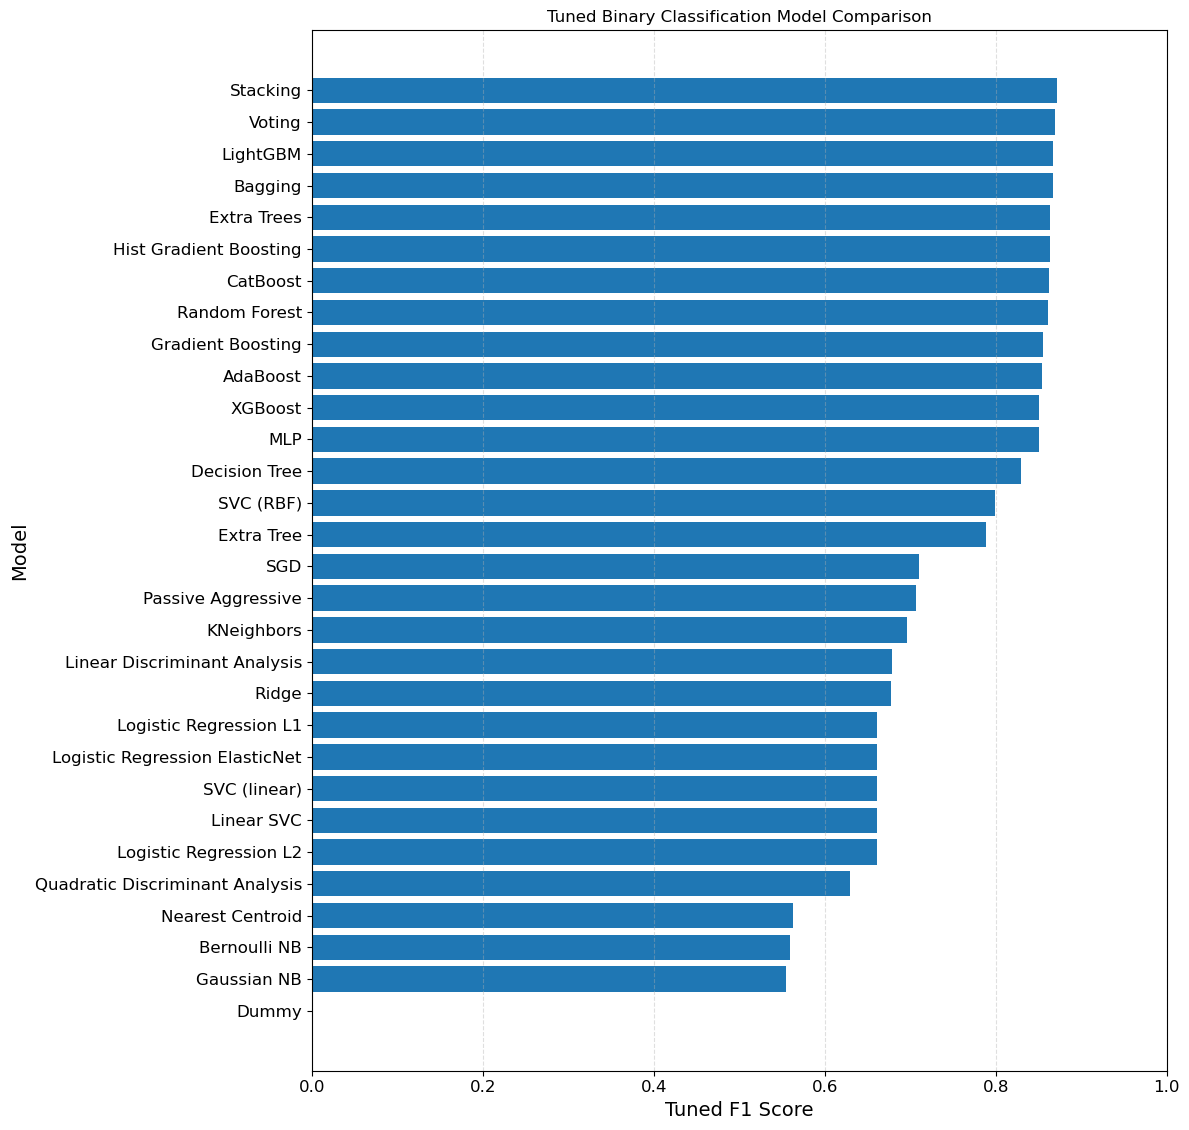

Saved: _exports\binary_classification_models\images\supervised_binary_classification_model_comparison.png


In [637]:
# ============================================================
# Export tuned binary classification model comparison plot
# ============================================================

if SAVE_PORTFOLIO_OUTPUTS:
    model_comparison_plot_df = results_df_sorted.copy()

    # Remove possible summary rows if they exist
    model_comparison_plot_df = model_comparison_plot_df[
        ~model_comparison_plot_df["Model"].astype(str).str.contains("Total", case=False, na=False)
    ].copy()

    # Main metric for the plot
    main_metric = "Tun_F1"

    if main_metric not in model_comparison_plot_df.columns:
        raise KeyError(f"{main_metric} column was not found in the final results table.")

    model_comparison_plot_df = model_comparison_plot_df.dropna(subset=[main_metric]).copy()

    model_comparison_plot_df["Model_Display"] = (
        model_comparison_plot_df["Model"]
        .astype(str)
        .str.replace(" Classifier", "", regex=False)
    )

    model_comparison_plot_df = model_comparison_plot_df.sort_values(
        main_metric,
        ascending=True
    )

    plt.figure(figsize=(12, max(7, 0.38 * len(model_comparison_plot_df))))

    plt.barh(
        model_comparison_plot_df["Model_Display"],
        model_comparison_plot_df[main_metric]
    )

    plt.xlabel("Tuned F1 Score")
    plt.ylabel("Model")
    plt.title("Tuned Binary Classification Model Comparison")
    plt.xlim(0, 1)
    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()

    output_path = BINARY_CLASSIFICATION_IMAGES_DIR / "supervised_binary_classification_model_comparison.png"

    plt.savefig(
        output_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", output_path)

In [638]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

best_model_name = results_df_sorted.loc[0, "Model"]
best_y_pred = best_pred_candidates.get(best_model_name)
best_y_score = best_score_candidates.get(best_model_name)

if best_y_pred is not None:
    print("Best model:", best_model_name)
    print(f"Sorting metric used: {SORT_BY}")
    print()

    print("Best model test Accuracy:", accuracy_score(y_test, best_y_pred))
    print("Best model test Precision:", precision_score(y_test, best_y_pred, zero_division=0))
    print("Best model test Recall:", recall_score(y_test, best_y_pred, zero_division=0))
    print("Best model test F1:", f1_score(y_test, best_y_pred, zero_division=0))

    if best_y_score is not None:
        print("Best model test ROC-AUC:", roc_auc_score(y_test, best_y_score))
    else:
        print("Best model test ROC-AUC: No saved score found")

    print()
    print("Confusion matrix:")
    print(confusion_matrix(y_test, best_y_pred))

else:
    print(f"No saved prediction found for: {best_model_name}")

Best model: Stacking Classifier
Sorting metric used: Tun_F1

Best model test Accuracy: 0.9122172784575454
Best model test Precision: 0.8815321477428181
Best model test Recall: 0.8624197002141327
Best model test F1: 0.8718711946962522
Best model test ROC-AUC: 0.9682386942638411

Confusion matrix:
[[6619  433]
 [ 514 3222]]


---

## <span style="color:#275edb">Prediction Comparison on Selected Test Samples</span>

In [639]:
### Final comparison table for random sample predictions

sample_pred_candidates = [
    # Baseline models
    ("Dummy Classifier", "dummy_sample_pred"),

    # Logistic / regularized linear models
    ("Logistic Regression L2", "log_reg_l2_sample_pred"),
    ("Logistic Regression L1", "log_reg_l1_sample_pred"),
    ("Logistic Regression ElasticNet", "log_reg_elastic_sample_pred"),
    ("Ridge Classifier", "ridge_sample_pred"),
    ("SGD Classifier", "sgd_sample_pred"),
    ("Passive Aggressive Classifier", "pa_sample_pred"),

    # SVM / margin-based models
    ("Linear SVC", "linear_svc_sample_pred"),
    ("SVC (linear)", "svc_linear_sample_pred"),
    ("SVC (RBF)", "svc_rbf_sample_pred"),

    # Distance-based models
    ("KNeighbors Classifier", "knn_sample_pred"),
    ("Nearest Centroid Classifier", "nearest_centroid_sample_pred"),

    # Naive Bayes models
    ("Gaussian NB", "gaussian_nb_sample_pred"),
    ("Bernoulli NB", "bernoulli_nb_sample_pred"),

    # Discriminant analysis models
    ("Linear Discriminant Analysis", "lda_sample_pred"),
    ("Quadratic Discriminant Analysis", "qda_sample_pred"),

    # Tree-based models
    ("Decision Tree Classifier", "dt_sample_pred"),
    ("Extra Tree Classifier", "extra_tree_sample_pred"),

    # Tree-based ensemble models
    ("Random Forest Classifier", "rf_sample_pred"),
    ("Extra Trees Classifier", "extra_trees_sample_pred"),

    # Boosting ensemble models
    ("AdaBoost Classifier", "ada_sample_pred"),
    ("Gradient Boosting Classifier", "gb_sample_pred"),
    ("Hist Gradient Boosting Classifier", "hgb_sample_pred"),
    ("XGBoost Classifier", "xgb_sample_pred"),
    ("LightGBM Classifier", "lgbm_sample_pred"),
    ("CatBoost Classifier", "cat_sample_pred"),

    # Neural models
    ("MLP Classifier", "mlp_sample_pred"),

    # Advanced ensemble models
    ("Bagging Classifier", "bagging_sample_pred"),
    ("Voting Classifier", "voting_sample_pred"),
    ("Stacking Classifier", "stacking_sample_pred")
]

comparison_dict = {
    "Original Label": y_test.loc[sample_idx]
}

for model_name, var_name in sample_pred_candidates:
    if var_name in globals():
        comparison_dict[model_name] = pd.Series(globals()[var_name]).reindex(sample_idx)

final_sample_comparison_df = pd.DataFrame(comparison_dict).T

### Reorder comparison table by tuned metric ranking
ordered_models = ["Original Label"] + [
    model_name
    for model_name in results_df_sorted["Model"]
    if model_name in final_sample_comparison_df.index
]

final_sample_comparison_df = final_sample_comparison_df.reindex(ordered_models)

In [640]:
selected_df = final_sample_comparison_df[selected_cols].copy()

# Remove " Classifier" from index labels
selected_df.index = selected_df.index.str.replace(" Classifier", "", regex=False)


# ---------------------------------------------------------
# Add summary column: how many values match Original Label
# ---------------------------------------------------------
original_values = selected_df.loc["Original Label"]

match_counts = selected_df.eq(original_values, axis=1).sum(axis=1)

selected_df["Correct Count"] = match_counts


# ---------------------------------------------------------
# Display column names as prices, without replacing real column IDs
# ---------------------------------------------------------
def sample_display_price_column(col):
    if col == "Correct Count":
        return "Correct Count"
    return f"${X_test.loc[col, 'price']:,.0f}"


def highlight_against_original_label(data):
    styles = pd.DataFrame("", index=data.index, columns=data.columns)

    price_cols = [col for col in data.columns if col != "Correct Count"]

    # Original Label row stays yellow
    styles.loc["Original Label", price_cols] = "background-color: #ffd966"

    # Correct Count column gets a neutral background
    styles.loc[:, "Correct Count"] = "background-color: #eeeeee; font-weight: bold"

    # Original values for each selected price column
    original_values = data.loc["Original Label", price_cols]

    # Compare every model row against Original Label
    for row_name in data.index:
        if row_name != "Original Label":
            for col in price_cols:
                if data.loc[row_name, col] == original_values[col]:
                    styles.loc[row_name, col] = "background-color: #e5fddb"
                else:
                    styles.loc[row_name, col] = "background-color: #f4cccc"

    return styles


selected_df.style.format("{:.0f}") \
    .format_index(sample_display_price_column, axis=1) \
    .apply(highlight_against_original_label, axis=None) \
    .map_index(
        lambda v: "background-color: #ffd966; text-align: left; white-space: nowrap;"
        if v == "Original Label"
        else "text-align: left; white-space: nowrap;",
        axis=0
    ) \
    .set_table_styles(
        [
            {
                "selector": "th.row_heading",
                "props": [
                    ("text-align", "left"),
                    ("white-space", "nowrap")
                ]
            },
            {
                "selector": "tbody tr:nth-child(even) td",
                "props": [("filter", "brightness(0.97)")]
            },
            {
                "selector": "tbody tr:nth-child(even) th",
                "props": [("filter", "brightness(0.97)")]
            },
            {
                "selector": "tbody tr:hover td",
                "props": [("filter", "brightness(0.90)")]
            },
            {
                "selector": "tbody tr:hover th",
                "props": [("filter", "brightness(0.90)")]
            }
        ],
        overwrite=False
    )

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265",Correct Count
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0,28
Stacking,1,0,1,1,1,1,1,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,1,1,1,1,0,0,25
Voting,1,0,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,1,1,1,1,0,0,24
LightGBM,1,0,1,1,1,1,1,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,1,1,1,1,0,0,25
Bagging,1,0,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,1,1,1,1,0,0,24
Extra Trees,1,0,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,1,1,1,1,0,0,24
Hist Gradient Boosting,1,0,1,1,1,1,1,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,1,1,1,1,0,0,25
CatBoost,1,0,1,1,1,1,1,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,1,1,1,1,0,0,25
Random Forest,1,0,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,1,1,1,1,0,0,24
Gradient Boosting,1,1,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,1,1,1,1,0,0,23


In [641]:
# ============================================================
# Export selected test sample predictions as CSV
# ============================================================

if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_RESULTS_DIR / "supervised_binary_classification_selected_test_sample_predictions.csv"

    selected_test_sample_predictions = selected_df.copy()

    selected_test_sample_predictions.to_csv(
        output_path,
        index=True,
        index_label="Model",
        encoding="utf-8-sig"
    )

    print("Saved:", output_path)

Saved: _exports\binary_classification_models\results\supervised_binary_classification_selected_test_sample_predictions.csv


### Correctness Check for the Best Binary Classification Model

In [642]:
comparison_model_name = results_df_sorted.loc[0, "Model"]   # Default: best model from tuned metric ranking
comparison_model_name = comparison_model_name.replace(" Classifier", "")
# comparison_model_name = "Random Forest"                   # Example: change later if needed


# Remove Correct Count column if it exists
comparison_source_df = selected_df.drop(columns=["Correct Count"], errors="ignore")

original_row = comparison_source_df.loc[["Original Label"]]
model_row = comparison_source_df.loc[[comparison_model_name]]

correct_row = (model_row.iloc[0] == original_row.iloc[0]).astype(int).to_frame().T
correct_row.index = ["Correct"]

comparison_df = pd.concat([original_row, model_row, correct_row])


def highlight_correct_cells(value):
    if value == 0:
        return "background-color: #f4cccc"   # light red
    elif value == 1:
        return "background-color: #e5fddb"   # light green
    return ""


comparison_df.style \
    .format_index(sample_display_price_column, axis=1) \
    .format(
        "{:.0f}",
        subset=pd.IndexSlice[["Original Label", comparison_model_name], :]
    ) \
    .format(
        lambda value: "True" if value == 1 else "False",
        subset=pd.IndexSlice[["Correct"], :]
    ) \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map(
        highlight_correct_cells,
        subset=pd.IndexSlice[["Correct"], :]
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label"
        else "background-color: #e5fddb" if v == "Correct"
        else "",
        axis=0
    ) \
    .set_table_styles(
        [
            {
                "selector": "th.row_heading",
                "props": [
                    ("text-align", "left"),
                    ("white-space", "nowrap")
                ]
            }
        ],
        overwrite=False
    )

,$605,$743,$764,$830,$878,$978,"$1,041","$2,024","$2,171","$2,604","$2,680","$2,959","$3,881","$4,486","$4,637","$4,875","$5,181","$5,950","$6,337","$6,814","$7,518","$7,553","$8,579","$8,743","$9,160","$14,584","$14,844","$17,265"
Original Label,1,0,1,1,1,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,1,1,1,0,0
Stacking,1,0,1,1,1,1,1,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,1,1,1,1,0,0
Correct,True,True,True,True,True,True,True,True,True,True,False,True,False,True,True,True,True,False,True,True,True,True,True,True,True,True,True,True


In [643]:
# ============================================================
# Export best model correctness check as CSV
# ============================================================

if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_RESULTS_DIR / "supervised_binary_classification_best_model_correctness_check.csv"

    best_model_correctness_check = comparison_df.copy()

    best_model_correctness_check.to_csv(
        output_path,
        index=True,
        index_label="Row",
        encoding="utf-8-sig"
    )

    print("Saved:", output_path)

Saved: _exports\binary_classification_models\results\supervised_binary_classification_best_model_correctness_check.csv


## <span style="color:#275edb">Prediction Agreement and Error Summary</span>

In [644]:
final_full_comparison_df = pd.DataFrame({
    "Original Label": y_test,

    "Dummy": pd.Series(dummy_pred_test, index=X_test.index),

    "Logistic Regression L2": pd.Series(log_reg_l2_pred_test, index=X_test.index),
    "Logistic Regression L1": pd.Series(log_reg_l1_pred_test, index=X_test.index),
    "Logistic Regression ElasticNet": pd.Series(log_reg_elastic_pred_test, index=X_test.index),

    "Ridge": pd.Series(ridge_pred_test, index=X_test.index),
    "SGD": pd.Series(sgd_pred_test, index=X_test.index),
    "Passive Aggressive": pd.Series(pa_pred_test, index=X_test.index),

    "Linear SVC": pd.Series(linear_svc_pred_test, index=X_test.index),
    "SVC (linear)": pd.Series(svc_linear_pred_test, index=X_test.index),
    "SVC (RBF)": pd.Series(svc_rbf_pred_test, index=X_test.index),

    "KNeighbors": pd.Series(knn_pred_test, index=X_test.index),
    "Nearest Centroid": pd.Series(nearest_centroid_pred_test, index=X_test.index),

    "Gaussian NB": pd.Series(gaussian_nb_pred_test, index=X_test.index),
    "Bernoulli NB": pd.Series(bernoulli_nb_pred_test, index=X_test.index),

    "Linear Discriminant Analysis": pd.Series(lda_pred_test, index=X_test.index),
    "Quadratic Discriminant Analysis": pd.Series(qda_pred_test, index=X_test.index),

    "Decision Tree": pd.Series(dt_pred_test, index=X_test.index),
    "Extra Tree": pd.Series(extra_tree_pred_test, index=X_test.index),

    "Random Forest": pd.Series(rf_pred_test, index=X_test.index),
    "Extra Trees": pd.Series(extra_trees_pred_test, index=X_test.index),

    "AdaBoost": pd.Series(ada_pred_test, index=X_test.index),
    "Gradient Boosting": pd.Series(gb_pred_test, index=X_test.index),
    "Hist Gradient Boosting": pd.Series(hgb_pred_test, index=X_test.index),

    "XGBoost": pd.Series(xgb_pred_test, index=X_test.index),
    "LightGBM": pd.Series(lgbm_pred_test, index=X_test.index),
    "CatBoost": pd.Series(cat_pred_test, index=X_test.index),

    "MLP": pd.Series(mlp_pred_test, index=X_test.index),

    "Bagging": pd.Series(bagging_pred_test, index=X_test.index),
    "Voting": pd.Series(voting_pred_test, index=X_test.index),
    "Stacking": pd.Series(stacking_pred_test, index=X_test.index),
}).T

In [645]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# --- 1) Prepare true labels ---
true_labels = pd.Series(y_test, index=X_test.index)

# --- 2) Calculate classification summary from BEST / TUNED predictions ---
summary_rows = []

for model_name, pred_values in best_pred_candidates.items():
    if pred_values is None:
        continue

    clean_model_name = model_name.replace(" Classifier", "")

    pred_labels = pd.Series(pred_values, index=X_test.index).loc[true_labels.index]

    correct = pred_labels == true_labels
    incorrect = ~correct

    actual_0 = (true_labels == 0).sum()
    actual_1 = (true_labels == 1).sum()

    predicted_0 = (pred_labels == 0).sum()
    predicted_1 = (pred_labels == 1).sum()

    true_positive = ((pred_labels == 1) & (true_labels == 1)).sum()
    true_negative = ((pred_labels == 0) & (true_labels == 0)).sum()

    false_positive = ((pred_labels == 1) & (true_labels == 0)).sum()
    false_negative = ((pred_labels == 0) & (true_labels == 1)).sum()

    accuracy = accuracy_score(true_labels, pred_labels)
    precision = precision_score(true_labels, pred_labels, zero_division=0)
    recall = recall_score(true_labels, pred_labels, zero_division=0)
    f1 = f1_score(true_labels, pred_labels, zero_division=0)

    score_values = best_score_candidates.get(model_name)

    if score_values is not None and true_labels.nunique() == 2:
        score_series = pd.Series(score_values, index=X_test.index).loc[true_labels.index]
        roc_auc = roc_auc_score(true_labels, score_series)
    else:
        roc_auc = np.nan

    summary_rows.append({
        "Model": clean_model_name,
        "Count": len(true_labels),
        "Actual_0": actual_0,
        "Actual_1": actual_1,
        "Predicted_0": predicted_0,
        "Predicted_1": predicted_1,
        "Correct": correct.sum(),
        "Incorrect": incorrect.sum(),
        "True_Negative": true_negative,
        "True_Positive": true_positive,
        "False_Negative": false_negative,
        "False_Positive": false_positive,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Roc_Auc": roc_auc
    })

classification_summary_df = pd.DataFrame(summary_rows).set_index("Model")


# --- 3) Assign model_type with map() ---
model_type_map = (
    results_df_with_total[["Model", "Model_type"]]
    .assign(Model=lambda df: df["Model"].str.replace(" Classifier", "", regex=False))
    .drop_duplicates(subset="Model")
    .set_index("Model")["Model_type"]
)

classification_summary_df.insert(
    0,
    "Model_type",
    classification_summary_df.index.map(model_type_map)
)


# --- 4) Reorder by main results ranking ---
ordered_summary_models = [
    model_name.replace(" Classifier", "")
    for model_name in results_df_sorted["Model"]
    if model_name.replace(" Classifier", "") in classification_summary_df.index
]

classification_summary_df = classification_summary_df.reindex(ordered_summary_models)


# --- 5) Move Model from index to column and set final column order ---
classification_summary_df = classification_summary_df.reset_index()

classification_summary_df = classification_summary_df[
    [
        "Model",
        "Model_type",
        "Count",
        "Actual_0",
        "Actual_1",
        "Predicted_0",
        "Predicted_1",
        "Correct",
        "Incorrect",
        "True_Negative",
        "True_Positive",
        "False_Negative",
        "False_Positive",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Roc_Auc"
    ]
]

In [646]:
# --- 7) Stylized display ---
styled_output = (
    classification_summary_df.style
        .hide(axis="index")
        .format({
            "Count": "{:.0f}",
            "Actual_0": "{:.0f}",
            "Actual_1": "{:.0f}",
            "Predicted_0": "{:.0f}",
            "Predicted_1": "{:.0f}",
            "Correct": "{:.0f}",
            "Incorrect": "{:.0f}",
            "True_Negative": "{:.0f}",
            "True_Positive": "{:.0f}",
            "False_Negative": "{:.0f}",
            "False_Positive": "{:.0f}",
            "Accuracy": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1": "{:.4f}",
            "Roc_Auc": "{:.4f}"
        }, na_rep="—")
        .set_properties(
            subset=pd.IndexSlice[:, ["Model"]],
            **{"text-align": "left", "white-space": "nowrap", "font-weight": "bold"}
        )
        .set_properties(
            subset=pd.IndexSlice[:, ["Model", "Model_type"]],
            **{"text-align": "left", "white-space": "nowrap"}
        )
        .set_properties(
            subset=pd.IndexSlice[:, ["Count", "Actual_0", "Actual_1", "Predicted_0", "Predicted_1"]],
            **{"background-color": "#f3f3f3"}
        )
        .set_properties(
            subset=pd.IndexSlice[:, ["Correct", "True_Positive", "True_Negative"]],
            **{"background-color": "#e5fddb"}
        )
        .set_properties(
            subset=pd.IndexSlice[:, ["Incorrect", "False_Positive", "False_Negative"]],
            **{"background-color": "#f8e6e6"}
        )
        .set_properties(
            subset=pd.IndexSlice[:, ["Accuracy", "Precision", "Recall", "F1", "Roc_Auc"]],
            **{"background-color": "#d7f5cc"}
        )
        .set_table_styles(
            [
                {"selector": "th.col_heading", "props": [("text-align", "left"), ("white-space", "nowrap")]},
                {"selector": "th, td", "props": [("border", "1px solid #d0d0d0")]},
                {"selector": "table", "props": [("border-collapse", "collapse")]},
                {"selector": "tbody tr:nth-child(even) td", "props": [("filter", "brightness(0.97)")]},
                {"selector": "tbody tr:hover td", "props": [("filter", "brightness(0.90)")]}
            ],
            overwrite=False
        )
)

styled_output

Model,Model_type,Count,Actual_0,Actual_1,Predicted_0,Predicted_1,Correct,Incorrect,True_Negative,True_Positive,False_Negative,False_Positive,Accuracy,Precision,Recall,F1,Roc_Auc
Stacking,Advanced ensemble,10788,7052,3736,7133,3655,9841,947,6619,3222,514,433,0.9122,0.8815,0.8624,0.8719,0.9682
Voting,Advanced ensemble,10788,7052,3736,7270,3518,9836,952,6685,3151,585,367,0.9118,0.8957,0.8434,0.8688,0.9673
LightGBM,Boosting ensemble,10788,7052,3736,7208,3580,9818,970,6645,3173,563,407,0.9101,0.8863,0.8493,0.8674,0.9649
Bagging,Advanced ensemble,10788,7052,3736,7254,3534,9820,968,6669,3151,585,383,0.9103,0.8916,0.8434,0.8669,0.9665
Extra Trees,Tree-based ensemble,10788,7052,3736,7236,3552,9796,992,6648,3148,588,404,0.9080,0.8863,0.8426,0.8639,0.9636
Hist Gradient Boosting,Boosting ensemble,10788,7052,3736,7214,3574,9788,1000,6633,3155,581,419,0.9073,0.8828,0.8445,0.8632,0.9635
CatBoost,Boosting ensemble,10788,7052,3736,7241,3547,9785,1003,6645,3140,596,407,0.9070,0.8853,0.8405,0.8623,0.9642
Random Forest,Tree-based ensemble,10788,7052,3736,7272,3516,9778,1010,6657,3121,615,395,0.9064,0.8877,0.8354,0.8607,0.9643
Gradient Boosting,Boosting ensemble,10788,7052,3736,7266,3522,9740,1048,6635,3105,631,417,0.9029,0.8816,0.8311,0.8556,0.9623
AdaBoost,Boosting ensemble,10788,7052,3736,7209,3579,9719,1069,6596,3123,613,456,0.9009,0.8726,0.8359,0.8539,0.9615


In [647]:
# ============================================================
# Export prediction agreement and error summary as CSV
# ============================================================

if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_RESULTS_DIR / "supervised_binary_classification_prediction_agreement_error_summary.csv"

    prediction_agreement_error_summary = classification_summary_df.copy()

    prediction_agreement_error_summary.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig"
    )

    print("Saved:", output_path)

Saved: _exports\binary_classification_models\results\supervised_binary_classification_prediction_agreement_error_summary.csv


## <span style="color:#275edb">Best Model Performance by Price Range</span>

In [648]:
# Column used for price range analysis
price_column = "price"

# Number of bins for histogram
price_bins = 500

# Maximum price shown on plots
price_max = 19000

# Size of each price range
price_cat_size = 1500

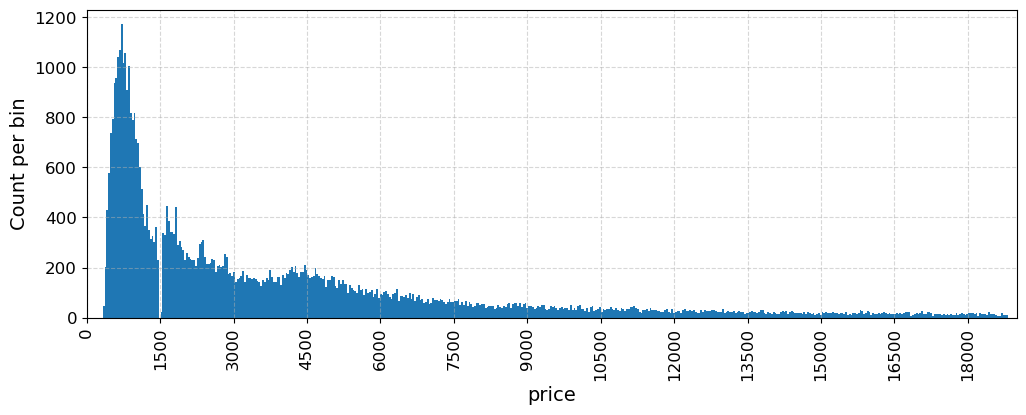

In [649]:
# Plot price distribution
diamonds[price_column].hist(bins=price_bins, figsize=(12, 4))

plt.xlim(0, price_max)
plt.xticks(np.arange(0, price_max + 1, price_cat_size), rotation=90)

plt.xlabel(price_column)
plt.ylabel("Count per bin")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [650]:
diamonds["price_cat"] = pd.cut(
    diamonds[price_column],
    bins=np.arange(0, price_max + price_cat_size, price_cat_size),
    labels=[
        f"{start}-{start + price_cat_size}"
        for start in np.arange(0, price_max, price_cat_size)
    ],
    include_lowest=True,
    right=True
)

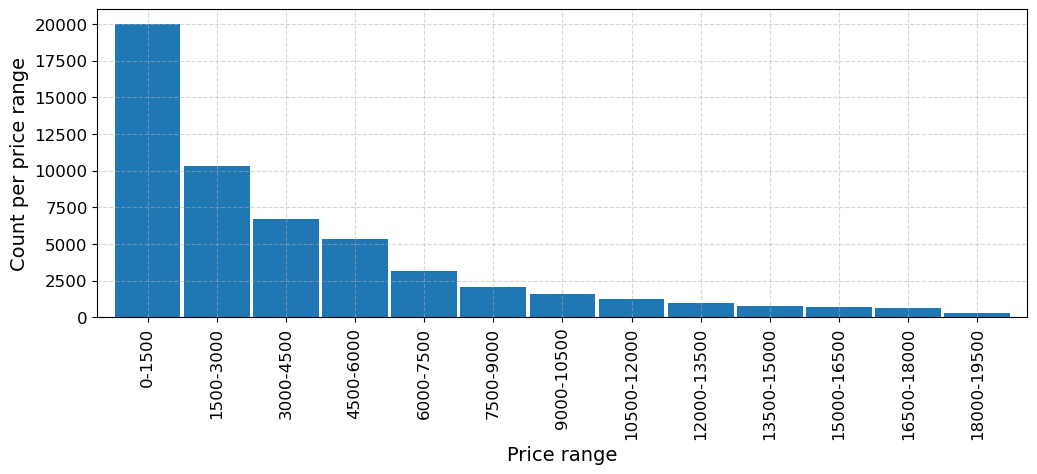

In [651]:
diamonds["price_cat"].value_counts().sort_index().plot.bar(
    figsize=(12, 4),
    width=0.95
)

plt.xlabel("Price range")
plt.ylabel("Count per price range")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [652]:
# Create tuned models dictionary only from variables that already exist
TUNED_MODELS = {}

model_candidates = [
    # Baseline models
    ("Dummy Classifier", "dummy_clf"),

    # Logistic / regularized linear models
    ("Logistic Regression L2", "log_reg_l2_best_tuning"),
    ("Logistic Regression L1", "log_reg_l1_best_tuning"),
    ("Logistic Regression ElasticNet", "log_reg_elastic_best_tuning"),
    ("Ridge Classifier", "ridge_best_tuning"),
    ("SGD Classifier", "sgd_best_tuning"),
    ("Passive Aggressive Classifier", "pa_best_tuning"),

    # SVM / margin-based models
    ("Linear SVC", "linear_svc_best_tuning"),
    ("SVC (linear)", "svc_linear_best_tuning"),
    ("SVC (RBF)", "svc_rbf_best_tuning"),

    # Distance-based models
    ("KNeighbors Classifier", "knn_best_tuning"),
    ("Nearest Centroid Classifier", "nearest_centroid_best_tuning"),

    # Naive Bayes models
    ("Gaussian NB", "gaussian_nb_best_tuning"),
    ("Bernoulli NB", "bernoulli_nb_best_tuning"),

    # Discriminant analysis models
    ("Linear Discriminant Analysis", "lda_best_tuning"),
    ("Quadratic Discriminant Analysis", "qda_best_tuning"),

    # Tree-based models
    ("Decision Tree Classifier", "dt_best_tuning"),
    ("Extra Tree Classifier", "extra_tree_best_tuning"),

    # Tree-based ensemble models
    ("Random Forest Classifier", "rf_best_tuning"),
    ("Extra Trees Classifier", "extra_trees_best_tuning"),

    # Boosting ensemble models
    ("AdaBoost Classifier", "ada_best_tuning"),
    ("Gradient Boosting Classifier", "gb_best_tuning"),
    ("Hist Gradient Boosting Classifier", "hgb_best_tuning"),
    ("XGBoost Classifier", "xgb_best_tuning"),
    ("LightGBM Classifier", "lgbm_best_tuning"),
    ("CatBoost Classifier", "cat_best_tuning"),

    # Neural models
    ("MLP Classifier", "mlp_best_tuning"),

    # Advanced ensemble models
    ("Bagging Classifier", "bagging_best_tuning"),
    ("Voting Classifier", "voting_best_tuning"),
    ("Stacking Classifier", "stacking_best_tuning")
]

for model_name, var_name in model_candidates:
    if var_name in globals():
        TUNED_MODELS[model_name] = globals()[var_name]

best_model_name = results_df_sorted.loc[0, "Model"]
best_model = TUNED_MODELS[best_model_name]

In [653]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Predict with the best model
best_y_pred = best_model.predict(X_test)

# Get score / probability for ROC-AUC if available
if hasattr(best_model, "predict_proba"):
    best_y_score = best_model.predict_proba(X_test)[:, 1]
elif hasattr(best_model, "decision_function"):
    best_y_score = best_model.decision_function(X_test)
else:
    best_y_score = None


# Create evaluation dataframe
range_eval_df = pd.DataFrame({
    "price": X_test[price_column].reset_index(drop=True),
    "actual": pd.Series(y_test).reset_index(drop=True),
    "predicted": pd.Series(best_y_pred).reset_index(drop=True)
})

if best_y_score is not None:
    range_eval_df["score"] = pd.Series(best_y_score).reset_index(drop=True)


# Create price bins
actual_price_max = int(diamonds[price_column].max())

bin_edges = np.arange(0, price_max + price_cat_size, price_cat_size)

bin_labels = [
    f"{bin_edges[i]}-{bin_edges[i+1]}"
    for i in range(len(bin_edges) - 2)
] + [
    f"{bin_edges[-2]}-{actual_price_max}"
]

range_eval_df["Price_Category"] = pd.cut(
    range_eval_df["price"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True,
    right=True
)

# Remove rows that did not fall into any price bin
range_eval_df = range_eval_df.dropna(subset=["Price_Category"]).copy()


def calculate_range_metrics(group):
    # Safety check for empty groups
    if len(group) == 0:
        return pd.Series({
            "Count": 0,
            "Actual_0": 0,
            "Actual_1": 0,
            "Predicted_0": 0,
            "Predicted_1": 0,
            "True_Negative": 0,
            "True_Positive": 0,
            "False_Negative": 0,
            "False_Positive": 0,
            "Accuracy": np.nan,
            "Precision": np.nan,
            "Recall": np.nan,
            "F1": np.nan,
            "Roc_Auc": np.nan,
            "Actual_high_clarity_rate": np.nan,
            "Predicted_high_clarity_rate": np.nan
        })

    y_true = group["actual"]
    y_pred = group["predicted"]

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # ROC-AUC only works if both classes are present in the group
    if "score" in group.columns and y_true.nunique() == 2:
        roc_auc = roc_auc_score(y_true, group["score"])
    else:
        roc_auc = np.nan

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return pd.Series({
        "Count": len(group),

        "Actual_0": (y_true == 0).sum(),
        "Actual_1": (y_true == 1).sum(),
        "Predicted_0": (y_pred == 0).sum(),
        "Predicted_1": (y_pred == 1).sum(),

        "True_Negative": tn,
        "True_Positive": tp,
        "False_Negative": fn,
        "False_Positive": fp,

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Roc_Auc": roc_auc,
        
        "Actual_high_clarity_rate": (y_true == 1).mean(),
        "Predicted_high_clarity_rate": (y_pred == 1).mean()
    })


range_metrics_df = (
    range_eval_df
    .groupby("Price_Category", observed=True)   # Important: only use non-empty observed bins
    .apply(calculate_range_metrics)
    .reset_index()
)

In [654]:
# --- Stylized display for price range metrics ---

styled_range_metrics = (
    range_metrics_df.style
        .hide(axis="index")
        .format(
            {
                "Count": "{:.0f}",
                "Actual_0": "{:.0f}",
                "Actual_1": "{:.0f}",
                "Predicted_0": "{:.0f}",
                "Predicted_1": "{:.0f}",
                "True_Positive": "{:.0f}",
                "True_Negative": "{:.0f}",
                "False_Positive": "{:.0f}",
                "False_Negative": "{:.0f}",
                "Accuracy": "{:.4f}",
                "Precision": "{:.4f}",
                "Recall": "{:.4f}",
                "F1": "{:.4f}",
                "Roc_Auc": "{:.4f}",
                "Actual_high_clarity_rate": "{:.4f}",
                "Predicted_high_clarity_rate": "{:.4f}"
            },
            na_rep="—"
        )

        # Price range column
        .set_properties(
            subset=pd.IndexSlice[:, ["Price_Category"]],
            **{
                "text-align": "left",
                "white-space": "nowrap",
                "background-color": "#eeeeee",
                "font-weight": "bold"
            }
        )

        # Main performance metrics
        .set_properties(
            subset=pd.IndexSlice[:, ["Accuracy", "Precision", "Recall", "F1", "Roc_Auc"]],
            **{"background-color": "#d7f5cc"}
        )

        # Correct confusion matrix parts
        .set_properties(
            subset=pd.IndexSlice[:, ["True_Positive", "True_Negative"]],
            **{"background-color": "#e5fddb"}
        )

        # Incorrect confusion matrix parts
        .set_properties(
            subset=pd.IndexSlice[:, ["False_Positive", "False_Negative"]],
            **{"background-color": "#f8e6e6"}
        )

        # Count columns
        .set_properties(
            subset=pd.IndexSlice[:, ["Count", "Actual_0", "Actual_1", "Predicted_0", "Predicted_1"]],
            **{"background-color": "#f3f3f3"}
        )

        # Rate columns
        .set_properties(
            subset=pd.IndexSlice[:, ["Actual_high_clarity_rate", "Predicted_high_clarity_rate"]],
            **{"background-color": "#e8f1ff"}
        )

        # Table style
        .set_table_styles(
            [
                {
                    "selector": "th.col_heading",
                    "props": [
                        ("text-align", "left"),
                        ("white-space", "nowrap")
                    ]
                },
                {
                    "selector": "th, td",
                    "props": [
                        ("border", "1px solid #d0d0d0")
                    ]
                },
                {
                    "selector": "table",
                    "props": [
                        ("border-collapse", "collapse")
                    ]
                },
                {
                    "selector": "tbody tr:nth-child(even) td",
                    "props": [
                        ("filter", "brightness(0.97)")
                    ]
                },
                {
                    "selector": "tbody tr:hover td",
                    "props": [
                        ("filter", "brightness(0.90)")
                    ]
                }
            ],
            overwrite=False
        )
)

print("Best model:", best_model_name)
styled_range_metrics

Best model: Stacking Classifier


Price_Category,Count,Actual_0,Actual_1,Predicted_0,Predicted_1,True_Negative,True_Positive,False_Negative,False_Positive,Accuracy,Precision,Recall,F1,Roc_Auc,Actual_high_clarity_rate,Predicted_high_clarity_rate
0-1500,3925,2088,1837,2068,1857,1929,1698,139,159,0.9241,0.9144,0.9243,0.9193,0.9772,0.4680,0.4731
1500-3000,2131,1393,738,1406,725,1288,620,118,105,0.8954,0.8552,0.8401,0.8476,0.9548,0.3463,0.3402
3000-4500,1332,1060,272,1092,240,1020,200,72,40,0.9159,0.8333,0.7353,0.7812,0.9645,0.2042,0.1802
4500-6000,1060,939,121,969,91,913,65,56,26,0.9226,0.7143,0.5372,0.6132,0.9618,0.1142,0.0858
6000-7500,617,458,159,475,142,429,113,46,29,0.8784,0.7958,0.7107,0.7508,0.9266,0.2577,0.2301
7500-9000,438,253,185,243,195,224,166,19,29,0.8904,0.8513,0.8973,0.8737,0.9504,0.4224,0.4452
9000-10500,317,188,129,184,133,168,113,16,20,0.8864,0.8496,0.8760,0.8626,0.9640,0.4069,0.4196
10500-12000,255,150,105,154,101,142,93,12,8,0.9216,0.9208,0.8857,0.9029,0.9765,0.4118,0.3961
12000-13500,207,144,63,149,58,139,53,10,5,0.9275,0.9138,0.8413,0.8760,0.9674,0.3043,0.2802
13500-15000,161,115,46,114,47,109,41,5,6,0.9317,0.8723,0.8913,0.8817,0.9703,0.2857,0.2919


In [655]:
# ============================================================
# Export best model performance by price range as CSV
# ============================================================

if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_RESULTS_DIR / "supervised_binary_classification_best_model_performance_by_price_range.csv"

    best_model_performance_by_price_range = range_metrics_df.copy()

    best_model_performance_by_price_range.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig"
    )

    print("Saved:", output_path)

Saved: _exports\binary_classification_models\results\supervised_binary_classification_best_model_performance_by_price_range.csv


## <span style="color:#275edb">High-Price Classification Performance</span>

In [656]:
high_price_threshold = 15000

In [657]:
from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ---------------------------------------------------------
# Define high-price diamonds based on the original price feature
# ---------------------------------------------------------
high_price_mask = X_test["price"] > high_price_threshold

# Convert predictions and scores to Series for safe indexing
best_y_pred_series = pd.Series(best_y_pred, index=X_test.index)

high_price_y_true = y_test.loc[high_price_mask]
high_price_y_pred = best_y_pred_series.loc[high_price_mask]

if best_y_score is not None:
    best_y_score_series = pd.Series(best_y_score, index=X_test.index)
    high_price_y_score = best_y_score_series.loc[high_price_mask]
else:
    high_price_y_score = None


# ---------------------------------------------------------
# Calculate metrics
# ---------------------------------------------------------
high_price_accuracy = accuracy_score(high_price_y_true, high_price_y_pred)
high_price_precision = precision_score(high_price_y_true, high_price_y_pred, zero_division=0)
high_price_recall = recall_score(high_price_y_true, high_price_y_pred, zero_division=0)
high_price_f1 = f1_score(high_price_y_true, high_price_y_pred, zero_division=0)

if high_price_y_score is not None and high_price_y_true.nunique() == 2:
    high_price_roc_auc = roc_auc_score(high_price_y_true, high_price_y_score)
else:
    high_price_roc_auc = np.nan


# ---------------------------------------------------------
# Summary metrics table
# ---------------------------------------------------------
high_price_metrics_df = pd.DataFrame({
    "Model": [best_model_name],
    "Price_Threshold": [high_price_threshold],
    "High_Price_Samples": [high_price_mask.sum()],
    "Accuracy": [high_price_accuracy],
    "Precision": [high_price_precision],
    "Recall": [high_price_recall],
    "F1": [high_price_f1],
    "ROC_AUC": [high_price_roc_auc]
})

styled_high_price_metrics = (
    high_price_metrics_df.style
        .format({
            "Price_Threshold": "${:,.0f}",
            "High_Price_Samples": "{:.0f}",
            "Accuracy": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1": "{:.4f}",
            "ROC_AUC": "{:.4f}"
        }, na_rep="—")
        .set_properties(
            subset=pd.IndexSlice[:, ["Model"]],
            **{"text-align": "left", "white-space": "nowrap", "font-weight": "bold"}
        )
        .set_properties(
            subset=pd.IndexSlice[:, ["Price_Threshold", "High_Price_Samples"]],
            **{"background-color": "#f3f3f3"}
        )
        .set_properties(
            subset=pd.IndexSlice[:, ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]],
            **{"background-color": "#d7f5cc"}
        )
        .set_table_styles(
            [
                {"selector": "th.col_heading", "props": [("text-align", "left"), ("white-space", "nowrap")]},
                {"selector": "th, td", "props": [("border", "1px solid #d0d0d0")]},
                {"selector": "table", "props": [("border-collapse", "collapse")]}
            ],
            overwrite=False
        )
)


# ---------------------------------------------------------
# Class distribution table
# ---------------------------------------------------------
original_distribution = high_price_y_true.value_counts().sort_index().reindex([0, 1], fill_value=0)
predicted_distribution = high_price_y_pred.value_counts().sort_index().reindex([0, 1], fill_value=0)

high_price_distribution_df = pd.DataFrame({
    "Original": original_distribution,
    "Predicted": predicted_distribution
})

high_price_distribution_df.index.name = "Class"

styled_high_price_distribution = (
    high_price_distribution_df.style
        .format("{:.0f}")
        .set_properties(
            subset=pd.IndexSlice[:, ["Original"]],
            **{"background-color": "#fff2cc"}
        )
        .set_properties(
            subset=pd.IndexSlice[:, ["Predicted"]],
            **{"background-color": "#e8f1ff"}
        )
        .map_index(
            lambda v: "text-align: left; white-space: nowrap;",
            axis=0
        )
        .set_table_styles(
            [
                {"selector": "th.row_heading", "props": [("text-align", "left"), ("white-space", "nowrap")]},
                {"selector": "th.col_heading", "props": [("text-align", "left"), ("white-space", "nowrap")]},
                {"selector": "th, td", "props": [("border", "1px solid #d0d0d0")]},
                {"selector": "table", "props": [("border-collapse", "collapse")]}
            ],
            overwrite=False
        )
)


# ---------------------------------------------------------
# Confusion matrix table
# ---------------------------------------------------------
high_price_cm = confusion_matrix(
    high_price_y_true,
    high_price_y_pred,
    labels=[0, 1]
)

high_price_cm_df = pd.DataFrame(
    high_price_cm,
    index=["Original 0", "Original 1"],
    columns=["Predicted 0", "Predicted 1"]
)

styled_high_price_cm = (
    high_price_cm_df.style
        .format("{:.0f}")
        .set_properties(
            subset=pd.IndexSlice[["Original 0"], ["Predicted 0"]],
            **{"background-color": "#e5fddb", "font-weight": "bold"}
        )
        .set_properties(
            subset=pd.IndexSlice[["Original 1"], ["Predicted 1"]],
            **{"background-color": "#e5fddb", "font-weight": "bold"}
        )
        .set_properties(
            subset=pd.IndexSlice[["Original 0"], ["Predicted 1"]],
            **{"background-color": "#f8e6e6", "font-weight": "bold"}
        )
        .set_properties(
            subset=pd.IndexSlice[["Original 1"], ["Predicted 0"]],
            **{"background-color": "#f8e6e6", "font-weight": "bold"}
        )
        .map_index(
            lambda v: "text-align: left; white-space: nowrap;",
            axis=0
        )
        .set_table_styles(
            [
                {"selector": "th.row_heading", "props": [("text-align", "left"), ("white-space", "nowrap")]},
                {"selector": "th.col_heading", "props": [("text-align", "left"), ("white-space", "nowrap")]},
                {"selector": "th, td", "props": [("border", "1px solid #d0d0d0")]},
                {"selector": "table", "props": [("border-collapse", "collapse")]}
            ],
            overwrite=False
        )
)

# ---------------------------------------------------------
# Display all styled tables
# ---------------------------------------------------------
print("1) High-Price Metrics Summary - best model performance above the selected price threshold")
display(styled_high_price_metrics)
print("")

print("2) High-Price Class Distribution - original vs predicted class counts")
display(styled_high_price_distribution)
print("")

print("3) High-Price Confusion Matrix - correct and incorrect predictions above the selected price threshold")
display(styled_high_price_cm)

1) High-Price Metrics Summary - best model performance above the selected price threshold


,Model,Price_Threshold,High_Price_Samples,Accuracy,Precision,Recall,F1,ROC_AUC
0,Stacking Classifier,"$15,000",345,0.9217,0.9091,0.7407,0.8163,0.9484



2) High-Price Class Distribution - original vs predicted class counts


,Original,Predicted
Class,,
0,264,279
1,81,66



3) High-Price Confusion Matrix - correct and incorrect predictions above the selected price threshold


,Predicted 0,Predicted 1
Original 0,258,6
Original 1,21,60


In [658]:
# ============================================================
# Export high-price classification performance tables as CSV
# ============================================================

if SAVE_PORTFOLIO_OUTPUTS:
    # 1) High-price metrics summary
    output_path = BINARY_CLASSIFICATION_RESULTS_DIR / "supervised_binary_classification_high_price_metrics_summary.csv"

    high_price_metrics_df.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig"
    )

    print("Saved:", output_path)


    # 2) High-price class distribution
    output_path = BINARY_CLASSIFICATION_RESULTS_DIR / "supervised_binary_classification_high_price_class_distribution.csv"

    high_price_distribution_df.to_csv(
        output_path,
        index=True,
        encoding="utf-8-sig"
    )

    print("Saved:", output_path)


    # 3) High-price confusion matrix
    output_path = BINARY_CLASSIFICATION_RESULTS_DIR / "supervised_binary_classification_high_price_confusion_matrix.csv"

    high_price_cm_df.to_csv(
        output_path,
        index=True,
        encoding="utf-8-sig"
    )

    print("Saved:", output_path)

Saved: _exports\binary_classification_models\results\supervised_binary_classification_high_price_metrics_summary.csv
Saved: _exports\binary_classification_models\results\supervised_binary_classification_high_price_class_distribution.csv
Saved: _exports\binary_classification_models\results\supervised_binary_classification_high_price_confusion_matrix.csv


## <span style="color:#275edb">Binary Classification Error Analysis</span>

### Actual vs Predicted Classes for the Best Binary Classification Model
**This plot shows how the model’s predicted class labels compare to the true class labels.**
- 0 means lower clarity.
- 1 means higher clarity.
- Correct predictions are where the actual and predicted labels are the same.
- Wrong predictions appear as false positives or false negatives.

In [659]:
# Convert true and predicted labels to aligned Series
best_y_true = pd.Series(y_test).reset_index(drop=True)
best_y_pred_series = pd.Series(best_y_pred).reset_index(drop=True)

# Classification error:
#  0 = correct prediction
#  1 = false positive  -> predicted 1, actual 0
# -1 = false negative  -> predicted 0, actual 1
best_prediction_errors = best_y_pred_series - best_y_true

top_model_names = [
    model_name
    for model_name in results_df_sorted["Model"]
    if model_name in best_pred_candidates and best_pred_candidates[model_name] is not None
]

In [660]:
import math

model_numbers = len(top_model_names)
plt_columns = 4
plt_rows = math.ceil(model_numbers / plt_columns)
figsize_width = 15
figsize_height = plt_rows * (23 / 7)

Saved: _exports\binary_classification_models\images\supervised_binary_classification_actual_vs_predicted_best_model.png


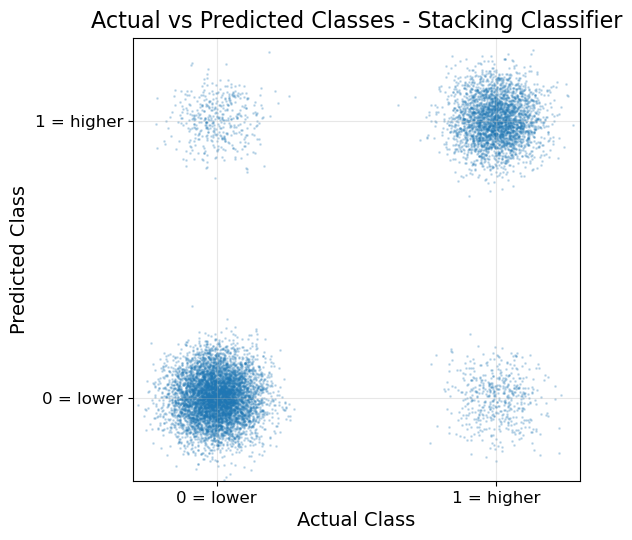

In [661]:
# Add small jitter so overlapping 0/1 points are visible
rng = np.random.default_rng(RANDOM_STATE)

actual_jitter = best_y_true + rng.normal(0, 0.08, size=len(best_y_true))
pred_jitter = best_y_pred_series + rng.normal(0, 0.08, size=len(best_y_pred_series))

plt.figure(figsize=(6, 5.5))
plt.scatter(actual_jitter, pred_jitter, alpha=0.2, s=1)

plt.xticks([0, 1], ["0 = lower", "1 = higher"])
plt.yticks([0, 1], ["0 = lower", "1 = higher"])

plt.xlabel("Actual Class")
plt.ylabel("Predicted Class")
plt.title(f"Actual vs Predicted Classes - {best_model_name}", fontsize=16, y=1.003)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.xlim(-0.3, 1.3)
plt.ylim(-0.3, 1.3)

if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_IMAGES_DIR / "supervised_binary_classification_actual_vs_predicted_best_model.png"

    plt.savefig(
        output_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    print("Saved:", output_path)

plt.show()

### Actual vs Predicted Classes for All Tuned Binary Classification Models

Saved: _exports\binary_classification_models\images\supervised_binary_classification_actual_vs_predicted_all_models.png


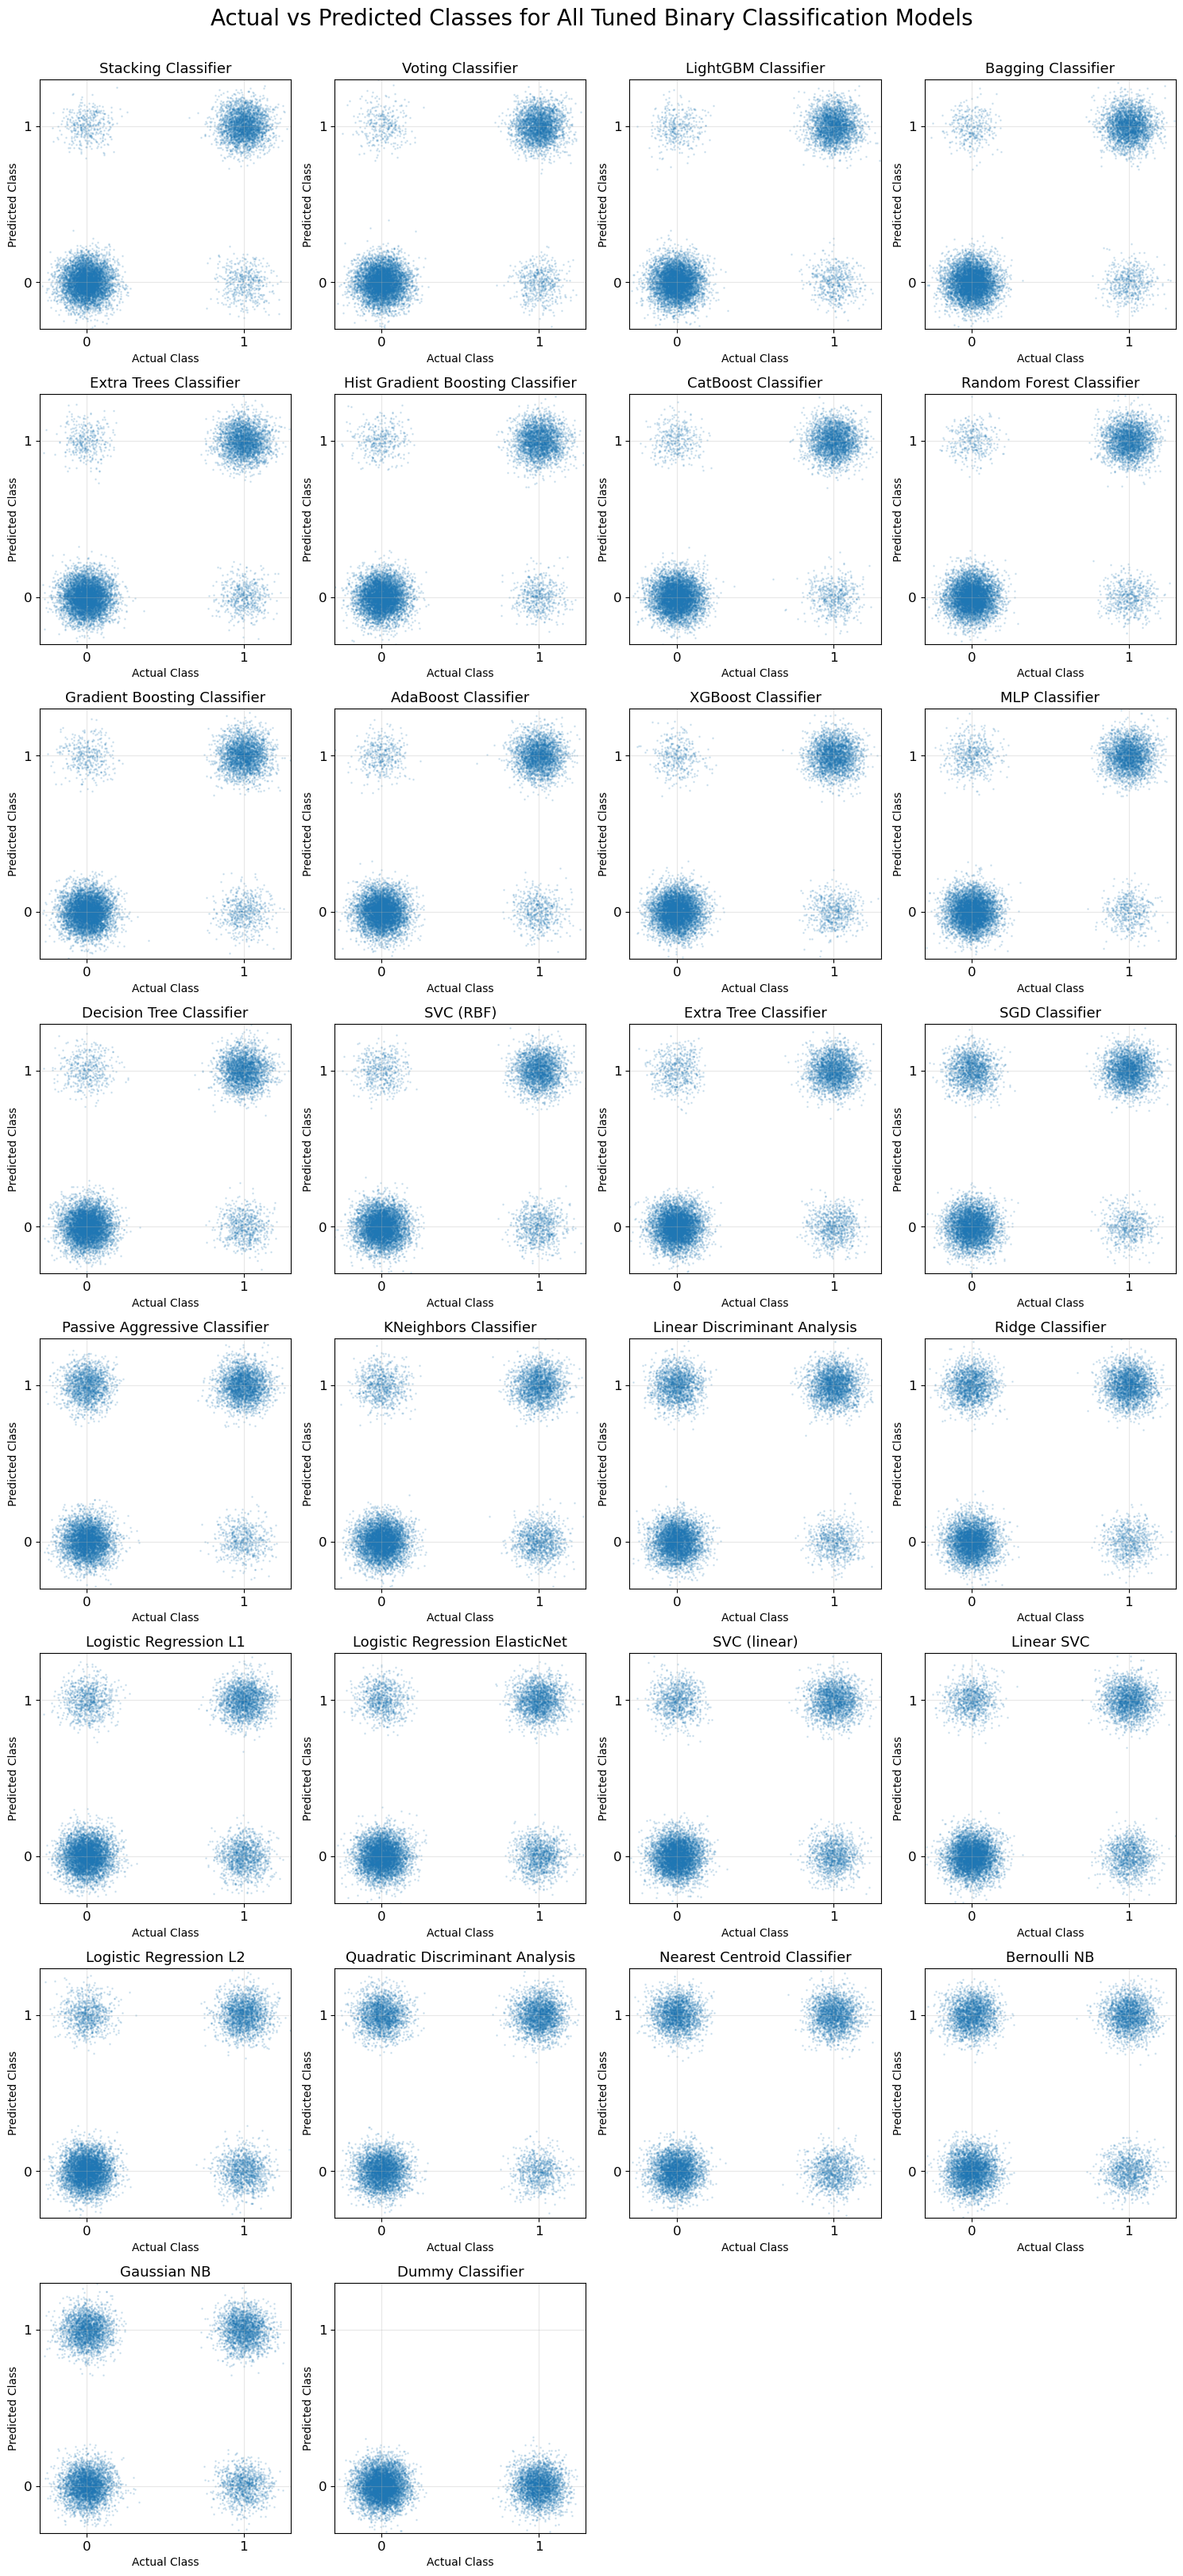

In [662]:
fig, axes = plt.subplots(plt_rows, plt_columns, figsize=(figsize_width, figsize_height + 6))
axes = axes.ravel()

rng = np.random.default_rng(RANDOM_STATE)

for ax, model_name in zip(axes, top_model_names):
    y_pred = pd.Series(best_pred_candidates[model_name]).reset_index(drop=True)

    actual_jitter = best_y_true + rng.normal(0, 0.08, size=len(best_y_true))
    pred_jitter = y_pred + rng.normal(0, 0.08, size=len(y_pred))

    ax.scatter(actual_jitter, pred_jitter, alpha=0.15, s=1)

    ax.set_title(model_name, fontsize=13)
    ax.set_xlabel("Actual Class", fontsize=10)
    ax.set_ylabel("Predicted Class", fontsize=10)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.grid(alpha=0.3)

for ax in axes[len(top_model_names):]:
    ax.axis("off")

plt.suptitle("Actual vs Predicted Classes for All Tuned Binary Classification Models", fontsize=20, y=1.003)
plt.tight_layout()

if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_IMAGES_DIR / "supervised_binary_classification_actual_vs_predicted_all_models.png"

    fig.savefig(
        output_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    print("Saved:", output_path)

plt.show()

### Confusion Matrix for the Best Binary Classification Model
**This plot shows the classification result structure.**
- True Negative: actual 0, predicted 0.
- False Positive: actual 0, predicted 1.
- False Negative: actual 1, predicted 0.
- True Positive: actual 1, predicted 1.

Saved: _exports\binary_classification_models\images\supervised_binary_classification_confusion_matrix_best_model.png


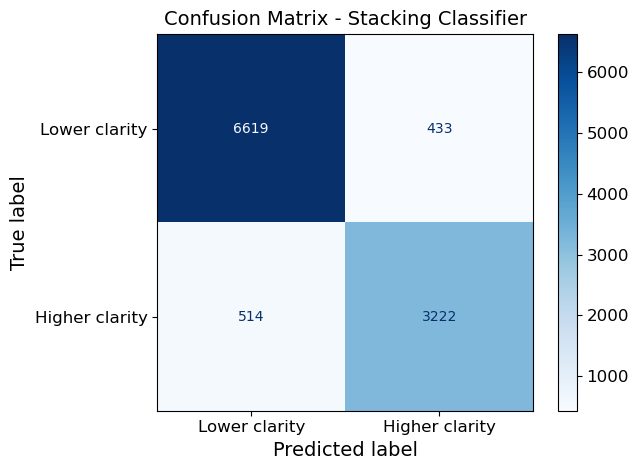

In [663]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    best_y_true,
    best_y_pred_series,
    display_labels=["Lower clarity", "Higher clarity"],
    cmap="Blues",
    values_format="d"
)

plt.title(f"Confusion Matrix - {best_model_name}", fontsize=14, y=1.003)
plt.grid(False)
plt.tight_layout()

if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_IMAGES_DIR / "supervised_binary_classification_confusion_matrix_best_model.png"

    plt.savefig(
        output_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    print("Saved:", output_path)

plt.show()

### Confusion Matrices for All Tuned Binary Classification Models

Saved: _exports\binary_classification_models\images\supervised_binary_classification_confusion_matrices_all_models.png


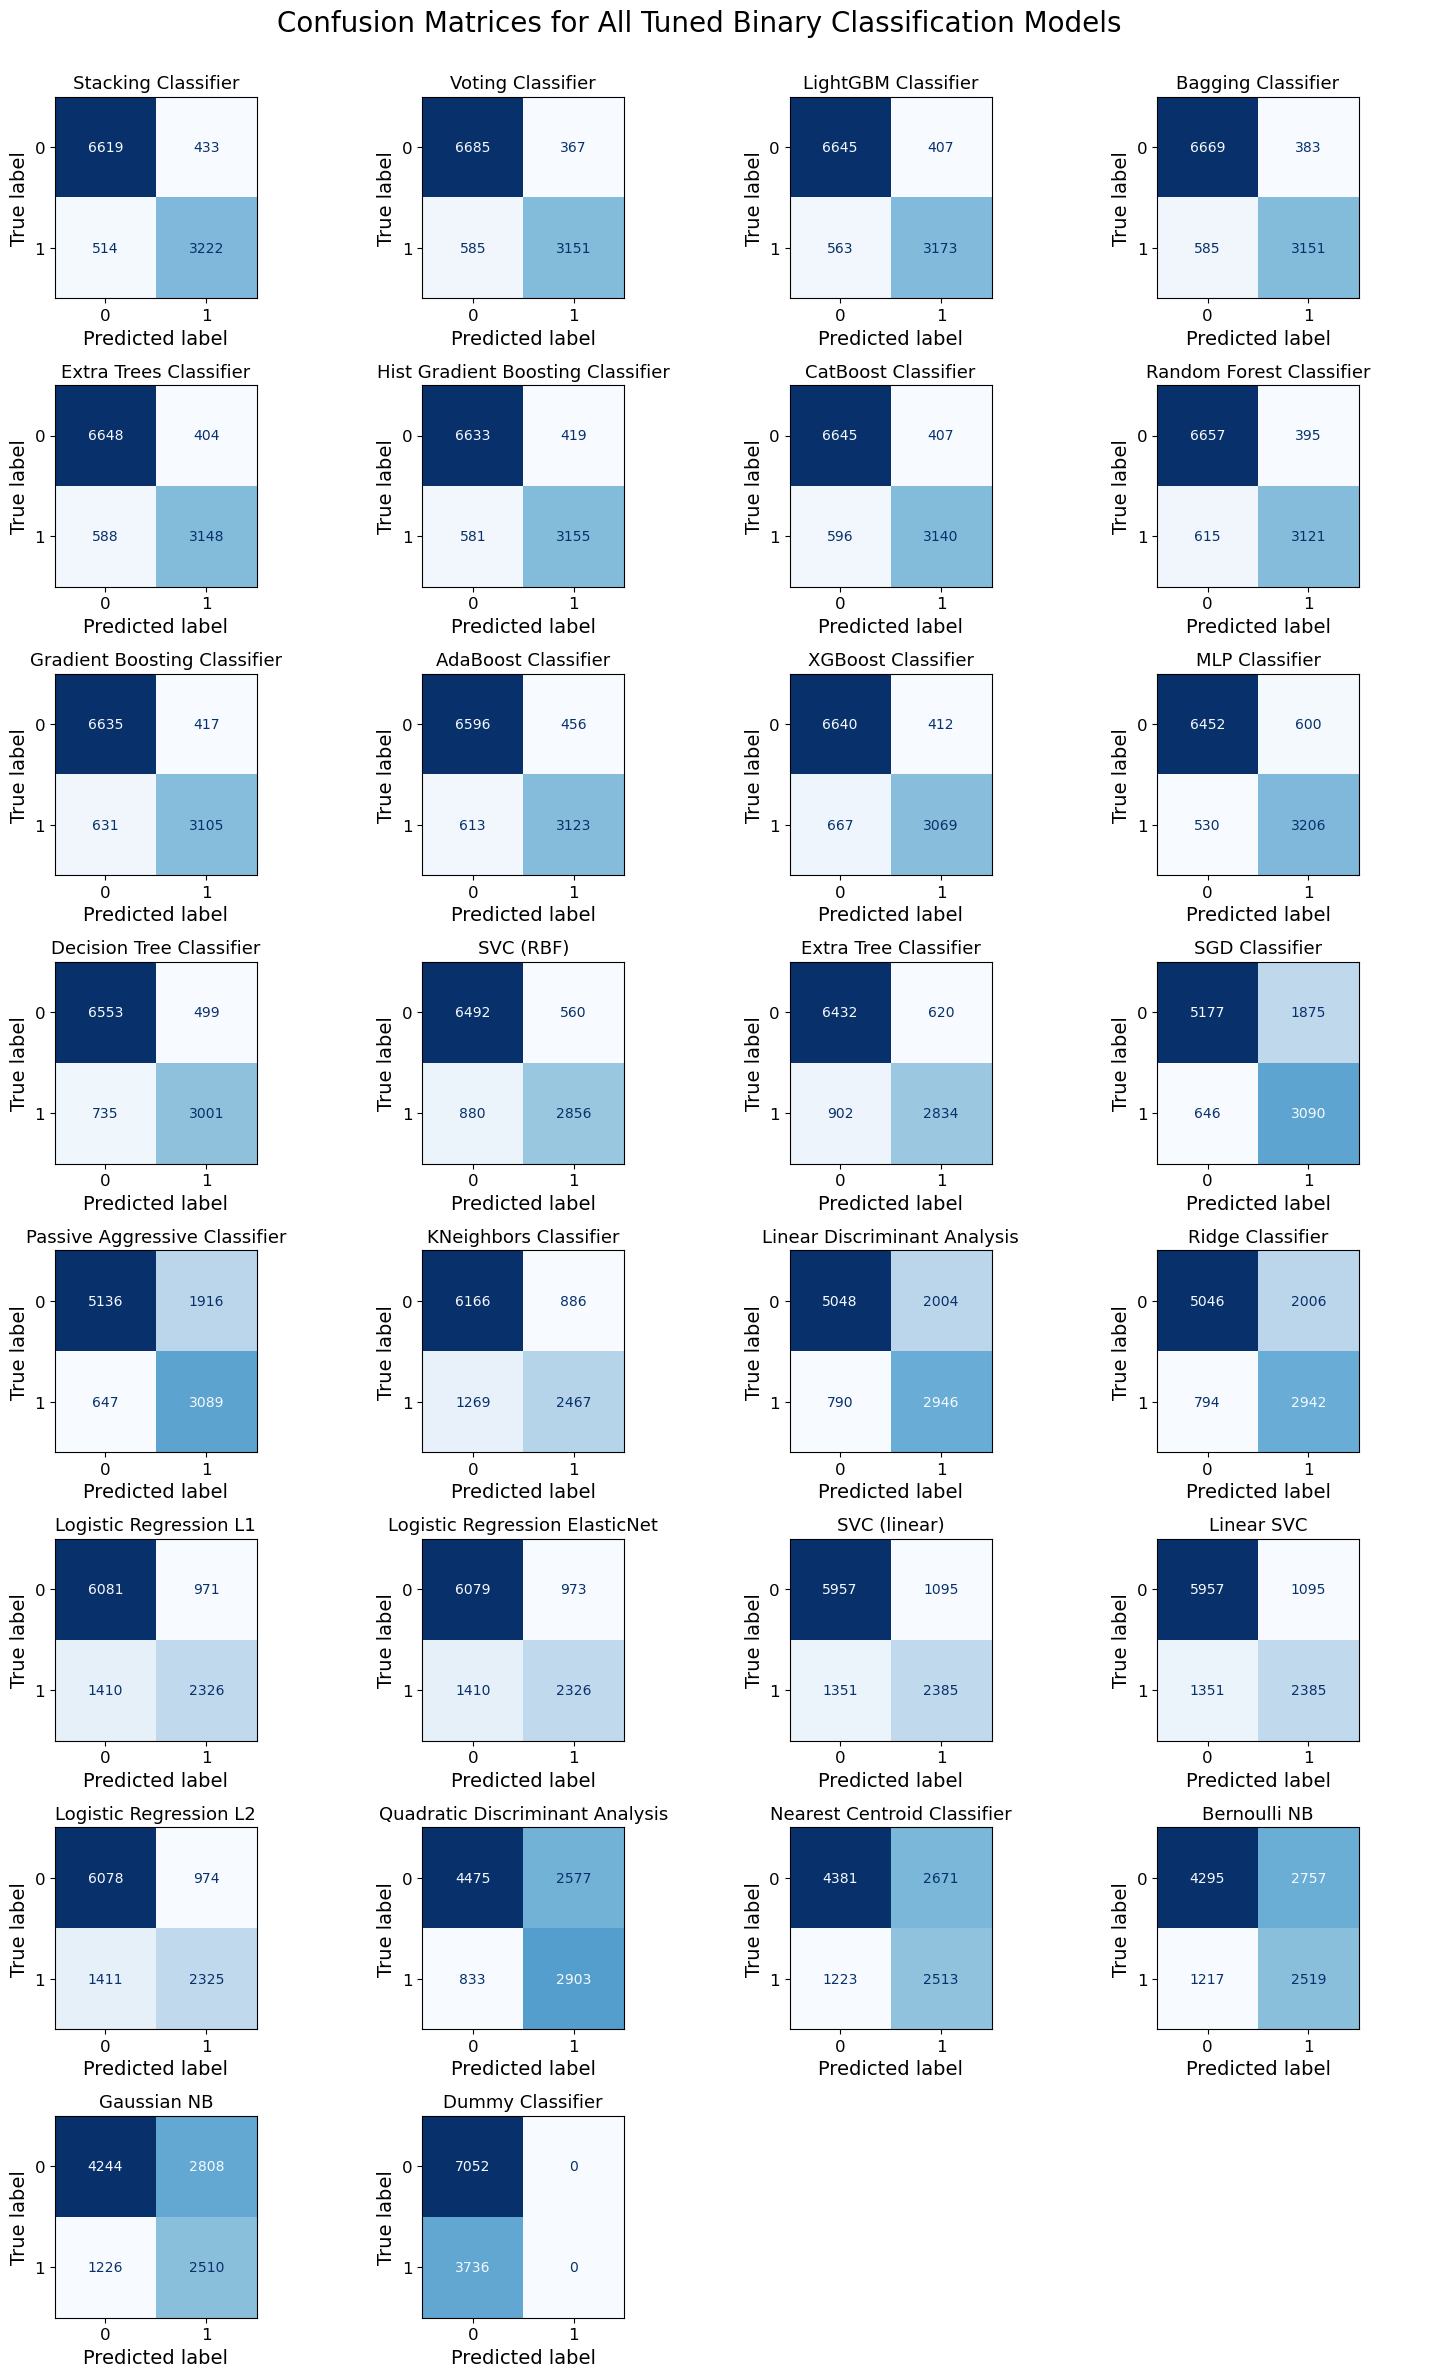

In [664]:
fig, axes = plt.subplots(plt_rows, plt_columns, figsize=(figsize_width, figsize_height * 0.9))
axes = axes.ravel()

for ax, model_name in zip(axes, top_model_names):
    y_pred = pd.Series(best_pred_candidates[model_name]).reset_index(drop=True)

    ConfusionMatrixDisplay.from_predictions(
        best_y_true,
        y_pred,
        display_labels=["0", "1"],
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False
    )

    ax.set_title(model_name, fontsize=13)
    ax.grid(False)

for ax in axes[len(top_model_names):]:
    ax.axis("off")

plt.suptitle("Confusion Matrices for All Tuned Binary Classification Models", fontsize=20, y=1.003)
plt.tight_layout()

if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_IMAGES_DIR / "supervised_binary_classification_confusion_matrices_all_models.png"

    fig.savefig(
        output_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    print("Saved:", output_path)

plt.show()

### ROC Curve for the Best Binary Classification Model

This plot shows the ROC curve of the best tuned binary classification model on the test set.

The ROC curve illustrates the trade-off between the true positive rate and the false positive rate across decision thresholds.

Saved: _exports\binary_classification_models\images\supervised_binary_classification_roc_curve_best_model.png


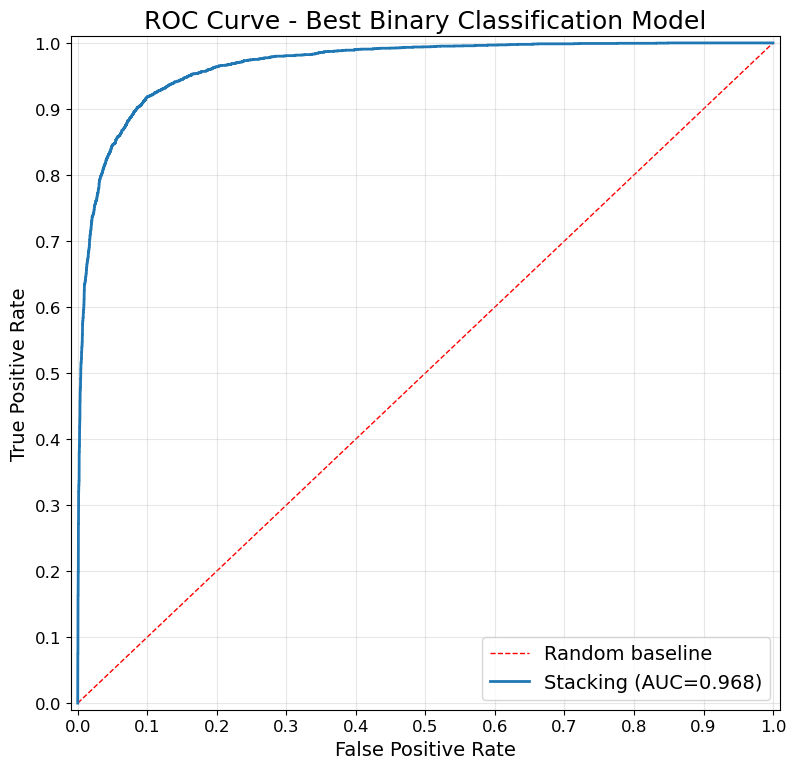

Best model: Stacking Classifier
ROC-AUC: 0.9682


In [665]:
from sklearn.metrics import roc_curve, auc

# ============================================================
# ROC Curve for the best binary classification model
# ============================================================

main_metric = "Tun_F1"

if main_metric not in results_df_sorted.columns:
    raise KeyError(f"{main_metric} column was not found in the final results table.")

best_model_row = (
    results_df_sorted
    .dropna(subset=[main_metric])
    .sort_values(main_metric, ascending=False)
    .iloc[0]
)

best_model_name = best_model_row["Model"]

best_model_score = best_score_candidates.get(best_model_name)

if best_model_score is None:
    raise ValueError(f"No score values were found for the best model: {best_model_name}")

fpr, tpr, _ = roc_curve(y_test, best_model_score)
roc_auc_value = auc(fpr, tpr)

display_name = str(best_model_name).replace(" Classifier", "")

plt.figure(figsize=(8, 7.8))

# Plot random baseline first so it appears first in the legend
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random baseline",
    color="red",
    zorder=1
)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"{display_name} (AUC={roc_auc_value:.3f})",
    zorder=2
)

plt.title("ROC Curve - Best Binary Classification Model", fontsize=18)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.grid(alpha=0.3)
plt.xticks(np.linspace(0, 1, 11))
plt.yticks(np.linspace(0, 1, 11))
plt.legend(loc="lower right", fontsize=14)
plt.tight_layout()
plt.ylim([-0.01, 1.01])
plt.xlim([-0.01, 1.01])

if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_IMAGES_DIR / "supervised_binary_classification_roc_curve_best_model.png"

    plt.savefig(
        output_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    print("Saved:", output_path)

plt.show()

print("Best model:", best_model_name)
print("ROC-AUC:", round(roc_auc_value, 4))

### ROC Curves for Individual Tuned Binary Classification Models

This figure shows ROC curves for the tuned binary classification models in separate subplots.

Displaying the models individually makes the curves easier to inspect than a single combined figure.

Saved: _exports\binary_classification_models\images\supervised_binary_classification_roc_curve_individual_models.png


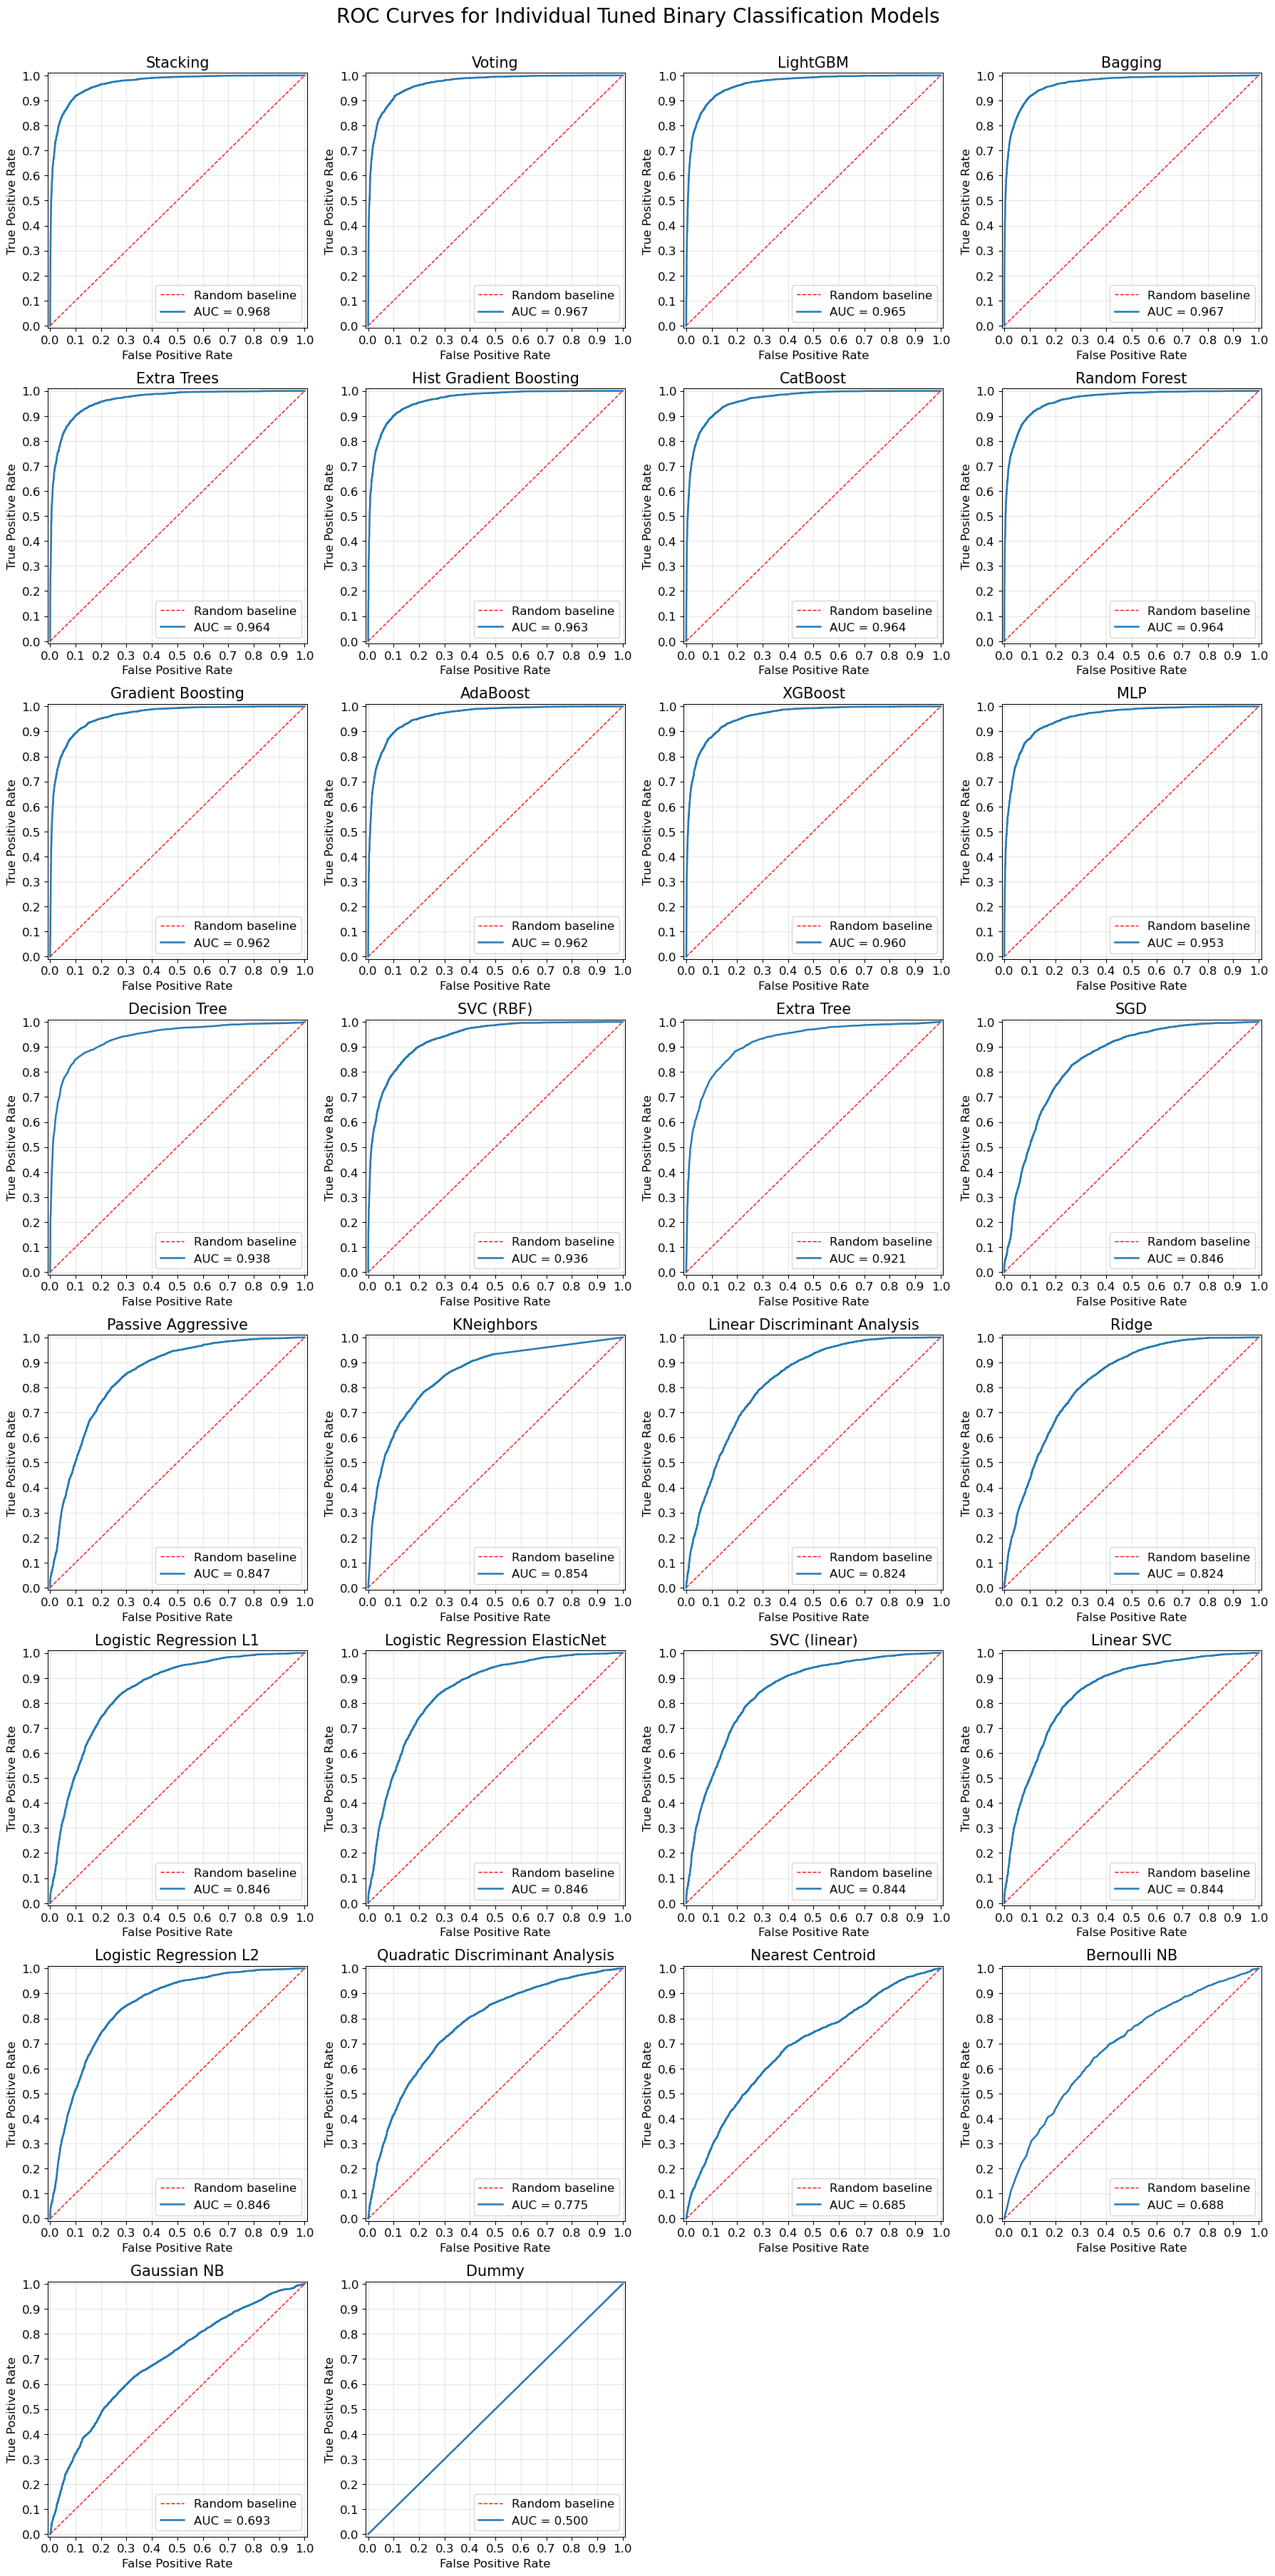

In [666]:
from sklearn.metrics import roc_curve, auc
import math

# ============================================================
# ROC Curves for individual tuned binary classification models
# ============================================================

available_roc_models = []

for model_name in top_model_names:
    y_score = best_score_candidates.get(model_name)

    if y_score is not None:
        available_roc_models.append(model_name)

n_models = len(available_roc_models)

if n_models == 0:
    print("No models with score values were found for individual ROC plots.")
else:
    n_cols = 4
    n_rows = math.ceil(n_models / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, model_name in zip(axes, available_roc_models):
        y_score = best_score_candidates.get(model_name)

        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc_value = auc(fpr, tpr)

        display_name = str(model_name).replace(" Classifier", "")

        # Plot random baseline first so it appears first in the legend
        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            linewidth=1,
            label="Random baseline",
            color="red",
            zorder=1
        )

        ax.plot(
            fpr,
            tpr,
            linewidth=1.8,
            label=f"AUC = {roc_auc_value:.3f}",
            zorder=2
        )

        ax.set_title(display_name, fontsize=15)
        ax.set_xlabel("False Positive Rate", fontsize=12)
        ax.set_ylabel("True Positive Rate", fontsize=12)
        ax.set_xticks(np.linspace(0, 1, 11))
        ax.set_yticks(np.linspace(0, 1, 11))
        ax.grid(alpha=0.3)
        ax.legend(loc="lower right", fontsize=12)
        ax.set_ylim([-0.01, 1.01])
        ax.set_xlim([-0.01, 1.01])

    for ax in axes[n_models:]:
        ax.axis("off")

    plt.suptitle("ROC Curves for Individual Tuned Binary Classification Models", fontsize=20, y=1.003)
    plt.tight_layout()

    if SAVE_PORTFOLIO_OUTPUTS:
        output_path = BINARY_CLASSIFICATION_IMAGES_DIR / "supervised_binary_classification_roc_curve_individual_models.png"

        fig.savefig(
            output_path,
            dpi=FIG_DPI,
            bbox_inches="tight"
        )

        print("Saved:", output_path)

    plt.show()

### ROC Curves by Model Family

This figure groups the tuned binary classification models by model family and plots ROC curves separately for each family.

This makes the comparison easier to read than a single plot containing all models at once.

Saved: _exports\binary_classification_models\images\supervised_binary_classification_roc_curve_by_model_family.png


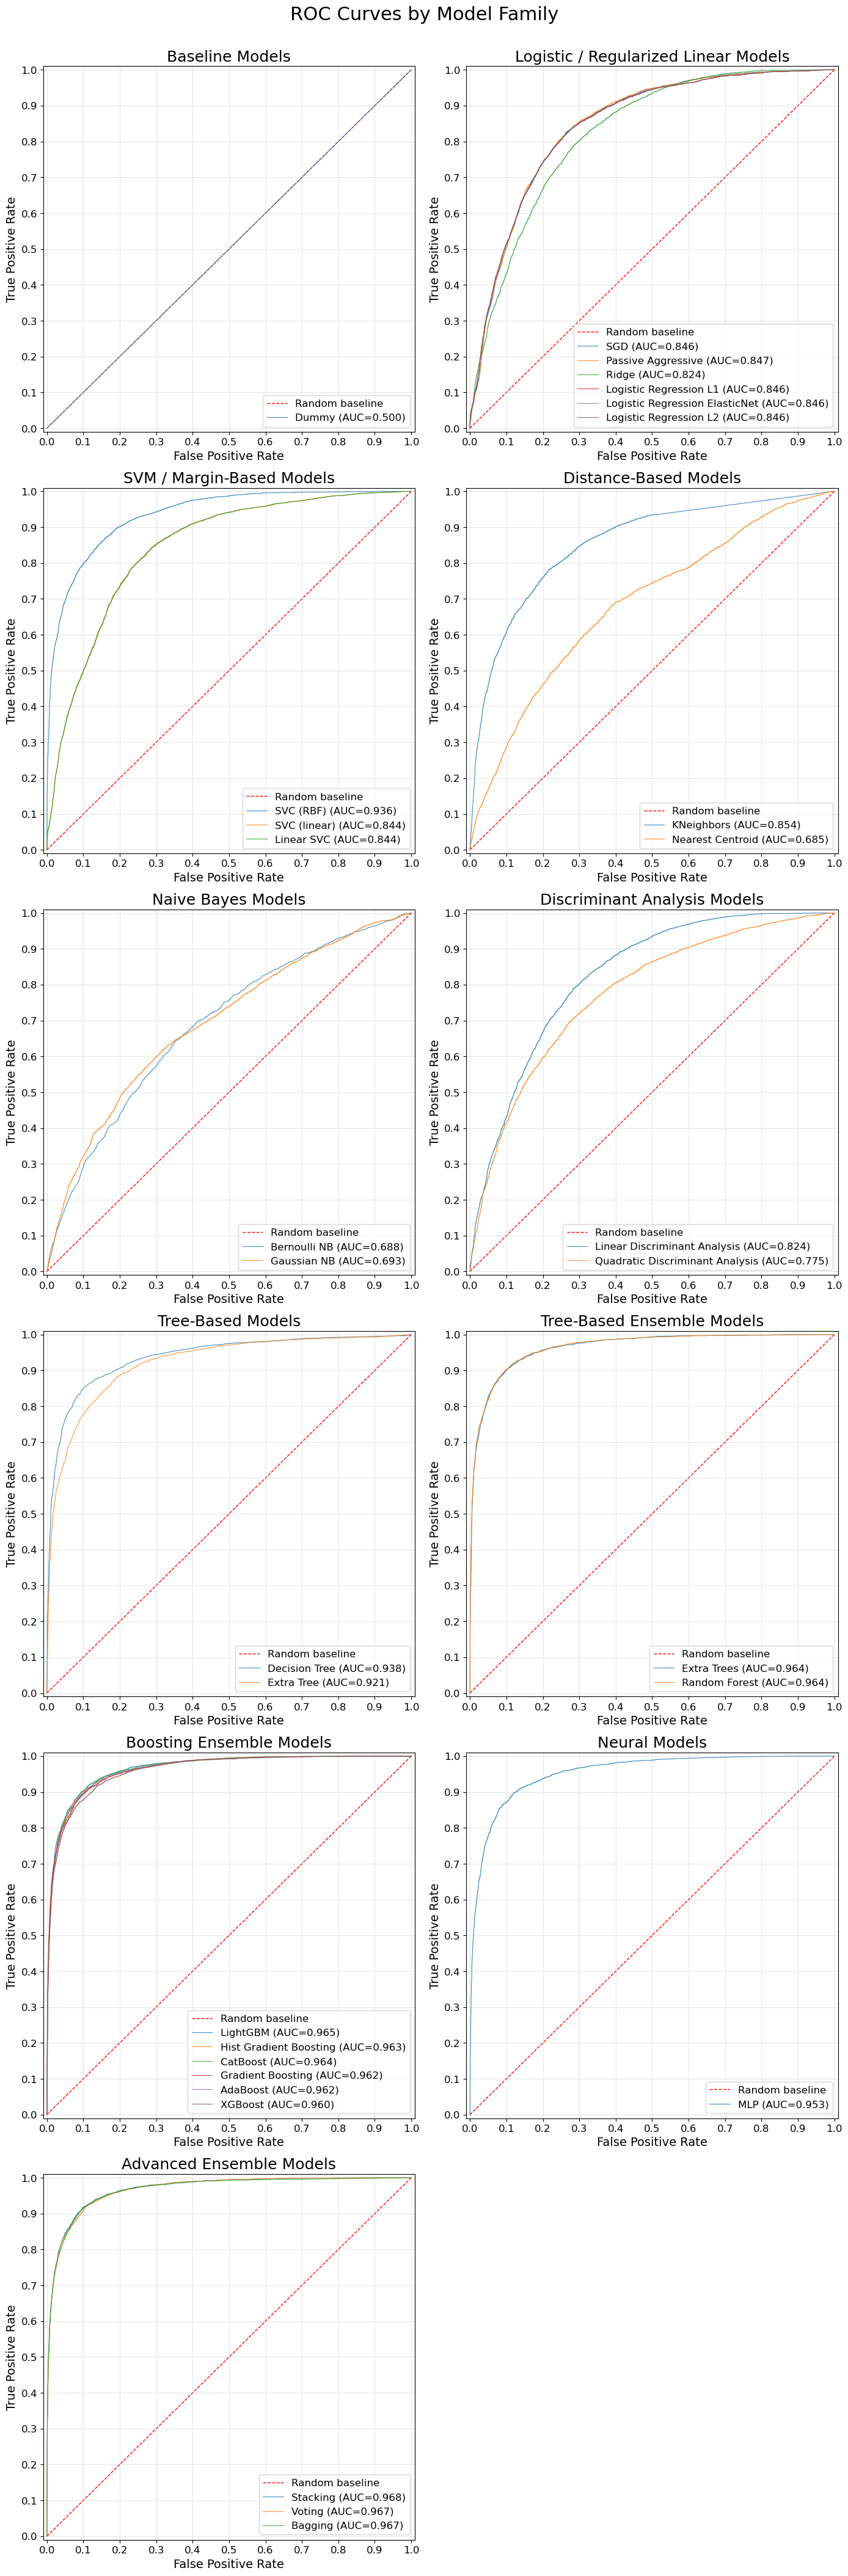

In [667]:
from sklearn.metrics import roc_curve, auc
import math

# ============================================================
# ROC Curves by model family
# ============================================================

def get_binary_classifier_family(model_name):
    name = str(model_name)

    # Baseline models
    if "Dummy" in name:
        return "Baseline Models"

    # Logistic / regularized linear models
    elif any(x in name for x in [
        "Logistic Regression",
        "Ridge Classifier",
        "SGD",
        "Passive Aggressive"
    ]):
        return "Logistic / Regularized Linear Models"

    # SVM / margin-based models
    elif any(x in name for x in [
        "Linear SVC",
        "SVC (linear)",
        "SVC (RBF)"
    ]):
        return "SVM / Margin-Based Models"

    # Distance-based models
    elif any(x in name for x in [
        "KNeighbors",
        "Nearest Centroid"
    ]):
        return "Distance-Based Models"

    # Naive Bayes models
    elif any(x in name for x in [
        "Gaussian NB",
        "Bernoulli NB"
    ]):
        return "Naive Bayes Models"

    # Discriminant analysis models
    elif any(x in name for x in [
        "Linear Discriminant Analysis",
        "Quadratic Discriminant Analysis"
    ]):
        return "Discriminant Analysis Models"

    # Tree-based ensemble models
    # Important: Extra Trees must be checked before Extra Tree.
    elif any(x in name for x in [
        "Random Forest",
        "Extra Trees"
    ]):
        return "Tree-Based Ensemble Models"

    # Tree-based models
    elif any(x in name for x in [
        "Decision Tree",
        "Extra Tree"
    ]):
        return "Tree-Based Models"

    # Boosting ensemble models
    elif any(x in name for x in [
        "AdaBoost",
        "Gradient Boosting",
        "Hist Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ]):
        return "Boosting Ensemble Models"

    # Neural models
    elif "MLP" in name:
        return "Neural Models"

    # Advanced ensemble models
    elif any(x in name for x in [
        "Bagging",
        "Voting",
        "Stacking"
    ]):
        return "Advanced Ensemble Models"

    else:
        return "Other Models"


family_order = [
    "Baseline Models",
    "Logistic / Regularized Linear Models",
    "SVM / Margin-Based Models",
    "Distance-Based Models",
    "Naive Bayes Models",
    "Discriminant Analysis Models",
    "Tree-Based Models",
    "Tree-Based Ensemble Models",
    "Boosting Ensemble Models",
    "Neural Models",
    "Advanced Ensemble Models",
    "Other Models"
]


family_to_models = {family: [] for family in family_order}

for model_name in top_model_names:
    y_score = best_score_candidates.get(model_name)

    if y_score is None:
        continue

    family = get_binary_classifier_family(model_name)
    family_to_models[family].append(model_name)

# Keep only non-empty families
available_families = {
    family: models
    for family, models in family_to_models.items()
    if len(models) > 0
}

n_families = len(available_families)

if n_families == 0:
    print("No models with score values were found for ROC family plots.")

else:
    n_cols = 2
    n_rows = math.ceil(n_families / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 7 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, (family, models) in zip(axes, available_families.items()):

        # Plot random baseline first so it appears first in the legend
        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            linewidth=1,
            label="Random baseline",
            zorder=1,
            color="red"
        )

        for model_name in models:
            y_score = best_score_candidates.get(model_name)

            if y_score is None:
                continue

            fpr, tpr, _ = roc_curve(y_test, y_score)
            roc_auc_value = auc(fpr, tpr)

            display_name = (
                str(model_name)
                .replace(" Classifier", "")
            )

            ax.plot(
                fpr,
                tpr,
                linewidth=0.8,
                alpha=0.85,
                label=f"{display_name} (AUC={roc_auc_value:.3f})",
                zorder=2
            )

        ax.set_title(family, fontsize=18)
        ax.set_xlabel("False Positive Rate", fontsize=14)
        ax.set_ylabel("True Positive Rate", fontsize=14)
        ax.set_xticks(np.linspace(0, 1, 11))
        ax.set_yticks(np.linspace(0, 1, 11))
        ax.grid(alpha=0.3)
        ax.legend(loc="lower right", fontsize=12)
        ax.set_ylim([-0.01, 1.01])
        ax.set_xlim([-0.01, 1.01])

    for ax in axes[len(available_families):]:
        ax.axis("off")

    plt.suptitle("ROC Curves by Model Family", fontsize=22, y=1.003)
    plt.tight_layout()

    if SAVE_PORTFOLIO_OUTPUTS:
        output_path = (
            BINARY_CLASSIFICATION_IMAGES_DIR
            / "supervised_binary_classification_roc_curve_by_model_family.png"
        )

        fig.savefig(
            output_path,
            dpi=FIG_DPI,
            bbox_inches="tight"
        )

        print("Saved:", output_path)

    plt.show()

### ROC Curve for All Tuned Binary Classification Models

This plot compares how well the tuned binary classification models separate the two classes across different classification thresholds.

A curve closer to the top-left corner indicates better class separation. The ROC-AUC value summarises this separation ability.

Saved: _exports\binary_classification_models\images\supervised_binary_classification_roc_curve_all_models.png


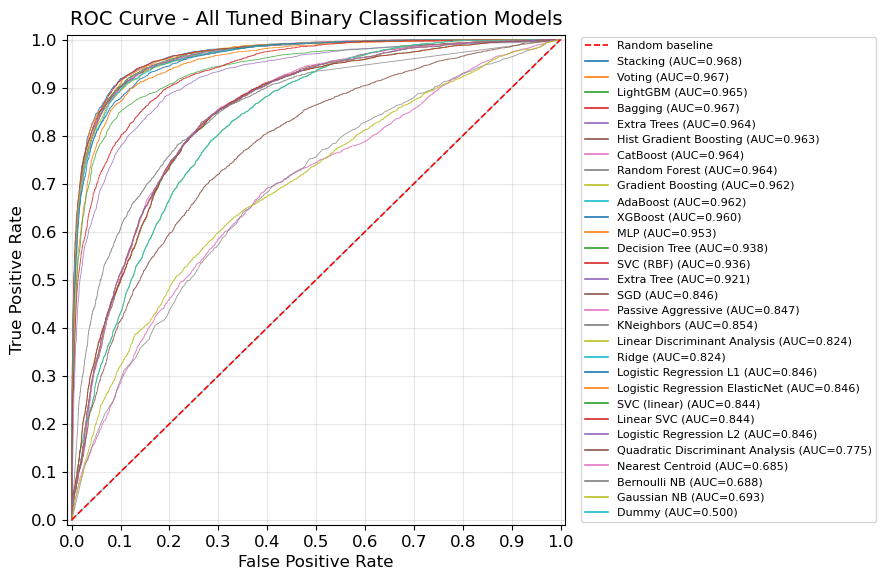

Models included in ROC curve: 30


In [668]:
from sklearn.metrics import roc_curve, auc

# ============================================================
# ROC Curve for all tuned binary classification models
# ============================================================

plt.figure(figsize=(9, 5.9))

available_roc_models = []

# Plot random baseline first so it appears first in the legend
# Higher zorder keeps it visually above Dummy Classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    label="Random baseline",
    zorder=5,
    color="red"
)

for model_name in top_model_names:
    y_score = best_score_candidates.get(model_name)

    if y_score is None:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc_value = auc(fpr, tpr)

    available_roc_models.append(model_name)

    display_name = (
        model_name
        .replace(" Classifier", "")
    )

    # Keep Dummy Classifier below the random baseline because their ROC curves overlap
    if "Dummy" in model_name:
        line_zorder = 1
    else:
        line_zorder = 2
    
    plt.plot(
        fpr,
        tpr,
        linewidth=0.6,
        alpha=0.8,
        label=f"{display_name} (AUC={roc_auc_value:.3f})",
        zorder=line_zorder
    )

plt.title("ROC Curve - All Tuned Binary Classification Models", fontsize=14, y=1.003)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.grid(alpha=0.3)

legend = plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8
)

# Make legend lines thicker and more visible without changing the plot lines
for line in legend.get_lines():
    line.set_linewidth(1.2)
    line.set_alpha(1.0)

plt.tight_layout()
plt.ylim([-0.01, 1.01])
plt.xlim([-0.01, 1.01])
plt.xticks(np.linspace(0, 1, 11))
plt.yticks(np.linspace(0, 1, 11))

if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_IMAGES_DIR / "supervised_binary_classification_roc_curve_all_models.png"

    plt.savefig(
        output_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    print("Saved:", output_path)

plt.show()

print("Models included in ROC curve:", len(available_roc_models))

### Precision-Recall Curve for the Best Binary Classification Model

This plot shows the precision-recall curve of the best tuned binary classification model on the test set.

Precision-recall analysis is especially useful when the positive class is important.

Saved: _exports\binary_classification_models\images\supervised_binary_classification_precision_recall_curve_best_model.png


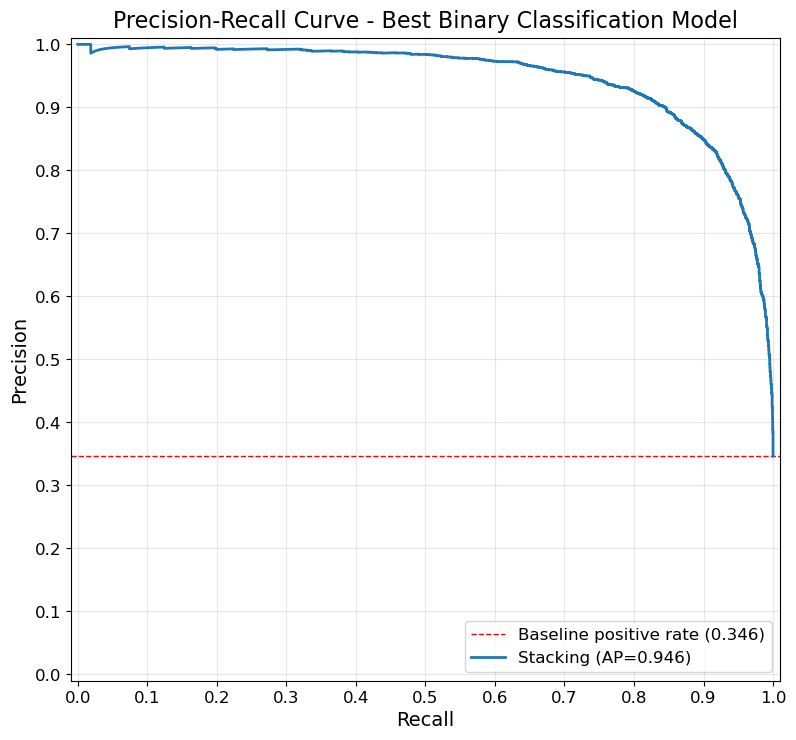

Best model: Stacking Classifier
Average Precision: 0.9463


In [669]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# ============================================================
# Precision-Recall Curve for the best binary classification model
# ============================================================

main_metric = "Tun_F1"

if main_metric not in results_df_sorted.columns:
    raise KeyError(f"{main_metric} column was not found in the final results table.")

best_model_row = (
    results_df_sorted
    .dropna(subset=[main_metric])
    .sort_values(main_metric, ascending=False)
    .iloc[0]
)

best_model_name = best_model_row["Model"]

best_model_score = best_score_candidates.get(best_model_name)

if best_model_score is None:
    raise ValueError(f"No score values were found for the best model: {best_model_name}")

precision, recall, _ = precision_recall_curve(y_test, best_model_score)
average_precision = average_precision_score(y_test, best_model_score)

positive_class_rate = np.mean(y_test)

display_name = str(best_model_name).replace(" Classifier", "")

plt.figure(figsize=(8, 7.5))

# Plot baseline first so it appears first in the legend
plt.axhline(
    y=positive_class_rate,
    linestyle="--",
    linewidth=1,
    label=f"Baseline positive rate ({positive_class_rate:.3f})",
    color="red",
    zorder=1
)

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"{display_name} (AP={average_precision:.3f})",
    zorder=2
)

plt.title("Precision-Recall Curve - Best Binary Classification Model", fontsize=16, y=1.003)
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.grid(alpha=0.3)
plt.xticks(np.linspace(0, 1, 11))
plt.yticks(np.linspace(0, 1, 11))
plt.legend(loc="lower right", fontsize=12)
plt.tight_layout()
plt.ylim([-0.01, 1.01])
plt.xlim([-0.01, 1.01])

if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_IMAGES_DIR / "supervised_binary_classification_precision_recall_curve_best_model.png"

    plt.savefig(
        output_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    print("Saved:", output_path)

plt.show()

print("Best model:", best_model_name)
print("Average Precision:", round(average_precision, 4))

### Precision-Recall Curves for Individual Tuned Binary Classification Models

This figure shows precision-recall curves for the tuned binary classification models in separate subplots.

Displaying the models individually makes the precision-recall behaviour easier to compare.

Saved: _exports\binary_classification_models\images\supervised_binary_classification_precision_recall_curve_individual_models.png


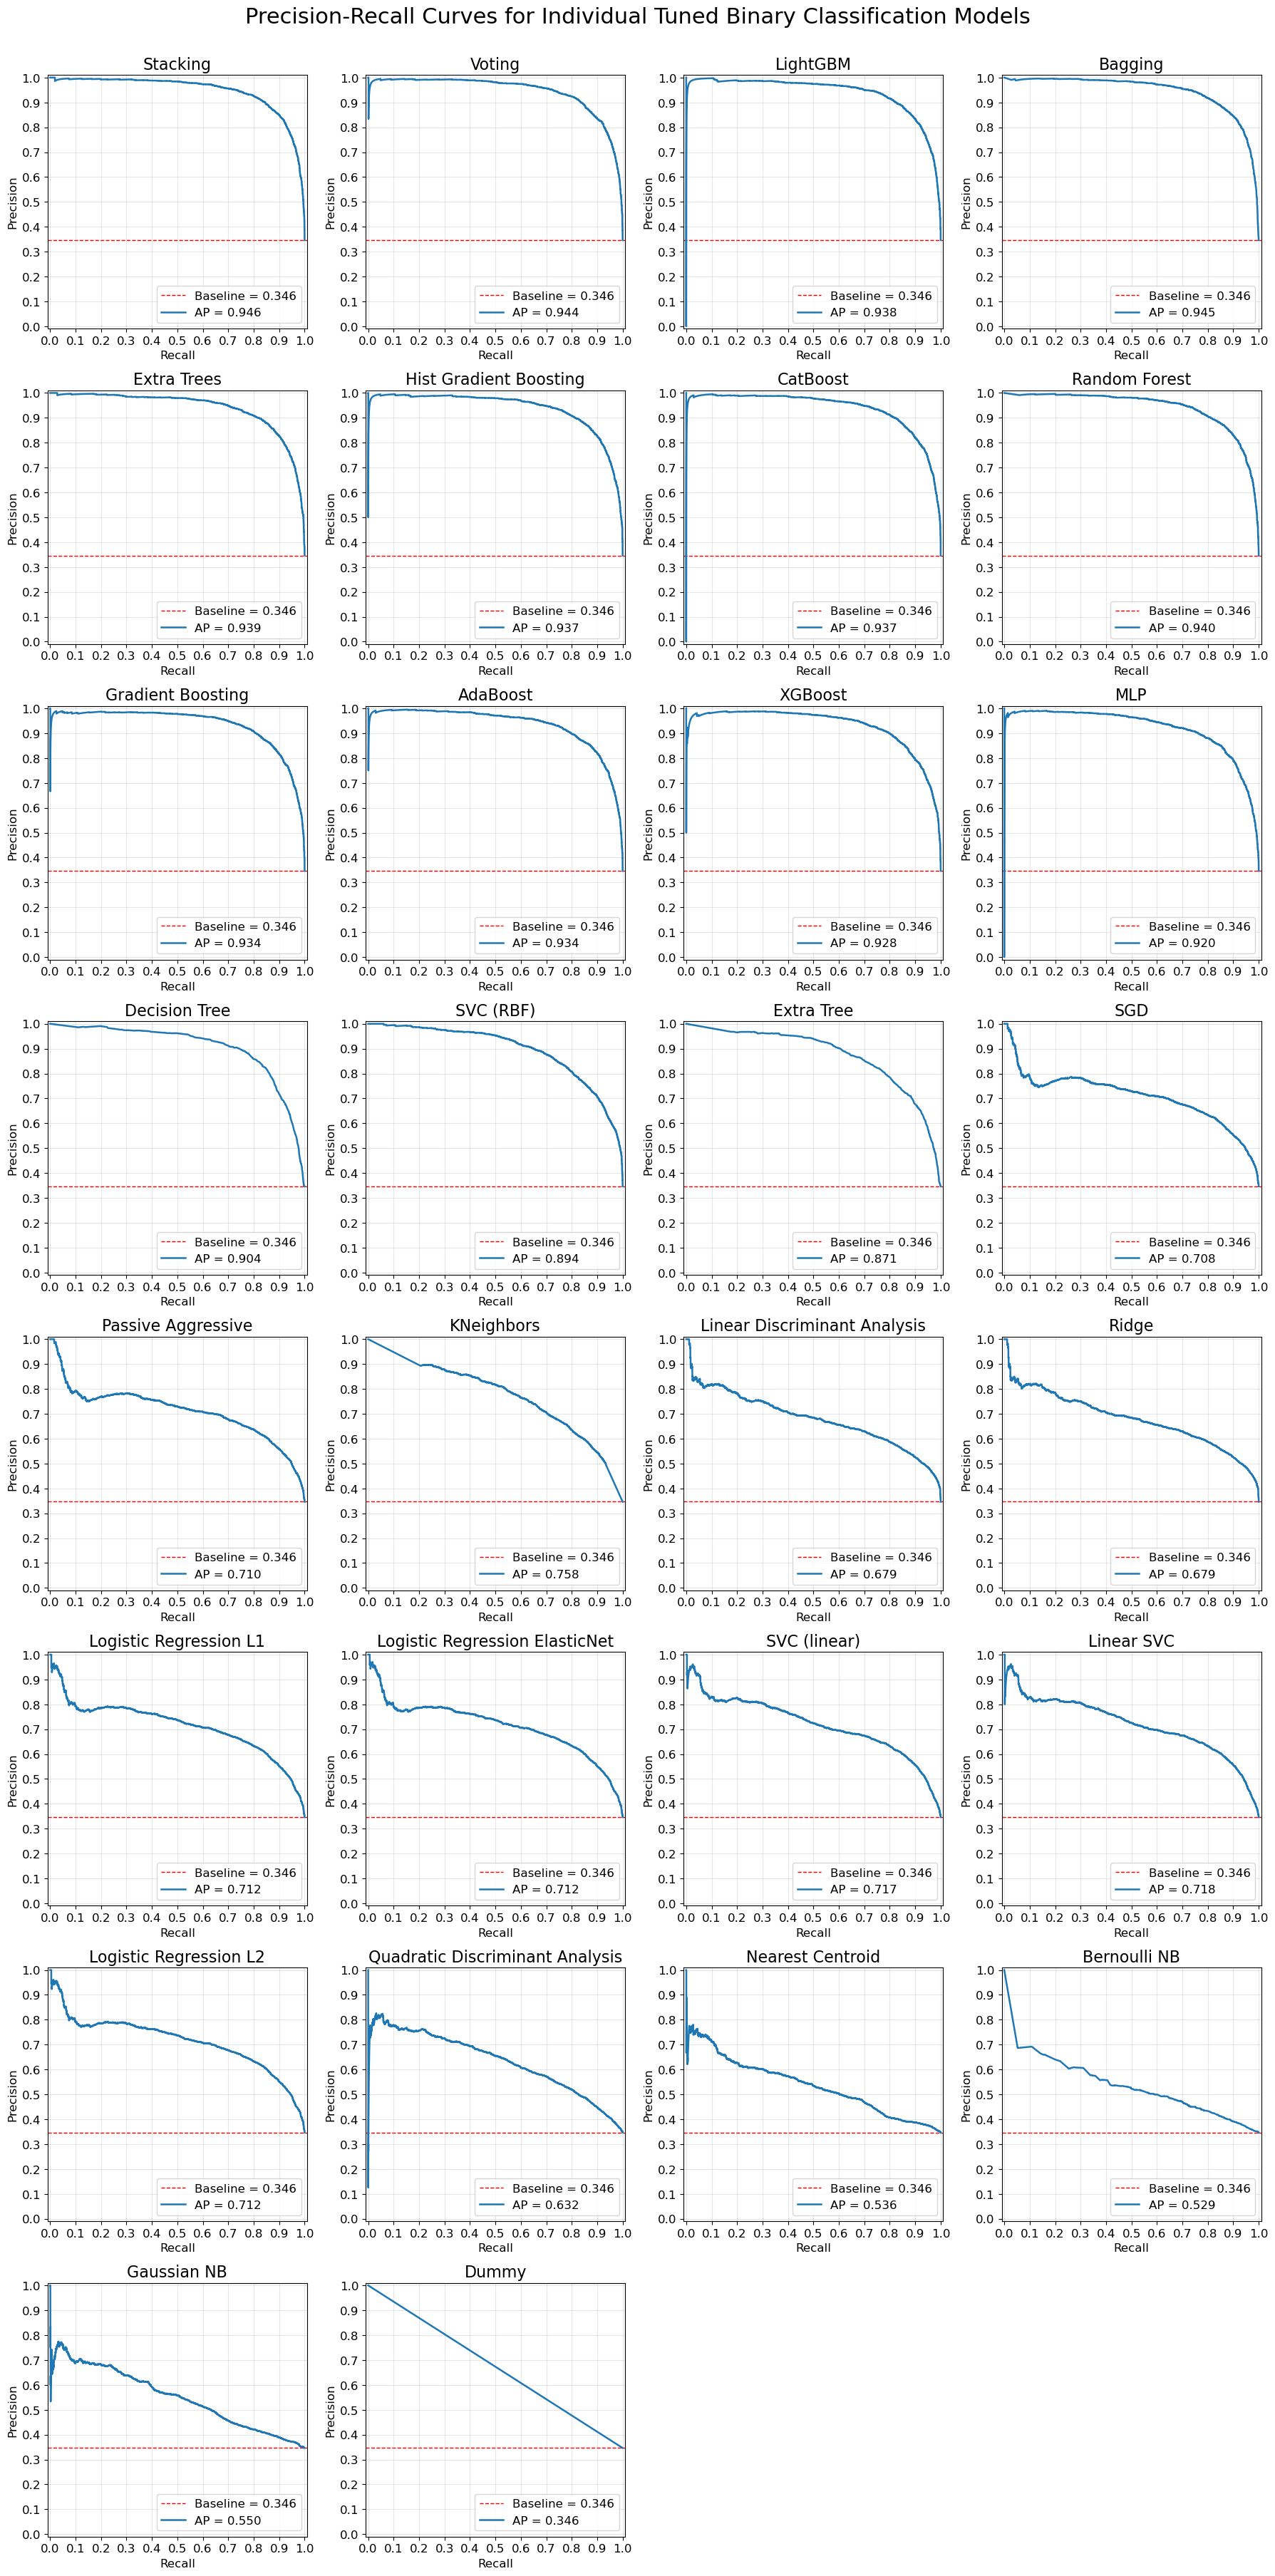

In [670]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import math

# ============================================================
# Precision-Recall Curves for individual tuned binary classification models
# ============================================================

positive_class_rate = np.mean(y_test)

available_pr_models = []

for model_name in top_model_names:
    y_score = best_score_candidates.get(model_name)

    if y_score is not None:
        available_pr_models.append(model_name)

n_models = len(available_pr_models)

if n_models == 0:
    print("No models with score values were found for individual Precision-Recall plots.")
else:
    n_cols = 4
    n_rows = math.ceil(n_models / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, model_name in zip(axes, available_pr_models):
        y_score = best_score_candidates.get(model_name)

        # Plot baseline first so it appears first in the legend
        ax.axhline(
            y=positive_class_rate,
            linestyle="--",
            linewidth=1,
            label=f"Baseline = {positive_class_rate:.3f}",
            color="red",
            zorder=1
        )

        precision, recall, _ = precision_recall_curve(y_test, y_score)
        average_precision = average_precision_score(y_test, y_score)

        display_name = str(model_name).replace(" Classifier", "")

        ax.plot(
            recall,
            precision,
            linewidth=1.8,
            label=f"AP = {average_precision:.3f}",
            zorder=2
        )

        ax.set_title(display_name, fontsize=16)
        ax.set_xlabel("Recall", fontsize=12)
        ax.set_ylabel("Precision", fontsize=12)
        ax.grid(alpha=0.3)
        ax.set_xticks(np.linspace(0, 1, 11))
        ax.set_yticks(np.linspace(0, 1, 11))
        ax.legend(loc="lower right", fontsize=12)
        ax.set_ylim([-0.01, 1.01])
        ax.set_xlim([-0.01, 1.01])
        
    for ax in axes[n_models:]:
        ax.axis("off")

    plt.suptitle("Precision-Recall Curves for Individual Tuned Binary Classification Models", fontsize=22, y=1.003)
    plt.tight_layout()

    if SAVE_PORTFOLIO_OUTPUTS:
        output_path = BINARY_CLASSIFICATION_IMAGES_DIR / "supervised_binary_classification_precision_recall_curve_individual_models.png"

        fig.savefig(
            output_path,
            dpi=FIG_DPI,
            bbox_inches="tight"
        )

        print("Saved:", output_path)

    plt.show()

### Precision-Recall Curves by Model Family

This figure groups the tuned binary classification models by model family and plots precision-recall curves separately for each family.

This makes the comparison easier to interpret, especially when many models are included in the project.

Saved: _exports\binary_classification_models\images\supervised_binary_classification_precision_recall_curve_by_model_family.png


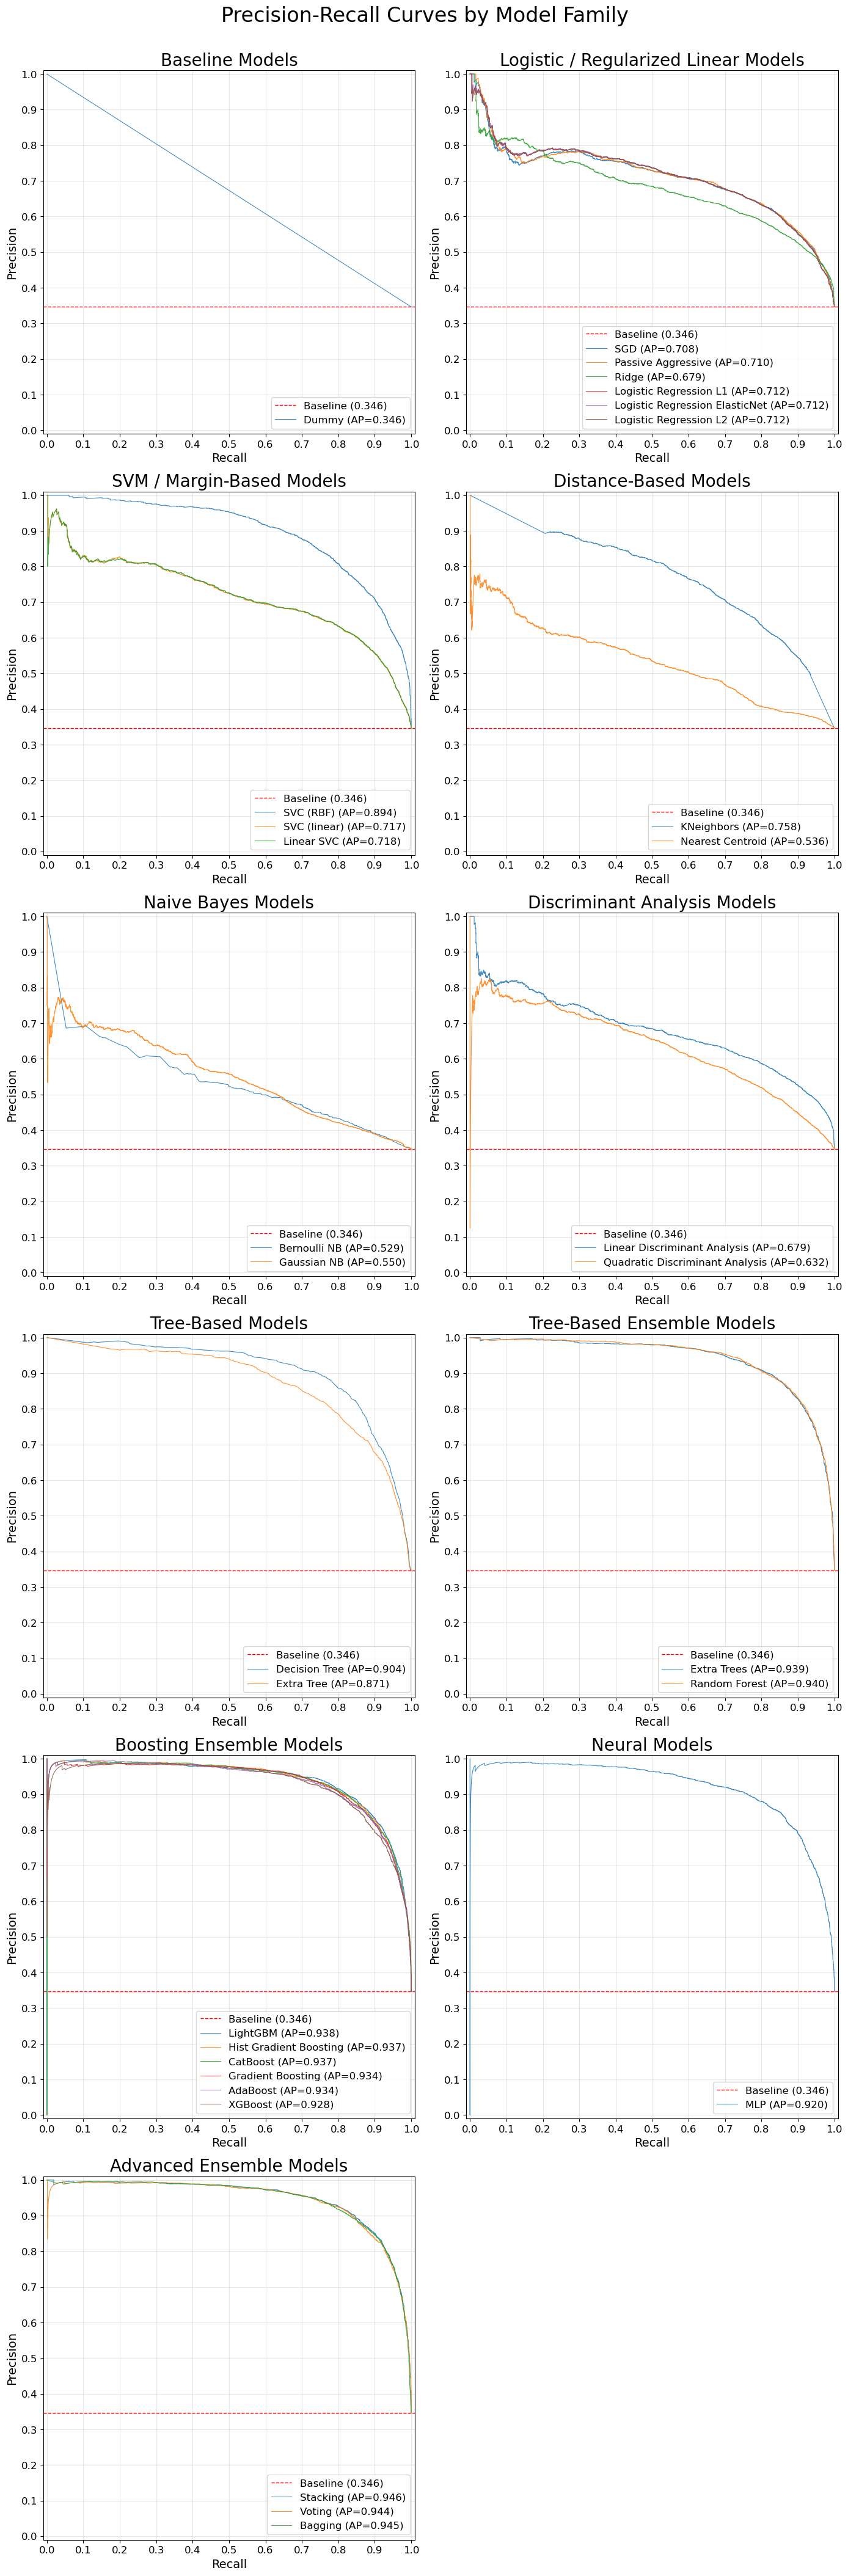

In [671]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import math

# ============================================================
# Precision-Recall Curves by model family
# ============================================================

positive_class_rate = np.mean(y_test)

family_to_models = {family: [] for family in family_order}

for model_name in top_model_names:
    y_score = best_score_candidates.get(model_name)

    if y_score is None:
        continue

    family = get_binary_classifier_family(model_name)
    family_to_models[family].append(model_name)

available_families = {
    family: models
    for family, models in family_to_models.items()
    if len(models) > 0
}

n_families = len(available_families)

if n_families == 0:
    print("No models with score values were found for Precision-Recall family plots.")
else:
    n_cols = 2
    n_rows = math.ceil(n_families / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 7 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, (family, models) in zip(axes, available_families.items()):

        # Plot baseline first so it appears first in the legend
        ax.axhline(
            y=positive_class_rate,
            linestyle="--",
            linewidth=1,
            label=f"Baseline ({positive_class_rate:.3f})",
            zorder=1,
            color="red"
        )

        for model_name in models:
            y_score = best_score_candidates.get(model_name)

            if y_score is None:
                continue

            precision, recall, _ = precision_recall_curve(y_test, y_score)
            average_precision = average_precision_score(y_test, y_score)

            display_name = str(model_name).replace(" Classifier", "")

            ax.plot(
                recall,
                precision,
                linewidth=0.8,
                alpha=0.85,
                label=f"{display_name} (AP={average_precision:.3f})",
                zorder=2
            )

        ax.set_title(family, fontsize=20)
        ax.set_xlabel("Recall", fontsize=14)
        ax.set_ylabel("Precision", fontsize=14)
        ax.grid(alpha=0.3)
        ax.set_xticks(np.linspace(0, 1, 11))
        ax.set_yticks(np.linspace(0, 1, 11))
        ax.legend(loc="lower right", fontsize=12)
        ax.set_ylim([-0.01, 1.01])
        ax.set_xlim([-0.01, 1.01])

    for ax in axes[len(available_families):]:
        ax.axis("off")

    plt.suptitle("Precision-Recall Curves by Model Family", fontsize=24, y=1.003)
    plt.tight_layout()

    if SAVE_PORTFOLIO_OUTPUTS:
        output_path = BINARY_CLASSIFICATION_IMAGES_DIR / "supervised_binary_classification_precision_recall_curve_by_model_family.png"

        fig.savefig(
            output_path,
            dpi=FIG_DPI,
            bbox_inches="tight"
        )

        print("Saved:", output_path)

    plt.show()

### Precision-Recall Curve for All Tuned Binary Classification Models

This plot compares the trade-off between precision and recall for the tuned binary classification models.

Precision-recall curves are especially useful when the positive class is important or when class balance is not perfect.

Saved: _exports\binary_classification_models\images\supervised_binary_classification_precision_recall_curve_all_models.png


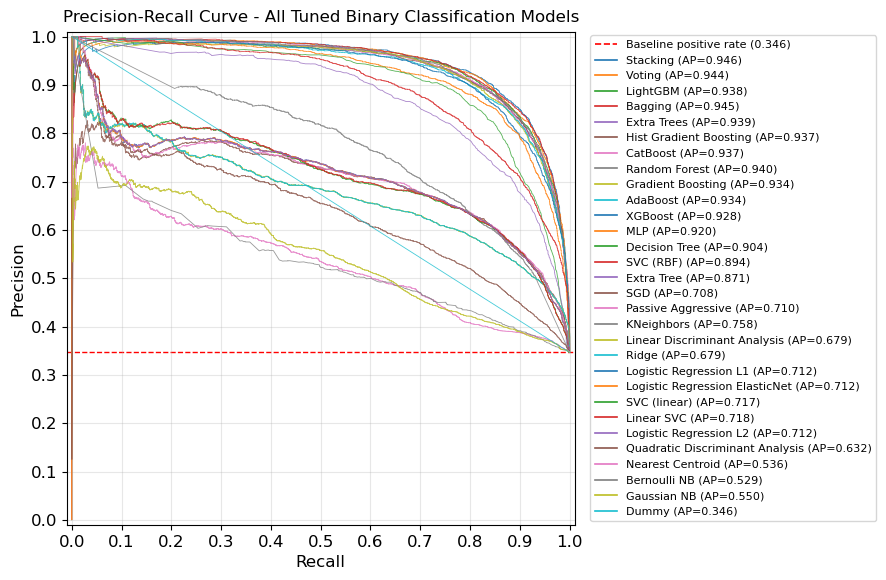

Models included in Precision-Recall curve: 30


In [672]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# ============================================================
# Precision-Recall Curve for all tuned binary classification models
# ============================================================

plt.figure(figsize=(9, 5.9))

available_pr_models = []

positive_class_rate = np.mean(y_test)

# Plot baseline first so it appears first in the legend
plt.axhline(
    y=positive_class_rate,
    linestyle="--",
    linewidth=1,
    label=f"Baseline positive rate ({positive_class_rate:.3f})",
    zorder=1,
    color="red"
)

for model_name in top_model_names:
    y_score = best_score_candidates.get(model_name)

    if y_score is None:
        continue

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    average_precision = average_precision_score(y_test, y_score)

    available_pr_models.append(model_name)

    display_name = (
        model_name
        .replace(" Classifier", "")
    )

    plt.plot(
        recall,
        precision,
        linewidth=0.6,
        alpha=0.8,
        label=f"{display_name} (AP={average_precision:.3f})",
        zorder=2
    )

plt.title("Precision-Recall Curve - All Tuned Binary Classification Models", fontsize=12, y=1.003)
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(np.linspace(0, 1, 11))
plt.yticks(np.linspace(0, 1, 11))

legend = plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8
)

# Make legend lines thicker and more visible without changing the plot lines
for line in legend.get_lines():
    line.set_linewidth(1.2)
    line.set_alpha(1.0)

plt.tight_layout()
plt.ylim([-0.01, 1.01])
plt.xlim([-0.01, 1.01])

if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_IMAGES_DIR / "supervised_binary_classification_precision_recall_curve_all_models.png"

    plt.savefig(
        output_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    print("Saved:", output_path)

plt.show()

print("Models included in Precision-Recall curve:", len(available_pr_models))

### Classification Errors for the Best Binary Classification Model
**This plot shows the type of classification errors made by the model.**
- 0 means correct prediction.
- 1 means false positive: predicted higher clarity, but actual was lower clarity.
- -1 means false negative: predicted lower clarity, but actual was higher clarity.

Saved: _exports\binary_classification_models\images\supervised_binary_classification_errors_best_model.png


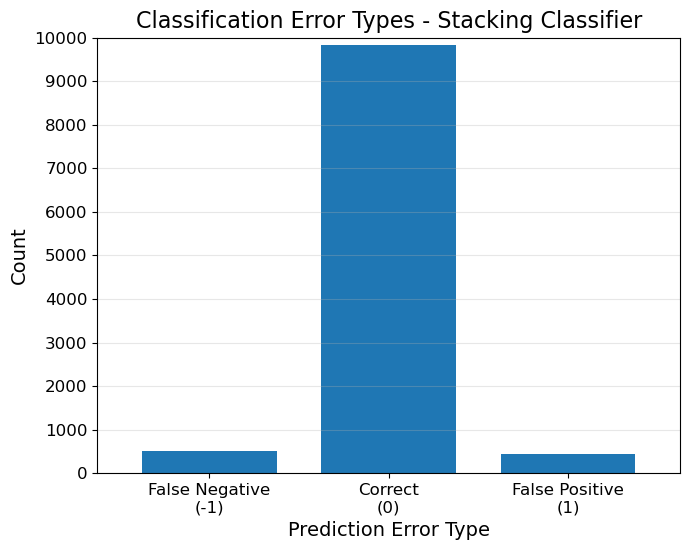

In [673]:
error_counts = best_prediction_errors.value_counts().reindex([-1, 0, 1], fill_value=0)

plt.figure(figsize=(7, 5.6))
error_counts.plot.bar(width=0.75)

plt.xticks(
    ticks=[0, 1, 2],
    labels=["False Negative\n(-1)", "Correct\n(0)", "False Positive\n(1)"],
    rotation=0
)

plt.title(f"Classification Error Types - {best_model_name}", fontsize=16, y=1.003)
plt.xlabel("Prediction Error Type")
plt.ylabel("Count")
plt.ylim([0, 10000])
plt.grid(axis="y", alpha=0.3)
plt.yticks(np.linspace(0, 10000, 11))
plt.tight_layout()

if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_IMAGES_DIR / "supervised_binary_classification_errors_best_model.png"

    plt.savefig(
        output_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    print("Saved:", output_path)

plt.show()

### Classification Errors for All Tuned Binary Classification Models

Saved: _exports\binary_classification_models\images\supervised_binary_classification_errors_all_models.png


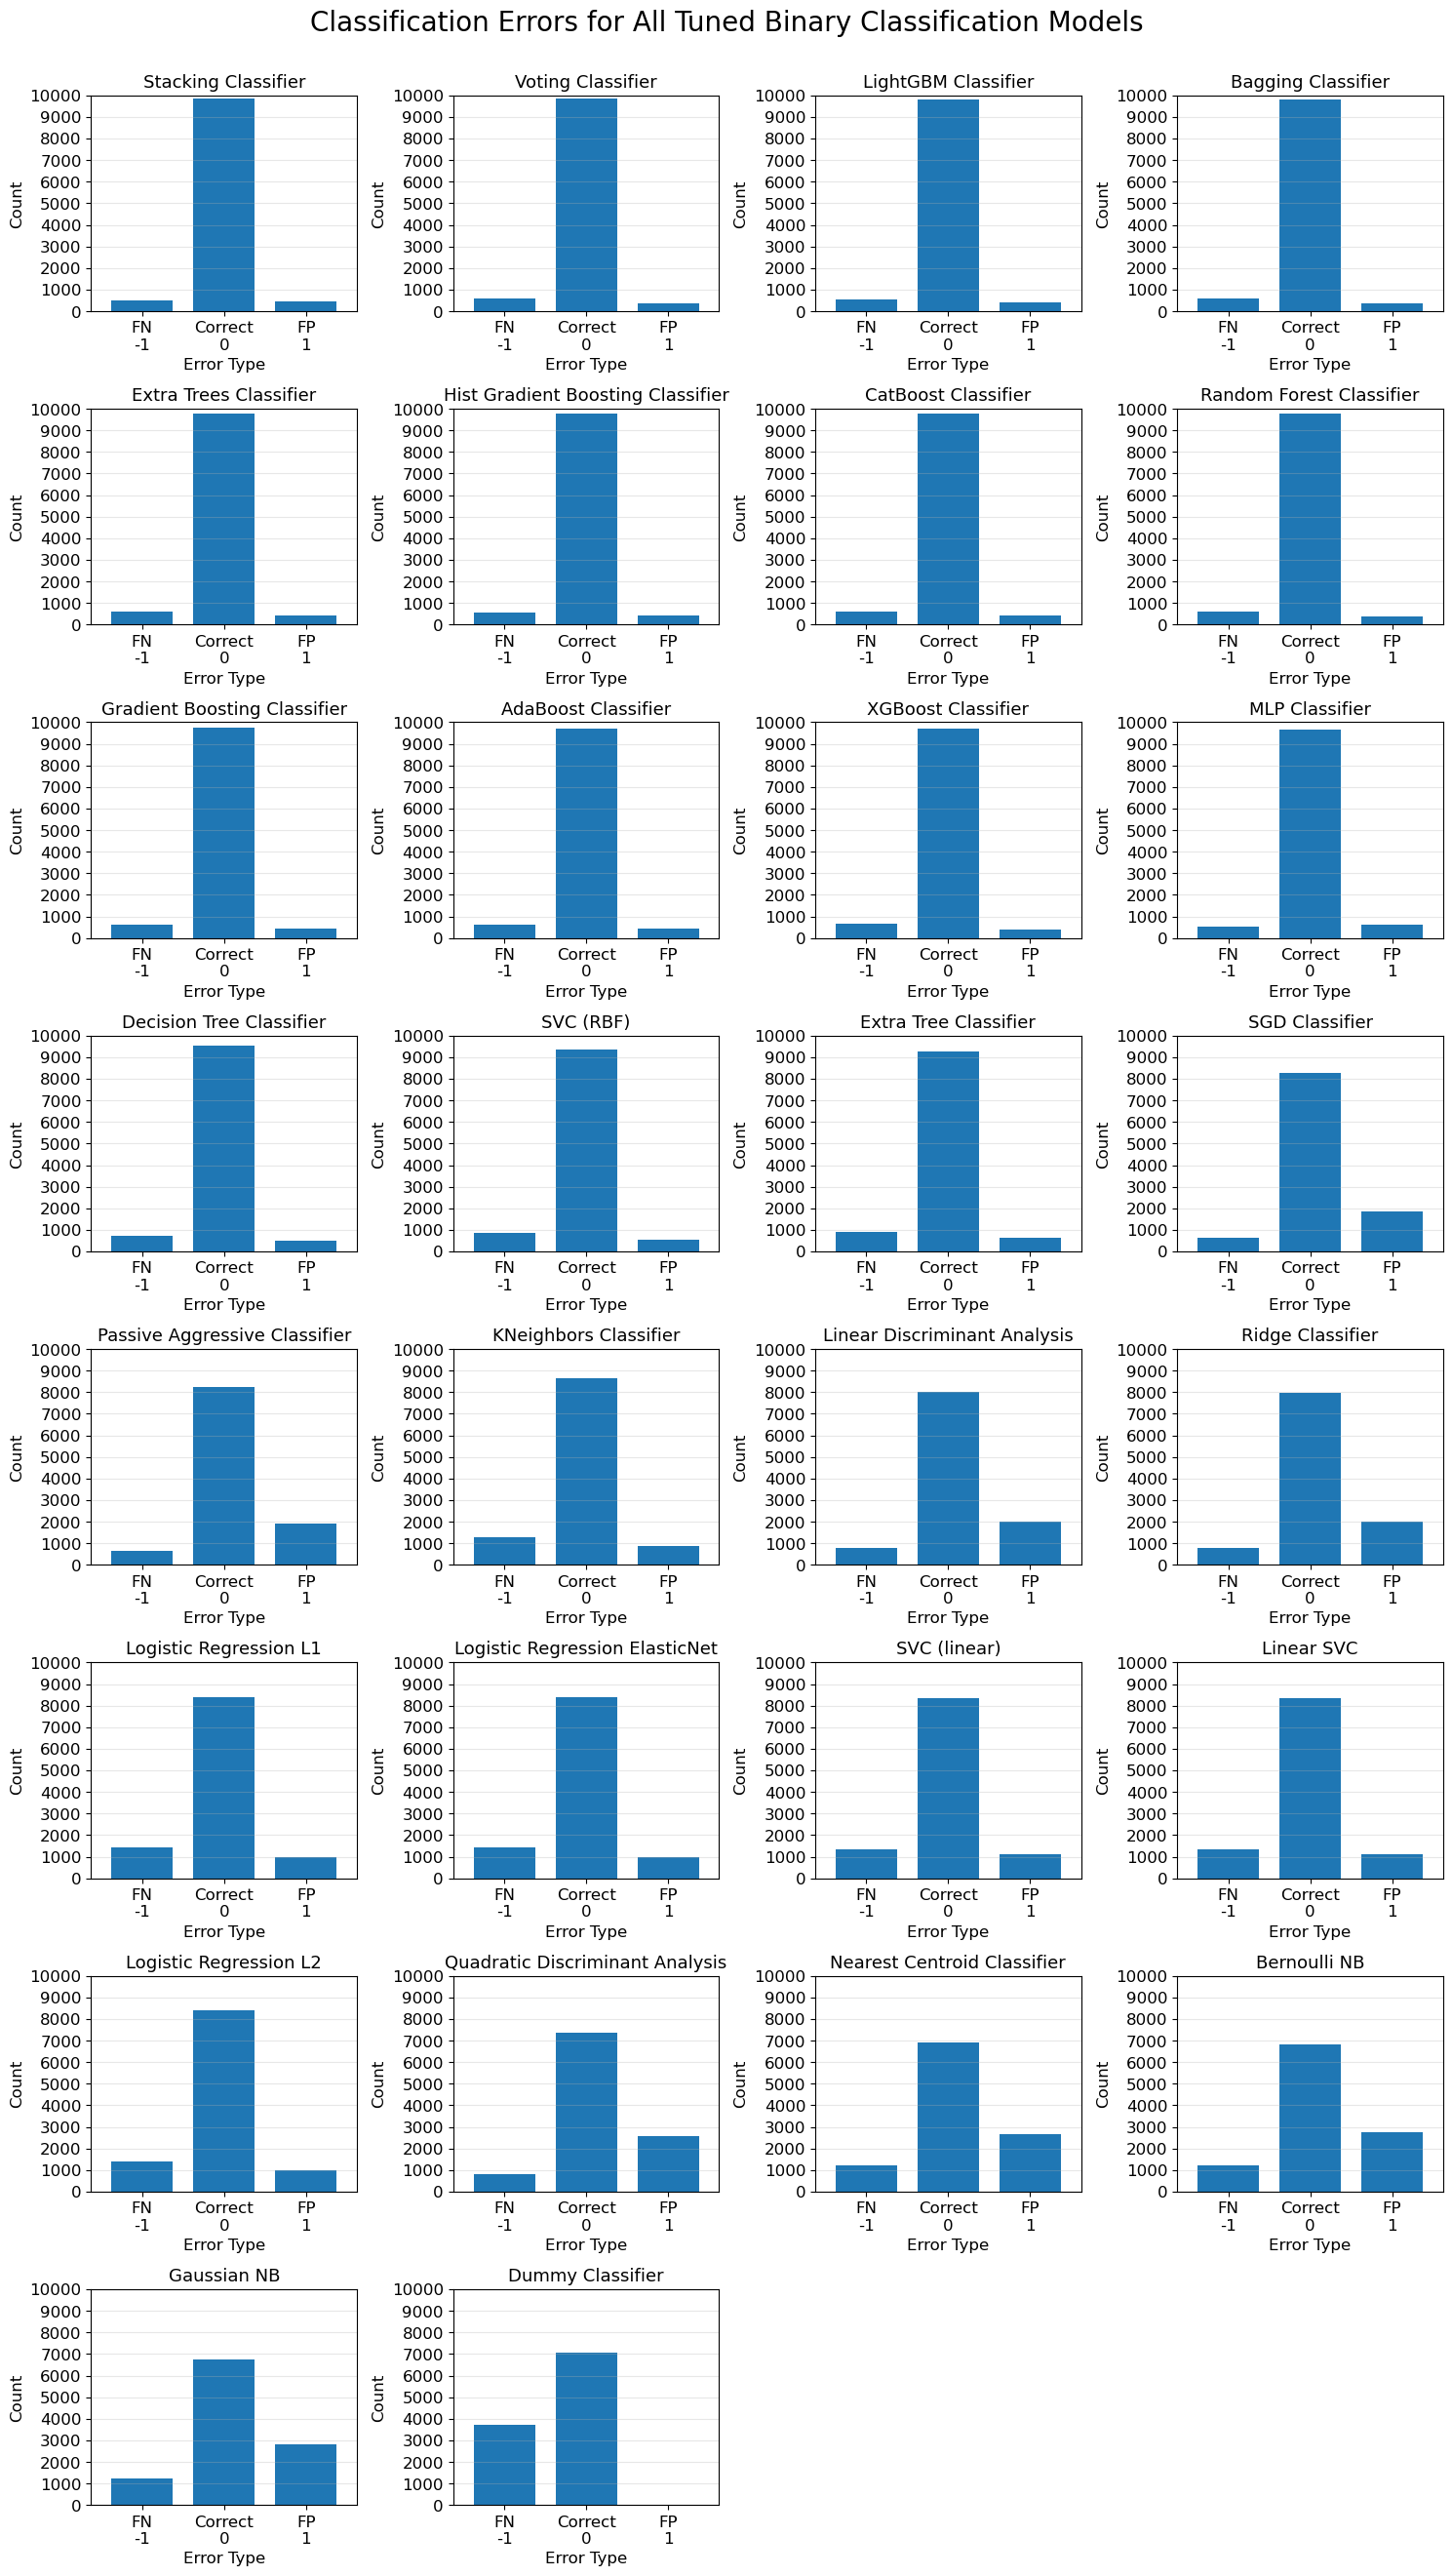

In [674]:
fig, axes = plt.subplots(plt_rows, plt_columns, figsize=(figsize_width, figsize_height))
axes = axes.ravel()

for ax, model_name in zip(axes, top_model_names):
    y_pred = pd.Series(best_pred_candidates[model_name]).reset_index(drop=True)
    model_prediction_errors = y_pred - best_y_true

    error_counts = model_prediction_errors.value_counts().reindex([-1, 0, 1], fill_value=0)
    error_counts.plot.bar(ax=ax, width=0.75)

    ax.set_title(model_name, fontsize=13)
    ax.set_xlabel("Error Type", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_ylim([0, 10000])

    ax.set_xticks([0, 1, 2])
    ax.set_yticks(np.linspace(0, 10000, 11))
    ax.set_xticklabels(["FN\n-1", "Correct\n0", "FP\n1"], rotation=0)

    ax.grid(axis="y", alpha=0.3)

for ax in axes[len(top_model_names):]:
    ax.axis("off")

plt.suptitle("Classification Errors for All Tuned Binary Classification Models", fontsize=20, y=1.003)
plt.tight_layout()

if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_IMAGES_DIR / "supervised_binary_classification_errors_all_models.png"

    fig.savefig(
        output_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    print("Saved:", output_path)

plt.show()

## <span style="color:#275edb">best_params summary</span>

In [675]:
# Create best searches table only from variables that already exist
BEST_SEARCHES = {}

search_candidates = [
    # Logistic / regularized linear models
    ("Logistic Regression L2", "log_reg_l2_search"),
    ("Logistic Regression L1", "log_reg_l1_search"),
    ("Logistic Regression ElasticNet", "log_reg_elastic_search"),
    ("Ridge Classifier", "ridge_search"),
    ("SGD Classifier", "sgd_search"),
    ("Passive Aggressive Classifier", "pa_search"),

    # SVM / margin-based models
    ("Linear SVC", "linear_svc_search"),
    ("SVC (linear)", "svc_linear_search"),
    ("SVC (RBF)", "svc_rbf_search"),

    # Distance-based models
    ("KNeighbors Classifier", "knn_search"),
    ("Nearest Centroid Classifier", "nearest_centroid_search"),

    # Naive Bayes models
    ("Gaussian NB", "gaussian_nb_search"),
    ("Bernoulli NB", "bernoulli_nb_search"),

    # Discriminant analysis models
    ("Linear Discriminant Analysis", "lda_search"),
    ("Quadratic Discriminant Analysis", "qda_search"),

    # Tree-based models
    ("Decision Tree Classifier", "dt_search"),
    ("Extra Tree Classifier", "extra_tree_search"),

    # Tree-based ensemble models
    ("Random Forest Classifier", "rf_search"),
    ("Extra Trees Classifier", "extra_trees_search"),

    # Boosting ensemble models
    ("AdaBoost Classifier", "ada_search"),
    ("Gradient Boosting Classifier", "gb_search"),
    ("Hist Gradient Boosting Classifier", "hgb_search"),
    ("XGBoost Classifier", "xgb_search"),
    ("LightGBM Classifier", "lgbm_search"),
    ("CatBoost Classifier", "cat_search"),

    # Neural models
    ("MLP Classifier", "mlp_search"),

    # Advanced ensemble models
    ("Bagging Classifier", "bagging_search"),
    ("Voting Classifier", "voting_search"),
    ("Stacking Classifier", "stacking_search")
]

for model_name, var_name in search_candidates:
    if var_name in globals():
        BEST_SEARCHES[model_name] = globals()[var_name]

In [676]:
best_params_summary = []

for model_name, model_obj in BEST_SEARCHES.items():
    best_params_summary.append({
        "Model": model_name,
        "Best_Params": model_obj.best_params_
    })

best_params_summary_df = pd.DataFrame(best_params_summary)

best_params_summary_df = best_params_summary_df.merge(
    results_df_sorted[[
        "Model",
        "Tun_Accuracy",
        "Tun_Precision",
        "Tun_Recall",
        "Tun_F1",
        "Tun_ROC_AUC"
    ]],
    on="Model",
    how="left"
)

# Choose sorting metric
SORT_BY = "Tun_F1"          # Common alternatives: "Tun_ROC_AUC", "Tun_Accuracy", "Tun_Precision", "Tun_Recall"
SORT_ASCENDING = False      # Higher is better for classification metrics

best_params_summary_df = best_params_summary_df[
    [
        "Model",
        "Tun_Accuracy",
        "Tun_Precision",
        "Tun_Recall",
        "Tun_F1",
        "Tun_ROC_AUC",
        "Best_Params"
    ]
].sort_values(SORT_BY, ascending=SORT_ASCENDING).reset_index(drop=True)

# Remove " Classifier" from Model and move it to index
best_params_summary_df["Model"] = (
    best_params_summary_df["Model"]
    .str.replace(" Classifier", "", regex=False)
)

best_params_summary_df = best_params_summary_df.set_index("Model")
best_params_summary_df.index.name = None

display(
    best_params_summary_df.style
        .format({
            "Tun_Accuracy": "{:.4f}",
            "Tun_Precision": "{:.4f}",
            "Tun_Recall": "{:.4f}",
            "Tun_F1": "{:.4f}",
            "Tun_ROC_AUC": "{:.4f}"
        })
        .map_index(
            lambda v: "text-align: left; white-space: nowrap;",
            axis=0
        )
        .set_properties(
            subset=pd.IndexSlice[:, ["Best_Params"]],
            **{
                "text-align": "left",
                "white-space": "normal"
            }
        )
        .set_table_styles([
            {
                "selector": "th.row_heading",
                "props": [
                    ("text-align", "left"),
                    ("white-space", "nowrap")
                ]
            },
            {
                "selector": "th.col_heading",
                "props": [
                    ("text-align", "left")
                ]
            },
            {
                "selector": "th, td",
                "props": [
                    ("border", "1px solid #d0d0d0")
                ]
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse")
                ]
            }
        ], overwrite=False)
)

,Tun_Accuracy,Tun_Precision,Tun_Recall,Tun_F1,Tun_ROC_AUC,Best_Params
Stacking,0.9122,0.8815,0.8624,0.8719,0.9682,"{'estimators': ['rf_best_tuning', 'extra_trees_best_tuning', 'hgb_best_tuning', 'xgb_best_tuning', 'lgbm_best_tuning', 'cat_best_tuning', 'mlp_best_tuning'], 'final_estimator': 'LogisticRegression(max_iter=2000)', 'cv': 'SKFOLD_3', 'stack_method': 'predict_proba', 'passthrough': False, 'additional_grid_search': False}"
Voting,0.9118,0.8957,0.8434,0.8688,0.9673,"{'estimators': ['rf_best_tuning', 'extra_trees_best_tuning', 'hgb_best_tuning', 'xgb_best_tuning', 'lgbm_best_tuning', 'cat_best_tuning'], 'voting': 'soft', 'weights': None, 'additional_grid_search': False}"
LightGBM,0.9101,0.8863,0.8493,0.8674,0.9649,"{'model__boosting_type': 'gbdt', 'model__class_weight': None, 'model__colsample_bytree': 0.9739408989183799, 'model__learning_rate': 0.08753702231821117, 'model__max_depth': 7, 'model__min_child_samples': 33, 'model__n_estimators': 421, 'model__n_jobs': -1, 'model__num_leaves': 51, 'model__objective': 'binary', 'model__reg_alpha': 0.05595986878006084, 'model__reg_lambda': 1.0388868790048469, 'model__subsample': 0.9388877846357622, 'model__subsample_freq': 1, 'model__verbosity': -1}"
Bagging,0.9103,0.8916,0.8434,0.8669,0.9665,"{'model__bootstrap': True, 'model__bootstrap_features': False, 'model__estimator__criterion': 'log_loss', 'model__estimator__max_depth': 40, 'model__estimator__min_samples_leaf': 1, 'model__estimator__min_samples_split': 4, 'model__max_features': 0.9649851016840801, 'model__max_samples': 0.9200768846469449, 'model__n_estimators': 172, 'model__n_jobs': -1}"
Extra Trees,0.9080,0.8863,0.8426,0.8639,0.9636,"{'model__bootstrap': False, 'model__ccp_alpha': 1e-05, 'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': None, 'model__max_features': 0.75, 'model__min_samples_leaf': 1, 'model__min_samples_split': 7, 'model__n_estimators': 452, 'model__n_jobs': -1}"
Hist Gradient Boosting,0.9073,0.8828,0.8445,0.8632,0.9635,"{'model__early_stopping': 'auto', 'model__l2_regularization': 0.1532677239138411, 'model__learning_rate': 0.13266588657937942, 'model__loss': 'log_loss', 'model__max_depth': 7, 'model__max_features': 0.976562270506935, 'model__max_iter': 349, 'model__max_leaf_nodes': 33, 'model__min_samples_leaf': 37, 'model__n_iter_no_change': 20, 'model__tol': 1e-06, 'model__validation_fraction': 0.1}"
CatBoost,0.9070,0.8853,0.8405,0.8623,0.9642,"{'model__allow_writing_files': False, 'model__bagging_temperature': 0.11720653680766063, 'model__border_count': 123, 'model__depth': 7, 'model__eval_metric': 'AUC', 'model__iterations': 563, 'model__l2_leaf_reg': 2.164803676300191, 'model__learning_rate': 0.15183883618709038, 'model__loss_function': 'Logloss', 'model__random_strength': 1.2763399448000508, 'model__thread_count': -1, 'model__verbose': 0}"
Random Forest,0.9064,0.8877,0.8354,0.8607,0.9643,"{'model__bootstrap': True, 'model__class_weight': None, 'model__criterion': 'entropy', 'model__max_depth': 25, 'model__max_features': 0.75, 'model__min_samples_leaf': 6, 'model__min_samples_split': 7, 'model__n_estimators': 169, 'model__n_jobs': -1}"
Gradient Boosting,0.9029,0.8816,0.8311,0.8556,0.9623,"{'model__criterion': 'friedman_mse', 'model__learning_rate': 0.14115610542160187, 'model__loss': 'log_loss', 'model__max_depth': 4, 'model__max_features': None, 'model__min_impurity_decrease': 0.009149596755437807, 'model__min_samples_leaf': 10, 'model__min_samples_split': 12, 'model__n_estimators': 417, 'model__subsample': 0.7992694074557947}"
AdaBoost,0.9009,0.8726,0.8359,0.8539,0.9615,"{'model__estimator': DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, min_samples_split=5, random_state=42), 'model__learning_rate': 1.5372343894881864, 'model__n_estimators': 620}"


## <span style="color:#275edb">Permutation Importance for the Best Binary Classification Model</span>

In [677]:
from sklearn.inspection import permutation_importance

# Permutation importance is used for the best model regardless of model type.
# This gives a consistent, model-agnostic explanation based on the original input features.

PERMUTATION_SCORING = "f1"   # Common alternatives: "accuracy", "precision", "recall", "roc_auc"

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring=PERMUTATION_SCORING,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1
)

importance_values = perm.importances_mean
importance_std = perm.importances_std

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance_values,
    "Std": importance_std,
    "Abs_Importance": np.abs(importance_values)
}).sort_values("Abs_Importance", ascending=False).reset_index(drop=True)

# Add percentage importance
importance_df["Importance_pct"] = (
    importance_df["Abs_Importance"] / importance_df["Abs_Importance"].sum() * 100
)

importance_df["Importance_pct"] = (
    importance_df["Importance_pct"]
    .round(2)
    .astype(str) + "%"
)

print(f"Model explanation type: permutation importance ({best_model_name})")
print(f"Permutation scoring used: {PERMUTATION_SCORING}")

importance_df

Model explanation type: permutation importance (Stacking Classifier)
Permutation scoring used: f1


,Feature,Importance,Std,Abs_Importance,Importance_pct
0,carat,0.47,0.00,0.47,30.73%
1,x,0.37,0.01,0.37,24.49%
2,price,0.36,0.00,0.36,23.74%
3,color,0.21,0.00,0.21,13.51%
4,y,0.06,0.00,0.06,3.96%
5,z,0.03,0.00,0.03,1.99%
6,cut,0.02,0.00,0.02,1.3%
7,table,0.00,0.00,0.00,0.15%
8,depth,0.00,0.00,0.00,0.13%


Saved: _exports\binary_classification_models\images\supervised_binary_classification_permutation_importance.png


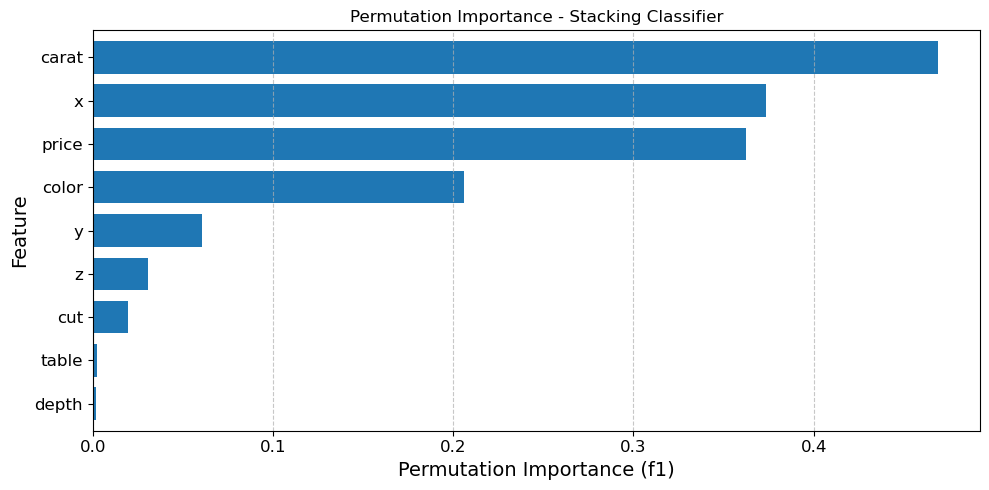

In [678]:
if importance_df is not None:
    top_importance_df = importance_df.sort_values("Importance", ascending=True)

    top_importance_df.plot.barh(
        x="Feature",
        y="Importance",
        figsize=(10, 5),
        width=0.75,
        legend=False
    )

    plt.xlabel(f"Permutation Importance ({PERMUTATION_SCORING})")
    plt.ylabel("Feature")
    plt.title(f"Permutation Importance - {best_model_name}")
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.tight_layout()
    
    if SAVE_PORTFOLIO_OUTPUTS:
        output_path = BINARY_CLASSIFICATION_IMAGES_DIR / "supervised_binary_classification_permutation_importance.png"
    
        plt.savefig(
            output_path,
            dpi=FIG_DPI,
            bbox_inches="tight"
        )
    
        print("Saved:", output_path)
    
    plt.show()

In [679]:
print("Original input features:", len(X_test.columns))
print("Permutation importance values:", len(importance_values))
print("Explanation is based on original input features.")
print(f"Permutation scoring used: {PERMUTATION_SCORING}")

Original input features: 9
Permutation importance values: 9
Explanation is based on original input features.
Permutation scoring used: f1


## <span style="color:#275edb">Decision Threshold Mini Experiment</span>
**This is a small extra test to check whether the model performs better with a different classification threshold.**

Most binary classification models predict a probability or decision score for class `1`.<br>
By default, class `1` is usually predicted when the probability is at least `0.5`.

This experiment tests several threshold values and compares Accuracy, Precision, Recall, and F1-score. ROC-AUC is also shown as a threshold-independent reference metric for the underlying probability or decision scores.

This is useful when the dataset is imbalanced or when Precision and Recall need a better trade-off.

This threshold experiment is exploratory because the threshold is selected on the test set. For production use, the threshold should be selected on a validation set or by cross-validation.

In [680]:
start_fit = time.perf_counter()

In [681]:
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ---------------------------------------------------------
# Decision Threshold Mini Experiment
# ---------------------------------------------------------

# Get probability or decision score from the best model
if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test)[:, 1]
    thresholds = np.arange(0.10, 0.91, 0.05)
    default_threshold = 0.50
    score_type = "predict_proba"

elif hasattr(best_model, "decision_function"):
    y_score = best_model.decision_function(X_test)
    thresholds = np.linspace(y_score.min(), y_score.max(), 50)
    default_threshold = 0.00
    score_type = "decision_function"

else:
    y_score = None
    thresholds = []
    default_threshold = None
    score_type = None


if y_score is not None:
    threshold_results = []

    for threshold in thresholds:
        y_pred_threshold = (y_score >= threshold).astype(int)

        threshold_results.append({
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_test, y_pred_threshold),
            "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
            "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
            "F1": f1_score(y_test, y_pred_threshold, zero_division=0),
        })

    threshold_results_df = pd.DataFrame(threshold_results)

    # Best threshold by F1
    best_threshold_row = threshold_results_df.sort_values(
        "F1",
        ascending=False
    ).iloc[0]

    best_threshold = best_threshold_row["Threshold"]
    best_threshold_pred = (y_score >= best_threshold).astype(int)

    # Normal default prediction
    normal_pred = best_model.predict(X_test)

    # ROC-AUC is threshold-independent
    if pd.Series(y_test).nunique() == 2:
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        roc_auc = np.nan


    # ---------------------------------------------------------
    # Summary table
    # ---------------------------------------------------------
    threshold_summary_df = pd.DataFrame({
        "Model": [best_model_name],
        "Score_Type": [score_type],
        "Default_Threshold": [default_threshold],
        "Best_Threshold_By_F1": [best_threshold],
        "ROC_AUC": [roc_auc]
    })

    styled_threshold_summary = (
        threshold_summary_df.style
            .format({
                "Default_Threshold": "{:.4f}",
                "Best_Threshold_By_F1": "{:.4f}",
                "ROC_AUC": "{:.4f}"
            }, na_rep="—")
            .set_properties(
                subset=pd.IndexSlice[:, ["Model", "Score_Type"]],
                **{
                    "text-align": "left",
                    "white-space": "nowrap",
                    "font-weight": "bold"
                }
            )
            .set_properties(
                subset=pd.IndexSlice[:, ["Default_Threshold", "Best_Threshold_By_F1"]],
                **{"background-color": "#f3f3f3"}
            )
            .set_properties(
                subset=pd.IndexSlice[:, ["ROC_AUC"]],
                **{"background-color": "#d7f5cc"}
            )
            .set_table_styles(
                [
                    {"selector": "th.col_heading", "props": [("text-align", "left"), ("white-space", "nowrap")]},
                    {"selector": "th, td", "props": [("border", "1px solid #d0d0d0")]},
                    {"selector": "table", "props": [("border-collapse", "collapse")]}
                ],
                overwrite=False
            )
    )


    # ---------------------------------------------------------
    # Compare normal prediction vs best-threshold prediction
    # ---------------------------------------------------------
    threshold_metrics_df = pd.DataFrame([
        {
            "Prediction_Type": "Normal Prediction",
            "Threshold": default_threshold,
            "Accuracy": accuracy_score(y_test, normal_pred),
            "Precision": precision_score(y_test, normal_pred, zero_division=0),
            "Recall": recall_score(y_test, normal_pred, zero_division=0),
            "F1": f1_score(y_test, normal_pred, zero_division=0),
            "ROC_AUC": roc_auc
        },
        {
            "Prediction_Type": "Best Threshold Prediction",
            "Threshold": best_threshold,
            "Accuracy": accuracy_score(y_test, best_threshold_pred),
            "Precision": precision_score(y_test, best_threshold_pred, zero_division=0),
            "Recall": recall_score(y_test, best_threshold_pred, zero_division=0),
            "F1": f1_score(y_test, best_threshold_pred, zero_division=0),
            "ROC_AUC": roc_auc
        }
    ])

    styled_threshold_metrics = (
        threshold_metrics_df.style
            .format({
                "Threshold": "{:.4f}",
                "Accuracy": "{:.4f}",
                "Precision": "{:.4f}",
                "Recall": "{:.4f}",
                "F1": "{:.4f}",
                "ROC_AUC": "{:.4f}"
            }, na_rep="—")
            .set_properties(
                subset=pd.IndexSlice[:, ["Prediction_Type"]],
                **{
                    "text-align": "left",
                    "white-space": "nowrap",
                    "font-weight": "bold"
                }
            )
            .set_properties(
                subset=pd.IndexSlice[:, ["Threshold"]],
                **{"background-color": "#f3f3f3"}
            )
            .set_properties(
                subset=pd.IndexSlice[:, ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]],
                **{"background-color": "#d7f5cc"}
            )
            .set_table_styles(
                [
                    {"selector": "th.col_heading", "props": [("text-align", "left"), ("white-space", "nowrap")]},
                    {"selector": "th, td", "props": [("border", "1px solid #d0d0d0")]},
                    {"selector": "table", "props": [("border-collapse", "collapse")]}
                ],
                overwrite=False
            )
    )


    # ---------------------------------------------------------
    # Full threshold results table
    # ---------------------------------------------------------
    threshold_results_display_df = (
        threshold_results_df
        .sort_values("F1", ascending=False)
        .reset_index(drop=True)
    )


    def highlight_best_threshold_row(row):
        if np.isclose(row["Threshold"], best_threshold):
            return ["background-color: #fff2cc; font-weight: bold"] * len(row)
        return [""] * len(row)


    styled_threshold_results = (
        threshold_results_display_df.style
            .format({
                "Threshold": "{:.4f}",
                "Accuracy": "{:.4f}",
                "Precision": "{:.4f}",
                "Recall": "{:.4f}",
                "F1": "{:.4f}"
            })
            .apply(highlight_best_threshold_row, axis=1)
            .set_properties(
                subset=pd.IndexSlice[:, ["Accuracy", "Precision", "Recall", "F1"]],
                **{"background-color": "#d7f5cc"}
            )
            .set_properties(
                subset=pd.IndexSlice[:, ["Threshold"]],
                **{"background-color": "#f3f3f3"}
            )
            .set_table_styles(
                [
                    {"selector": "th.row_heading", "props": [("text-align", "left"), ("white-space", "nowrap")]},
                    {"selector": "th.col_heading", "props": [("text-align", "left"), ("white-space", "nowrap")]},
                    {"selector": "th, td", "props": [("border", "1px solid #d0d0d0")]},
                    {"selector": "table", "props": [("border-collapse", "collapse")]},
                    {
                        "selector": "tbody tr:nth-child(even) td",
                        "props": [("filter", "brightness(0.97)")]
                    },
                    {
                        "selector": "tbody tr:hover td",
                        "props": [("filter", "brightness(0.90)")]
                    }
                ],
                overwrite=False
            )
    )


    # ---------------------------------------------------------
    # Display styled tables
    # ---------------------------------------------------------
    print("1) Threshold Summary - selected model, score type, default threshold and best threshold")
    display(styled_threshold_summary)
    print("")
          
    print("2) Prediction Metrics Comparison - default prediction vs best-threshold prediction")
    display(styled_threshold_metrics)
    print("")
    
    print("3) Threshold Experiment Results - all tested thresholds sorted by F1 score")
    display(styled_threshold_results)

else:
    threshold_unavailable_df = pd.DataFrame({
        "Model": [best_model_name],
        "Message": ["The best model does not provide predict_proba() or decision_function()."]
    })

    display(
        threshold_unavailable_df.style
            .set_properties(
                subset=pd.IndexSlice[:, ["Model", "Message"]],
                **{"text-align": "left", "white-space": "nowrap"}
            )
            .set_table_styles(
                [
                    {"selector": "th.col_heading", "props": [("text-align", "left"), ("white-space", "nowrap")]},
                    {"selector": "th, td", "props": [("border", "1px solid #d0d0d0")]},
                    {"selector": "table", "props": [("border-collapse", "collapse")]}
                ],
                overwrite=False
            )
    )

1) Threshold Summary - selected model, score type, default threshold and best threshold


,Model,Score_Type,Default_Threshold,Best_Threshold_By_F1,ROC_AUC
0,Stacking Classifier,predict_proba,0.5000,0.3500,0.9682



2) Prediction Metrics Comparison - default prediction vs best-threshold prediction


,Prediction_Type,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Normal Prediction,0.5000,0.9122,0.8815,0.8624,0.8719,0.9682
1,Best Threshold Prediction,0.3500,0.9105,0.8521,0.8975,0.8742,0.9682



3) Threshold Experiment Results - all tested thresholds sorted by F1 score


,Threshold,Accuracy,Precision,Recall,F1
0,0.3500,0.9105,0.8521,0.8975,0.8742
1,0.4000,0.9116,0.8624,0.8860,0.8740
2,0.4500,0.9118,0.8710,0.8750,0.8730
3,0.5500,0.9132,0.8919,0.8528,0.8719
4,0.5000,0.9122,0.8815,0.8624,0.8719
5,0.3000,0.9074,0.8375,0.9090,0.8718
6,0.6000,0.9134,0.9024,0.8410,0.8706
7,0.2500,0.9030,0.8208,0.9210,0.8681
8,0.6500,0.9120,0.9131,0.8244,0.8665
9,0.7000,0.9098,0.9211,0.8089,0.8613


In [682]:
threshold_experiment_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(threshold_experiment_time)))
print(f"Experiment time: {formatted_time}")

Experiment time: 0:00:03


### Export Decision Threshold Experiment Tables

In [683]:
# ============================================================
# Export decision threshold experiment tables as CSV
# ============================================================

if SAVE_PORTFOLIO_OUTPUTS:
    if "threshold_results_df" in globals():
        # 1) Threshold summary
        output_path = BINARY_CLASSIFICATION_RESULTS_DIR / "supervised_binary_classification_decision_threshold_summary.csv"

        threshold_summary_df.to_csv(
            output_path,
            index=False,
            encoding="utf-8-sig"
        )

        print("Saved:", output_path)


        # 2) Default prediction vs best-threshold prediction
        output_path = BINARY_CLASSIFICATION_RESULTS_DIR / "supervised_binary_classification_decision_threshold_metrics_comparison.csv"

        threshold_metrics_df.to_csv(
            output_path,
            index=False,
            encoding="utf-8-sig"
        )

        print("Saved:", output_path)


        # 3) All tested thresholds sorted by F1 score
        output_path = BINARY_CLASSIFICATION_RESULTS_DIR / "supervised_binary_classification_decision_threshold_results.csv"

        threshold_results_display_df.to_csv(
            output_path,
            index=False,
            encoding="utf-8-sig"
        )

        print("Saved:", output_path)

    elif "threshold_unavailable_df" in globals():
        output_path = BINARY_CLASSIFICATION_RESULTS_DIR / "supervised_binary_classification_decision_threshold_unavailable.csv"

        threshold_unavailable_df.to_csv(
            output_path,
            index=False,
            encoding="utf-8-sig"
        )

        print("Saved:", output_path)

    else:
        print("No decision threshold experiment table was found.")

Saved: _exports\binary_classification_models\results\supervised_binary_classification_decision_threshold_summary.csv
Saved: _exports\binary_classification_models\results\supervised_binary_classification_decision_threshold_metrics_comparison.csv
Saved: _exports\binary_classification_models\results\supervised_binary_classification_decision_threshold_results.csv


## <span style="color:#275edb">Saving and Loading the Models</span>

### Save all the Fitted Models

In [684]:
start_fit = time.perf_counter()

In [685]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    import os
    import re
    import joblib
    import pandas as pd
    
    EXPORT_DIR = os.path.join("_exports", "binary_classification_models", "fitted_models")
    os.makedirs(EXPORT_DIR, exist_ok=True)
    
    def normalize_model_name(name):
        """Normalize model name for matching and safe filenames."""
        name = str(name).lower()
        name = name.replace(" classifier", "")
        name = name.replace("(", "")
        name = name.replace(")", "")
        name = name.replace("/", "_")
        name = name.replace("-", " ")
        name = re.sub(r"[^a-z0-9_ ]+", "", name)
        name = re.sub(r"\s+", " ", name).strip()
        return name
    
    # Build normalized lookup from TUNED_MODELS
    normalized_tuned_models = {
        normalize_model_name(model_name): model_object
        for model_name, model_object in TUNED_MODELS.items()
    }
    
    saved_models_info = []
    
    for model_name in results_df_with_total["Model"].drop_duplicates():
        if model_name == "Total":
            continue
        
        normalized_name = normalize_model_name(model_name)
        
        if normalized_name not in normalized_tuned_models:
            continue
        
        model_object = normalized_tuned_models[normalized_name]
        
        safe_model_name = normalized_name.replace(" ", "_")
        model_filename = os.path.join(
            EXPORT_DIR,
            f"fitted_model_{safe_model_name}.pkl"
        )
        
        joblib.dump(model_object, model_filename)
        
        file_size_bytes = os.path.getsize(model_filename)
        file_size_mb = file_size_bytes / (1024 * 1024)
        
        saved_models_info.append({
            "Model": model_name,
            "Size_Bytes": file_size_bytes,
            "Size_MB": file_size_mb,
            "File": model_filename
        })
    
    saved_models_df = pd.DataFrame(saved_models_info).reset_index(drop=True)
    
    if saved_models_df.empty:
        raise ValueError(
            "No fitted models were saved. "
            "Check that TUNED_MODELS and results_df_with_total contain matching model names."
        )

In [686]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    saved_models_display_df = (
        saved_models_df[
            ["Model", "Size_Bytes", "Size_MB", "File"]
        ]
        .sort_values("Model")
        .reset_index(drop=True)
    )
    
    styled_saved_models_df = (
        saved_models_display_df.style
        .format({
            "Size_Bytes": "{:,.0f}",
            "Size_MB": "{:,.2f}"
        })
        .set_properties(
            subset=["Model", "File"],
            **{
                "text-align": "left",
                "white-space": "nowrap"
            }
        )
        .set_table_styles([
            {
                "selector": "th.col_heading",
                "props": [("text-align", "left")]
            }
        ], overwrite=False)
    )
    
    display(styled_saved_models_df)

elif QUICK_LOAD:
    print("Saving skipped because QUICK_LOAD = True.")

elif not SAVE_MODEL_ARTIFACTS:
    print("Saving skipped because SAVE_MODEL_ARTIFACTS = False.")

,Model,Size_Bytes,Size_MB,File
0,AdaBoost Classifier,"2,944,613",2.81,_exports\binary_classification_models\fitted_models\fitted_model_adaboost.pkl
1,Bagging Classifier,"71,082,745",67.79,_exports\binary_classification_models\fitted_models\fitted_model_bagging.pkl
2,Bernoulli NB,"4,386",0.00,_exports\binary_classification_models\fitted_models\fitted_model_bernoulli_nb.pkl
3,CatBoost Classifier,"1,220,413",1.16,_exports\binary_classification_models\fitted_models\fitted_model_catboost.pkl
4,Decision Tree Classifier,"81,707",0.08,_exports\binary_classification_models\fitted_models\fitted_model_decision_tree.pkl
5,Dummy Classifier,"3,113",0.00,_exports\binary_classification_models\fitted_models\fitted_model_dummy.pkl
6,Extra Tree Classifier,"222,507",0.21,_exports\binary_classification_models\fitted_models\fitted_model_extra_tree.pkl
7,Extra Trees Classifier,"336,907,970",321.30,_exports\binary_classification_models\fitted_models\fitted_model_extra_trees.pkl
8,Gaussian NB,"4,153",0.00,_exports\binary_classification_models\fitted_models\fitted_model_gaussian_nb.pkl
9,Gradient Boosting Classifier,"993,607",0.95,_exports\binary_classification_models\fitted_models\fitted_model_gradient_boosting.pkl


### Load all the Fitted Models

In [687]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    import os
    import joblib
    import pandas as pd
    
    models_dir = os.path.join("_exports", "binary_classification_models", "fitted_models")
    
    if not os.path.exists(models_dir):
        raise FileNotFoundError(f"Model directory not found: {models_dir}")
    
    loaded_models = {}
    
    for filename in sorted(os.listdir(models_dir)):
        if filename.endswith(".pkl"):
            model_key = filename.replace("fitted_model_", "").replace(".pkl", "")
            full_path = os.path.join(models_dir, filename)
            loaded_models[model_key] = joblib.load(full_path)
    
    if not loaded_models:
        raise FileNotFoundError(
            f"No fitted model .pkl files were found in: {models_dir}"
        )
    
    loaded_models_df = pd.DataFrame({
        "Model_Key": list(loaded_models.keys())
    }).reset_index(drop=True)
    
    display(loaded_models_df)

,Model_Key
0,adaboost
1,bagging
2,bernoulli_nb
3,catboost
4,decision_tree
5,dummy
6,extra_tree
7,extra_trees
8,gaussian_nb
9,gradient_boosting


In [688]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    # Access the loaded Voting model
    display(loaded_models["voting"])

elif QUICK_LOAD:
    print("Loading skipped because QUICK_LOAD = True.")

elif not SAVE_MODEL_ARTIFACTS:
    print("Loading skipped because SAVE_MODEL_ARTIFACTS = False.")

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('extra_trees', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",1
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this valu

## <span style="color:#275edb">Saving and Loading the Search Objects</span>

### Save all the Search Objects

In [689]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    import os
    import re
    import joblib
    import pandas as pd
    
    EXPORT_DIR = os.path.join("_exports", "binary_classification_models", "search_objects")
    os.makedirs(EXPORT_DIR, exist_ok=True)
    
    def normalize_model_name(name):
        """Normalize model name for matching and safe filenames."""
        name = str(name).lower()
        name = name.replace(" classifier", "")
        name = name.replace("(", "")
        name = name.replace(")", "")
        name = name.replace("/", "_")
        name = name.replace("-", " ")
        name = re.sub(r"[^a-z0-9_ ]+", "", name)
        name = re.sub(r"\s+", " ", name).strip()
        return name
    
    # Build normalized lookup from search objects
    normalized_search_objects = {}
    
    # 1) Prefer BEST_SEARCHES dictionary if it exists
    if "BEST_SEARCHES" in globals():
        normalized_search_objects = {
            normalize_model_name(model_name): search_object
            for model_name, search_object in BEST_SEARCHES.items()
        }
    
    # 2) Fallback: build the lookup from variables ending with _search
    elif any(var_name.endswith("_search") for var_name in globals()):
        normalized_search_objects = {
            normalize_model_name(var_name.replace("_search", "")): search_object
            for var_name, search_object in globals().items()
            if var_name.endswith("_search")
        }
    
    if not normalized_search_objects:
        raise NameError(
            "No search objects were found. "
            "Make sure BEST_SEARCHES exists or search variables ending with '_search' exist."
        )
    
    saved_searches_info = []
    
    for model_name in results_df_with_total["Model"].drop_duplicates():
        if model_name == "Total":
            continue
        
        normalized_name = normalize_model_name(model_name)
        
        if normalized_name not in normalized_search_objects:
            continue
        
        search_object = normalized_search_objects[normalized_name]
        
        safe_model_name = normalized_name.replace(" ", "_")
        search_filename = os.path.join(
            EXPORT_DIR,
            f"binary_classification_search_{safe_model_name}.pkl"
        )
        
        joblib.dump(search_object, search_filename)
        
        file_size_bytes = os.path.getsize(search_filename)
        file_size_mb = file_size_bytes / (1024 * 1024)
        
        saved_searches_info.append({
            "Model": model_name,
            "Size_Bytes": file_size_bytes,
            "Size_MB": file_size_mb,
            "File": search_filename
        })
    
    saved_searches_df = pd.DataFrame(saved_searches_info).reset_index(drop=True)
    
    if saved_searches_df.empty:
        raise ValueError(
            "No search objects were saved. "
            "Check that BEST_SEARCHES/search variables and results_df_with_total contain matching model names."
        )

In [690]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    saved_searches_display_df = (
        saved_searches_df
        .sort_values("Model")
        .reset_index(drop=True)
    )
    
    styled_saved_searches_df = (
        saved_searches_display_df.style
        .format({
            "Size_Bytes": "{:,.0f}",
            "Size_MB": "{:,.2f}"
        })
        .set_properties(
            subset=["Model", "File"],
            **{
                "text-align": "left",
                "white-space": "nowrap"
            }
        )
        .set_table_styles([
            {
                "selector": "th.col_heading",
                "props": [("text-align", "left")]
            }
        ], overwrite=False)
    )
    
    display(styled_saved_searches_df)

elif QUICK_LOAD:
    print("Saving skipped because QUICK_LOAD = True.")

elif not SAVE_MODEL_ARTIFACTS:
    print("Saving skipped because SAVE_MODEL_ARTIFACTS = False.")

,Model,Size_Bytes,Size_MB,File
0,AdaBoost Classifier,"3,064,991",2.92,_exports\binary_classification_models\search_objects\binary_classification_search_adaboost.pkl
1,Bagging Classifier,"119,453,551",113.92,_exports\binary_classification_models\search_objects\binary_classification_search_bagging.pkl
2,Bernoulli NB,"12,375",0.01,_exports\binary_classification_models\search_objects\binary_classification_search_bernoulli_nb.pkl
3,CatBoost Classifier,"1,339,991",1.28,_exports\binary_classification_models\search_objects\binary_classification_search_catboost.pkl
4,Decision Tree Classifier,"807,407",0.77,_exports\binary_classification_models\search_objects\binary_classification_search_decision_tree.pkl
5,Extra Tree Classifier,"3,050,175",2.91,_exports\binary_classification_models\search_objects\binary_classification_search_extra_tree.pkl
6,Extra Trees Classifier,"607,630,703",579.48,_exports\binary_classification_models\search_objects\binary_classification_search_extra_trees.pkl
7,Gaussian NB,"10,555",0.01,_exports\binary_classification_models\search_objects\binary_classification_search_gaussian_nb.pkl
8,Gradient Boosting Classifier,"1,170,783",1.12,_exports\binary_classification_models\search_objects\binary_classification_search_gradient_boosting.pkl
9,Hist Gradient Boosting Classifier,"1,782,639",1.70,_exports\binary_classification_models\search_objects\binary_classification_search_hist_gradient_boosting.pkl


### Load all the Search Objects

In [691]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    import os
    import joblib
    import pandas as pd
    
    searches_dir = os.path.join("_exports", "binary_classification_models", "search_objects")
    
    if not os.path.exists(searches_dir):
        raise FileNotFoundError(f"Search directory not found: {searches_dir}")
    
    loaded_searches = {}
    
    for filename in sorted(os.listdir(searches_dir)):
        if filename.endswith(".pkl"):
            search_key = filename.replace("binary_classification_search_", "").replace(".pkl", "")
            full_path = os.path.join(searches_dir, filename)
            loaded_searches[search_key] = joblib.load(full_path)
    
    if not loaded_searches:
        raise FileNotFoundError(
            f"No search object .pkl files were found in: {searches_dir}"
        )
    
    loaded_searches_table = pd.DataFrame({
        "Search_Key": list(loaded_searches.keys()),
        "Object_Type": [type(search).__name__ for search in loaded_searches.values()]
    }).reset_index(drop=True)
    
    display(loaded_searches_table)

,Search_Key,Object_Type
0,adaboost,RandomizedSearchCV
1,bagging,RandomizedSearchCV
2,bernoulli_nb,GridSearchCV
3,catboost,RandomizedSearchCV
4,decision_tree,GridSearchCV
5,extra_tree,GridSearchCV
6,extra_trees,RandomizedSearchCV
7,gaussian_nb,GridSearchCV
8,gradient_boosting,RandomizedSearchCV
9,hist_gradient_boosting,RandomizedSearchCV


In [692]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    # Access the loaded Voting search object
    display(loaded_searches["voting"])
    
elif QUICK_LOAD:
    print("Loading skipped because QUICK_LOAD = True.")

elif not SAVE_MODEL_ARTIFACTS:
    print("Loading skipped because SAVE_MODEL_ARTIFACTS = False.")

namespace(best_estimator_=VotingClassifier(estimators=[('rf',
                                                        Pipeline(steps=[('preprocessing',
                                                                         ColumnTransformer(transformers=[('num',
                                                                                                          'passthrough',
                                                                                                          ['carat',
                                                                                                           'depth',
                                                                                                           'table',
                                                                                                           'price',
                                                                                                           'x',
                                      

## <span style="color:#275edb">Saving and Loading the Base Models</span>

### Save all the Base Models

In [693]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    import os
    import re
    import joblib
    import pandas as pd
    
    EXPORT_DIR = os.path.join("_exports", "binary_classification_models", "fitted_base_models")
    os.makedirs(EXPORT_DIR, exist_ok=True)
    
    def normalize_model_name(name):
        """Normalize model name for matching and safe filenames."""
        name = str(name).lower()
        name = name.replace(" classifier", "")
        name = name.replace("(", "")
        name = name.replace(")", "")
        name = name.replace("/", "_")
        name = name.replace("-", " ")
        name = re.sub(r"[^a-z0-9_ ]+", "", name)
        name = re.sub(r"\s+", " ", name).strip()
        return name
    
    model_variable_map = {
        # Baseline models
        "dummy": "dummy_clf",
        
        # Logistic / regularized linear models
        "logistic regression l2": "log_reg_l2_clf",
        "logistic regression l1": "log_reg_l1_clf",
        "logistic regression elasticnet": "log_reg_elastic_clf",
        "ridge": "ridge_clf",
        "sgd": "sgd_clf",
        "passive aggressive": "pa_clf",
        
        # SVM / margin-based models
        "linear svc": "linear_svc_clf",
        "svc linear": "svc_linear_clf",
        "svc rbf": "svc_rbf_clf",
        
        # Distance-based models
        "kneighbors": "knn_clf",
        "nearest centroid": "nearest_centroid_clf",
        
        # Naive Bayes models
        "gaussian nb": "gaussian_nb_clf",
        "bernoulli nb": "bernoulli_nb_clf",
        
        # Discriminant analysis models
        "linear discriminant analysis": "lda_clf",
        "quadratic discriminant analysis": "qda_clf",
        
        # Tree-based models
        "decision tree": "dt_clf",
        "extra tree": "extra_tree_clf",
        
        # Tree-based ensemble models
        "random forest": "rf_clf",
        "extra trees": "extra_trees_clf",
        
        # Boosting ensemble models
        "adaboost": "ada_clf",
        "gradient boosting": "gb_clf",
        "hist gradient boosting": "hgb_clf",
        "xgboost": "xgb_clf",
        "lightgbm": "lgbm_clf",
        "catboost": "cat_clf",
        
        # Neural models
        "mlp": "mlp_clf",
        
        # Advanced ensemble models
        "bagging": "bagging_clf",
        "voting": "voting_clf",
        "stacking": "stacking_clf",
    }
    
    saved_fitted_base_models_info = []
    
    for model_name in results_df_with_total["Model"].drop_duplicates():
        if model_name == "Total":
            continue
        
        normalized_name = normalize_model_name(model_name)
        
        if normalized_name not in model_variable_map:
            continue
        
        var_name = model_variable_map[normalized_name]
        
        if var_name not in globals():
            continue
        
        fitted_model = globals()[var_name]
        
        safe_model_name = normalized_name.replace(" ", "_")
        
        model_filename = os.path.join(
            EXPORT_DIR,
            f"fitted_base_model_{safe_model_name}.pkl"
        )
        
        joblib.dump(fitted_model, model_filename)
        
        file_size_bytes = os.path.getsize(model_filename)
        file_size_mb = file_size_bytes / (1024 * 1024)
        
        saved_fitted_base_models_info.append({
            "Model": model_name,
            "Size_Bytes": file_size_bytes,
            "Size_MB": file_size_mb,
            "File": model_filename
        })
    
    saved_fitted_base_models_df = pd.DataFrame(saved_fitted_base_models_info).reset_index(drop=True)
    
    if saved_fitted_base_models_df.empty:
        raise ValueError(
            "No fitted base models were saved. "
            "Check that model_variable_map and results_df_with_total contain matching model names."
        )

In [694]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    saved_fitted_base_models_display_df = (
        saved_fitted_base_models_df
        .sort_values("Model")
        .reset_index(drop=True)
    )
    
    styled_saved_fitted_base_models_df = (
        saved_fitted_base_models_display_df.style
        .format({
            "Size_Bytes": "{:,.0f}",
            "Size_MB": "{:,.2f}"
        })
        .set_properties(
            subset=["Model", "File"],
            **{
                "text-align": "left",
                "white-space": "nowrap"
            }
        )
        .set_table_styles([
            {
                "selector": "th.col_heading",
                "props": [("text-align", "left")]
            }
        ], overwrite=False)
    )
    
    display(styled_saved_fitted_base_models_df)
    
elif QUICK_LOAD:
    print("Saving skipped because QUICK_LOAD = True.")

elif not SAVE_MODEL_ARTIFACTS:
    print("Saving skipped because SAVE_MODEL_ARTIFACTS = False.")

,Model,Size_Bytes,Size_MB,File
0,AdaBoost Classifier,"67,957",0.06,_exports\binary_classification_models\fitted_base_models\fitted_base_model_adaboost.pkl
1,Bagging Classifier,"48,312,793",46.07,_exports\binary_classification_models\fitted_base_models\fitted_base_model_bagging.pkl
2,Bernoulli NB,"4,386",0.00,_exports\binary_classification_models\fitted_base_models\fitted_base_model_bernoulli_nb.pkl
3,CatBoost Classifier,"76,972",0.07,_exports\binary_classification_models\fitted_base_models\fitted_base_model_catboost.pkl
4,Decision Tree Classifier,"692,907",0.66,_exports\binary_classification_models\fitted_base_models\fitted_base_model_decision_tree.pkl
5,Dummy Classifier,"3,113",0.00,_exports\binary_classification_models\fitted_base_models\fitted_base_model_dummy.pkl
6,Extra Tree Classifier,"2,772,587",2.64,_exports\binary_classification_models\fitted_base_models\fitted_base_model_extra_tree.pkl
7,Extra Trees Classifier,"270,639,186",258.10,_exports\binary_classification_models\fitted_base_models\fitted_base_model_extra_trees.pkl
8,Gaussian NB,"4,153",0.00,_exports\binary_classification_models\fitted_base_models\fitted_base_model_gaussian_nb.pkl
9,Gradient Boosting Classifier,"140,485",0.13,_exports\binary_classification_models\fitted_base_models\fitted_base_model_gradient_boosting.pkl


### Load all the Base Models

In [695]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    import os
    import joblib
    import pandas as pd
    
    models_dir = os.path.join("_exports", "binary_classification_models", "fitted_base_models")
    
    if not os.path.exists(models_dir):
        raise FileNotFoundError(f"Model directory not found: {models_dir}")
    
    loaded_fitted_base_models = {}
    
    for filename in sorted(os.listdir(models_dir)):
        if filename.endswith(".pkl"):
            model_key = filename.replace("fitted_base_model_", "").replace(".pkl", "")
            full_path = os.path.join(models_dir, filename)
            loaded_fitted_base_models[model_key] = joblib.load(full_path)
    
    if not loaded_fitted_base_models:
        raise FileNotFoundError(
            f"No fitted base model .pkl files were found in: {models_dir}"
        )
    
    loaded_fitted_base_models_df = pd.DataFrame({
        "Model_Key": list(loaded_fitted_base_models.keys())
    }).reset_index(drop=True)
    
    display(loaded_fitted_base_models_df)

,Model_Key
0,adaboost
1,bagging
2,bernoulli_nb
3,catboost
4,decision_tree
5,dummy
6,extra_tree
7,extra_trees
8,gaussian_nb
9,gradient_boosting


In [696]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    # Access the loaded fitted base Voting model
    display(loaded_fitted_base_models["voting"])

elif QUICK_LOAD:
    print("Loading skipped because QUICK_LOAD = True.")

elif not SAVE_MODEL_ARTIFACTS:
    print("Loading skipped because SAVE_MODEL_ARTIFACTS = False.")

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('extra_trees', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",1
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this valu

## <span style="color:#275edb">Saving and Loading a list of Predictions</span>

### Save all the Predictions

In [697]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    import os
    import re
    import joblib
    import pandas as pd
    
    # Ensure export directory exists
    EXPORT_DIR = os.path.join("_exports", "binary_classification_models", "predictions")
    os.makedirs(EXPORT_DIR, exist_ok=True)
    
    def normalize_name(name: str) -> str:
        """Normalize prediction/score name for safe filenames."""
        name = str(name).lower()
        name = name.replace("(", "").replace(")", "")
        name = name.replace("/", "_")
        name = name.replace("-", " ")
        name = re.sub(r"[^a-z0-9_ ]+", "", name)
        name = re.sub(r"\s+", " ", name).strip()
        return name
    
    prediction_candidate_names = [
        # Baseline models
        "dummy_pred_train",
        "dummy_pred_test",
        "dummy_score_train",
        "dummy_score_test",
        
        # Logistic / regularized linear models
        "log_reg_l2_pred_train",
        "log_reg_l2_pred_test",
        "log_reg_l2_score_train",
        "log_reg_l2_score_test",
        "log_reg_l2_best_pred_train",
        "log_reg_l2_best_pred_test",
        "log_reg_l2_best_score_train",
        "log_reg_l2_best_score_test",
        
        "log_reg_l1_pred_train",
        "log_reg_l1_pred_test",
        "log_reg_l1_score_train",
        "log_reg_l1_score_test",
        "log_reg_l1_best_pred_train",
        "log_reg_l1_best_pred_test",
        "log_reg_l1_best_score_train",
        "log_reg_l1_best_score_test",
        
        "log_reg_elastic_pred_train",
        "log_reg_elastic_pred_test",
        "log_reg_elastic_score_train",
        "log_reg_elastic_score_test",
        "log_reg_elastic_best_pred_train",
        "log_reg_elastic_best_pred_test",
        "log_reg_elastic_best_score_train",
        "log_reg_elastic_best_score_test",
        
        "ridge_pred_train",
        "ridge_pred_test",
        "ridge_score_train",
        "ridge_score_test",
        "ridge_best_pred_train",
        "ridge_best_pred_test",
        "ridge_best_score_train",
        "ridge_best_score_test",
        
        "sgd_pred_train",
        "sgd_pred_test",
        "sgd_score_train",
        "sgd_score_test",
        "sgd_best_pred_train",
        "sgd_best_pred_test",
        "sgd_best_score_train",
        "sgd_best_score_test",
        
        "pa_pred_train",
        "pa_pred_test",
        "pa_score_train",
        "pa_score_test",
        "pa_best_pred_train",
        "pa_best_pred_test",
        "pa_best_score_train",
        "pa_best_score_test",
        
        # SVM / margin-based models
        "linear_svc_pred_train",
        "linear_svc_pred_test",
        "linear_svc_score_train",
        "linear_svc_score_test",
        "linear_svc_best_pred_train",
        "linear_svc_best_pred_test",
        "linear_svc_best_score_train",
        "linear_svc_best_score_test",
        
        "svc_linear_pred_train",
        "svc_linear_pred_test",
        "svc_linear_score_train",
        "svc_linear_score_test",
        "svc_linear_best_pred_train",
        "svc_linear_best_pred_test",
        "svc_linear_best_score_train",
        "svc_linear_best_score_test",
        
        "svc_rbf_pred_train",
        "svc_rbf_pred_test",
        "svc_rbf_score_train",
        "svc_rbf_score_test",
        "svc_rbf_best_pred_train",
        "svc_rbf_best_pred_test",
        "svc_rbf_best_score_train",
        "svc_rbf_best_score_test",
        
        # Distance-based models
        "knn_pred_train",
        "knn_pred_test",
        "knn_score_train",
        "knn_score_test",
        "knn_best_pred_train",
        "knn_best_pred_test",
        "knn_best_score_train",
        "knn_best_score_test",
        
        "nearest_centroid_pred_train",
        "nearest_centroid_pred_test",
        "nearest_centroid_score_train",
        "nearest_centroid_score_test",
        "nearest_centroid_best_pred_train",
        "nearest_centroid_best_pred_test",
        "nearest_centroid_best_score_train",
        "nearest_centroid_best_score_test",
        
        # Naive Bayes models
        "gaussian_nb_pred_train",
        "gaussian_nb_pred_test",
        "gaussian_nb_score_train",
        "gaussian_nb_score_test",
        "gaussian_nb_best_pred_train",
        "gaussian_nb_best_pred_test",
        "gaussian_nb_best_score_train",
        "gaussian_nb_best_score_test",
        
        "bernoulli_nb_pred_train",
        "bernoulli_nb_pred_test",
        "bernoulli_nb_score_train",
        "bernoulli_nb_score_test",
        "bernoulli_nb_best_pred_train",
        "bernoulli_nb_best_pred_test",
        "bernoulli_nb_best_score_train",
        "bernoulli_nb_best_score_test",
        
        # Discriminant analysis models
        "lda_pred_train",
        "lda_pred_test",
        "lda_score_train",
        "lda_score_test",
        "lda_best_pred_train",
        "lda_best_pred_test",
        "lda_best_score_train",
        "lda_best_score_test",
        
        "qda_pred_train",
        "qda_pred_test",
        "qda_score_train",
        "qda_score_test",
        "qda_best_pred_train",
        "qda_best_pred_test",
        "qda_best_score_train",
        "qda_best_score_test",
        
        # Tree-based models
        "dt_pred_train",
        "dt_pred_test",
        "dt_score_train",
        "dt_score_test",
        "dt_best_pred_train",
        "dt_best_pred_test",
        "dt_best_score_train",
        "dt_best_score_test",
        
        "extra_tree_pred_train",
        "extra_tree_pred_test",
        "extra_tree_score_train",
        "extra_tree_score_test",
        "extra_tree_best_pred_train",
        "extra_tree_best_pred_test",
        "extra_tree_best_score_train",
        "extra_tree_best_score_test",
        
        # Tree-based ensemble models
        "rf_pred_train",
        "rf_pred_test",
        "rf_score_train",
        "rf_score_test",
        "rf_best_pred_train",
        "rf_best_pred_test",
        "rf_best_score_train",
        "rf_best_score_test",
        
        "extra_trees_pred_train",
        "extra_trees_pred_test",
        "extra_trees_score_train",
        "extra_trees_score_test",
        "extra_trees_best_pred_train",
        "extra_trees_best_pred_test",
        "extra_trees_best_score_train",
        "extra_trees_best_score_test",
        
        # Boosting ensemble models
        "ada_pred_train",
        "ada_pred_test",
        "ada_score_train",
        "ada_score_test",
        "ada_best_pred_train",
        "ada_best_pred_test",
        "ada_best_score_train",
        "ada_best_score_test",
        
        "gb_pred_train",
        "gb_pred_test",
        "gb_score_train",
        "gb_score_test",
        "gb_best_pred_train",
        "gb_best_pred_test",
        "gb_best_score_train",
        "gb_best_score_test",
        
        "hgb_pred_train",
        "hgb_pred_test",
        "hgb_score_train",
        "hgb_score_test",
        "hgb_best_pred_train",
        "hgb_best_pred_test",
        "hgb_best_score_train",
        "hgb_best_score_test",
        
        "xgb_pred_train",
        "xgb_pred_test",
        "xgb_score_train",
        "xgb_score_test",
        "xgb_best_pred_train",
        "xgb_best_pred_test",
        "xgb_best_score_train",
        "xgb_best_score_test",
        
        "lgbm_pred_train",
        "lgbm_pred_test",
        "lgbm_score_train",
        "lgbm_score_test",
        "lgbm_best_pred_train",
        "lgbm_best_pred_test",
        "lgbm_best_score_train",
        "lgbm_best_score_test",
        
        "cat_pred_train",
        "cat_pred_test",
        "cat_score_train",
        "cat_score_test",
        "cat_best_pred_train",
        "cat_best_pred_test",
        "cat_best_score_train",
        "cat_best_score_test",
        
        # Neural models
        "mlp_pred_train",
        "mlp_pred_test",
        "mlp_score_train",
        "mlp_score_test",
        "mlp_best_pred_train",
        "mlp_best_pred_test",
        "mlp_best_score_train",
        "mlp_best_score_test",
        
        # Advanced ensemble models
        "bagging_pred_train",
        "bagging_pred_test",
        "bagging_score_train",
        "bagging_score_test",
        "bagging_best_pred_train",
        "bagging_best_pred_test",
        "bagging_best_score_train",
        "bagging_best_score_test",
        
        "voting_pred_train",
        "voting_pred_test",
        "voting_score_train",
        "voting_score_test",
        "voting_best_pred_train",
        "voting_best_pred_test",
        "voting_best_score_train",
        "voting_best_score_test",
        
        "stacking_pred_train",
        "stacking_pred_test",
        "stacking_score_train",
        "stacking_score_test",
        "stacking_best_pred_train",
        "stacking_best_pred_test",
        "stacking_best_score_train",
        "stacking_best_score_test",
    ]
    
    # Save only variables that exist, but show which expected variables are missing
    available_prediction_names = [
        pred_name for pred_name in prediction_candidate_names
        if pred_name in globals()
    ]
    
    missing_prediction_names = [
        pred_name for pred_name in prediction_candidate_names
        if pred_name not in globals()
    ]
    
    if missing_prediction_names:
        print("The following prediction/score variables were not found and were skipped:")
        for name in missing_prediction_names:
            print(f"- {name}")
    
    if not available_prediction_names:
        raise NameError(
            "No prediction or score variables were found to save. "
            "Make sure the model prediction cells have been run first."
        )
    
    PREDICTIONS = {
        pred_name: globals()[pred_name]
        for pred_name in available_prediction_names
    }
    
    saved_preds_info = []
    
    for pred_name, pred_array in PREDICTIONS.items():
        normalized = normalize_name(pred_name)
        safe_name = normalized.replace(" ", "_")
        
        filename = os.path.join(EXPORT_DIR, f"{safe_name}_file.pkl")
        
        joblib.dump(pred_array, filename)
        
        file_size_bytes = os.path.getsize(filename)
        file_size_mb = file_size_bytes / (1024 * 1024)
        
        saved_preds_info.append({
            "Prediction": pred_name,
            "Size_Bytes": file_size_bytes,
            "Size_MB": file_size_mb,
            "File": filename
        })
    
    saved_predictions_df = pd.DataFrame(saved_preds_info).reset_index(drop=True)

In [698]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    
    if "saved_predictions_df" not in globals():
        raise NameError(
            "saved_predictions_df does not exist. "
            "Run the prediction/score saving cell before displaying the saved predictions table."
        )
    
    saved_predictions_display_df = (
        saved_predictions_df[
            ["Prediction", "Size_Bytes", "Size_MB", "File"]
        ]
        .sort_values("Prediction")
        .reset_index(drop=True)
        .copy()
    )
    
    styled_saved_predictions_df = (
        saved_predictions_display_df.style
        .format({
            "Size_Bytes": "{:,.0f}",
            "Size_MB": "{:,.2f}"
        })
        .set_properties(
            subset=["Prediction", "File"],
            **{
                "text-align": "left",
                "white-space": "nowrap"
            }
        )
        .set_table_styles([
            {
                "selector": "th.col_heading",
                "props": [("text-align", "left")]
            }
        ], overwrite=False)
    )
    
    display(styled_saved_predictions_df)

elif QUICK_LOAD:
    print("Saving skipped because QUICK_LOAD = True.")

elif not SAVE_MODEL_ARTIFACTS:
    print("Saving skipped because SAVE_MODEL_ARTIFACTS = False.")

,Prediction,Size_Bytes,Size_MB,File
0,ada_best_pred_test,"43,377",0.04,_exports\binary_classification_models\predictions\ada_best_pred_test_file.pkl
1,ada_best_pred_train,"172,833",0.16,_exports\binary_classification_models\predictions\ada_best_pred_train_file.pkl
2,ada_best_score_test,"86,529",0.08,_exports\binary_classification_models\predictions\ada_best_score_test_file.pkl
3,ada_best_score_train,"345,441",0.33,_exports\binary_classification_models\predictions\ada_best_score_train_file.pkl
4,ada_pred_test,"43,377",0.04,_exports\binary_classification_models\predictions\ada_pred_test_file.pkl
5,ada_pred_train,"172,833",0.16,_exports\binary_classification_models\predictions\ada_pred_train_file.pkl
6,ada_score_test,"86,529",0.08,_exports\binary_classification_models\predictions\ada_score_test_file.pkl
7,ada_score_train,"345,441",0.33,_exports\binary_classification_models\predictions\ada_score_train_file.pkl
8,bagging_best_pred_test,"43,377",0.04,_exports\binary_classification_models\predictions\bagging_best_pred_test_file.pkl
9,bagging_best_pred_train,"172,833",0.16,_exports\binary_classification_models\predictions\bagging_best_pred_train_file.pkl


### Load all the Predictions

In [699]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    import os
    import joblib
    import pandas as pd
    
    predictions_dir = os.path.join("_exports", "binary_classification_models", "predictions")
    
    if not os.path.exists(predictions_dir):
        raise FileNotFoundError(f"Prediction directory not found: {predictions_dir}")
    
    loaded_predictions = {}
    
    for filename in sorted(os.listdir(predictions_dir)):
        if filename.endswith(".pkl"):
            prediction_key = filename.replace(".pkl", "")  # remove extension only
            full_path = os.path.join(predictions_dir, filename)
            loaded_predictions[prediction_key] = joblib.load(full_path)
    
    if not loaded_predictions:
        raise FileNotFoundError(
            f"No prediction/score .pkl files were found in: {predictions_dir}"
        )
    
    loaded_predictions_df = pd.DataFrame({
        "Prediction_Key": list(loaded_predictions.keys())
    }).reset_index(drop=True)
    
    # Display all rows
    with pd.option_context("display.max_rows", None):
        display(loaded_predictions_df)

,Prediction_Key
0,ada_best_pred_test_file
1,ada_best_pred_train_file
2,ada_best_score_test_file
3,ada_best_score_train_file
4,ada_pred_test_file
5,ada_pred_train_file
6,ada_score_test_file
7,ada_score_train_file
8,bagging_best_pred_test_file
9,bagging_best_pred_train_file


In [700]:
if not QUICK_LOAD and SAVE_MODEL_ARTIFACTS:
    # Access the loaded SVC linear prediction
    display(loaded_predictions["svc_linear_pred_test_file"])

elif QUICK_LOAD:
    print("Loading skipped because QUICK_LOAD = True.")

elif not SAVE_MODEL_ARTIFACTS:
    print("Loading skipped because SAVE_MODEL_ARTIFACTS = False.")

array([0, 0, 1, ..., 1, 0, 0])

In [701]:
saving_loading_files_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(saving_loading_files_time)))
print(f"Saving and loading files time: {formatted_time}")

Saving and loading files time: 0:00:50


## <span style="color:#275edb">Practical Comparison of Binary Classification Models</span>

### Meaning of the Rating Scales
- Predictive Strength (1–10) → 10 = very strong classification performance
- Base Fit Speed (1–10) → 10 = very fast model training
- Prediction Speed (1–10) → 10 = very fast prediction
- Tuning Cost (1–10) → 10 = very expensive and time-consuming to tune
- Memory Use (1–10) → 10 = requires a lot of memory
- Overfitting Tendency (1–10) → 10 = easily overfits
- Scaling Sensitivity (1–10) → 10 = likely to perform worse without scaling
- Hyperparameter Sensitivity (1–10) → 10 = easy to misconfigure

In [702]:
from io import StringIO
from IPython.display import Markdown, display

# ============================================================
# Practical comparison table
# Single source of truth:
# - displayed as Markdown
# - exported as CSV
# ============================================================

practical_comparison_markdown = r"""
| Model | Released | Predictive Strength | Base Fit Speed | Prediction Speed | Tuning Cost | Memory Use | Overfit | Scaling Sensitivity | Need Scaling? | Hyperparam Sensitivity | External Library? | Can Continue Training? | Continue Training Method | Short Description |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---|
| Dummy Classifier                  | 2010 | 1  | 10 | 10 | 1  | 1  | 1  | 1  | No                | 1 | No             | No  | -                       | Naive baseline model |
| Logistic Regression L2            | 2010 | 7  | 10 | 10 | 3  | 2  | 2  | 7  | Yes / recommended | 5 | No             | No  | -                       | Regularized linear classifier |
| Logistic Regression L1            | 2010 | 7  | 9  | 10 | 4  | 2  | 2  | 8  | Yes / recommended | 6 | No             | No  | -                       | Sparse logistic model with feature selection |
| Logistic Regression ElasticNet    | 2010 | 8  | 8  | 10 | 5  | 3  | 2  | 8  | Yes / recommended | 8 | No             | No  | -                       | Combines L1 and L2 regularization |
| Ridge Classifier                  | 2010 | 7  | 10 | 10 | 2  | 2  | 1  | 7  | Yes / recommended | 4 | No             | No  | -                       | L2-regularized linear classifier |
| SGD Classifier                    | 2010 | 7  | 10 | 10 | 5  | 1  | 4  | 9  | Yes               | 8 | No             | Yes | `partial_fit(X, y)`     | Online linear classifier trained with SGD |
| Passive Aggressive Classifier     | 2010 | 6  | 10 | 10 | 4  | 1  | 5  | 9  | Yes               | 7 | No             | Yes | `partial_fit(X, y)`     | Online margin-based classifier |
| Linear SVC                        | 2010 | 8  | 9  | 10 | 5  | 3  | 3  | 8  | Yes               | 7 | No             | No  | -                       | Fast linear support vector classifier |
| SVC (linear)                      | 2010 | 8  | 3  | 4  | 8  | 5  | 3  | 8  | Yes               | 7 | No             | No  | -                       | Kernel SVC with linear decision boundary |
| SVC (RBF)                         | 2010 | 9  | 2  | 2  | 10 | 8  | 8  | 10 | Yes               | 10 | No            | No  | -                       | Nonlinear kernel support vector classifier |
| KNeighbors Classifier             | 2010 | 7  | 10 | 5  | 5  | 8  | 8  | 10 | Yes               | 6 | No             | No  | -                       | Distance-based classifier |
| Nearest Centroid Classifier       | 2010 | 5  | 10 | 10 | 2  | 1  | 1  | 8  | Yes / recommended | 3 | No             | No  | -                       | Simple centroid-based classifier |
| Gaussian NB                       | 2010 | 5  | 10 | 10 | 2  | 1  | 1  | 5  | Usually helpful   | 3 | No             | Yes | `partial_fit(X, y)`     | Probabilistic Naive Bayes for Gaussian features |
| Bernoulli NB                      | 2010 | 5  | 10 | 10 | 3  | 1  | 1  | 4  | Depends           | 4 | No             | Yes | `partial_fit(X, y)`     | Naive Bayes for binary features |
| Linear Discriminant Analysis      | 2010 | 7  | 10 | 10 | 3  | 3  | 2  | 6  | Yes / recommended | 5 | No             | No  | -                       | Linear discriminant classifier |
| Quadratic Discriminant Analysis   | 2010 | 7  | 9  | 10 | 4  | 4  | 6  | 6  | Yes / recommended | 6 | No             | No  | -                       | Quadratic discriminant classifier |
| Decision Tree Classifier          | 2010 | 7  | 10 | 10 | 4  | 3  | 10 | 1  | No                | 5 | No             | No  | -                       | Single tree-based classifier |
| Extra Tree Classifier             | 2010 | 6  | 10 | 10 | 4  | 3  | 10 | 1  | No                | 5 | No             | No  | -                       | Highly randomized single decision tree |
| Random Forest Classifier          | 2010 | 9  | 8  | 9  | 6  | 7  | 4  | 1  | No                | 6 | No             | Yes | `warm_start=True`       | Bagged ensemble of decision trees |
| Extra Trees Classifier            | 2010 | 9  | 9  | 9  | 5  | 7  | 4  | 1  | No                | 5 | No             | Yes | `warm_start=True`       | Strongly randomized tree ensemble |
| AdaBoost Classifier               | 2010 | 7  | 9  | 10 | 6  | 4  | 6  | 2  | No                | 7 | No             | No  | -                       | Sequential boosting classifier |
| Gradient Boosting Classifier      | 2010 | 9  | 6  | 9  | 8  | 5  | 8  | 2  | No                | 9 | No             | Yes | `warm_start=True`       | Classic gradient boosting classifier |
| Hist Gradient Boosting Classifier | 2019 | 9  | 10 | 10 | 6  | 5  | 7  | 2  | No                | 7 | No             | Yes | `warm_start=True`       | Fast histogram-based boosting classifier |
| XGBoost Classifier                | 2014 | 10 | 10 | 10 | 7  | 7  | 8  | 2  | No                | 9 | Yes (xgboost)  | Yes | `fit(X, y, xgb_model=old_model)` | Powerful regularized boosting classifier |
| LightGBM Classifier               | 2017 | 10 | 10 | 10 | 6  | 5  | 8  | 2  | No                | 8 | Yes (lightgbm) | Yes | `fit(X, y, init_model=old_model)` | Very fast boosting classifier |
| CatBoost Classifier               | 2017 | 10 | 9  | 10 | 6  | 6  | 7  | 2  | No / native cat support | 7 | Yes (catboost) | Yes | `fit(X, y, init_model=old_model)` | Strong boosting model, good with categorical data |
| MLP Classifier                    | 2010 | 8  | 3  | 10 | 8  | 6  | 8  | 10 | Yes               | 9 | No             | Yes | `partial_fit(X, y)`     | Neural network classifier |
| Bagging Classifier                | 2010 | 8  | 7  | 8  | 5  | 6  | Depends | Depends | Depends | 5 | No             | No  | -                       | Ensemble of bootstrap-trained models |
| Voting Classifier                 | 2015 | 8  | 5  | 8  | 4  | 6  | Depends | Depends | Depends | 5 | No             | No  | -                       | Soft voting ensemble of six strong tuned models |
| Stacking Classifier               | 2019 | 9  | 3  | 8  | 7  | 8  | Depends | Depends | Depends | 9 | No             | No  | -                       | Multi-level ensemble using six strong tuned models plus MLP |
"""

# Display the table as Markdown
display(Markdown(practical_comparison_markdown))


# Convert Markdown table to DataFrame
def markdown_table_to_dataframe(markdown_table):
    lines = [
        line.strip()
        for line in markdown_table.strip().splitlines()
        if line.strip().startswith("|")
    ]

    cleaned_rows = []

    for line in lines:
        inner = line.strip().strip("|").strip()

        # Skip Markdown separator row, for example:
        # |:---|:---:|:---:|
        separator_check = inner.replace("|", "").replace(":", "").replace("-", "").replace(" ", "")
        if separator_check == "":
            continue

        columns = [col.strip() for col in inner.split("|")]
        cleaned_rows.append(columns)

    header = cleaned_rows[0]
    rows = cleaned_rows[1:]

    return pd.DataFrame(rows, columns=header)


practical_comparison_df = markdown_table_to_dataframe(practical_comparison_markdown)

# Fix special dash characters before export
practical_comparison_df = practical_comparison_df.replace(
    {
        "—": "-",
        "–": "-",
        "â€”": "-",
        "â€“": "-"
    },
    regex=False
)

# Export as CSV
if SAVE_PORTFOLIO_OUTPUTS:
    output_path = BINARY_CLASSIFICATION_RESULTS_DIR / "supervised_binary_classification_practical_comparison.csv"

    practical_comparison_df.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig"
    )

    print("Saved:", output_path)


| Model | Released | Predictive Strength | Base Fit Speed | Prediction Speed | Tuning Cost | Memory Use | Overfit | Scaling Sensitivity | Need Scaling? | Hyperparam Sensitivity | External Library? | Can Continue Training? | Continue Training Method | Short Description |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---|
| Dummy Classifier                  | 2010 | 1  | 10 | 10 | 1  | 1  | 1  | 1  | No                | 1 | No             | No  | -                       | Naive baseline model |
| Logistic Regression L2            | 2010 | 7  | 10 | 10 | 3  | 2  | 2  | 7  | Yes / recommended | 5 | No             | No  | -                       | Regularized linear classifier |
| Logistic Regression L1            | 2010 | 7  | 9  | 10 | 4  | 2  | 2  | 8  | Yes / recommended | 6 | No             | No  | -                       | Sparse logistic model with feature selection |
| Logistic Regression ElasticNet    | 2010 | 8  | 8  | 10 | 5  | 3  | 2  | 8  | Yes / recommended | 8 | No             | No  | -                       | Combines L1 and L2 regularization |
| Ridge Classifier                  | 2010 | 7  | 10 | 10 | 2  | 2  | 1  | 7  | Yes / recommended | 4 | No             | No  | -                       | L2-regularized linear classifier |
| SGD Classifier                    | 2010 | 7  | 10 | 10 | 5  | 1  | 4  | 9  | Yes               | 8 | No             | Yes | `partial_fit(X, y)`     | Online linear classifier trained with SGD |
| Passive Aggressive Classifier     | 2010 | 6  | 10 | 10 | 4  | 1  | 5  | 9  | Yes               | 7 | No             | Yes | `partial_fit(X, y)`     | Online margin-based classifier |
| Linear SVC                        | 2010 | 8  | 9  | 10 | 5  | 3  | 3  | 8  | Yes               | 7 | No             | No  | -                       | Fast linear support vector classifier |
| SVC (linear)                      | 2010 | 8  | 3  | 4  | 8  | 5  | 3  | 8  | Yes               | 7 | No             | No  | -                       | Kernel SVC with linear decision boundary |
| SVC (RBF)                         | 2010 | 9  | 2  | 2  | 10 | 8  | 8  | 10 | Yes               | 10 | No            | No  | -                       | Nonlinear kernel support vector classifier |
| KNeighbors Classifier             | 2010 | 7  | 10 | 5  | 5  | 8  | 8  | 10 | Yes               | 6 | No             | No  | -                       | Distance-based classifier |
| Nearest Centroid Classifier       | 2010 | 5  | 10 | 10 | 2  | 1  | 1  | 8  | Yes / recommended | 3 | No             | No  | -                       | Simple centroid-based classifier |
| Gaussian NB                       | 2010 | 5  | 10 | 10 | 2  | 1  | 1  | 5  | Usually helpful   | 3 | No             | Yes | `partial_fit(X, y)`     | Probabilistic Naive Bayes for Gaussian features |
| Bernoulli NB                      | 2010 | 5  | 10 | 10 | 3  | 1  | 1  | 4  | Depends           | 4 | No             | Yes | `partial_fit(X, y)`     | Naive Bayes for binary features |
| Linear Discriminant Analysis      | 2010 | 7  | 10 | 10 | 3  | 3  | 2  | 6  | Yes / recommended | 5 | No             | No  | -                       | Linear discriminant classifier |
| Quadratic Discriminant Analysis   | 2010 | 7  | 9  | 10 | 4  | 4  | 6  | 6  | Yes / recommended | 6 | No             | No  | -                       | Quadratic discriminant classifier |
| Decision Tree Classifier          | 2010 | 7  | 10 | 10 | 4  | 3  | 10 | 1  | No                | 5 | No             | No  | -                       | Single tree-based classifier |
| Extra Tree Classifier             | 2010 | 6  | 10 | 10 | 4  | 3  | 10 | 1  | No                | 5 | No             | No  | -                       | Highly randomized single decision tree |
| Random Forest Classifier          | 2010 | 9  | 8  | 9  | 6  | 7  | 4  | 1  | No                | 6 | No             | Yes | `warm_start=True`       | Bagged ensemble of decision trees |
| Extra Trees Classifier            | 2010 | 9  | 9  | 9  | 5  | 7  | 4  | 1  | No                | 5 | No             | Yes | `warm_start=True`       | Strongly randomized tree ensemble |
| AdaBoost Classifier               | 2010 | 7  | 9  | 10 | 6  | 4  | 6  | 2  | No                | 7 | No             | No  | -                       | Sequential boosting classifier |
| Gradient Boosting Classifier      | 2010 | 9  | 6  | 9  | 8  | 5  | 8  | 2  | No                | 9 | No             | Yes | `warm_start=True`       | Classic gradient boosting classifier |
| Hist Gradient Boosting Classifier | 2019 | 9  | 10 | 10 | 6  | 5  | 7  | 2  | No                | 7 | No             | Yes | `warm_start=True`       | Fast histogram-based boosting classifier |
| XGBoost Classifier                | 2014 | 10 | 10 | 10 | 7  | 7  | 8  | 2  | No                | 9 | Yes (xgboost)  | Yes | `fit(X, y, xgb_model=old_model)` | Powerful regularized boosting classifier |
| LightGBM Classifier               | 2017 | 10 | 10 | 10 | 6  | 5  | 8  | 2  | No                | 8 | Yes (lightgbm) | Yes | `fit(X, y, init_model=old_model)` | Very fast boosting classifier |
| CatBoost Classifier               | 2017 | 10 | 9  | 10 | 6  | 6  | 7  | 2  | No / native cat support | 7 | Yes (catboost) | Yes | `fit(X, y, init_model=old_model)` | Strong boosting model, good with categorical data |
| MLP Classifier                    | 2010 | 8  | 3  | 10 | 8  | 6  | 8  | 10 | Yes               | 9 | No             | Yes | `partial_fit(X, y)`     | Neural network classifier |
| Bagging Classifier                | 2010 | 8  | 7  | 8  | 5  | 6  | Depends | Depends | Depends | 5 | No             | No  | -                       | Ensemble of bootstrap-trained models |
| Voting Classifier                 | 2015 | 8  | 5  | 8  | 4  | 6  | Depends | Depends | Depends | 5 | No             | No  | -                       | Soft voting ensemble of six strong tuned models |
| Stacking Classifier               | 2019 | 9  | 3  | 8  | 7  | 8  | Depends | Depends | Depends | 9 | No             | No  | -                       | Multi-level ensemble using six strong tuned models plus MLP |


Saved: _exports\binary_classification_models\results\supervised_binary_classification_practical_comparison.csv


This table is a practical, experience-based summary of the model families tested in this project. It is intended to support interpretation and model selection, but it should not be treated as a formal statistical ranking.

### Python Environment Package Versions

In [703]:
import sys
import importlib

print("Python:", sys.version)
print("=" * (len(sys.version) + 8))

package_groups = {
    "Core ML / data:": [
        ("NumPy", "numpy"),
        ("Pandas", "pandas"),
        ("SciPy", "scipy"),
        ("scikit-learn", "sklearn"),
        ("Statsmodels", "statsmodels"),
        ("Joblib", "joblib"),
        ("threadpoolctl", "threadpoolctl"),
    ],
    "Visualization / notebook helpers:": [
        ("Matplotlib", "matplotlib"),
        ("Seaborn", "seaborn"),
        ("OpenPyXL", "openpyxl"),
    ],
    "Boosting libraries:": [
        ("XGBoost", "xgboost"),
        ("LightGBM", "lightgbm"),
        ("CatBoost", "catboost"),
    ],
    "Hyperparameter tuning:": [
        ("scikit-optimize", "skopt"),
    ],
    "Jupyter-related packages actually used by the environment:": [
        ("IPyKernel", "ipykernel"),
        ("JupyterLab", "jupyterlab"),
        ("Notebook", "notebook"),
    ],
}

for group_name, packages in package_groups.items():
    print(f"\n{group_name}")
    
    for display_name, import_name in packages:
        try:
            module = importlib.import_module(import_name)
            version = getattr(module, "__version__", "no __version__ attribute")
            print(f" - {display_name}: {version}")
        except ImportError:
            print(f" - {display_name}: not installed")

Python: 3.11.14 | packaged by conda-forge | (main, Jan 26 2026, 23:39:55) [MSC v.1944 64 bit (AMD64)]

Core ML / data:
 - NumPy: 1.26.4
 - Pandas: 3.0.2
 - SciPy: 1.17.1
 - scikit-learn: 1.8.0
 - Statsmodels: 0.14.6
 - Joblib: 1.5.3
 - threadpoolctl: 3.6.0

Visualization / notebook helpers:
 - Matplotlib: 3.10.8
 - Seaborn: 0.13.2
 - OpenPyXL: 3.1.5

Boosting libraries:
 - XGBoost: 3.2.0
 - LightGBM: 4.6.0
 - CatBoost: 1.2.10

Hyperparameter tuning:
 - scikit-optimize: 0.10.2

Jupyter-related packages actually used by the environment:
 - IPyKernel: 7.2.0
 - JupyterLab: 4.5.6
 - Notebook: 7.5.5


### System informations

In [704]:
import platform
import sys

print("Execution Environment Summary")
print("=" * 30)

print(f"OS: {platform.system()} {platform.release()}")
print(f"Architecture: {platform.architecture()[0]}")
print(f"Python: {sys.version.split()[0]}")
print()

try:
    import psutil

    print("CPU")
    print("-" * 30)
    print(f"Processor: {platform.processor()}")
    print(f"Physical cores: {psutil.cpu_count(logical=False)}")
    print(f"Logical cores: {psutil.cpu_count(logical=True)}")

    cpu_freq = psutil.cpu_freq()
    if cpu_freq:
        print(f"Current frequency: {cpu_freq.current:.2f} MHz")
        print(f"Max frequency: {cpu_freq.max:.2f} MHz")

    print()

    vm = psutil.virtual_memory()

    print("Memory")
    print("-" * 30)
    print(f"Total RAM: {vm.total / (1024**3):.2f} GB")
    print(f"Available RAM: {vm.available / (1024**3):.2f} GB")
    print(f"RAM usage: {vm.percent}%")

except ImportError:
    print("psutil is not installed, so CPU and memory details are not available.")

Execution Environment Summary
OS: Windows 10
Architecture: 64bit
Python: 3.11.14

CPU
------------------------------
Processor: AMD64 Family 21 Model 1 Stepping 2, AuthenticAMD
Physical cores: 4
Logical cores: 8
Current frequency: 3600.00 MHz
Max frequency: 3600.00 MHz

Memory
------------------------------
Total RAM: 15.96 GB
Available RAM: 2.56 GB
RAM usage: 84.0%


In [705]:
notebook_running_time = time.time() - notebook_start_time

from datetime import timedelta
formatted_time = str(timedelta(seconds=int(notebook_running_time)))

print(f"Total notebook execution time: {formatted_time}")

from datetime import datetime

today = datetime.today()
print(f'Date: {today.strftime("%Y/%m/%d")}')

Total notebook execution time: 6:17:19
Date: 2026/05/27


## Final Model Comparison

The final binary classification comparison shows that the strongest overall performance was achieved by ensemble-based, boosting-based, and meta-estimator models. Based on the primary tuned F1-score metric, the best-performing model was the tuned Stacking Classifier.

The tuned Stacking Classifier achieved the best overall default-threshold test performance, with an F1-score of 0.8719, an accuracy score of 0.9122, and a ROC-AUC score of 0.9682. It also achieved a precision score of 0.8815 and a recall score of 0.8624.

The tuned Voting Classifier was very close behind, achieving an F1-score of 0.8688, an accuracy score of 0.9118, and a ROC-AUC score of 0.9673. Its measured model time was much lower than the tuned Stacking Classifier, making it a strong fast ensemble alternative when computational cost is important.

The decision threshold mini experiment showed that the tuned Stacking Classifier could achieve a slightly higher F1-score of 0.8742 by lowering the decision threshold from 0.50 to 0.35. This increased recall from 0.8624 to 0.8975, but reduced precision from 0.8815 to 0.8521. This demonstrates that threshold selection can be useful when the practical cost of false positives and false negatives is important.

Among the individual non-meta models, tuned LightGBM, tuned Bagging, tuned Extra Trees, tuned Hist Gradient Boosting, tuned CatBoost, and tuned Random Forest all performed strongly. This confirms that tree-based ensemble and boosting methods are highly suitable for this structured tabular classification task.

From a practical model selection perspective, the best statistical model is not always the only reasonable choice. The tuned Stacking and Voting classifiers achieved the strongest ensemble results, but their saved fitted model files were much larger than many individual models because they contain several component estimators. In contrast, tuned LightGBM, tuned CatBoost, tuned Hist Gradient Boosting, and tuned XGBoost offered strong performance with much smaller saved fitted model sizes.

Linear, logistic, probabilistic, discriminant analysis, and distance-based models provided useful baseline comparisons. Although most of these models were less competitive than the strongest ensemble and boosting models, they remain valuable because they are often faster, easier to interpret, and less computationally expensive.

The final model selection should not be based only on a single classification metric. F1-score and ROC-AUC are especially important in this project, but accuracy, precision, recall, confusion matrix behaviour, prediction time, threshold behaviour, saved model size, and deployment practicality should also be considered.

Overall, the project shows that ensemble and boosting approaches provide the strongest performance on this binary classification task, while simpler models remain useful as interpretable and computationally efficient baselines.

## Limitations and Future Work

Although this project compares a broad range of binary classification models, the results should be interpreted with several limitations in mind.

First, the analysis is based on a single structured tabular dataset. Therefore, the results show how the models behave on this particular high-clarity classification task, but they do not prove that the same model family would perform best on all binary classification problems.

Second, the binary target variable is created from the original `clarity` feature. This makes the task suitable for supervised binary classification, but the target definition is specific to this project. Different groupings of clarity grades could lead to different model behaviour and performance results.

Third, the hyperparameter tuning process uses predefined and, in some cases, iteratively refined search spaces. These search spaces were designed to be practical and computationally manageable. The aim was to obtain strong classifier configurations for fair comparison, not to prove that the globally optimal hyperparameters had been found.

Fourth, the tuned Voting and Stacking classifiers are built from the best estimators found by earlier hyperparameter searches. No additional Voting weight search or Stacking final-estimator grid search is applied in the final version, because these extra searches were computationally expensive and produced only small improvements in previous runs. This makes the workflow more practical, but it also means that the ensemble configurations are not exhaustively optimised.

Fifth, the project focuses mainly on classification performance, runtime, probability or decision scores, threshold behaviour, saved model size, and practical model comparison. Although permutation importance is applied to the best-performing model, the project does not yet include a full interpretability analysis using methods such as SHAP across all suitable models.

Sixth, the comparison uses a fixed train-test split and cross-validation strategy. While this provides a consistent experimental framework, repeated cross-validation or statistical significance testing could be used to evaluate whether the performance differences between the top models are statistically meaningful.

Finally, classification performance may depend on the selected decision threshold. The notebook includes a decision threshold mini experiment, but a more detailed threshold optimisation strategy could be explored depending on the practical cost of false positives and false negatives.

Future work could strengthen this project by:

- applying the same benchmarking framework to additional classification datasets;
- testing different definitions of the binary clarity target;
- using repeated cross-validation or statistical significance testing to compare top models;
- adding SHAP or more detailed permutation importance analysis for deeper model interpretation;
- analysing class imbalance and threshold optimisation in more detail;
- comparing calibration quality for models that provide probability estimates;
- testing alternative feature engineering strategies;
- comparing practical deployment trade-offs in more detail;
- turning the notebook into a shorter technical report or paper-style summary.

## Conclusion

This project compared approximately 30 supervised binary classification models on the `diamonds` dataset using a consistent preprocessing, training, tuning, and evaluation framework.

The task was to predict whether a diamond belongs to a higher-clarity group using the remaining available numerical and categorical features after removing the original `clarity` column to prevent data leakage.

The final results show that ensemble-based, boosting-based, and meta-estimator approaches were the strongest model families for this binary classification task. Based on the primary tuned F1-score metric, the best-performing model was the tuned Stacking Classifier.

The tuned Stacking Classifier achieved the best overall default-threshold test performance, with an F1-score of 0.8719, an accuracy score of 0.9122, and a ROC-AUC score of 0.9682. This suggests that combining several strong tuned classifiers through a meta-classifier can improve predictive performance on this structured tabular dataset.

The tuned Voting Classifier also performed very strongly, achieving an F1-score of 0.8688, an accuracy score of 0.9118, and a ROC-AUC score of 0.9673. Although it was slightly behind the tuned Stacking Classifier, it required much less measured model time, making it a strong fast ensemble alternative when computational cost is important.

The decision threshold mini experiment showed that the tuned Stacking Classifier's F1-score could be slightly improved from 0.8719 to 0.8742 by lowering the decision threshold from 0.50 to 0.35. This improved recall but reduced precision, showing that threshold selection can be useful when the practical cost of false positives and false negatives matters.

Among the individual non-meta models, tuned LightGBM, tuned Bagging, tuned Extra Trees, tuned Hist Gradient Boosting, tuned CatBoost, and tuned Random Forest all produced competitive results. This confirms that tree-based ensemble and boosting methods are highly effective for this type of structured classification problem.

Simpler models, including logistic regression, regularized linear models, Naive Bayes, discriminant analysis, distance-based methods, and single-tree models, were generally less competitive than the strongest ensemble and boosting methods. However, they remain valuable as baselines because they are often faster, easier to interpret, and less computationally expensive.

The project also shows why classification models should not be compared using only one metric. F1-score and ROC-AUC were especially important in this notebook, but accuracy, precision, recall, confusion matrix behaviour, threshold behaviour, runtime, interpretability, saved model size, and practical usability all provide important additional context.

The saved fitted model file sizes add another practical perspective to the comparison. Large ensemble models can provide excellent predictive performance, but they may also create larger model artifacts and require more storage or deployment resources. In contrast, some individual boosting models, such as tuned LightGBM, tuned CatBoost, tuned Hist Gradient Boosting, and tuned XGBoost, may offer a better practical balance between predictive performance, training time, prediction speed, and saved model size.

In summary, the tuned Stacking Classifier was the best overall model based on the primary F1-score metric. The tuned Voting Classifier was the strongest fast ensemble alternative, producing a very similar result with much lower measured model time. Among the individual non-meta models, tuned LightGBM, tuned Bagging, and tuned Extra Trees were among the strongest predictive alternatives. From a practical deployment perspective, tuned LightGBM, tuned CatBoost, tuned Hist Gradient Boosting, and tuned XGBoost are especially attractive because they provide strong performance without the same level of model size and ensemble complexity as the largest models.

Overall, this notebook provides a broad supervised binary classification benchmark on structured tabular data. It also creates a reusable framework that can be extended to additional datasets, alternative target definitions, deeper interpretability analysis, threshold optimisation, deployment-focused comparison, and a shorter paper-style technical report.